# EDA 02 (Bureau)

## Resumen

Analizo `bureau`: 1.716.428 créditos previos en relación uno a muchos con `application_train`,
sin target propio, así que la señal se hereda vía merge al analizar cada crédito y se mide contra el target
real al agregar por cliente. A nivel fila la señal es débil (todas las correlaciones con TARGET por debajo
de 0,06), y el hallazgo central es que el valor real de esta tabla vive en las
agregaciones por cliente, no en el crédito individual.

El 85,69% de los clientes de train tiene al menos un crédito en bureau. `HAS_BUREAU_HISTORY` es
el flag de missing más informativo de toda la tabla: los clientes sin historial tienen 10,12% de
default frente al 7,73% de los que sí tienen, un delta de 2,39pp confirmado con z-test.

Entre las features que confirman señal propia a nivel cliente, `BUREAU_DEBT_CREDIT_RATIO` es la
continua más fuerte (rank-biserial 0,1828, con un gradiente monótono del 5,64% al 18,61% de
default según el ratio de deuda sobre crédito). Le siguen la recencia de la última solicitud
`BUREAU_DAYS_CREDIT_MAX` (0,1606), el ritmo de contratación `BUREAU_CREDITS_PER_YEAR` (0,1569)
y la longitud del historial `BUREAU_DAYS_CREDIT_MIN` (0,1567), y los conteos de estado `BUREAU_ACTIVE_COUNT` (0,1208, el conteo primario tras
el control de composición) y `BUREAU_CLOSED_COUNT`, que conservo por separado porque penalizan y
protegen en direcciones opuestas. `BUREAU_DAYS_CREDIT_UPDATE_FLAG`, que había descartado
inicialmente por prescindible, la rescato con un delta de +2,55pp condicionado. El conteo total de
créditos por sí solo no discrimina (0,0098 condicionado), pero dividido por los años que lleva
observado el cliente pasa a 0,1569: la ventana de 8 años del buró lo tenía censurado por la izquierda.

En mora y exposición, los deltas son los más altos de la tabla aunque con cobertura baja.
`BUREAU_NEGATIVE_LIMIT_FLAG` da +12,72pp pero cubre solo 323 clientes, `BUREAU_CURRENT_OVERDUE_SUM` positivo da +8,58pp, y `BUREAU_OVERDUE_UNION` (+2,60pp) mejora a `BUREAU_HAS_ANY_OVERDUE` porque
rescata a los morosos activos que el nulo evaluado como `False` dejaba fuera. `BUREAU_BAD_DEBT_COUNT` positivo (+2,58pp) y `BUREAU_ENDDATE_2_5Y_COUNT` (+2,47pp) completan el bloque. Para la cuota decido
una codificación de tres niveles (sin reportar, reportada a cero, cuota real) en vez de una flag
binaria, porque el cero y el nulo tienen señal de signo opuesto.

Descarto por redundancia, con evidencia que no depende del target y por tanto firme,
`BUREAU_DAYS_ENDDATE_FACT_MIN` (Pearson 0,87 con `_MIN`), `BUREAU_MAX_DAYS_OVERDUE` (V de Cramér
0,93 con la mora activa) y `HAS_BUREAU_ANNUITY` (V de Cramér 0,82, además de ser una codificación
estrictamente peor). Descarto también por señal, aunque esto es provisional porque se mide sobre
train completo y toca reconfirmarlo sobre el split de entrenamiento en la fase de features, `BUREAU_LOAN_COUNT`
como predictor directo (condicionado colapsa a 0,0098, aunque se recupera al normalizarlo por la
ventana observada),
`HAS_BUREAU_OVERDUE_HISTORY` (+0,38pp, la señal vive en el valor de la mora, no en su presencia),
`BUREAU_CLOSED_AFTER_ENDDATE` (-0,67pp, señal prestada de `BUREAU_CLOSED_COUNT`) y los conteos
cruzados de estado por tipo de crédito, que no superan al agregado.

Lo que he hecho ha consistido en medir cada
feature condicionada a `HAS_BUREAU_HISTORY`, porque el `fillna(0)` de la agregación mete a los
44.020 clientes sin historial en el grupo 0 de cualquier variable. De esta forma, se
invierte la jerarquía de conteos y rescata flags que la medición global habría descartado.

Sobre el valor incremental de bureau frente a `EXT_SOURCE`, que ya es el predictor más fuerte de
application_train (-0,155 a -0,179) y que a su vez es un score de buró, el cruce condicionado
muestra que la mora y la exposición son casi ortogonales a él (correlación absoluta hasta 0,025),
así que aportan señal genuinamente nueva; las variables temporales y los conteos sí solapan
parcialmente (hasta -0,39), y las conservo solo si su IV supera al de `EXT_SOURCE_3` sobre el
split en la fase de features. Es importante saber que todas
las tasas de default de esta síntesis están calculadas sobre train completo y quedan pendientes de
recomputar sobre el split de entrenamiento en la fase de features.

### Índice

- 1. Carga
- 2. Distribución variable objetivo (`BUREAU_LOAN_COUNT`) + cruce con `TARGET`
- 3. Verificación dtypes / Clasificación variables
- 4. Análisis distribuciones variables
- 5. Análisis Missings
- 6. Análisis Correlaciones
- 7. Análisis Temporal
- 8. Análisis de Outliers
- 9. Estrategia de agregación (nivel cliente)
- 10. Validación por bloques (TARGET real)
- 11. Conclusiones y features candidatas

In [1]:
from itertools import combinations
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, chi2_contingency, fisher_exact, norm, spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: str(round(x, 2)))
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

from src.data.loader import load_table, verify_dtypes

# paleta de colores globales y consistentes
color_no_default = 'steelblue'    # Para TARGET=0 (No Default)
color_default = 'crimson'        # Para TARGET=1 (Default)
color_nulo = 'orange'
color_parcial = 'gold'
color_presente = 'mediumseagreen'


### 1. Carga

In [2]:
bureau = load_table("bureau")
# cargo solo las columnas necesarias
app_train = load_table("application_train", usecols=["SK_ID_CURR", "TARGET"])
app_target = app_train[["SK_ID_CURR", "TARGET"]]

# perfil básico de bureau
print(f"Shape de bureau: {bureau.shape}")
print("\nInformación de bureau (dtypes y memoria):")
bureau.info(memory_usage='deep')

print("\nPrimer vistazo de bureau:")
display(bureau.head())

# integridad por código: unicidad del identificador y duplicados de fila
n_dup_id = int(bureau["SK_ID_BUREAU"].duplicated().sum())
n_dup_row = int(bureau.duplicated().sum())
assert n_dup_id == 0, f"SK_ID_BUREAU con {n_dup_id} duplicados"
print(f"\nIntegridad: SK_ID_BUREAU único (0 duplicados) | duplicados de fila completa: {n_dup_row}")


Shape de bureau: (1716428, 17)

Información de bureau (dtypes y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   SK_ID_CURR              uint32  
 1   SK_ID_BUREAU            uint32  
 2   CREDIT_ACTIVE           category
 3   CREDIT_CURRENCY         category
 4   DAYS_CREDIT             int16   
 5   CREDIT_DAY_OVERDUE      uint16  
 6   DAYS_CREDIT_ENDDATE     float32 
 7   DAYS_ENDDATE_FACT       float32 
 8   AMT_CREDIT_MAX_OVERDUE  float32 
 9   CNT_CREDIT_PROLONG      uint8   
 10  AMT_CREDIT_SUM          float32 
 11  AMT_CREDIT_SUM_DEBT     float32 
 12  AMT_CREDIT_SUM_LIMIT    float32 
 13  AMT_CREDIT_SUM_OVERDUE  float32 
 14  CREDIT_TYPE             category
 15  DAYS_CREDIT_UPDATE      int32   
 16  AMT_ANNUITY             float32 
dtypes: category(3), float32(8), int16(1), int32(1), uint16(1), uint32(2), uint8(1)
memory 

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.53,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN



Integridad: SK_ID_BUREAU único (0 duplicados) | duplicados de fila completa: 0


In [3]:
# clasifico para poder agrupar
report_temp = verify_dtypes("bureau", bureau)
category_map_temp = {
    "ID": "identificadores",
    "Categorical": "categóricas",
    "Binary/Flag": "categóricas",
    "Days/Time": "temporales",
    "Amount/Price": "numéricas_financieras",
    "Count": "numéricas_financieras",
    "Numerical": "numéricas_financieras"
}
report_temp["Mapped"] = report_temp["Categoría Esperada"].map(category_map_temp)
report_temp.loc[report_temp["Variable"].isin(["SK_ID_CURR", "SK_ID_BUREAU"]), "Mapped"] = "identificadores"
report_temp.loc[report_temp["Variable"] == "CREDIT_DAY_OVERDUE", "Mapped"] = "numéricas_financieras"
var_classification_temp = report_temp.groupby("Mapped")["Variable"].apply(list).to_dict()

# calculo estadísticos descriptivos de variables numéricas
print("Estadísticos descriptivos de variables numéricas")
numeric_cols_temp = var_classification_temp["numéricas_financieras"] + var_classification_temp["temporales"]
display(bureau[numeric_cols_temp].describe().T)

# distribución de variables categóricas
print("Frecuencias de variables categóricas")
categorical_cols_temp = var_classification_temp["categóricas"]
for col in categorical_cols_temp:
    print(f"\nDistribución de {col}:")
    display(bureau[col].value_counts(normalize=True).head(15))

Estadísticos descriptivos de variables numéricas


,count,mean,std,min,25%,50%,75%,max
CREDIT_DAY_OVERDUE,1716428.0,0.82,36.54,0.0,0.0,0.0,0.0,2792.0
AMT_CREDIT_MAX_OVERDUE,591940.0,3825.42,206031.61,0.0,0.0,0.0,0.0,115987184.0
CNT_CREDIT_PROLONG,1716428.0,0.01,0.1,0.0,0.0,0.0,0.0,9.0
AMT_CREDIT_SUM,1716415.0,354994.62,1149811.38,0.0,51300.0,125518.5,315000.0,585000000.0
AMT_CREDIT_SUM_DEBT,1458759.0,137085.14,677401.12,-4705600.5,0.0,0.0,40153.5,170100000.0
AMT_CREDIT_SUM_LIMIT,1124648.0,6229.51,45032.03,-586406.12,0.0,0.0,0.0,4705600.5
AMT_CREDIT_SUM_OVERDUE,1716428.0,37.91,5937.65,0.0,0.0,0.0,0.0,3756681.0
AMT_ANNUITY,489637.0,15712.76,325826.94,0.0,0.0,0.0,13500.0,118453424.0
DAYS_CREDIT,1716428.0,-1142.11,795.16,-2922.0,-1666.0,-987.0,-474.0,0.0
DAYS_CREDIT_ENDDATE,1610875.0,510.52,4994.22,-42060.0,-1138.0,-330.0,474.0,31199.0


Frecuencias de variables categóricas

Distribución de CREDIT_ACTIVE:


CREDIT_ACTIVE
Closed     0.63
Active     0.37
Sold        0.0
Bad debt    0.0
Name: proportion, dtype: float64


Distribución de CREDIT_CURRENCY:


CREDIT_CURRENCY
currency 1   1.0
currency 2   0.0
currency 3   0.0
currency 4   0.0
Name: proportion, dtype: float64


Distribución de CREDIT_TYPE:


CREDIT_TYPE
Consumer credit                                0.73
Credit card                                    0.23
Car loan                                       0.02
Mortgage                                       0.01
Microloan                                      0.01
Loan for business development                   0.0
Another type of loan                            0.0
Unknown type of loan                            0.0
Loan for working capital replenishment          0.0
Cash loan (non-earmarked)                       0.0
Real estate loan                                0.0
Loan for the purchase of equipment              0.0
Loan for purchase of shares (margin lending)    0.0
Interbank credit                                0.0
Mobile operator loan                            0.0
Name: proportion, dtype: float64

La tabla `bureau` contiene 1.716.428 filas (créditos previos reportados al buró) y 17 variables. `SK_ID_BUREAU` no tiene duplicados, por lo que cada fila es un crédito único. La relación con `application_train` es 1:N : Hay 305.811 clientes únicos en bureau con una media de 5,61 créditos previos por cliente (calculada solo sobre los que tienen historial, no sobre el total de application_train).

El dato más relevante es la cobertura y es que de los 307.511 clientes de `application_train`, 263.491 (85,69%) tienen al menos un crédito en bureau y 44.020
(14,31%) no tienen ninguno. Este grupo sin historial es una categoría de riesgo en sí misma, equivalente a lo que observé con `EXT_SOURCE_1` cuando la ausencia del score implicaba falta de información crediticia.

Las 17 variables se clasifican en: 
-  2 identificadores (`SK_ID_CURR`, `SK_ID_BUREAU`)
- 3 categóricas (`CREDIT_ACTIVE`, `CREDIT_CURRENCY`, `CREDIT_TYPE`)
- 4 temporales (`DAYS_CREDIT`, `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT`, `DAYS_CREDIT_UPDATE`)
- 8 numéricas financieras (`CREDIT_DAY_OVERDUE`, `AMT_CREDIT_MAX_OVERDUE`,
`CNT_CREDIT_PROLONG`, `AMT_CREDIT_SUM`, `AMT_CREDIT_SUM_DEBT`, `AMT_CREDIT_SUM_LIMIT`,`AMT_CREDIT_SUM_OVERDUE`, `AMT_ANNUITY`)

### 2. Distribución variable objetivo (`BUREAU_LOAN_COUNT`) + cruce con `TARGET`

Estadísticos Descriptivos de BUREAU_LOAN_COUNT
Media: 4.77 | Mediana: 4.0 | p75: 7.0 | p90: 11.0 | p95: 13.0 | p99: 20.0 | Máx: 116.0


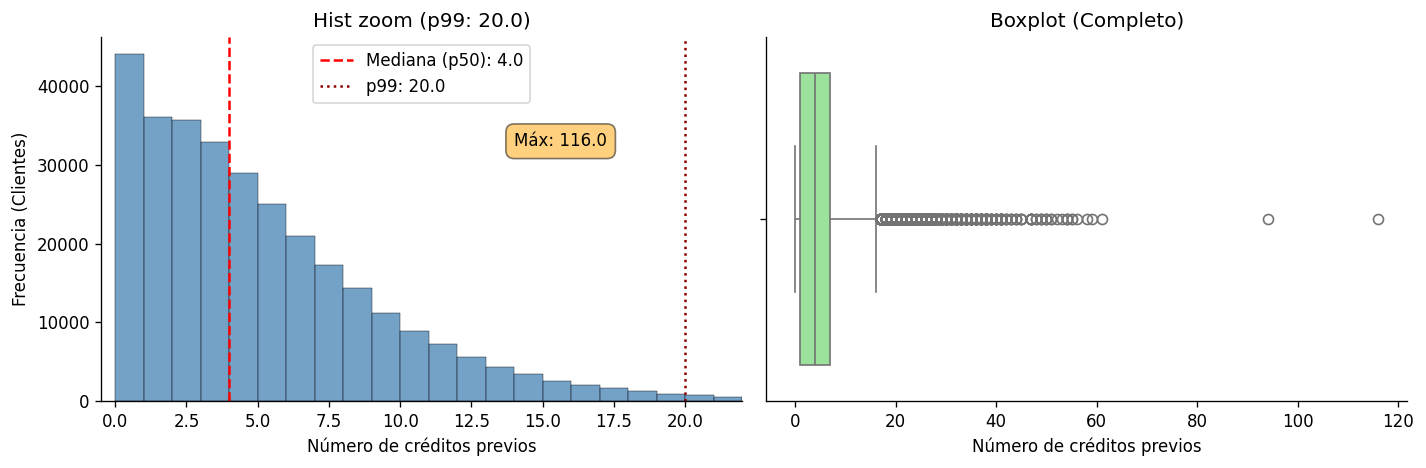

In [4]:
# número de créditos previos por cliente (BUREAU_LOAN_COUNT)
bureau_loan_count_all = bureau["SK_ID_CURR"].value_counts().reindex(app_train["SK_ID_CURR"], fill_value=0)

# estadísticos descriptivos y percentiles
stats = bureau_loan_count_all.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
print("Estadísticos Descriptivos de BUREAU_LOAN_COUNT")
print(f"Media: {round(stats['mean'], 2)} | Mediana: {round(stats['50%'], 1)} | p75: {round(stats['75%'], 1)} | p90: {round(stats['90%'], 1)} | p95: {round(stats['95%'], 1)} | p99: {round(stats['99%'], 1)} | Máx: {round(stats['max'], 1)}")

# histograma con zoom en p99 y Boxplot
p99_val = stats['99%']
max_val = stats['max']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histograma con zoom
sns.histplot(bureau_loan_count_all, binwidth=1, color="steelblue", ax=axes[0])
axes[0].set_xlim(-0.5, p99_val + 2)
axes[0].set(title=f"Hist zoom (p99: {round(p99_val, 0)})", xlabel="Número de créditos previos", ylabel="Frecuencia (Clientes)")
axes[0].axvline(stats['50%'], color="red", linestyle="--", label=f"Mediana (p50): {round(stats['50%'], 0)}")
axes[0].axvline(p99_val, color="darkred", linestyle=":", label=f"p99: {round(p99_val, 0)}")
axes[0].legend()
axes[0].text(p99_val - 6, axes[0].get_ylim()[1]*0.7, f"Máx: {round(max_val, 0)}", 
             bbox=dict(facecolor='orange', alpha=0.5, boxstyle='round,pad=0.5'))

# boxplot simple
sns.boxplot(x=bureau_loan_count_all, color="lightgreen", ax=axes[1])
axes[1].set(title="Boxplot (Completo)", xlabel="Número de créditos previos")

plt.tight_layout()
plt.show()

Tasa de default por número de créditos previos:


,n,Tasa Default
Sin historial (0),44020,10.12
1-2 créditos,71707,8.2
3-5 créditos,86883,7.4
6-10 créditos,72624,7.46
11+ créditos,32277,8.18


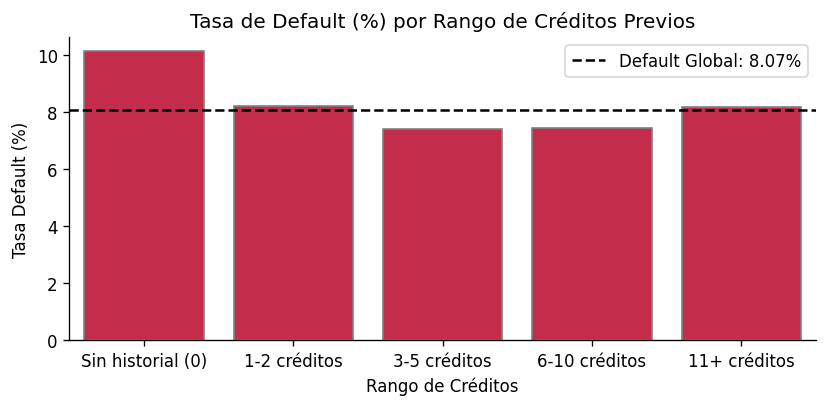

In [5]:
# tasa de default por bins de negocio
bins = [-1, 0, 2, 5, 10, np.inf]
labels = ["Sin historial (0)", "1-2 créditos", "3-5 créditos", "6-10 créditos", "11+ créditos"]

targets = app_train["TARGET"].values
bin_series = pd.cut(bureau_loan_count_all.values, bins=bins, labels=labels)
tabla_bins = pd.Series(targets).groupby(bin_series, observed=False).agg(["count", "mean"])
tabla_bins.columns = ["n", "Tasa Default"]
tabla_bins["Tasa Default"] *= 100
print("Tasa de default por número de créditos previos:")
display(tabla_bins)

# gráfico de barras visual para tasas de default por rango
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=tabla_bins.index, y=tabla_bins["Tasa Default"], color=color_default, ax=ax, edgecolor="gray")
ax.axhline(targets.mean() * 100, color="black", linestyle="--", label=f"Default Global: {round(targets.mean()*100, 2)}%")
ax.set(title="Tasa de Default (%) por Rango de Créditos Previos", xlabel="Rango de Créditos", ylabel="Tasa Default (%)")
ax.legend()
plt.tight_layout()
plt.show()

Z-test: Sin Historial vs Con Historial
Diferencia de tasas: +2.3949pp (Z = 17.0737 | p-valor = 2.331127951548578e-65)
Intervalo de confianza 95% para la diferencia: [2.0952pp, 2.6946pp]


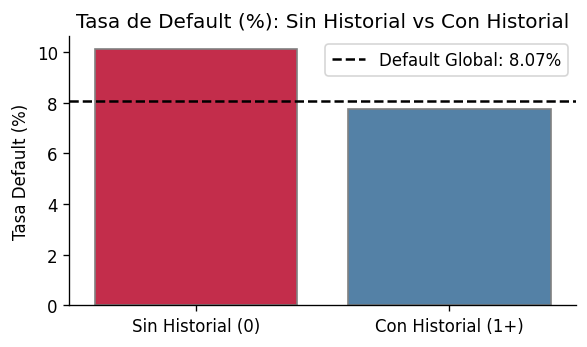

Representatividad del bin 11+ créditos
n: 32277 | Rango: [11, 116] | Media: 14.49 | std: 4.12
Alta dispersión. Clientes con 11 y 116 créditos son agrupados juntos.
Mann-Whitney U = 3671949794.5 | p-valor = 2.4128400065195354e-34 | r_rb = 0.0465
Comparativa de Correlaciones con TARGET
Pearson:  r = -0.01 (p = 2.753679737470032e-08)
Spearman: rho = -0.022 (p = 2.3700540728439663e-34)
La correlación de Spearman confirma una relación monótona pero no lineal (cola larga).


In [6]:
# test el grupo "sin historial" vs "con historial"
has_history = bureau_loan_count_all.values > 0
target_no_hist, target_hist = targets[~has_history], targets[has_history]

n1, x1, p1 = len(target_no_hist), target_no_hist.sum(), target_no_hist.mean()
n2, x2, p2 = len(target_hist), target_hist.sum(), target_hist.mean()

# Z-test para diferencia de proporciones
p_pooled = (x1 + x2) / (n1 + n2)
z_stat = (p1 - p2) / np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
p_val_z = 2 * norm.sf(abs(z_stat))

# intervalo de confianza del 95%
margin = 1.96 * np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
diff = p1 - p2

print(f"Z-test: Sin Historial vs Con Historial")
print(f"Diferencia de tasas: {diff*100:+.4f}pp (Z = {round(z_stat, 4)} | p-valor = {p_val_z})")
print(f"Intervalo de confianza 95% para la diferencia: [{round((diff-margin)*100, 4)}pp, {round((diff+margin)*100, 4)}pp]")

# gráfico comparativo de Tasa de Default: Sin Historial vs Con Historial
fig, ax = plt.subplots(figsize=(5, 3))
default_rates_hist = [p1 * 100, p2 * 100]
categories = ["Sin Historial (0)", "Con Historial (1+)"]
sns.barplot(x=categories, y=default_rates_hist, palette=[color_default, color_no_default], ax=ax, edgecolor="gray", hue=categories, legend=False)
ax.axhline(targets.mean() * 100, color="black", linestyle="--", label=f"Default Global: {round(targets.mean()*100, 2)}%")
ax.set(title="Tasa de Default (%): Sin Historial vs Con Historial", ylabel="Tasa Default (%)")
ax.legend()
plt.tight_layout()
plt.show()

# representatividad y dispersión el bin "11+ créditos"
bin_11plus = bureau_loan_count_all[bureau_loan_count_all >= 11]
print(f"Representatividad del bin 11+ créditos")
print(f"n: {len(bin_11plus)} | Rango: [{bin_11plus.min()}, {bin_11plus.max()}] | Media: {round(bin_11plus.mean(), 2)} | std: {round(bin_11plus.std(), 2)}")
if bin_11plus.max() > 50:
    print("Alta dispersión. Clientes con 11 y 116 créditos son agrupados juntos.")

# mann-Whitney U y Rank-Biserial
x, y = bureau_loan_count_all[targets == 0], bureau_loan_count_all[targets == 1]
u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
r_rb = abs((2 * u_stat) / (len(x) * len(y)) - 1)
print(f"Mann-Whitney U = {u_stat} | p-valor = {p_val} | r_rb = {round(r_rb, 4)}")

# correlación de Pearson y Spearman
corr, p_corr = pearsonr(bureau_loan_count_all, targets)
corr_spearman, p_spearman = spearmanr(bureau_loan_count_all, targets)

print(f"Comparativa de Correlaciones con TARGET")
print(f"Pearson:  r = {round(corr, 4)} (p = {p_corr})\nSpearman: rho = {round(corr_spearman, 4)} (p = {p_spearman})")
if abs(corr_spearman) > abs(corr) * 1.5:
    print("La correlación de Spearman confirma una relación monótona pero no lineal (cola larga).")


La distribución de créditos previos por cliente es asimétrica con cola larga: mediana de 4 créditos, media de 4,77 (inflada por la cola y principalmente por el maximo que sera un error de captura), p99 en 20 y máximo en 116. La barra más
alta del histograma está en 0, que corresponde a los 44.020 clientes (14,31%) sin ningún historial en bureau.

La hipótesis inicial era que más créditos previos podía significar dos cosas opuestas: (1) un cliente experimentado con historial de gestión crediticia, menor riesgo, o (b) cliente sobreendeudado con múltiples frentes de pago, lo que implicaría mayor riesgo. Los datos muestran que ninguna de las dos hipótesis domina de forma simple, sino que la relación es no lineal:

- Sin historial (0 créditos): 10,12% de default, el más alto de todos los rangos
- de 1 a 2 créditos: 8,20%, desciende hacia la media global
- de 3 a 5 créditos: 7,40%, el mínimo absoluto
- de 6 a 10 créditos: 7,46%, prácticamente igual
- 11 o más créditos: 8,18%, sube ligeramente de nuevo

El patrón es de U en el riesgo: los clientes sin historial tienen el mayor
riesgo (falta de información crediticia, similar a lo observado con `EXT_SOURCE_1` donde la ausencia del score implicaba mayor riesgo), el riesgo disminuye a medida que acumulan historial hasta de 3 a 5 créditos, y después se estabiliza con un leve repunte en 11 o más que podría reflejar sobreendeudamiento. Esto explica por qué Spearman (rho = -0,022) duplica a Pearson (r = -0,010): la relación es monótona en el grueso de la distribución pero la cola (11 o más) rompe la linealidad.

Lo más importante de este análisis es la confirmación estadística de que los
clientes sin historial en bureau son un grupo de riesgo diferenciado. El z-test confirma que la diferencia de +2,39pp entre "sin historial" (10,12%) y
"con historial" (7,73%) es altamente significativa (Z = 17,07, p = 2,33e-65) con un
intervalo de confianza del 95% de [2,10pp, 2,69pp] que no incluye el cero. Esto justifica la creación de un flag binario `HAS_BUREAU_HISTORY` (1 si tiene al menos un crédito en bureau, 0 si no) como posible feature en Feature Engineering, además del conteo continuo.

El tamaño del efecto de `BUREAU_LOAN_COUNT` medido por Mann-Whitney U (r_rb = 0,047) es pequeño comparado con las variables temporales de application_train (edad r_rb = 0,166, antigüedad laboral r_rb = 0,165). Su correlación de Pearson (r = -0,010) lo sitúa muy por debajo del ranking de application_train donde `EXT_SOURCE_3` lideraba con -0,179. Como variable individual es débil.

Sobre el bin de 11 o más créditos: tiene n = 32.277 con un rango de [11, 116] y std de 4,12, lo que confirma alta dispersión interna (un cliente con 11 créditos y uno con 116 no son comparables entre sí). La tasa de 8,18% es fiable por el tamaño de muestra pero el bin agrupa perfiles muy diferentes. Más adelante evaluaré estrategias para mejorar la señal de la variable.

### 3. Verificación dtypes / Clasificación variables

In [7]:
# agrupo y mapeo directamente
report = verify_dtypes("bureau", bureau)

category_map = {
    "ID": "identificadores",
    "Categorical": "categóricas",
    "Binary/Flag": "categóricas",
    "Days/Time": "temporales",
    "Amount/Price": "numéricas_financieras",
    "Count": "numéricas_financieras",
    "Numerical": "numéricas_financieras"
}

report["Mapped"] = report["Categoría Esperada"].map(category_map)

# los IDs los clasifico como identificadores explícitamente
report.loc[report["Variable"].isin(["SK_ID_CURR", "SK_ID_BUREAU"]), "Mapped"] = "identificadores"

# fuerzo a que CREDIT_DAY_OVERDUE vaya a numéricas_financieras
report.loc[report["Variable"] == "CREDIT_DAY_OVERDUE", "Mapped"] = "numéricas_financieras"

var_classification = report.groupby("Mapped")["Variable"].apply(list).to_dict()

print("Clasificación de variables")
for k, v in var_classification.items():
    print(f"{k.capitalize()}: {v}")


Clasificación de variables
Categóricas: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
Identificadores: ['SK_ID_CURR', 'SK_ID_BUREAU']
Numéricas_financieras: ['CREDIT_DAY_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']
Temporales: ['DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'DAYS_CREDIT_UPDATE']


Las 17 columnas se reparten en 2 identificadores (`SK_ID_CURR` y `SK_ID_BUREAU`), 3 categóricas (`CREDIT_ACTIVE`, `CREDIT_CURRENCY` y `CREDIT_TYPE`), 4 temporales y 8 numéricas financieras. El reparto ya anticipa dónde va a estar el trabajo: el contenido de la tabla son sobre todo importes y fechas, y solo hay tres ejes categóricos para segmentar, de los cuales uno (`CREDIT_CURRENCY`) es previsible que aporte poco. No hay nada que recodificar por tipo.

### 4. Análisis distribuciones variables

Estadísticos descriptivos de variables numéricas (con percentiles)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CREDIT_DAY_OVERDUE,"1,716,428.0000",0.8182,36.5444,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"2,792.0000"
AMT_CREDIT_MAX_OVERDUE,"591,940.0000","3,825.4172","206,031.6094",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"14,220.4521","41,988.7461","115,987,184.0000"
CNT_CREDIT_PROLONG,"1,716,428.0000",0.0064,0.0962,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9.0000
AMT_CREDIT_SUM,"1,716,415.0000","354,994.6250","1,149,811.3750",0.0000,0.0000,"11,250.0000","51,300.0000","125,518.5000","315,000.0000","1,350,000.0000","3,700,916.0000","585,000,000.0000"
AMT_CREDIT_SUM_DEBT,"1,458,759.0000","137,085.1406","677,401.1250","-4,705,600.5000",0.0000,0.0000,0.0000,0.0000,"40,153.5000","628,902.4375","2,259,728.5000","170,100,000.0000"
AMT_CREDIT_SUM_LIMIT,"1,124,648.0000","6,229.5137","45,032.0312","-586,406.1250",0.0000,0.0000,0.0000,0.0000,0.0000,"5,736.0669","199,620.5625","4,705,600.5000"
AMT_CREDIT_SUM_OVERDUE,"1,716,428.0000",37.9128,"5,937.6499",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"3,756,681.0000"
AMT_ANNUITY,"489,637.0000","15,712.7559","325,826.9375",0.0000,0.0000,0.0000,0.0000,0.0000,"13,500.0000","46,571.3984","118,451.8828","118,453,424.0000"
DAYS_CREDIT,"1,716,428.0000","-1,142.1077",795.1649,"-2,922.0000","-2,867.0000","-2,665.0000","-1,666.0000",-987.0000,-474.0000,-125.0000,-38.0000,0.0000
DAYS_CREDIT_ENDDATE,"1,610,875.0000",510.5173,"4,994.2197","-42,060.0000","-2,571.0000","-2,262.0000","-1,138.0000",-330.0000,474.0000,"2,623.0000","31,029.0000","31,199.0000"



Frecuencias de variables categóricas (Conteo y Porcentaje)

Distribución de CREDIT_ACTIVE:


,Conteo (n),Porcentaje (%)
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.0



Distribución de CREDIT_CURRENCY:


...

  CREDIT_CURRENCY: 4 categorías: OK (sin variantes)


  CREDIT_TYPE: 15 categorías: OK (sin variantes)

Frecuencia de CNT_CREDIT_PROLONG (Conteo y Porcentaje)


,Conteo (n),Porcentaje (%)
CNT_CREDIT_PROLONG,,
0,1707314,99.47
1,7620,0.44
2,1222,0.07
3,191,0.01
4,54,0.0
5,21,0.0
9,2,0.0
6,2,0.0
8,1,0.0



Conteo de nulos por fila en Bureau


,Conteo Filas (n),Porcentaje (%)
0,39666,2.31
1,428046,24.94
2,522607,30.45
3,502067,29.25
4,169634,9.88
5,44498,2.59
6,9910,0.58


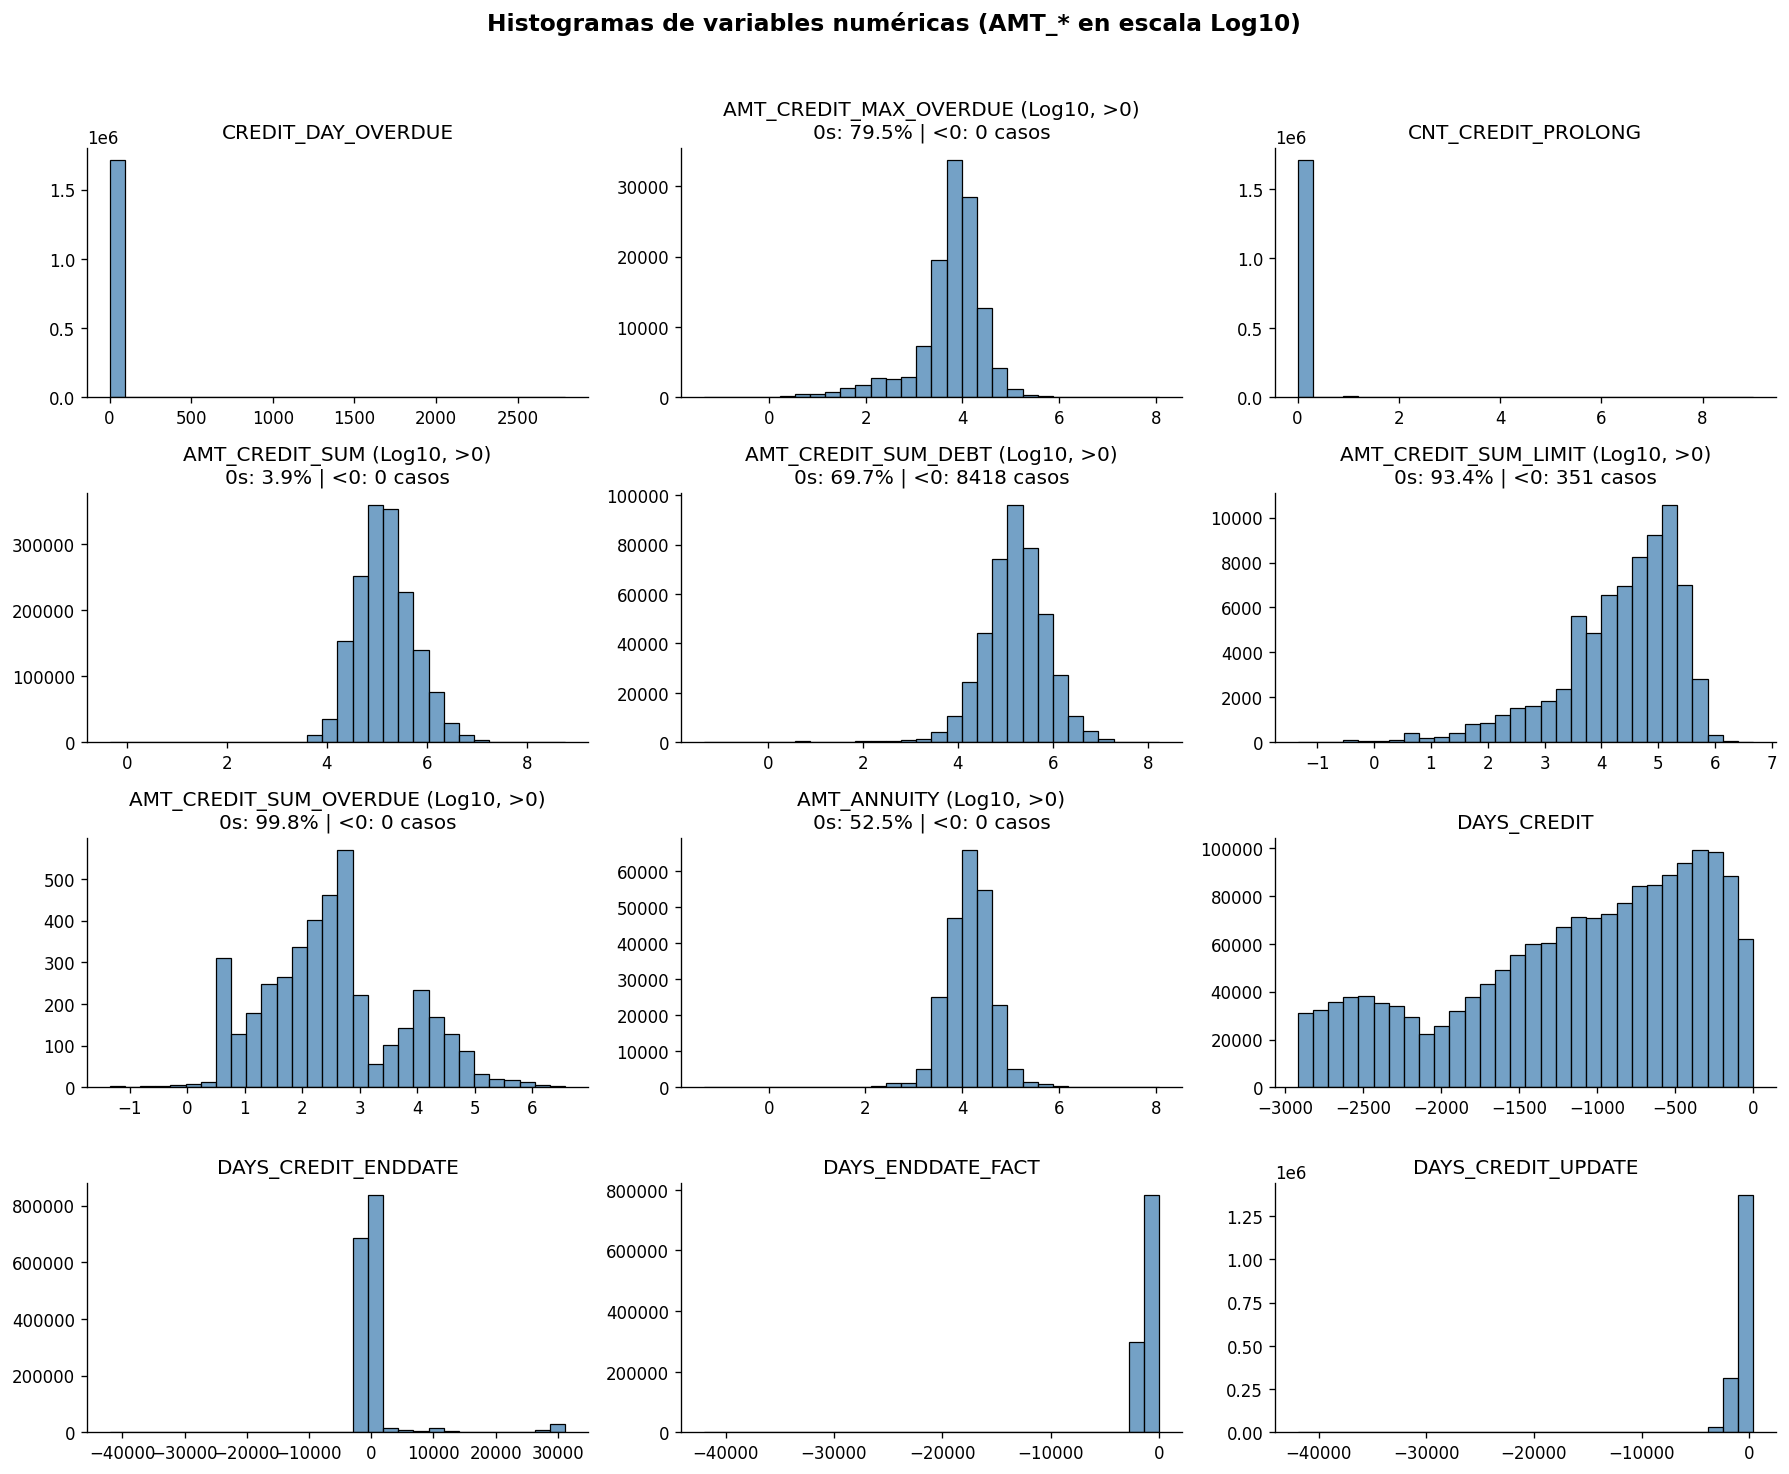

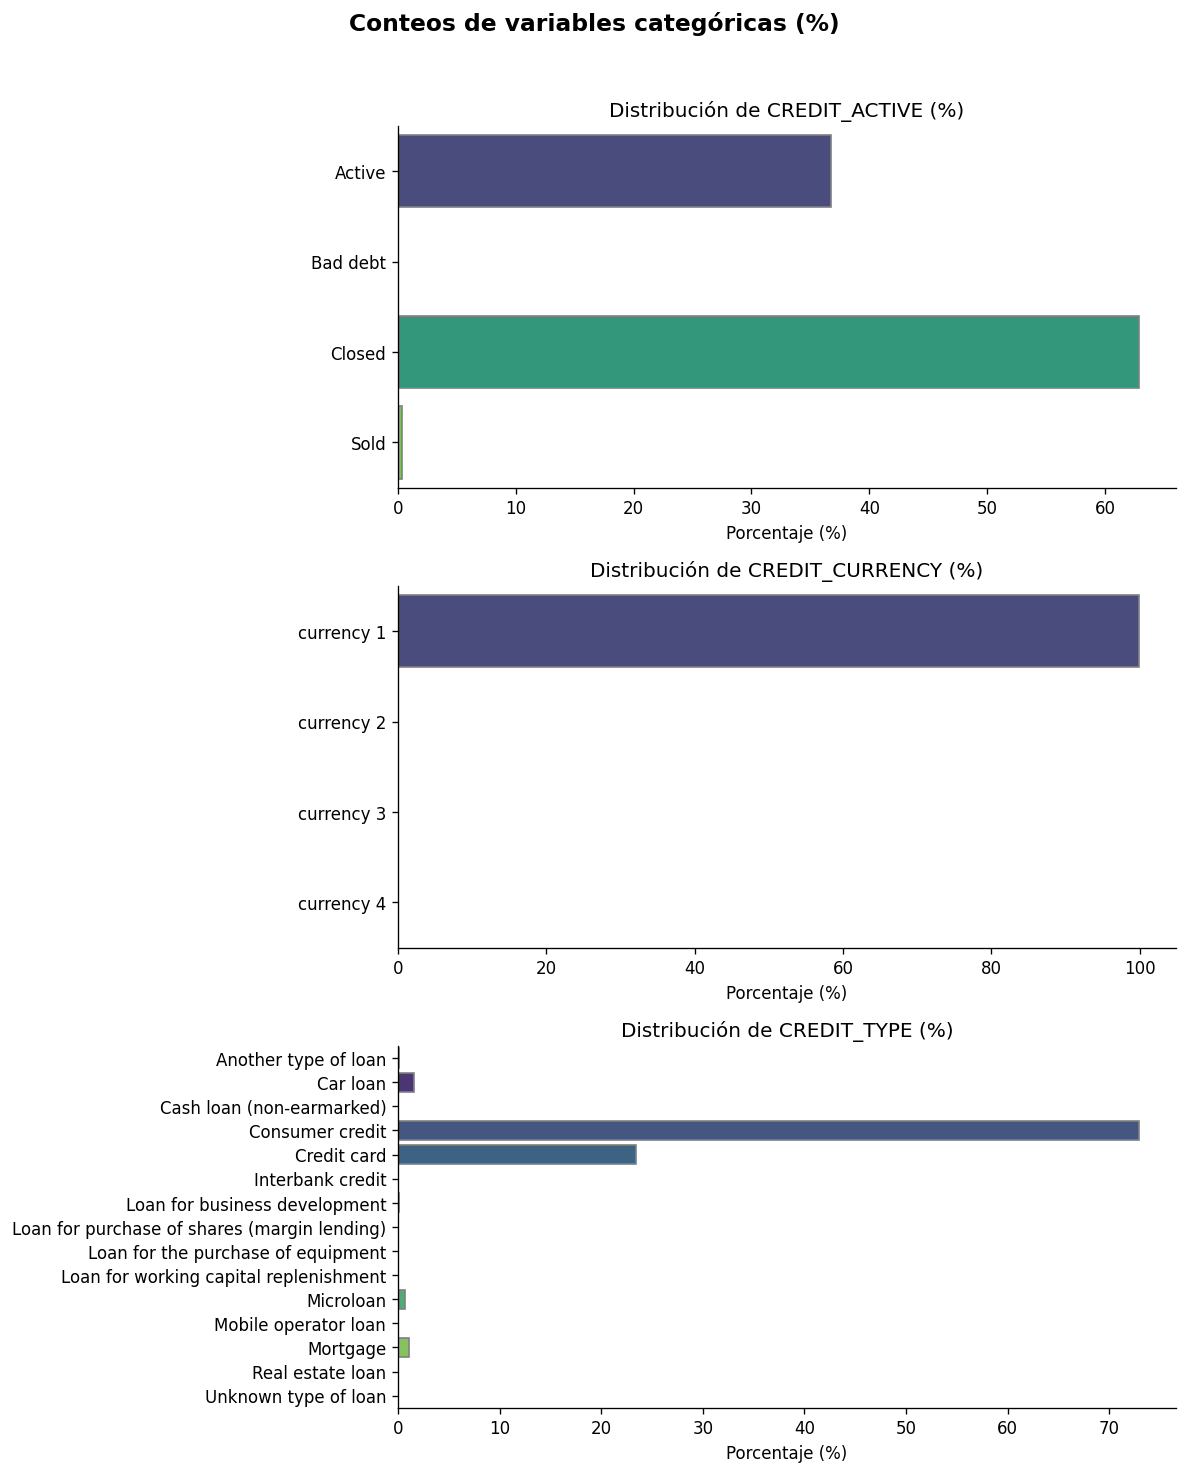

In [8]:
# estadísticos descriptivos de numéricas (financieras + temporales)
numeric_cols = var_classification.get("numéricas_financieras", []) + var_classification.get("temporales", [])
print("Estadísticos descriptivos de variables numéricas (con percentiles)")
desc_num = bureau[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(desc_num.style.format("{:,.4f}"))

# distribución de variables categóricas (absolutos y porcentajes)
print("\nFrecuencias de variables categóricas (Conteo y Porcentaje)")
categorical_cols = var_classification.get("categóricas", [])
cat_freqs = {}
for col in categorical_cols:
    counts = bureau[col].value_counts(dropna=False)
    pcts = (counts / len(bureau)) * 100
    cat_freqs[col] = pcts  # Guardamos para reutilizar en gráficos
    df_cat = pd.DataFrame({"Conteo (n)": counts, "Porcentaje (%)": pcts})
    print(f"\nDistribución de {col}:")
    display(df_cat)

# higiene de categóricas: variantes por espacios/caso que colapsan al normalizar (typos)
print("\nHigiene de categóricas (espacios/caso):")
for col in categorical_cols:
    s = bureau[col].astype("string")
    n_raw = s.nunique(dropna=True)
    n_norm = s.str.strip().str.lower().nunique(dropna=True)
    estado = "OK (sin variantes)" if n_raw == n_norm else f"REVISAR: {n_raw - n_norm} variantes por espacios/caso"
    print(f"  {col}: {n_raw} categorías: {estado}")

# frecuencia para CNT_CREDIT_PROLONG (conteo discreto)
print("\nFrecuencia de CNT_CREDIT_PROLONG (Conteo y Porcentaje)")
counts_prolong = bureau["CNT_CREDIT_PROLONG"].value_counts(dropna=False)
display(pd.DataFrame({"Conteo (n)": counts_prolong, "Porcentaje (%)": counts_prolong / len(bureau) * 100}))

# conteo de nulos por fila en bureau
print("\nConteo de nulos por fila en Bureau")
row_null_counts = bureau.isna().sum(axis=1).value_counts(dropna=False).sort_index()
display(pd.DataFrame({"Conteo Filas (n)": row_null_counts, "Porcentaje (%)": row_null_counts / len(bureau) * 100}))


# grid de histogramas variables numéricas (AMT_* logarítmica, DAYS_* lineal)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for col, ax in zip(numeric_cols, axes.flatten()):
    is_log = col.startswith("AMT_")
    if is_log:
        total = desc_num.loc[col, "count"]
        zeros = (bureau[col] == 0).sum()
        neg = int((bureau[col] < 0).sum()) if desc_num.loc[col, "min"] < 0 else 0
        pct = (zeros / total) * 100 if total > 0 else 0.0
        
        data = np.log10(bureau[col][bureau[col] > 0])
        title = f"{col} (Log10, >0)\n0s: {round(pct, 1)}% | <0: {neg} casos"
    else:
        data = bureau[col].dropna()
        title = col
    
    sns.histplot(data, bins=30, color="steelblue", ax=ax)
    ax.set(title=title, xlabel="", ylabel="")

plt.suptitle("Histogramas de variables numéricas (AMT_* en escala Log10)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# grid de barras variables categóricas (top 15 para CREDIT_TYPE)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for col, ax in zip(categorical_cols, axes.flatten()):
    freq_data = cat_freqs[col].head(15)
    sns.barplot(x=freq_data.values, y=freq_data.index, hue=freq_data.index, palette="viridis", legend=False, ax=ax, edgecolor="gray")
    ax.set(title=f"Distribución de {col} (%)", xlabel="Porcentaje (%)", ylabel="")

plt.suptitle("Conteos de variables categóricas (%)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Variables categóricas**

`CREDIT_ACTIVE`: la distribución muestra que el 62,88% de los créditos previos reportados al buró ya están cerrados (1.079.273), mientras que el 36,74% siguen activos (630.607). Esto me indica que la mayoría de clientes de este dataset tienen un historial crediticio con más créditos ya liquidados que en curso, lo cual es esperable en una población general. La categoría "Sold" con 6.527 (0,38%) representa créditos vendidos a un cobrador de deudas, lo que en sí mismo es una señal de impago grave ya que un banco no vende una deuda que espera cobrar. "Bad debt" con solo 21 obs (0,001%) es la categoría más extrema pero con un tamaño de muestra tan pequeño que cualquier tasa de default calculada sobre ella será solamente ruido estadístico, similar a lo que ocurrió con "Maternity leave" (n=5) en application_train. Cuando cruce `CREDIT_ACTIVE` con `TARGET` al mirar las correlaciones, tendré que agrupar "Sold" y "Bad debt" en una sola categoría ("Deuda problemática") o tratarlas con cautela.

`CREDIT_CURRENCY`: el 99,92% de los créditos (1.715.020 de 1.716.428) están denominados en currency 1. Las otras tres monedas juntas representan 1.408 obs (0,08%). Es una variable con varianza prácticamente nula que no puede aportar señal discriminante al modelo. La decisión
será eliminarla directamente más adelante sin necesidad de contraste con `TARGET` por su poca varianza.

`CREDIT_TYPE`: Consumer credit domina con el 72,92% (1.251.615) seguido de "Credit card" con
23,43% (402.195). Entre ambas suman el 96,35% del dataset. Las 13 categorías restantes representan el 3,65%, con "Car loan" (1,61%) y "Mortgage" (1,07%) como las únicas por encima del 1%. Hay 6 categorías con menos de 100 obs absolutos: "Cash loan non-earmarked" (56), "Real estate loan" (27), "Loan for the purchase of equipment" (19), "Loan for purchase of shares" (4), "Interbank credit" (1) y "Mobile operator loan" (1). Estas últimas no son analizables debido a su poca representación y con el objetivo futuro de que el modelo no se obsesione (overfitting) con ellas, se agruparán en "Other" para cualquier análisis categórico. La dominancia de "Consumer credit" y "Credit card" refleja el perfil típico de clientes de microcréditos: su historial externo es mayoritariamente créditos al consumo y tarjetas, no productos sofisticados como hipotecas o préstamos empresariales aparentemente.

**Variables numéricas**

**Bloque Demora**

`CREDIT_DAY_OVERDUE`: media de 0,82 días con todos los percentiles desde p1 hasta p99 en 0. Es decir, más del 99% de los créditos no tienen demora actual en días. El máximo de 2.792 días (más de 7,6 años en demora) corresponde a una cola extrema de casos muy graves. La distribución es de tipo "masa en cero + cola de eventos raros", exactamente el patrón que vi en `DEF_60_CNT_SOCIAL_CIRCLE` de application_train donde los outliers resultaron tener la señal discriminante más fuerte del bloque. Por lo que en este caso espero un comportamiento similar en esta variable.

`AMT_CREDIT_MAX_OVERDUE`: solo 591.940 registros de 1.716.428 (34,49%) tienen valor, lo que
implica un 65,51% de nulos. De los que tienen valor, el 79,5% son exactamente 0 (nunca ha tenido demora máxima reportada). Los que sí tienen valor muestran una distribución en log que va desde 10¹ hasta 10⁸ con un máximo de 115.987.184. El p95 es 14.220 y el p99 es 41.989, lo que indica que la cola por encima de p99 es extremadamente larga. Esta variable es probablemente de la más valiosa de este bloque que trata la demora histórica: por lo tanto, el mayor importe que un cliente ha dejado sin pagar es un indicador directo de su comportamiento de riesgo pasado.

`AMT_CREDIT_SUM_OVERDUE`: la variable más extrema en concentración de ceros: 99,8% son
exactamente 0. Solo el 0,2% de los créditos tiene demora actual en importe. El máximo es 3.756.681. En el histograma log se aprecia una bimodalidad con una moda entre 10¹ y 10³ y otra entre 10⁴, lo que sugiere 2 poblaciones de demora: incidencias menores (probablemente retrasos puntuales a la hora de planificación) vs demora grave (incumplimiento estructural de responsabilidades de pago). Por lo que tendré que analizar si estos 2 comportamientos corresponden a perfiles de riesgo distintos.

`CNT_CREDIT_PROLONG`: media de 0,0064 y todos los percentiles hasta p99 en 0, con máximo de 9. Esto significa que menos del 1% de los créditos ha sido prorrogado al menos una vez. Al ser tan concentrada en 0, esta variable tiene más sentido como flag binario ("ha prorrogado algún crédito sí/no") que como variable continua a la hora de agregar por cliente más adelante.

**Bloque Importes**

`AMT_CREDIT_SUM`: es la variable de importe con mayor presencia (1.716.415, casi sin nulos). La mediana es 125.519 con p75 de 315.000 y p99 de 3.700.916. El máximo de 585.000.000 es
extremo (ratio Máx/p99 aprox un 158x) y probablemente es un error de captura similar al que vi
con `AMT_INCOME_TOTAL` en application_train. Solo el 3,9% son ceros, lo que tiene sentido ya que un crédito con importe 0 no debería existir (probablemente errores de carga o créditos anulados). En el histograma log se aprecia una distribución centrada en 10⁵ con cola hacia ambos lados.

`AMT_CREDIT_SUM_DEBT`: 1.458.759 registros (el resto son nulos, 15,01%). El 69,7% de los valores son 0, lo que refleja los créditos ya liquidados o cerrados sin deuda pendiente. La
mediana es 0 y el p75 es 40.154, lo que indica que solo el cuartil superior tiene deuda activa. El máximo es 170.100.000. Tiene 8.418 valores negativos, con mínimo de -4.705.600. Un valor negativo en deuda podría interpretarse como un saldo a favor del cliente (sobrepago), pero la magnitud de -4,7M es sospechosa y la analizaré en outliers para ver si encaja con el comportamiento.

`AMT_CREDIT_SUM_LIMIT`: 1.124.648 obs (34,47% de nulos). El 93,4% de los valores son 0, lo que tiene sentido porque esta variable es el límite de crédito de tarjetas y solo debería tener valor para créditos de tipo "Credit card" (que representan el 23,43% de la tabla). Verificaré este cruce más adelante. Tiene 351 valores negativos (mínimo -586.406), que igual que en `AMT_CREDIT_SUM_DEBT` analizaré posteriormente. El máximo de 4.705.601 coincide en magnitud con el mínimo negativo de   `AMT_CREDIT_SUM_DEBT`, lo que podría indicar un error de signo en la fuente (el mismo valor aparece positivo en una variable y negativo en la otra para los mismos registros).

`AMT_ANNUITY`: solo 489.637 registros (71,47% de nulos), y es la variable con menor presencia de todo el bloque. El 52,5% de los valores presentes son 0, lo que combinado con el alto % de nulos implica que hay pocos datos acerca del comportamiento. La mediana es 0 y el p75 es 13.500. El máximo de 118.453.424 es extremo. La interpretación que hago es que muchos créditos reportados al buró no incluyen la cuota anual, probablemente porque la fuente de datos no reporte ese campo para ciertos tipos de crédito o créditos antiguos. Verificaré el cruce con `CREDIT_TYPE` y `CREDIT_ACTIVE` posteriormente.

**Bloque temporal**

`DAYS_CREDIT`: tiene presencia completa (1.716.428). Su rango es de -2.922 a 0, toda la variable es negativa o cero como lo esperado (días antes de la solicitud actual). La mediana es -987 días (aprox 2,7 años antes), el p75 es -474 (aprox 1,3 años antes) y el p5 es -2.665 (7,3 años antes). El histograma muestra una distribución creciente hacia 0 (más créditos solicitados recientemente que hace muchos años), que es el patrón natural: el buró tiene más información reciente que antigua.

`DAYS_CREDIT_ENDDATE`: 1.610.875 registros (6,15% de nulos). Su rango de -42.060 a 31.199, con valores tanto negativos (créditos que ya terminaron antes de la solicitud) como positivos (créditos con fecha de fin futura). La mediana es -330 (crédito que terminó 11 meses antes). El máximo de 31.199 días (85 años en el futuro) es sospechoso de outlier: ya que un crédito con vencimiento a 85 años no es viable en la mayoría de productos financieros.

`DAYS_ENDDATE_FACT`: 1.082.775 registros (36,93% de nulos). Los nulos aquí probablemente corresponden a créditos aún activos que no tienen fecha de cierre real. El rango es de -42.023 a 0, todo negativo o cero (días desde que el crédito cerró hasta la solicitud). La mediana es -897 (2,5 años antes) y la distribución en el histograma está muy concentrada cerca de 0 con una cola larga. El mínimo de -42.023 días (115 años antes) es sospechoso de ser un error de histórico y por tanto outlier. Verificaré el cruce con `CREDIT_ACTIVE` más adelante para confirmar que los nulos corresponden exactamente a los créditos activos.

`DAYS_CREDIT_UPDATE`: tiene una presencia completa (1.716.428). Un rango de -41.947 a 372. La inmensa mayoría de la masa está concentrada cerca de 0 (actualización reciente), con p50 de -395 (1,1 años antes) y p75 de -33 (1 mes antes). El máximo positivo de 372 es un outlier: ya que una actualización del buró 372 días después de la solicitud actual no es viable. El p99 es -3 (actualización 3 días antes de la solicitud), lo que confirma que los positivos son un fenómeno de cola extrema muy reducido. Posteriormente observaré y analizaré cuántas obs tienen valores positivos y si corresponden a un patrón de tipo de crédito o estado al mirar el eje temporal.

`CNT_CREDIT_PROLONG`: la tabla de frecuencias confirma que el 99,469% de los créditos (1.707.314) nunca han sido prorrogados. Apenas el 0,444% (7.620) tiene exactamente 1 prórroga, y a partir de 2 prórrogas los casos son residuales (0,071%, 0,011%, 0,003%...) hasta llegar a valores extremos como 9 prórrogas con solo 2 casos. En conjunto, solo el 0,531% de los créditos tiene alguna prórroga. Esto confirma que la variable la tratare como flag binario (`HAS_BEEN_PROLONGED`) posteriormente, ya que como variable continua el 99,5% de la información es un único valor (0) y no tiene capacidad discriminante.

El análisis de cuántas columnas nulas tiene cada fila me da indicios de que existe un patrón estructural importante: y es que solo el 2,311% de las filas (39 666) están sin nulos en las variables numéricas. El grueso del dataset se concentra en 1 a 3 nulos simultáneos por fila (24,938% + 30,447% + 29,251% = 84,636% del total), mientras que 4 o más nulos simultáneos son menos frecuentes (9,883% + 2,592% + 0,577% = 13,052%).

Esta concentración en 1 a 3 nulos no es aleatoria. Encajaría con la hipótesis de presenciar un missing estructural: es decir, un crédito de tipo "Consumer credit" (72,92% del dataset) que esté "Active" (36,74%) tendría, solo por estructura, `AMT_CREDIT_SUM_LIMIT` nulo (porque no es tarjeta) y `DAYS_ENDDATE_FACT` nulo (porque no ha cerrado), lo que ya suma 2 nulos automáticos antes de considerar `AMT_CREDIT_MAX_OVERDUE` (65,51% nulo global) o
`AMT_ANNUITY` (71,47% nulo global). Esto explicaría por qué el pico de la distribución está en 2 a 3 nulos simultáneos en vez de estar disperso uniformemente entre 0 y 6.

Esta coexistencia refuerza la necesidad, de que mas adelante en el análisis de missings, he de resolver primero los casos de MAR determinista (`DAYS_ENDDATE_FACT` vs `CREDIT_ACTIVE`, `AMT_CREDIT_SUM_LIMIT` vs `CREDIT_TYPE`) antes de aplicar cualquier test estadístico general sobre el resto de
columnas, ya que gran parte del patrón de nulos observado aquí se explica por estas dos relaciones estructurales y no por un patrón de missing que requiera
imputar o crear flags adicionales.

### 5. Análisis Missings

In [9]:
# aplico un merge con TARGET
bureau_t = bureau.drop(columns=["TARGET"], errors="ignore").merge(app_train, on="SK_ID_CURR", how="inner")

# cuantifico y valido que haya salido bien todo
n_orig, n_t = len(bureau), len(bureau_t)
n_uniq = bureau_t["SK_ID_CURR"].nunique()
assert not bureau_t["TARGET"].isna().any()
assert n_uniq == 263491, f"Error: Se esperaban 263,491 clientes, se encontraron {n_uniq}"

print(f"Merge exitoso.")
print(f"Original: {n_orig} filas | Filtrado: {n_t} filas ({n_orig - n_t} descartadas, {round((n_orig - n_t)/n_orig * 100, 2)}%)")
print(f"Clientes únicos con historial en train: {n_uniq}")

Merge exitoso.
Original: 1716428 filas | Filtrado: 1465325 filas (251103 descartadas, 14.63%)
Clientes únicos con historial en train: 263491


Se incorpora la variable TARGET de `application_train` a nivel de fila de bureau mediante
merge inner por `SK_ID_CURR`. El resultado es un subconjunto de 1.465.325 créditos previos
correspondientes a los 263.491 clientes de train que tienen historial en bureau. El merge
descarta 251.103 filas, el 14,63% de las 1.716.428 originales, que son los créditos de clientes
que no están en train, y no introduce ningún nulo en TARGET. De aquí en
adelante, todos los análisis de missings, correlaciones, temporal y outliers de bureau se
realizan sobre este subconjunto, no sobre el dataset original de 1.716.428 filas.

Tabla de contingencia: DAYS_ENDDATE_FACT (null) vs CREDIT_ACTIVE


CREDIT_ACTIVE,Active,Bad debt,Closed,Sold,All
DAYS_ENDDATE_FACT,,,,,
False,1507,9,917640,1496,920652
True,540412,11,93,4157,544673
All,541919,20,917733,5653,1465325


Porcentaje de coincidencia (nulos son Active): 99.22%
Test Chi2 de asociación: Chi2 = 1453760.22 | p-valor = 0.0
¿Es MAR determinista? SÍ



Tabla de contingencia: AMT_CREDIT_SUM_LIMIT (null) vs CREDIT_TYPE


,Otro tipo,Credit card,All
AMT_CREDIT_SUM_LIMIT,,,
False,728879,246776,975655
True,392593,97077,489670
All,1121472,343853,1465325


Porcentaje de coincidencia (nulos en no-tarjetas): 80.18%
Test Chi2 de asociación: Chi2 = 5428.33 | p-valor = 0.0
¿Es MAR determinista? NO



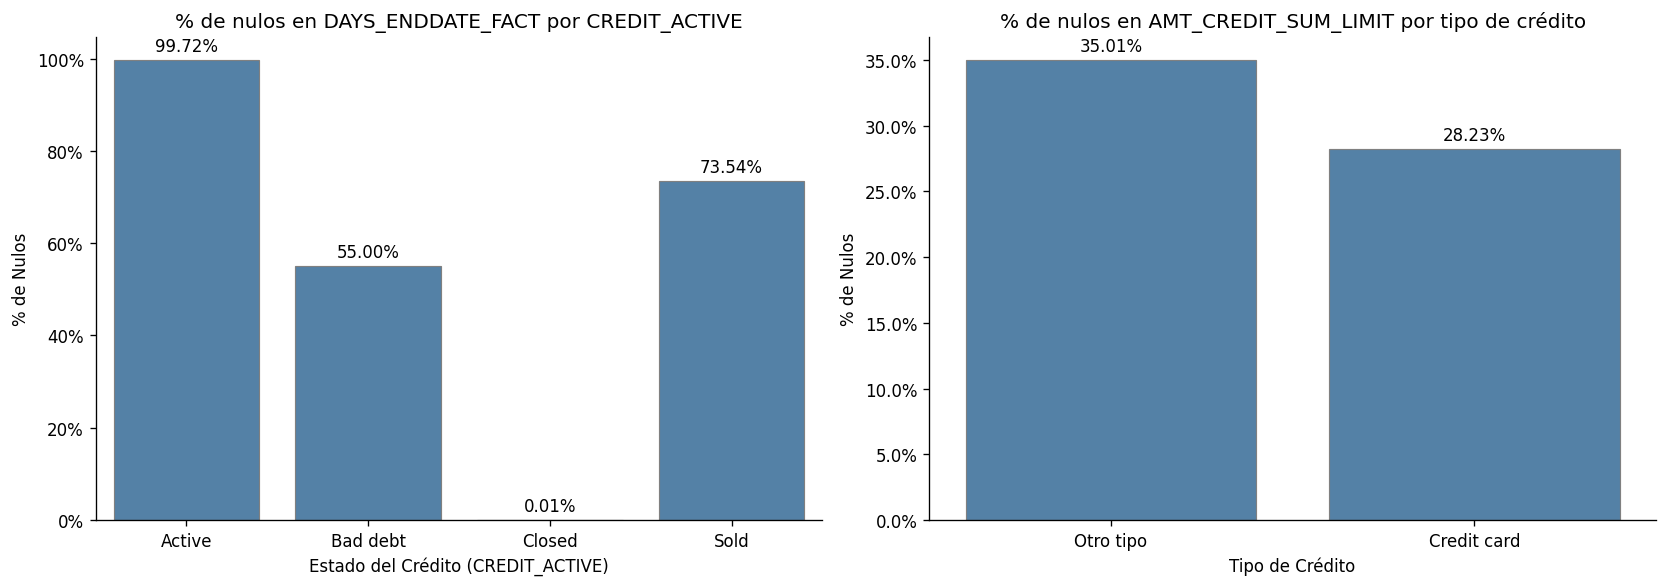

In [10]:
# confirmo los MAR deterministas con tablas de contingencia y Chi2
# DAYS_ENDDATE_FACT vs CREDIT_ACTIVE
ct_days = pd.crosstab(bureau_t["DAYS_ENDDATE_FACT"].isnull(), bureau_t["CREDIT_ACTIVE"], margins=True)
print("Tabla de contingencia: DAYS_ENDDATE_FACT (null) vs CREDIT_ACTIVE")
display(ct_days)

# extraigo porcentaje del crosstab directamente para evitar re-indexar
pct_days_coincidence = (ct_days.loc[True, "Active"] / ct_days.loc[True, "All"]) * 100
is_days_mar = pct_days_coincidence > 95.0

# test Chi-Cuadrado de independencia
chi2_1, p_val_1, _, _ = chi2_contingency(ct_days.iloc[:-1, :-1])

print(f"Porcentaje de coincidencia (nulos son Active): {round(pct_days_coincidence, 2)}%")
print(f"Test Chi2 de asociación: Chi2 = {round(chi2_1, 2)} | p-valor = {p_val_1}")
print(f"¿Es MAR determinista? {'SÍ' if is_days_mar else 'NO'}\n")

# AMT_CREDIT_SUM_LIMIT vs CREDIT_TYPE
is_card = bureau_t["CREDIT_TYPE"] == "Credit card"
ct_limit = pd.crosstab(bureau_t["AMT_CREDIT_SUM_LIMIT"].isnull(), is_card, margins=True)
ct_limit.columns = ["Otro tipo", "Credit card", "All"]
print("Tabla de contingencia: AMT_CREDIT_SUM_LIMIT (null) vs CREDIT_TYPE")
display(ct_limit)

# extraigo porcentaje del crosstab directamente
pct_limit_coincidence = (ct_limit.loc[True, "Otro tipo"] / ct_limit.loc[True, "All"]) * 100
is_limit_mar = pct_limit_coincidence > 95.0

# test Chi-Cuadrado de independencia (reutilizando la tabla sin márgenes)
chi2_2, p_val_2, _, _ = chi2_contingency(ct_limit.iloc[:-1, :-1])

print(f"Porcentaje de coincidencia (nulos en no-tarjetas): {round(pct_limit_coincidence, 2)}%")
print(f"Test Chi2 de asociación: Chi2 = {round(chi2_2, 2)} | p-valor = {p_val_2}")
print(f"¿Es MAR determinista? {'SÍ' if is_limit_mar else 'NO'}\n")

# grafico del % de nulos para ambos casos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# subplot 1: % de nulos en DAYS_ENDDATE_FACT por CREDIT_ACTIVE
pct_null_active = (ct_days.iloc[1] / ct_days.iloc[2] * 100).drop('All')
sns.barplot(x=pct_null_active.index, y=pct_null_active.values, ax=axes[0], color=color_no_default, edgecolor='gray', linewidth=0.7)
axes[0].set_title("% de nulos en DAYS_ENDDATE_FACT por CREDIT_ACTIVE")
axes[0].set_ylabel("% de Nulos")
axes[0].set_xlabel("Estado del Crédito (CREDIT_ACTIVE)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f%%", padding=3)

# subplot 2: % de nulos en AMT_CREDIT_SUM_LIMIT por tipo de crédito (Credit card vs Otro)
pct_null_limit = (ct_limit.iloc[1] / ct_limit.iloc[2] * 100).drop('All')
sns.barplot(x=pct_null_limit.index, y=pct_null_limit.values, ax=axes[1], color=color_no_default, edgecolor='gray', linewidth=0.7)
axes[1].set_title("% de nulos en AMT_CREDIT_SUM_LIMIT por tipo de crédito")
axes[1].set_ylabel("% de Nulos")
axes[1].set_xlabel("Tipo de Crédito")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

`DAYS_ENDDATE_FACT`: Es un MAR determinista confirmado. El 99,22% de los nulos corresponde a créditos con `CREDIT_ACTIVE = 'Active'` (Chi2 = 1.453.760, p ≈ 0). Sin embargo, no es "nulo = crédito activo" sino "nulo = crédito no cerrado formalmente": los créditos "Sold" (73,54% nulos) y "Bad debt" (55% nulos) tampoco tienen fecha de cierre porque fueron transferidos a cobro externo o declarados incobrables antes de un cierre formal. Los 93 nulos en créditos "Closed" (0,01%) son seguramente errores de carga. La ausencia se explica completamente por `CREDIT_ACTIVE` y no requiere flag de missing ni test. Más adelante agregaré por cliente.

`AMT_CREDIT_SUM_LIMIT`: Es un MAR determinista refutado. La hipótesis de que el nulo se concentraba en tipos distintos a 'Credit card' no se sostiene: 'Credit card' tiene 28,23% de nulos y otros tipos 35,01%, una diferencia de solo 7pp. Que el 28% de las propias tarjetas no reporte su límite indica que el nulo depende de otro factor además del tipo de crédito (probablemente antigüedad o fuente de datos del buró).

| Variable | % nulos sobre `bureau_t` | MAR determinista | Clasificación provisional |
|---|---|---|---|
| `DAYS_ENDDATE_FACT` | 37,17% | ✅ Confirmado (vs CREDIT_ACTIVE) | MAR determinista |
| `AMT_CREDIT_SUM_LIMIT` | 33,42% | ❌ Refutado (Credit card también tiene 28% nulos) | Pendiente test general |

In [11]:
# obtengo un tabla vectorizada con test estadístico general
cols_con_nulos = [
    "AMT_ANNUITY", 
    "AMT_CREDIT_MAX_OVERDUE", 
    "DAYS_ENDDATE_FACT", 
    "AMT_CREDIT_SUM_LIMIT", 
    "AMT_CREDIT_SUM_DEBT", 
    "DAYS_CREDIT_ENDDATE", 
    "AMT_CREDIT_SUM"
]

# máscaras booleanas de nulos y tasas
null_mask = bureau_t[cols_con_nulos].isnull()
n_nulos = null_mask.sum()
pct_nulos = null_mask.mean() * 100

target_ints = bureau_t["TARGET"].astype(int)

# cálculo las tasas de default
tasa_nulo_all = null_mask.T.dot(target_ints) / n_nulos
tasa_presente_all = (~null_mask).T.dot(target_ints) / (len(bureau_t) - n_nulos)

# corrección de Bonferroni (excluyo DAYS_ENDDATE_FACT)
n_tests = len(cols_con_nulos) - 1
alpha_bonferroni = 0.05 / n_tests

stats_rows = []
for col in cols_con_nulos:
    # calculo las medianas agrupadas
    medians = bureau_t.loc[~null_mask[col]].groupby("TARGET")[col].median()
    
    if col == "DAYS_ENDDATE_FACT":
        p_val, test_usado, sig_bonf = np.nan, "Excluido (MAR)", "N/A"
    else:
        ct = pd.crosstab(null_mask[col], bureau_t["TARGET"])
        if ct.values.min() < 5:
            _, p_val = fisher_exact(ct)
            test_usado = "Fisher"
        else:
            _, p_val, _, _ = chi2_contingency(ct)
            test_usado = "Chi2"
        sig_bonf = "Sí" if p_val < alpha_bonferroni else "No"
        
    stats_rows.append({
        "Nombre de la variable": col,
        "Número de nulos": n_nulos[col],
        "Porcentaje de nulos": pct_nulos[col],
        "Tasa de default cuando el valor es nulo": tasa_nulo_all[col],
        "Tasa de default cuando el valor está presente": tasa_presente_all[col],
        "Diferencia entre las dos tasas anteriores": tasa_nulo_all[col] - tasa_presente_all[col],
        "Tipo de medida central": "Mediana",
        "Valor central en TARGET=0": medians.get(0, np.nan),
        "Valor central en TARGET=1": medians.get(1, np.nan),
        "Test": test_usado,
        "p-valor": p_val,
        "Sig. Bonferroni": sig_bonf
    })

# construyo DataFrame ordenado por diferencia de tasas de default
df_stats = pd.DataFrame(stats_rows).sort_values(
    by="Diferencia entre las dos tasas anteriores", ascending=False
).reset_index(drop=True)

# muestro la tabla
display(df_stats.style.format({
    "Número de nulos": "{:,}",
    "Porcentaje de nulos": "{:.4f}%",
    "Tasa de default cuando el valor es nulo": "{:.4f}",
    "Tasa de default cuando el valor está presente": "{:.4f}",
    "Diferencia entre las dos tasas anteriores": "{:+.4f}",
    "Valor central en TARGET=0": "{:,.4f}",
    "Valor central en TARGET=1": "{:,.4f}",
    "p-valor": "{:.2e}"
}).map(
    lambda v: "background-color: #a8d5a2" if v == "Sí" else ("background-color: #f4a4a4" if v == "No" else ""),
    subset=["Sig. Bonferroni"]
))

,Nombre de la variable,Número de nulos,Porcentaje de nulos,Tasa de default cuando el valor es nulo,Tasa de default cuando el valor está presente,Diferencia entre las dos tasas anteriores,Tipo de medida central,Valor central en TARGET=0,Valor central en TARGET=1,Test,p-valor,Sig. Bonferroni
0,DAYS_CREDIT_ENDDATE,"89,098",6.0804%,0.1045,0.0764,+0.0280,Mediana,-353.0000,-120.0000,Chi2,3.10e-200,Sí
1,DAYS_ENDDATE_FACT,"544,673",37.1708%,0.0929,0.0694,+0.0235,Mediana,-908.0000,-767.0000,Excluido (MAR),nan,N/A
2,AMT_CREDIT_SUM_LIMIT,"489,670",33.4172%,0.0783,0.0781,+0.0002,Mediana,0.0000,0.0000,Chi2,6.75e-01,No
3,AMT_CREDIT_MAX_OVERDUE,"948,545",64.7327%,0.0772,0.0799,-0.0027,Mediana,0.0000,0.0000,Chi2,8.03e-09,Sí
4,AMT_CREDIT_SUM_DEBT,"223,094",15.2249%,0.0747,0.0788,-0.0040,Mediana,0.0000,0.0000,Chi2,7.46e-11,Sí
5,AMT_ANNUITY,"1,130,013",77.1169%,0.0758,0.0860,-0.0102,Mediana,0.0000,"3,986.8198",Chi2,1.40e-83,Sí
6,AMT_CREDIT_SUM,3,0.0002%,0.0000,0.0782,-0.0782,Mediana,"125,206.4023","119,880.0000",Fisher,1.00e+00,No


Aplicando el criterio combinado de |delta| > 2pp + significancia Bonferroni sobre las 7 variables con nulos (excluyendo `DAYS_ENDDATE_FACT` clasificada como MAR determinista), el patrón general de bureau es distinto al de application_train: aquí la señal de los nulos es mucho menos informativa. Solo una variable supera el umbral de 2pp.

`DAYS_CREDIT_ENDDATE` (6,08% nulos): es la única variable clasificada como **MNAR**. La diferencia de +2,80pp (10,45% nulo vs 7,64% presente) es la mayor de la tabla y altamente significativa (p = 3,10e-200). Cuando falta la fecha de fin del crédito, la
tasa de default del cliente sube considerablemente. Las medianas indican que los créditos de clientes sin default tienen mediana -353 días (terminan 1 año antes de la solicitud) mientras que los de defaulters tienen -120 días (terminan solo 4 meses antes). Esto me indica que los créditos sin fecha de fin definida (probablemente algún tipo de revolving o a plazo indefinido) se asocian con mayor riesgo.

`DAYS_ENDDATE_FACT` (37,17% nulos): ya clasificada como **MAR determinista**. El 99,22% de los nulos corresponde a créditos 'Active' (sin cerrar), con el resto explicado por créditos 'Sold' y 'Bad debt' que tampoco tienen cierre formal. Se excluye del test general. No requiere flag ni imputación.

`AMT_ANNUITY` (77,12% nulos): la variable con peor presencia de toda la tabla. Su delta de -1,02pp no supera el umbral de 2pp, por lo que la clasificaré como **MCAR** pese a ser significativa (p = 1,40e-83, que se debe al gran tamaño muestral, que afecta a los test estadísticos). Sin embargo, lo más relevante de esta variable no está en el delta del missing sino en la asimetría de medianas entre clases: la mediana es 0,0 para TARGET=0 y 3.986,82 para TARGET=1. Es la mayor diferencia de medianas de toda la tabla. Esto significa que entre los créditos que sí reportan cuota anual, los de clientes que defaultean tienen cuotas sustancialmente más altas. Tiene sentido ya que: mayor carga de deuda en otros productos implica mayor probabilidad de impago en Home Credit.

`AMT_CREDIT_MAX_OVERDUE` (64,73% nulos): delta de -0,27pp, prácticamente nulo, pero significativo tras Bonferroni (p = 8,03e-09) solo por la muestra. Las medianas son 0,0 en ambas clases, por lo que el valor central de la variable no discrimina cuando hay dato. La clasificaré como **MCAR**. Sin embargo, esta variable es probablemente la más valiosa de todo el bloque de demora histórica (el mayor importe que un cliente ha dejado impagado), y su señal real probablemente esté en la cola extrema, no en la mediana ni en el missing.

`AMT_CREDIT_SUM_LIMIT` (33,42% nulos): delta de +0,02pp con p = 0,675, la única variable ni siquiera es significativa antes de Bonferroni. El nulo no tiene absolutamente ninguna relación con el default, ni estadística ni nada. Aunque el MAR determinista se refutó antes, el missing no aporta información predictiva. Lo clasificaré como **MCAR**. Más adelante, lo imputaré con 0 para créditos no revolving (donde el concepto de límite no aplica) y se tratará aparte para tarjetas.

`AMT_CREDIT_SUM_DEBT` (15,22% nulos): delta de -0,40pp, significativo (p = 7,46e-11) pero muy por debajo del umbral de 2pp. Las medianas son 0,0 en ambas clases, lo que confirma que el nulo no discrimina ni el valor central tampoco. La clasificaré como **MCAR**. La señal de esta variable, si la tiene, deberá estar en la cola (valores altos de deuda activa), no en el missing. Más adelante, la imputaré con 0 siguiendo la lógica de que un nulo en deuda probablemente significa que el buró no reporta deuda activa para ese crédito.

`AMT_CREDIT_SUM` (0,0002% nulos, solo 3 obs): tasa de default 0% en los 3 nulos frente al 7,82% global. La diferencia de -7,82pp es  porque con 3 obs y ninguna en default, la tasa es exactamente 0% y la diferencia con la media global es la propia media. Fisher exacto da p = 1,0 porque no hay potencia para detectar nada con 3 casos. La clasificaré como **MCAR**. Eliminaré las 3 filas directamente por coherencia, igual que hice con `CNT_FAM_MEMBERS`, `DAYS_LAST_PHONE_CHANGE` y `AMT_ANNUITY` en application_train.

En resumen: de las 7 variables con nulos, 1 es MNAR (`DAYS_CREDIT_ENDDATE`), 1 es MAR determinista (`DAYS_ENDDATE_FACT`), y 5 son MCAR (con matices de señal en medianas para `AMT_ANNUITY` y señal potencial en la cola para `AMT_CREDIT_MAX_OVERDUE`). El patrón confirma que en bureau, a diferencia de application_train donde el bloque de edificio tenía missings altamente informativos, la señal principal está en los valores de las variables cuando existen, no en su ausencia.

In [12]:
# verifico las clasificaciones para las 5 variables con nulos
vars_to_test = ["DAYS_CREDIT_ENDDATE", "AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_LIMIT", "AMT_ANNUITY"]

# máscara de nulos y agregaciones
null_mask = bureau_t[vars_to_test].isnull()
pct_active_df = null_mask.groupby(bureau_t["CREDIT_ACTIVE"], observed=False).mean() * 100

# distribución de nulos por tipo de crédito (concentración de nulos)
pct_type_df = (null_mask.groupby(bureau_t["CREDIT_TYPE"], observed=False).sum() / null_mask.sum()).T * 100

days_credit = bureau_t["DAYS_CREDIT"].values
target_ints = bureau_t["TARGET"].astype(int)

# especificación de subgrupos de control para verificación de deltas
control_specs = {
    "DAYS_CREDIT_ENDDATE": ("Consumer credit", bureau_t["CREDIT_TYPE"] == "Consumer credit"),
    "AMT_CREDIT_MAX_OVERDUE": ("DAYS_CREDIT >= -365", bureau_t["DAYS_CREDIT"] >= -365),
    "AMT_CREDIT_SUM_DEBT": ("CREDIT_ACTIVE == 'Active'", bureau_t["CREDIT_ACTIVE"] == "Active"),
    "AMT_CREDIT_SUM_LIMIT": ("CREDIT_TYPE == 'Credit card'", bureau_t["CREDIT_TYPE"] == "Credit card"),
    "AMT_ANNUITY": ("CREDIT_ACTIVE == 'Active'", bureau_t["CREDIT_ACTIVE"] == "Active")
}

evidence_rows = []
for col in vars_to_test:
    is_null = null_mask[col]
    
    # % Nulos Active vs Closed
    active_vs_closed = f"Active: {round(pct_active_df.loc['Active', col], 1)}% | Closed: {round(pct_active_df.loc['Closed', col], 1)}%"
    
    # concentración por CREDIT_TYPE (Top 2)
    row_type = pct_type_df.loc[col].sort_values(ascending=False).head(2)
    top_types_str = " + ".join([f"{idx}: {round(val, 1)}%" for idx, val in row_type.items()])
    
    # mann-Whitney U con DAYS_CREDIT
    mask_col = is_null.values
    days_present = days_credit[~mask_col]
    days_null = days_credit[mask_col]
    
    if len(days_present) > 0 and len(days_null) > 0:
        stat, p_val = mannwhitneyu(days_present, days_null, alternative='two-sided')
        delta_med = np.median(days_present) - np.median(days_null)
        mw_str = f"p-val: {p_val} | Delta: {delta_med:+.1f}d"
    else:
        mw_str = "N/A"
        
    # cálculo el delta de default original vs controlado
    rate_null_orig = target_ints[mask_col].mean() if mask_col.any() else 0
    rate_pres_orig = target_ints[~mask_col].mean() if (~mask_col).any() else 0
    delta_orig = (rate_null_orig - rate_pres_orig) * 100
    
    # delta controlado
    cond_name, cond_mask = control_specs[col]
    sub_is_null = is_null[cond_mask]
    sub_target = target_ints[cond_mask]
    
    rate_null_sub = sub_target[sub_is_null].mean() if sub_is_null.any() else 0
    rate_pres_sub = sub_target[~sub_is_null].mean() if (~sub_is_null).any() else 0
    delta_sub = (rate_null_sub - rate_pres_sub) * 100
    
    evidence_rows.append({
        "Variable": col,
        "% Nulos Active vs Closed": active_vs_closed,
        "Concentración por CREDIT_TYPE (Top 2)": top_types_str,
        "Mann-Whitney U (DAYS_CREDIT)": mw_str,
        "Delta Original": f"{delta_orig:+.2f}pp",
        "Subgrupo Control": cond_name,
        "Delta Controlado": f"{delta_sub:+.2f}pp"
    })

df_verification = pd.DataFrame(evidence_rows)
display(df_verification)


,Variable,% Nulos Active vs Closed,Concentración por CREDIT_TYPE (Top 2),Mann-Whitney U (DAYS_CREDIT),Delta Original,Subgrupo Control,Delta Controlado
0,DAYS_CREDIT_ENDDATE,Active: 11.5% | Closed: 2.9%,Credit card: 80.8% + Consumer credit: 12.7%,p-val: 0.0 | Delta: -387.0d,+2.80pp,Consumer credit,+1.67pp
1,AMT_CREDIT_MAX_OVERDUE,Active: 64.5% | Closed: 64.8%,Consumer credit: 72.8% + Credit card: 23.0%,p-val: 0.0 | Delta: +182.0d,-0.27pp,DAYS_CREDIT >= -365,+0.58pp
2,AMT_CREDIT_SUM_DEBT,Active: 12.1% | Closed: 16.9%,Consumer credit: 77.7% + Credit card: 18.0%,p-val: 0.0 | Delta: +216.0d,-0.40pp,CREDIT_ACTIVE == 'Active',+0.61pp
3,AMT_CREDIT_SUM_LIMIT,Active: 26.8% | Closed: 37.1%,Consumer credit: 74.5% + Credit card: 19.8%,p-val: 0.0 | Delta: +242.0d,+0.02pp,CREDIT_TYPE == 'Credit card',+0.26pp
4,AMT_ANNUITY,Active: 75.9% | Closed: 77.8%,Consumer credit: 73.0% + Credit card: 23.7%,p-val: 3.5724924315811576e-302 | Delta: +54.0d,-1.02pp,CREDIT_ACTIVE == 'Active',-1.07pp


Tras aplicar una verificación cruzada reclasifico 1 de las variables y confirmo el resto:

`DAYS_CREDIT_ENDDATE`: Debo de modificar su clasificación de **MNAR a MAR por CREDIT_TYPE**. El 80,8% de los nulos se concentra en 'Credit card' (productos revolving sin fecha de fin). El delta original de +2,80pp baja a +1,67pp (por debajo de 2pp) al controlar por 'Consumer credit', confirmando así que se debía a la composición por mezcla de tipos de crédito.

`AMT_CREDIT_MAX_OVERDUE`: Es un **MCAR confirmado** con matiz temporal. Ni `CREDIT_ACTIVE` ni `CREDIT_TYPE` explican el nulo, pero los créditos con nulo son 182 días más antiguos que los con valor (cobertura temporal del buró). Delta original -0,27pp y controlado +0,58pp, ambos son irrelevantes. Por lo que imputaré con 0 al agregar la magnitud; la marca de presencia no puede salir de esa columna imputada, y el motivo lo detallo al desglosar su estructura tripartita.

`AMT_CREDIT_SUM_DEBT`: Es un **MCAR confirmado**. Leve concentración en 'Closed' (16,9% vs 12,1%) pero insuficiente para clasificarlo como MAR. Delta cambia de signo al condicionar (-0,40pp a +0,61pp) pero no supera 2pp en ningún caso. Lo imputaré vía 0 para cerrados, mediana para activos.

`AMT_CREDIT_SUM_LIMIT`: Es un **MCAR confirmado**. Ninguna dimensión explica el nulo de forma relevante. Delta de +0,02pp a +0,26pp al controlar. Imputaré con 0.

`AMT_ANNUITY`: Es un **MCAR confirmado**. El delta se mantiene (-1,02pp a -1,07pp) al condicionar por 'Active', lo que descartaría cualquier influencia de la composición de la variable. Por tanto, la señal real está en las medianas (0,0 vs 3.986,82 entre clases), no en el missing.

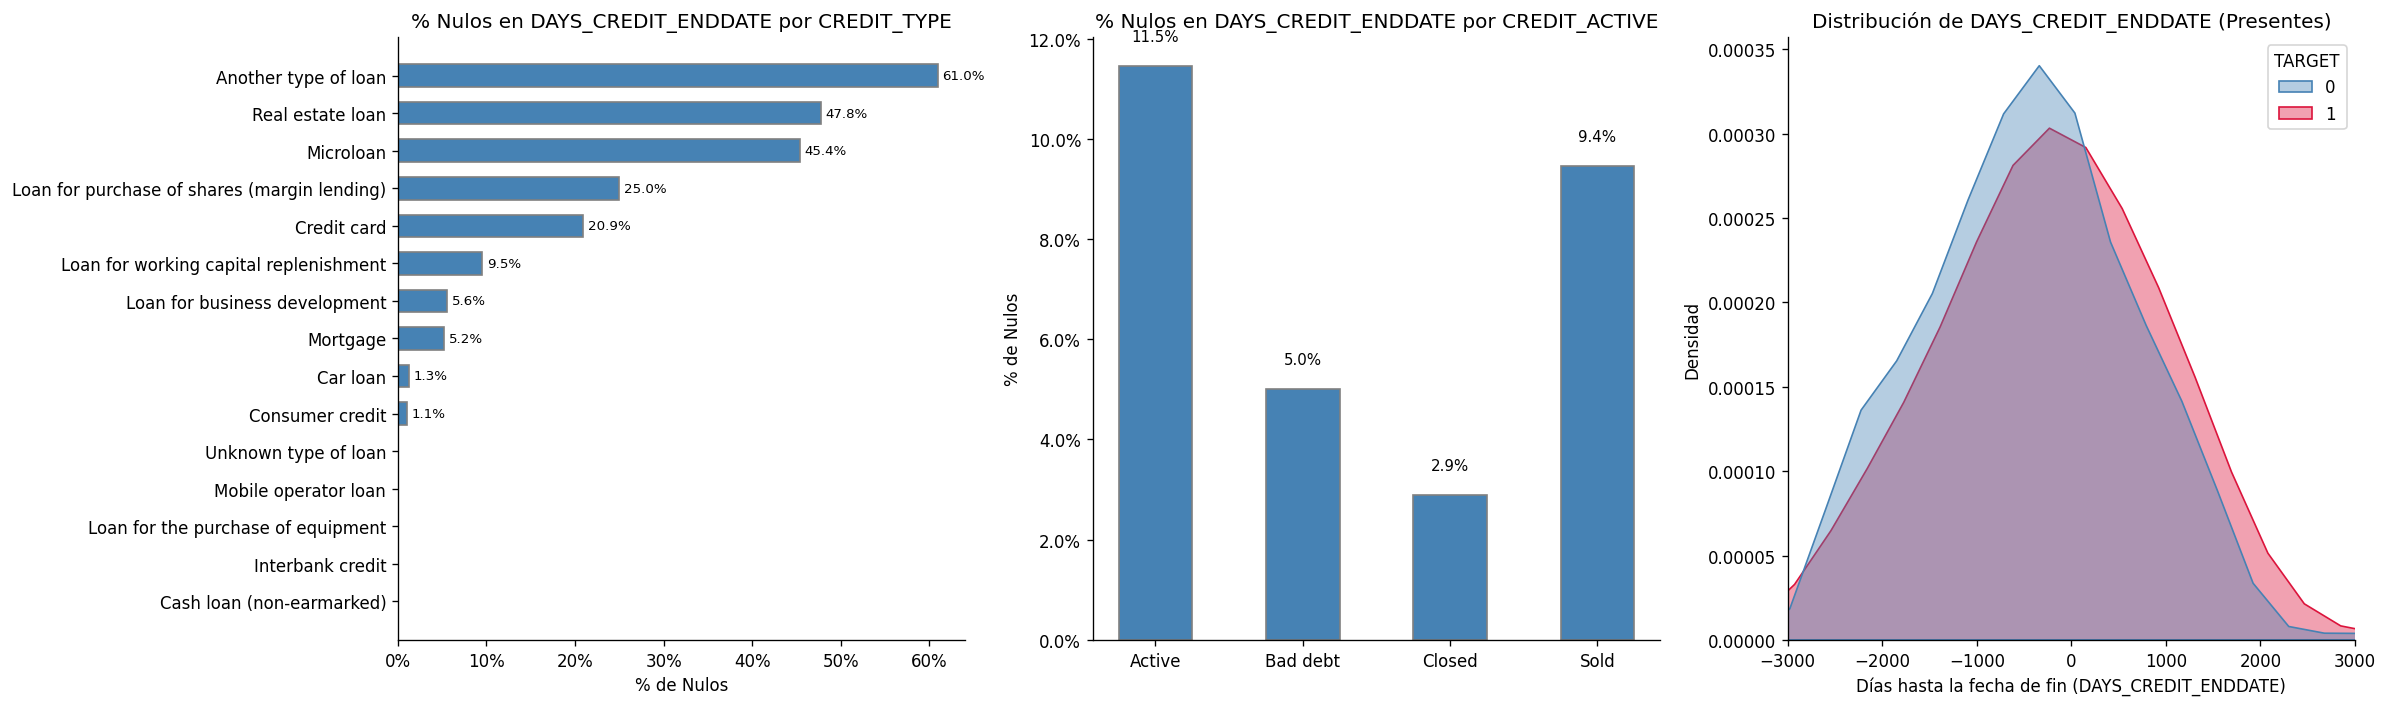

Chi2 Test (CREDIT_TYPE): Chi2 = 210019.44 | p-valor = 0.0
Chi2 Test (CREDIT_ACTIVE): Chi2 = 43961.56 | p-valor = 0.0


In [13]:
# DAYS_CREDIT_ENDDATE
is_null = bureau_t["DAYS_CREDIT_ENDDATE"].isnull()

# calculo las tablas de contingencia
ct_type = pd.crosstab(is_null, bureau_t["CREDIT_TYPE"])
ct_act = pd.crosstab(is_null, bureau_t["CREDIT_ACTIVE"])

# proporciones y p-valores
pct_type = (ct_type.loc[True] / ct_type.sum(axis=0) * 100).sort_values()
pct_active = (ct_act.loc[True] / ct_act.sum(axis=0) * 100)

chi2_t, p_val_t, _, _ = chi2_contingency(ct_type)
chi2_a, p_val_a, _, _ = chi2_contingency(ct_act)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# subplot 1: % de nulos por CREDIT_TYPE
bars = axes[0].barh(pct_type.index, pct_type.values, color=color_no_default, edgecolor='gray', height=0.6)
axes[0].set_title("% Nulos en DAYS_CREDIT_ENDDATE por CREDIT_TYPE")
axes[0].set_xlabel("% de Nulos")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars:
    width = bar.get_width()
    if width > 0:
        axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{round(width, 1)}%", va='center', fontsize=8)

# subplot 2: % de nulos por CREDIT_ACTIVE
bars2 = axes[1].bar(pct_active.index, pct_active.values, color=color_no_default, edgecolor='gray', width=0.5)
axes[1].set_title("% Nulos en DAYS_CREDIT_ENDDATE por CREDIT_ACTIVE")
axes[1].set_ylabel("% de Nulos")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{round(height, 1)}%", ha='center', fontsize=9)

# subplot 3: KDE de DAYS_CREDIT_ENDDATE por TARGET (solo valores presentes)
sns.kdeplot(
    data=bureau_t.loc[~is_null, ["DAYS_CREDIT_ENDDATE", "TARGET"]],
    x="DAYS_CREDIT_ENDDATE",
    hue="TARGET",
    fill=True,
    palette={0: color_no_default, 1: color_default},
    common_norm=False,
    ax=axes[2],
    alpha=0.4
)
axes[2].set_title("Distribución de DAYS_CREDIT_ENDDATE (Presentes)")
axes[2].set_xlabel("Días hasta la fecha de fin (DAYS_CREDIT_ENDDATE)")
axes[2].set_ylabel("Densidad")
axes[2].set_xlim(-3000, 3000)

plt.tight_layout()
plt.show()

print(f"Chi2 Test (CREDIT_TYPE): Chi2 = {round(chi2_t, 2)} | p-valor = {p_val_t}")
print(f"Chi2 Test (CREDIT_ACTIVE): Chi2 = {round(chi2_a, 2)} | p-valor = {p_val_a}")

Al cruzar el nulo de `DAYS_CREDIT_ENDDATE` con `CREDIT_TYPE` observo que los tipos con mayor tasa de nulos son "Another type of loan" (61,0%), "Real estate loan" (47,8%) y "Microloan" (45,4%), productos con plazos atípicos o indefinidos donde la fecha de fin no se define de forma estándar. Sin embargo, estos tipos contribuyen muy poco al volumen total de nulos por su baja frecuencia. "Credit card" aparece con una tasa de solo 20,9% pero al representar el 23,4% del dataset, domina así en volumen absoluto de nulos (el 80,8% de todos los nulos pertenecen a filas de 'Credit card'). Es decir, la mayoría de nulos se explican por productos revolving sin fecha de vencimiento fija, pero la tasa más alta de nulos está en productos minoritarios con plazos atípicos. Ambos factores apuntan a la dirección de que la ausencia de fecha de fin es estructural del tipo de producto, no un error de captura. el test Chi2 confirma la asociación (Chi2 = 210.019, p = 0).

Por otro lado, al cruzar con `CREDIT_ACTIVE`, los créditos 'Active' tienen 11,5% de nulos frente al 2,9% de 'Closed' (Chi2 = 43.962, p ≈ 0). Tiene sentido que un crédito cerrado tenga una fecha de fin real (el día que se liquidó), mientras que uno activo puede no tener fecha de fin programada si es revolving. Los créditos 'Sold' (9,4%) y 'Bad debt' (5,0%) quedan en una zona intermedia, lo que es coherente con créditos que nunca llegaron a cerrarse formalmente.

El KDE por `TARGET` de los valores presentes me hacer ver un patrón y es que cuando `TARGET`=1 (default) tiene mayor densidad en la zona cercana a 0 y positiva (es decir, créditos que terminan próximamente o en el futuro), mientras que cuando `TARGET`=0 concentra más densidad en la zona negativa (es decir, créditos que ya terminaron hace tiempo). Esto implica que los clientes que aún tienen créditos activos o a punto de vencer cuando solicitan el nuevo crédito en Home Credit son de mayor riesgo, lo cual conecta con la lógica de carga de deuda activa que ya observé con `AMT_ANNUITY` y con el perfil de búsqueda activa de
crédito identificado en `AMT_REQ_CREDIT_BUREAU_YEAR` en application_train.

La clasificación por tanto será **MAR vía CREDIT_TYPE**. Más adelante, `DAYS_CREDIT_ENDDATE` la calcularé solo para créditos a término ('Consumer credit', 'Car loan', 'Mortgage'), excluyendo 'Credit card' y tipos con plazos atípicos donde el concepto de "fecha de fin" no aplica. No requerirá por tanto flag de missing.

Estructura tripartita de AMT_CREDIT_MAX_OVERDUE:
 - Nulos (Falta info): 948545 (64.73%)
 - Ceros (Sin demora reportada): 409643 (27.96%)
 - Positivos (Mora real activa/histórica): 107137 (7.31%)
 - Proporción de ceros entre los presentes: 79.27%

Mann-Whitney U (cobertura temporal): p-val = 0.0 | Mediana presente = -867.0d | Mediana nulo = -1049.0d (Delta: +182.0d)



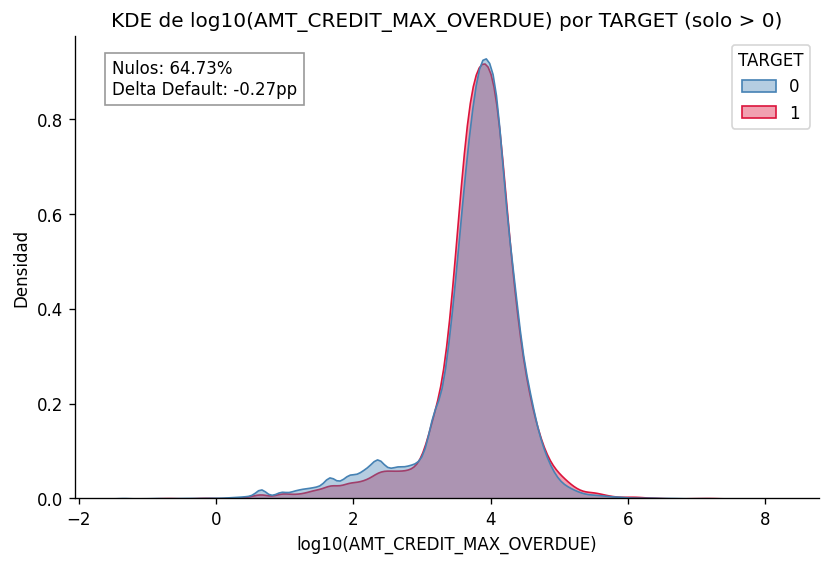

In [14]:
# AMT_CREDIT_MAX_OVERDUE
is_null_overdue = bureau_t["AMT_CREDIT_MAX_OVERDUE"].isnull()

# cuantifico la estructura de la variable
n_total = len(bureau_t)
n_null = is_null_overdue.sum()
n_zero = (bureau_t["AMT_CREDIT_MAX_OVERDUE"] == 0).sum()
n_positive = (bureau_t["AMT_CREDIT_MAX_OVERDUE"] > 0).sum()

print(f"Estructura tripartita de AMT_CREDIT_MAX_OVERDUE:")
print(f" - Nulos (Falta info): {n_null} ({round(n_null/n_total*100, 2)}%)")
print(f" - Ceros (Sin demora reportada): {n_zero} ({round(n_zero/n_total*100, 2)}%)")
print(f" - Positivos (Mora real activa/histórica): {n_positive} ({round(n_positive/n_total*100, 2)}%)")
print(f" - Proporción de ceros entre los presentes: {round(n_zero/(n_total-n_null)*100, 2)}%\n")

# aplico Mann-Whitney con DAYS_CREDIT
days_credit = bureau_t["DAYS_CREDIT"]
days_pres = days_credit[~is_null_overdue]
days_null = days_credit[is_null_overdue]

stat, p_val_mw = mannwhitneyu(days_pres, days_null)
med_pres, med_null = days_pres.median(), days_null.median()
print(f"Mann-Whitney U (cobertura temporal): p-val = {p_val_mw} | Mediana presente = {round(med_pres, 1)}d | Mediana nulo = {round(med_null, 1)}d (Delta: {med_pres - med_null:+.1f}d)\n")

# grafico KDE de AMT_CREDIT_MAX_OVERDUE (log-transformada, solo > 0) por TARGET
# selecciono y copio las dos columnas necesarias
valid_data = bureau_t.loc[~is_null_overdue & (bureau_t["AMT_CREDIT_MAX_OVERDUE"] > 0), ["AMT_CREDIT_MAX_OVERDUE", "TARGET"]].copy()
valid_data["log_val"] = np.log10(valid_data["AMT_CREDIT_MAX_OVERDUE"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=valid_data, x="log_val", hue="TARGET", fill=True, palette={0: color_no_default, 1: color_default}, common_norm=False, ax=ax, alpha=0.4)
ax.set_title("KDE de log10(AMT_CREDIT_MAX_OVERDUE) por TARGET (solo > 0)")
ax.set_xlabel("log10(AMT_CREDIT_MAX_OVERDUE)")
ax.set_ylabel("Densidad")

# anoto el % nulos y delta de la tabla maestra
ax.text(0.05, 0.95, f"Nulos: {round(n_null/n_total*100, 2)}%\nDelta Default: -0.27pp", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'), va='top')
plt.show()

La estructura de esta variable: 64,73% nulos (el buró no reporta mora máxima), 27,96% ceros (mora máxima reportada como 0, es decir, nunca ha tenido mora) y solo 7,31% con valores positivos (mora real histórica). Entre los valorespresentes, el 79,27% son exactamente 0. Esto significa que del total del dataset, solo 107.137 créditos (7,31%) tienen un historial real de mora máxima reportada. La variable por tanto nos indica que es muy dispersa.

El cruce con `DAYS_CREDIT` confirma el patrón temporal del buró: los créditos con valor presente tienen mediana de -867 días (2,4 años antes de la solicitud) frente a -1.049 días (2,9 años) para los nulos (Mann-Whitney p = 0, delta de +182 días). Los créditos más recientes tienen mayor probabilidad de tener este campo indicado, lo que indica que el buró fue incorporando este dato progresivamente y los créditos antiguos simplemente no lo tenían disponible. Esto respalda la clasificación **MCAR**: es decir, que la ausencia no predice el default (delta -0,27pp) sino que refleja la fuente temporal de la fuente de datos.

El KDE de los valores positivos (log-transformados, solo >0) por `TARGET` muestra que ambas clases comparten el mismo pico principal alrededor de log10 ≈ 4 (10.000 unidades monetarias), pero `TARGET`=1 presenta ligeramente más densidad en las colas (tanto en valores bajos de 10 a 100 como en valores extremos >100.000). La separación entre clases no es tan pronunciada como la que vi con `EXT_SOURCE_3` en application_train, pero la cola derecha (mora máxima muy alta) es donde probablemente esté la señal real, es decir, al analizar los extremos.

Más adelante, la estrategia de agregación para esta variable deberá reflejar la estructura: no bastará con un solo estadístico. La combinación más informativa sería un flag binario `BUREAU_HAS_ANY_OVERDUE` (1 si algún crédito del cliente tiene valor > 0
en esta variable) más el máximo entre todos los créditos del cliente (`BUREAU_MAX_OVERDUE_EVER`). El nulo se imputa con 0 **solo para agregar la magnitud**, que es donde la ausencia no predice default (-0,27pp) y el cero no distorsiona un máximo. **No vale como base de la presencia**: construir la marca como `> 0` sobre la columna ya imputada mete en el mismo grupo a "el buró no reportó mora" y a "el buró reportó que no hubo mora", que no son equivalentes sino dos poblaciones distintas, el 64,73% frente al 27,96%. Al agregar por cliente lo compruebo con cifras: 1.834 de los 3.334 clientes con mora viva quedan clasificados como sin mora histórica, cuando un impago vivo implica máximo histórico positivo por definición. Por eso la marca que conservo es la unión de las tres columnas de mora y no `AMT_CREDIT_MAX_OVERDUE > 0` a secas. El histórico mensual del buró resuelve esta misma estructura por el otro lado, mandando severidad e intensidad a nulo y nunca a cero, así que conviene no aplicar dos reglas distintas al mismo caso.

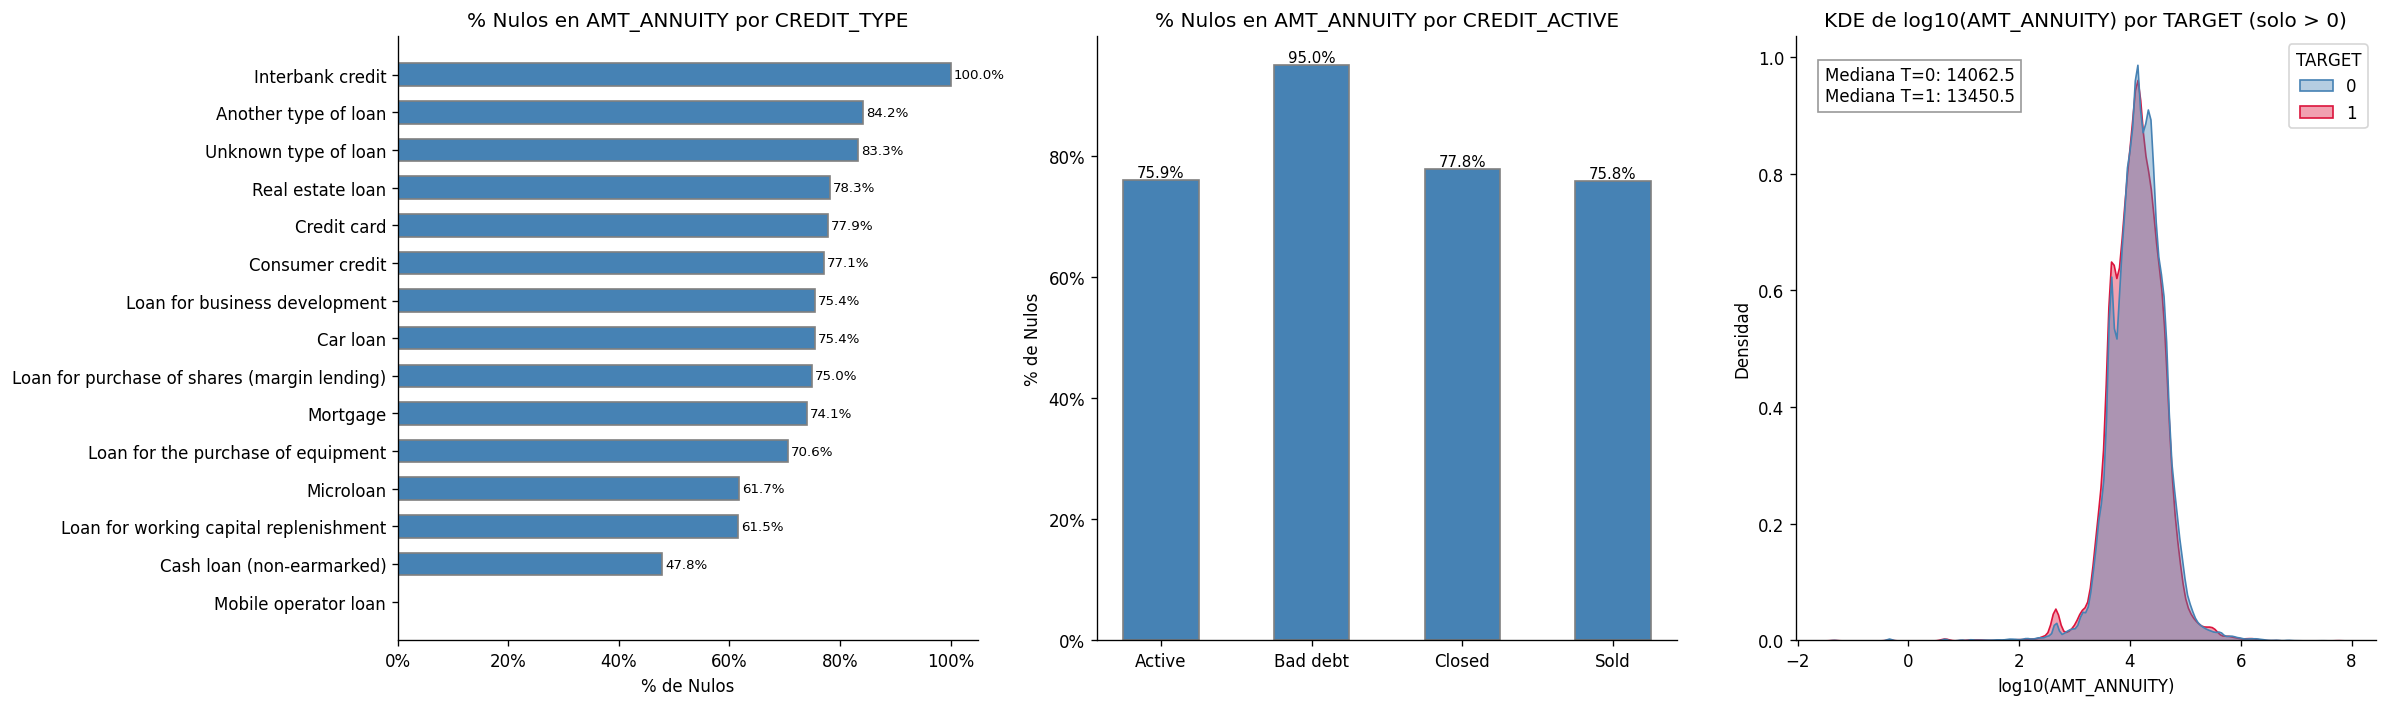

Chi2 Test (CREDIT_TYPE): Chi2 = 1538.51 | p-valor = 0.0
Chi2 Test (CREDIT_ACTIVE): Chi2 = 716.72 | p-valor = 4.965812933126639e-155


In [15]:
# AMT_ANNUITY
is_null_ann = bureau_t["AMT_ANNUITY"].isnull()

# obtengo las tablas de contingencia
ct_type_ann = pd.crosstab(is_null_ann, bureau_t["CREDIT_TYPE"])
ct_act_ann = pd.crosstab(is_null_ann, bureau_t["CREDIT_ACTIVE"])

# proporciones y p-valores
pct_type_ann = (ct_type_ann.loc[True] / ct_type_ann.sum(axis=0) * 100).sort_values()
pct_active_ann = (ct_act_ann.loc[True] / ct_act_ann.sum(axis=0) * 100)

chi2_t_ann, p_val_t_ann, _, _ = chi2_contingency(ct_type_ann)
chi2_a_ann, p_val_a_ann, _, _ = chi2_contingency(ct_act_ann)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# subplot 1: % Nulos en AMT_ANNUITY por CREDIT_TYPE
bars = axes[0].barh(pct_type_ann.index, pct_type_ann.values, color=color_no_default, edgecolor='gray', height=0.6)
axes[0].set_title("% Nulos en AMT_ANNUITY por CREDIT_TYPE")
axes[0].set_xlabel("% de Nulos")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars:
    width = bar.get_width()
    if width > 0:
        axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2, f"{round(width, 1)}%", va='center', fontsize=8)

# subplot 2: % Nulos en AMT_ANNUITY por CREDIT_ACTIVE
bars2 = axes[1].bar(pct_active_ann.index, pct_active_ann.values, color=color_no_default, edgecolor='gray', width=0.5)
axes[1].set_title("% Nulos en AMT_ANNUITY por CREDIT_ACTIVE")
axes[1].set_ylabel("% de Nulos")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{round(height, 1)}%", ha='center', fontsize=9)

# subplot 3: KDE de AMT_ANNUITY por TARGET (solo > 0)
valid_ann = ~is_null_ann & (bureau_t["AMT_ANNUITY"] > 0)
data_ann = bureau_t.loc[valid_ann, ["AMT_ANNUITY", "TARGET"]].copy()
data_ann["log_ann"] = np.log10(data_ann["AMT_ANNUITY"])
sns.kdeplot(data=data_ann, x="log_ann", hue="TARGET", fill=True, palette={0: color_no_default, 1: color_default}, common_norm=False, ax=axes[2], alpha=0.4)
axes[2].set_title("KDE de log10(AMT_ANNUITY) por TARGET (solo > 0)")
axes[2].set_xlabel("log10(AMT_ANNUITY)")
axes[2].set_ylabel("Densidad")

# anoto medianas
med_ann_t0 = data_ann.loc[data_ann["TARGET"] == 0, "AMT_ANNUITY"].median()
med_ann_t1 = data_ann.loc[data_ann["TARGET"] == 1, "AMT_ANNUITY"].median()
axes[2].text(0.05, 0.95, f"Mediana T=0: {med_ann_t0}\nMediana T=1: {med_ann_t1}", transform=axes[2].transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'), va='top')

plt.tight_layout()
plt.show()

print(f"Chi2 Test (CREDIT_TYPE): Chi2 = {round(chi2_t_ann, 2)} | p-valor = {p_val_t_ann}")
print(f"Chi2 Test (CREDIT_ACTIVE): Chi2 = {round(chi2_a_ann, 2)} | p-valor = {p_val_a_ann}")

Al cruzar el nulo con `CREDIT_TYPE`, la ausencia está distribuida uniformemente entre todos los tipos de crédito: desde 47,8% ('Cash loan non-earmarked') hasta 100% (Interbank credit'), con la mayoría de tipos concentrados en el rango del 70% al 85%. Ni 'Consumer credit' (77,1%) ni 'Credit card' (77,9%) destacan respecto al resto. Esto es distinto a lo que ocurría con `DAYS_CREDIT_ENDDATE`, donde 'Credit card' dominaba los nulos. Aquí ningún tipo de crédito explica la ausencia: el buró simplemente no reporta la cuota anual para la mayoría de los créditos independientemente de su tipo. Chi2 es significativo (1.538,51, p ≈ 0) pero refleja las diferencias marginales entre tipos, no concentración real.

Al cruzar con `CREDIT_ACTIVE`, el patrón es igual de uniforme: 'Active' 75,9%, 'Closed' 77,8%, 'Sold' 75,8%. Son prácticamente idénticos. 'Bad debt' tiene 95,0% pero con solo 20 obs por lo que es estadísticamente irrelevante. El estado del crédito tampoco explica la ausencia.

Que ni `CREDIT_TYPE` ni `CREDIT_ACTIVE` expliquen el nulo refuerza así la clasificación **MCAR** realizada antes, ya que la ausencia depende de la fuente de datos del buró (qué campos reporta para cada crédito) y no del tipo de producto ni de su estado. No hay un patrón de negocio detrás del 77% de nulos.

Lo más importante está en el KDE. Y es que el KDE de valores > 0 por `TARGET` muestra distribuciones prácticamente idénticas entre clases, con medianas de 14.062 para `TARGET`=0 y 13.450 para `TARGET`=1. Es decir, entre los créditos que sí reportan cuota y esta es mayor que cero, el importe de la cuota no discrimina entre clases.

Sin embargo, la tabla anterior mostraba medianas de 0,0 para TARGET=0 y 3.986,82 para TARGET=1 entre los valores presentes (no nulos). Probablemente, la señal no está en el importe de la cuota sino en la proporción de ceros entre clases. Para `TARGET`=0 más del 50% de los valores presentes son exactamente 0 (de ahí la mediana 0,0), mientras que para `TARGET`=1 menos del 50% son ceros (de ahí la mediana 3.986,82). En otras palabras, los clientes que van a hacer default tienen una mayor proporción de créditos con cuota activa reportada en el buró. Esto es coherente con la lógica de carga de deuda, es decir, que más líneas de crédito con pagos periódicos activos implican mayor presión financiera.

Esto implica que más adelante, la feature más informativa para `AMT_ANNUITY` no será la suma o media del importe de cuota, sino el conteo o ratio de créditos con cuota activa reportada (`BUREAU_CREDITS_WITH_ANNUITY_COUNT` o `BUREAU_ANNUITY_ACTIVE_RATIO`), que es donde realmente reside la señal discriminante.

In [16]:
# AMT_CREDIT_SUM_DEBT vs CREDIT_ACTIVE
ct_debt = pd.crosstab(bureau_t["AMT_CREDIT_SUM_DEBT"].isnull(), bureau_t["CREDIT_ACTIVE"], margins=True)
display(ct_debt)

# cálculo directo del porcentaje
pct_closed = (ct_debt.loc[True, "Closed"] / ct_debt.loc[True, "All"]) * 100
print(f"Porcentaje de nulos concentrados en Closed: {round(pct_closed, 2)}%")
print(f"¿Supera el 80%?: {'SÍ (Reclasificar a MAR parcial vía CREDIT_ACTIVE)' if pct_closed > 80.0 else 'NO (Mantener como MCAR)'}")

CREDIT_ACTIVE,Active,Bad debt,Closed,Sold,All
AMT_CREDIT_SUM_DEBT,,,,,
False,476602,14,763070,2545,1242231
True,65317,6,154663,3108,223094
All,541919,20,917733,5653,1465325


Porcentaje de nulos concentrados en Closed: 69.33%
¿Supera el 80%?: NO (Mantener como MCAR)


El 69,33% de los nulos se concentra en créditos 'Closed', por debajo del umbral del 80% para reclasificar como MAR. Sin embargo, el patrón sigue una lógica y es que la tasa de nulos por estado es 'Active' 12,1%, 'Closed' 16,9% y 'Sold' 55,0%. Que los créditos cerrados y vendidos tengan más nulos que los activos es coherente con que al liquidarse o transferirse un crédito el buró deja de reportar la deuda pendiente (que ya no existe). Pero la diferencia de tasas (12,1% vs 16,9%) no es lo suficientemente fuerte como para considerar que `CREDIT_ACTIVE` explica el missing de forma determinista.

Por lo que mantendré la clasificación **MCAR**. Así pues, más adelante imputaré con 0 para créditos con `CREDIT_ACTIVE = 'Closed'` (la deuda ya se liquidó) y mediana del subgrupo para créditos Active (donde el nulo refleja falta de reporte, no
ausencia de deuda).

In [17]:
# calculo V de Cramér de nulos y completitud por niveles
vars_cramer = ["AMT_ANNUITY", "AMT_CREDIT_MAX_OVERDUE", "AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_DEBT"]
null_df = bureau_t[vars_cramer].isnull()

# obtengo la matriz V de Cramér
cramer_matrix = null_df.corr().abs()
print("Matriz de V de Cramer para solapamiento de nulos:")
display(cramer_matrix.round(4))

# distribución de nulos simultáneos por fila
null_counts = null_df.sum(axis=1)
co_occurrence = bureau_t.groupby(null_counts)["TARGET"].agg(Observaciones="count", Default_Rate="mean")
co_occurrence["% Filas"] = co_occurrence["Observaciones"] / len(bureau_t) * 100
co_occurrence["Default Rate"] = co_occurrence["Default_Rate"] * 100
print("\nDistribución de nulos simultáneos por fila y tasa de default:")
display(co_occurrence[["Observaciones", "% Filas", "Default Rate"]].round(2))

# analizo la completitud en base a la estructura 3 comportamientos
nivel_series = np.select(
    [null_counts == 0, null_counts == 4],
    ["Completo (0 nulos)", "Todo nulo (4 nulos)"],
    default="Parcial (1-3 nulos)"
)
completitud_df = bureau_t.groupby(nivel_series)["TARGET"].agg(Observaciones="count", Default_Rate="mean")
completitud_df["% Filas"] = completitud_df["Observaciones"] / len(bureau_t) * 100
completitud_df["Default Rate"] = completitud_df["Default_Rate"] * 100
completitud_df = completitud_df.reindex(["Completo (0 nulos)", "Parcial (1-3 nulos)", "Todo nulo (4 nulos)"])
print("\nCompletitud por niveles agrupados y tasa de default:")
display(completitud_df[["Observaciones", "% Filas", "Default Rate"]].round(2))

# análisis par por par de asociacion de nulos
print("\nAnalisis de asociacion par por par (V de Cramer):")
for var1, var2 in combinations(vars_cramer, 2):
    v_val = cramer_matrix.loc[var1, var2]
    decision = (
        "V de Cramer alta (>0.30). Se sugiere flag compartido o agrupamiento." if v_val > 0.30 else
        "V de Cramer baja (<0.10). Se sugiere flag independiente por variable." if v_val < 0.10 else
        "V de Cramer intermedia (0.10 - 0.30). Evaluar individualmente."
    )
    print(f"- {var1} vs {var2}: V = {round(v_val, 4)}: {decision}")

# análisis de impacto en TARGET
dr_levels = completitud_df["Default Rate"]
max_delta_dr = dr_levels.max() - dr_levels.min()
print(f"\nDiferencia maxima de Default Rate entre niveles de completitud: {round(max_delta_dr, 2)}pp")
if max_delta_dr > 1.0:
    print("Variacion de default rate de completitud significativa (>1.0pp). Se sugiere crear feature numerica de conteo de nulos (BUREAU_NULLS_COUNT).")
else:
    print("Variacion de default rate de completitud baja (<1.0pp). No se justifica feature de conteo de nulos por este criterio.")


Matriz de V de Cramer para solapamiento de nulos:

,AMT_ANNUITY,AMT_CREDIT_MAX_OVERDUE,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_DEBT
AMT_ANNUITY,1.0,0.09,0.05,0.0
AMT_CREDIT_MAX_OVERDUE,0.09,1.0,0.3,0.03
AMT_CREDIT_SUM_LIMIT,0.05,0.3,1.0,0.6
AMT_CREDIT_SUM_DEBT,0.0,0.03,0.6,1.0



Distribución de nulos simultáneos por fila y tasa de default:


,Observaciones,% Filas,Default Rate
0,76778,5.24,9.46
1,500653,34.17,8.06
2,488007,33.3,7.41
3,284893,19.44,7.64
4,114994,7.85,7.81



Completitud por niveles agrupados y tasa de default:


,Observaciones,% Filas,Default Rate
Completo (0 nulos),76778,5.24,9.46
Parcial (1-3 nulos),1273553,86.91,7.72
Todo nulo (4 nulos),114994,7.85,7.81



Analisis de asociacion par por par (V de Cramer):
- AMT_ANNUITY vs AMT_CREDIT_MAX_OVERDUE: V = 0.0901: V de Cramer baja (<0.10). Se sugiere flag independiente por variable.
- AMT_ANNUITY vs AMT_CREDIT_SUM_LIMIT: V = 0.0458: V de Cramer baja (<0.10). Se sugiere flag independiente por variable.
- AMT_ANNUITY vs AMT_CREDIT_SUM_DEBT: V = 0.0028: V de Cramer baja (<0.10). Se sugiere flag independiente por variable.
- AMT_CREDIT_MAX_OVERDUE vs AMT_CREDIT_SUM_LIMIT: V = 0.3009: V de Cramer alta (>0.30). Se sugiere flag compartido o agrupamiento.
- AMT_CREDIT_MAX_OVERDUE vs AMT_CREDIT_SUM_DEBT: V = 0.0323: V de Cramer baja (<0.10). Se sugiere flag independiente por variable.
- AMT_CREDIT_SUM_LIMIT vs AMT_CREDIT_SUM_DEBT: V = 0.5979: V de Cramer alta (>0.30). Se sugiere flag compartido o agrupamiento.

Diferencia maxima de Default Rate entre niveles de completitud: 1.74pp
Variacion de default rate de completitud significativa (>1.0pp). Se sugiere crear feature numerica de conteo de nulos (BURE

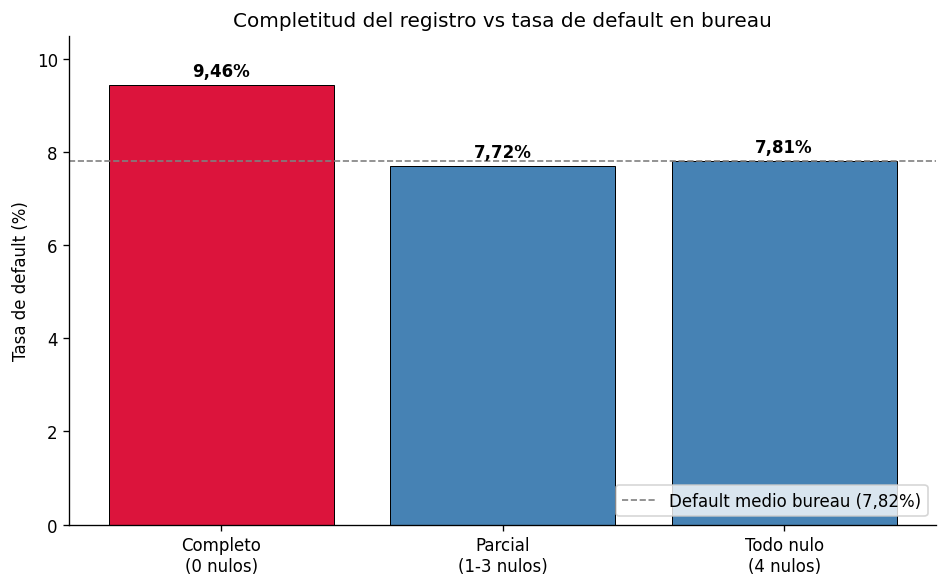

In [18]:
# grafica de barras: completitud del registro vs default en bureau
niveles = ["Completo\n(0 nulos)", "Parcial\n(1-3 nulos)", "Todo nulo\n(4 nulos)"]
dr = completitud_df["Default Rate"].values
default_medio = bureau_t["TARGET"].mean() * 100

# resalto en crimson el grupo más arriesgado (el de ficha completa, contraintuitivo)
colores = ["crimson", "steelblue", "steelblue"]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(niveles, dr, color=colores, edgecolor="black", linewidth=0.6)
ax.axhline(default_medio, color="gray", linestyle="--", linewidth=1,
           label=f"Default medio bureau ({round(default_medio, 2)}%)".replace(".", ","))
for b, v in zip(barras, dr):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.1, f"{round(v, 2)}%".replace(".", ","),
            ha="center", va="bottom", fontweight="bold")
ax.set(title="Completitud del registro vs tasa de default en bureau",
       ylabel="Tasa de default (%)")
ax.set_ylim(0, 10.5)
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

La matriz de V de Cramér entre las 4 variables con más nulos nos hace observar dos clusters diferenciados:

`AMT_CREDIT_SUM_LIMIT` y `AMT_CREDIT_SUM_DEBT` comparten nulos fuertemente (V = 0,60). Esto es coherente con lo observado anteriormente ya que ambas dependen de la misma dimensión (si el buró reporta detalle financiero del crédito o no). Por tanto, sus nulos tienden a coincidir en las mismas filas.

`AMT_CREDIT_MAX_OVERDUE` tiene asociación moderada con `AMT_CREDIT_SUM_LIMIT` (V = 0,30) pero baja con `AMT_CREDIT_SUM_DEBT` (V = 0,03) y con `AMT_ANNUITY` (V = 0,09). Su patrón de nulos depende más de la antigüedad del crédito (cobertura temporal del buró, confirmado en el análisis anterior) que de los mismos factores que explican LIMIT/DEBT.

`AMT_ANNUITY` es completamente independiente de las otras tres (V < 0,10 con todas). Su patrón de nulos (77% uniforme entre tipos y estados) responde a que si la fuente del buró reporta o no la cuota para ese crédito concreto, sin relación con la presencia de las demás variables.

La decisión de crear un único flag unificado `HAS_COMPLETE_BUREAU_DATA` como había planteado previamente no es correcta. Perdería la independencia de `AMT_ANNUITY` y mezclaría señales distintas. La estrategia que seguiré será:

- `AMT_CREDIT_SUM_LIMIT` + `AMT_CREDIT_SUM_DEBT`: flag compartido `HAS_BUREAU_FINANCIAL_DETAIL` (1 si ambas presentes, 0 si alguna falta), dado que sus nulos coinciden (V = 0,60).
- `AMT_CREDIT_MAX_OVERDUE`: flag independiente `HAS_BUREAU_OVERDUE_HISTORY`.
- `AMT_ANNUITY`: flag independiente `HAS_BUREAU_ANNUITY`, confirmado como el patrón más aislado de los cuatro.

Respecto a la completitud vs `TARGET`:

- Completo (0 nulos): 9,46% default, el más alto
- Parcial (de 1 a 3 nulos): 7,72%
- Todo nulo (4 nulos): 7,81%

Que el grupo con información completa tenga mayor default es contraintuitivo a primera vista pero coherente con la lógica de bureau ya que tener registros completos y detallados en el buró implica mayor actividad crediticia (más productos, más consultas, más deuda reportada), lo que se asocia con mayor presión financiera y mayor riesgo. Es el opuesto del bloque de edificio en application_train, donde la ausencia total reflejaba pensionistas conservadores con bajo riesgo. Aquí la ausencia total puede reflejar créditos antiguos o simples donde el buró no cubre ciertos campos, sin implicación de riesgo.

La diferencia máxima de default rate entre niveles es de 1,74pp (Completo 9,46% vs Parcial 7,72%), por debajo del umbral de 2pp pero lo suficientemente cerca como para justificar el crear una feature de conteo de nulos por crédito (`BUREAU_NULL_COUNT_PER_CREDIT`), además de los flags individuales mencionados. (Nota: su validación a nivel cliente se pospone a la fase de features; aquí no se mide.)

In [19]:
# hacemos una conexión con application_train para verificar redundancia de missings
app_train_sub = load_table("application_train", usecols=["SK_ID_CURR", "TARGET", "AMT_REQ_CREDIT_BUREAU_YEAR"])

# variables booleanas 
sin_bureau = ~app_train_sub["SK_ID_CURR"].isin(bureau["SK_ID_CURR"])
sin_req = app_train_sub["AMT_REQ_CREDIT_BUREAU_YEAR"].isnull()

n_sin_bureau = sin_bureau.sum()
n_sin_req = sin_req.sum()
n_inter = (sin_bureau & sin_req).sum()

pct_inter_bureau = (n_inter / n_sin_bureau) * 100 if n_sin_bureau > 0 else 0.0
pct_inter_req = (n_inter / n_sin_req) * 100 if n_sin_req > 0 else 0.0

print(f"Clientes sin historial en bureau: {n_sin_bureau}")
print(f"Clientes con AMT_REQ_CREDIT_BUREAU_* nulo en application_train: {n_sin_req}")
print(f"Intersección (ambos vacíos): {n_inter}")
print(f"Solo sin historial en bureau (tienen req): {n_sin_bureau - n_inter}")
print(f"Solo sin req (tienen historial en bureau): {n_sin_req - n_inter}")
print(f"Coincidencia respecto a sin_bureau: {round(pct_inter_bureau, 2)}%")
print(f"Coincidencia respecto a sin_req: {round(pct_inter_req, 2)}%")

# analizo las tasas de default por grupo
temp_groups = np.select(
    [sin_bureau & sin_req, sin_bureau],
    ["Ambos vacíos (Intersección)", "Solo sin historial en bureau"],
    default="Ambas informaciones presentes"
)

grupo_df = app_train_sub.groupby(temp_groups)["TARGET"].agg(Observaciones="count", Default_Rate="mean")
grupo_df["% Filas"] = grupo_df["Observaciones"] / len(app_train_sub) * 100
grupo_df["Default Rate"] = grupo_df["Default_Rate"] * 100
grupo_df = grupo_df.reindex([
    "Ambas informaciones presentes", 
    "Ambos vacíos (Intersección)", 
    "Solo sin historial en bureau"
]).dropna(subset=["Observaciones"])

print("\nTasa de default por grupo de cruce:")
display(grupo_df[["Observaciones", "% Filas", "Default Rate"]].round(2))

# automatizo la decisión en base a los resultados
redundancia = pct_inter_bureau > 85.0 and pct_inter_req > 85.0

print("\nConclusión y decisión")
if redundancia:
    print("La coincidencia entre ambas señales es extremadamente alta (>85%).")
    print("Las dos variables representan la misma dimensión de información redundante.")
    print("Decisión futura: Conservare una única variable. Prefiero crear el flag 'HAS_BUREAU_HISTORY'")
    print("basado en la presencia física del cliente en la tabla bureau (más directo y fiable).")
else:
    print("La coincidencia es baja o hay un volumen relevante de clientes en solo_sin_amt_req.")
    print("Las dos variables son complementarias y tienen patrones de missing/comportamiento diferenciados.")
    print("Decisión para la fase de features: mantener ambas variables de forma independiente.")


Clientes sin historial en bureau: 44020
Clientes con AMT_REQ_CREDIT_BUREAU_* nulo en application_train: 41519
Intersección (ambos vacíos): 41519
Solo sin historial en bureau (tienen req): 2501
Solo sin req (tienen historial en bureau): 0
Coincidencia respecto a sin_bureau: 94.32%
Coincidencia respecto a sin_req: 100.0%

Tasa de default por grupo de cruce:


,Observaciones,% Filas,Default Rate
Ambas informaciones presentes,263491,85.69,7.73
Ambos vacíos (Intersección),41519,13.5,10.34
Solo sin historial en bureau,2501,0.81,6.6



Conclusión y decisión
La coincidencia entre ambas señales es extremadamente alta (>85%).
Las dos variables representan la misma dimensión de información redundante.
Decisión futura: Conservare una única variable. Prefiero crear el flag 'HAS_BUREAU_HISTORY'
basado en la presencia física del cliente en la tabla bureau (más directo y fiable).


Esta verificación confirma que las 2 señales son casi completamente redundantes: los 41.519 clientes con `AMT_REQ_CREDIT_BUREAU_*` nulo en application_train están contenidos al 100% dentro de los 44.020 sin historial en bureau. En la dirección inversa, el 94,32% de los clientes sin bureau también tienen el campo de consultas nulo. Son la misma
dimensión de información, es decir, "cliente sin presencia en el sistema del buró de crédito".

Sin embargo, hay un grupo minúsculo de 2.501 clientes (0,81% del dataset) que no tienen historial físico en bureau pero sí tienen valores en `AMT_REQ_CREDIT_BUREAU_*`. Esto significa que el buró registró consultas sobre estos clientes (alguien preguntó por ellos) pero no tienen ningún crédito previo reportado. Es un perfil muy específico debido a que son clientes que
han sido evaluados por otras entidades pero nunca llegaron a obtener crédito, o cuyo crédito fue tan breve que no dejó registro. Su tasa de default es la más baja de los tres grupos (6,60%), lo que tiene lógica, ya que si una entidad consultó tu historial y no te concedió crédito, puede ser por prudencia de la entidad, no por riesgo del cliente.

Las tasas de default por grupo indican lo siguiente:

- Ambas informaciones presentes (263.491, 85,69%): 7,73% default
- Ambas vacías (41.519, 13,50%): 10,34% default, el grupo de mayor riesgo
- Solo sin bureau pero con consultas (2.501, 0,81%): 6,60% default, el de menor riesgo

La decisión que tomó para aplicar más adelante (FE) es conservar únicamente `HAS_BUREAU_HISTORY` basado en la presencia física del cliente en la tabla bureau, ya que es más directo y fiable que depender del campo de consultas de application_train. El flag de nulo de `AMT_REQ_CREDIT_BUREAU_*` en application_train se eliminará por redundancia (confirmada ahora mismo) (100% de solapamiento en una dirección, 94,32% en la otra). Los 2.501 clientes del grupo ínfimo quedarán capturados correctamente por `HAS_BUREAU_HISTORY = 0` y su perfil de bajo riesgo será visible para el modelo a través de otras variables (probablemente `EXT_SOURCE` y edad, dado que son clientes evaluados pero sin crédito formal).

### 6. Análisis Correlaciones

Ranking de correlación de Pearson con TARGET:


,Pearson_r,Abs_Pearson_r
DAYS_CREDIT,0.06,0.06
DAYS_CREDIT_UPDATE,0.04,0.04
DAYS_ENDDATE_FACT,0.04,0.04
DAYS_CREDIT_ENDDATE,0.03,0.03
AMT_CREDIT_SUM,-0.01,0.01
AMT_CREDIT_SUM_OVERDUE,0.01,0.01
AMT_CREDIT_SUM_LIMIT,-0.01,0.01
CREDIT_DAY_OVERDUE,0.0,0.0
AMT_CREDIT_SUM_DEBT,0.0,0.0
AMT_CREDIT_MAX_OVERDUE,0.0,0.0



Comparación Spearman vs Pearson (Variables Asimétricas):
- CREDIT_DAY_OVERDUE: Pearson r = 0.0027, Spearman rho = 0.0195, Ratio = 7.35
- AMT_CREDIT_SUM_OVERDUE: Pearson r = 0.0063, Spearman rho = 0.0202, Ratio = 3.24
- CNT_CREDIT_PROLONG: Pearson r = 0.0015, Spearman rho = 0.0026, Ratio = 1.74

Comparación Spearman vs Pearson (Variables Temporales):


- DAYS_CREDIT: Pearson r = 0.0616, Spearman rho = 0.0663, Ratio = 1.08: relación Lineal
- DAYS_CREDIT_UPDATE: Pearson r = 0.0411, Spearman rho = 0.054, Ratio = 1.31: relación Monótona no lineal


- DAYS_ENDDATE_FACT: Pearson r = 0.0391, Spearman rho = 0.0414, Ratio = 1.06: relación Lineal


- DAYS_CREDIT_ENDDATE: Pearson r = 0.0265, Spearman rho = 0.0504, Ratio = 1.9: relación Monótona no lineal


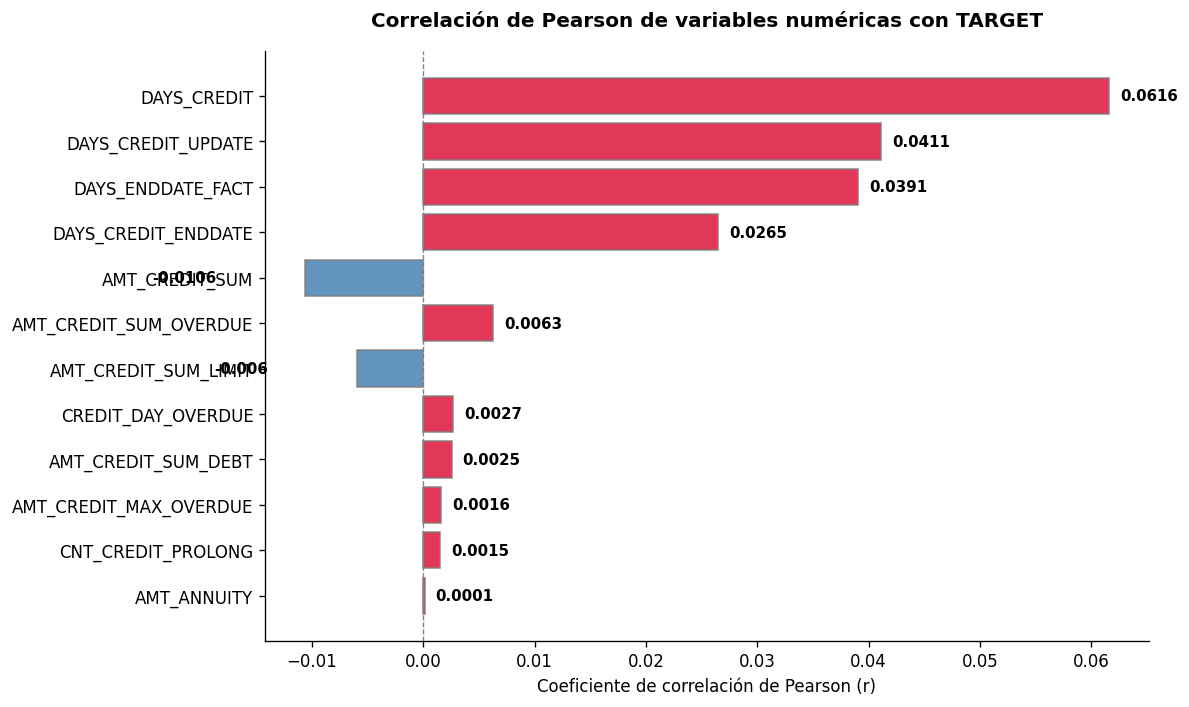

In [20]:
# correlación de variables numéricas con TARGET (Pearson y Spearman)
num_cols = [
    "DAYS_CREDIT", "CREDIT_DAY_OVERDUE", "DAYS_CREDIT_ENDDATE", "DAYS_ENDDATE_FACT",
    "AMT_CREDIT_MAX_OVERDUE", "CNT_CREDIT_PROLONG", "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT", "AMT_CREDIT_SUM_OVERDUE", "DAYS_CREDIT_UPDATE", "AMT_ANNUITY"
]

# pearson
pearson_df = bureau_t[num_cols].corrwith(bureau_t["TARGET"]).to_frame(name="Pearson_r")
pearson_df["Abs_Pearson_r"] = pearson_df["Pearson_r"].abs()
pearson_df = pearson_df.sort_values(by="Abs_Pearson_r", ascending=False)

print("Ranking de correlación de Pearson con TARGET:")
display(pearson_df.round(4))

# spearman para variables asimétricas
asym_cols = ["CREDIT_DAY_OVERDUE", "AMT_CREDIT_SUM_OVERDUE", "CNT_CREDIT_PROLONG"]
print("\nComparación Spearman vs Pearson (Variables Asimétricas):")
for col in asym_cols:
    valid_col = bureau_t[col].dropna()
    sr, _ = spearmanr(valid_col, bureau_t.loc[valid_col.index, "TARGET"])
    pr = pearson_df.loc[col, "Pearson_r"]
    ratio = sr / pr if pr != 0 else np.nan
    print(f"- {col}: Pearson r = {round(pr, 4)}, Spearman rho = {round(sr, 4)}, Ratio = {round(ratio, 2)}")

# comparación para variables temporales (DAYS_*)
temp_cols = ["DAYS_CREDIT", "DAYS_CREDIT_UPDATE", "DAYS_ENDDATE_FACT", "DAYS_CREDIT_ENDDATE"]
print("\nComparación Spearman vs Pearson (Variables Temporales):")
for col in temp_cols:
    valid_col = bureau_t[col].dropna()
    sr, _ = spearmanr(valid_col, bureau_t.loc[valid_col.index, "TARGET"])
    pr = pearson_df.loc[col, "Pearson_r"]
    ratio = sr / pr if pr != 0 else np.nan
    tipo = "Lineal" if abs(ratio - 1.0) <= 0.15 else "Monótona no lineal"
    print(f"- {col}: Pearson r = {round(pr, 4)}, Spearman rho = {round(sr, 4)}, Ratio = {round(ratio, 2)}: relación {tipo}")

# gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 6))
colors = np.where(pearson_df["Pearson_r"] < 0, color_no_default, color_default)
bars = ax.barh(pearson_df.index[::-1], pearson_df["Pearson_r"][::-1], color=colors[::-1], edgecolor="grey", alpha=0.85)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (0.001 if width >= 0 else -0.008),
        bar.get_y() + bar.get_height()/2,
        f"{round(width, 4)}",
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

ax.set_title("Correlación de Pearson de variables numéricas con TARGET", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Coeficiente de correlación de Pearson (r)", fontsize=10)
plt.tight_layout()
plt.show()

El ranking de correlaciones con TARGET está dominado completamente por las variables temporales: `DAYS_CREDIT` (r = 0,0616), `DAYS_CREDIT_UPDATE` (r = 0,0411), `DAYS_ENDDATE_FACT` (r = 0,0391) y `DAYS_CREDIT_ENDDATE` (r = 0,0265) ocupan las cuatro primeras posiciones. Todas muestran coeficientes positivos, indicando que créditos más recientes (valores más cercanos a cero) se asocian con mayor riesgo del cliente. Esto es coherente con el perfil de "buscador activo de crédito" que identifiqué en application_train (con +2,97pp en la tasa de default para consultas recurrentes en el buró).

Para evaluar en profundidad este bloque temporal, analicé el desarrollo de cada una de estas cuatro variables comparando sus coeficientes de Pearson y Spearman. Para la variable `DAYS_CREDIT`, el coeficiente de Pearson de 0,0616 y el de Spearman de 0,0663 arrojan un ratio de 1,08. Esperaba que una mayor recencia de la solicitud se asociara con un mayor riesgo de default, y encontré que esta relación se mantiene de forma bastante lineal, dado que el ratio es cercano a la unidad. En el caso de `DAYS_CREDIT_UPDATE`, el coeficiente de Pearson de 0,0411 contrasta con un Spearman de 0,0540, resultando en un ratio de 1,31. Esperaba que actualizaciones muy recientes en los registros reflejaran comportamiento de búsqueda activa de financiación de alto riesgo, y encontré que esta relación es monótona no lineal, donde la acumulación de datos en fechas muy recientes aplana la correlación lineal de Pearson. Para `DAYS_ENDDATE_FACT`, la correlación de Pearson es de 0,0391 y la de Spearman es de 0,0414 (ratio de 1,06). Esperaba que cierres recientes de préstamos indicaran mayor riesgo y encontré una relación baja pero predominantemente lineal. Por último, `DAYS_CREDIT_ENDDATE` muestra el comportamiento más extremo: un Pearson de 0,0265 frente a un Spearman de 0,0504, lo que supone un ratio de 1,90. Esperaba que fechas de vencimiento lejanas en el futuro se correlacionaran con el perfil del cliente, y encontré una relación fuertemente monótona no lineal, debido a que la existencia de vencimientos extremos a muy largo plazo (outliers de captura) distorsiona la covarianza lineal de Pearson, mientras que Spearman rescata la señal real mediante el orden de rangos.

La correlación de Pearson más alta (0,0616) es comparable a `REGION_RATING_CLIENT_W_CITY` (0,061) en application_train pero está muy por debajo de los EXT_SOURCE (-0,155 a -0,179). Esto confirma lo que anticipé anteriormente y es que la señal individual de bureau a nivel fila es débil. El valor predictivo real probablemente surja del siguiente tratamiento (máximo de mora, ratio de deuda, conteo de créditos activos vs cerrados) más que de variables individuales.

Las variables financieras tienen correlaciones prácticamente nulas con TARGET a nivel fila: `AMT_CREDIT_SUM` (-0,0106), `AMT_CREDIT_SUM_OVERDUE` (0,0063), `AMT_CREDIT_SUM_LIMIT` (-0,0060), `AMT_CREDIT_SUM_DEBT` (0,0025), `AMT_CREDIT_MAX_OVERDUE` (0,0016), `AMT_ANNUITY` (0,0001). Esto no significa que no tengan señal ya que en application_train las variables del edificio AVG también tenían correlaciones individuales bajas (-0,044 max) pero la señal del bloque como conjunto era consistente. Lo mismo puede ocurrir aquí cuando se agregue por cliente más adelante.

`AMT_CREDIT_SUM` tiene correlación negativa (-0,0106), el mismo patrón que `AMT_CREDIT`/`AMT_GOODS_PRICE` en application_train (créditos más grandes = perfil más solvente). `AMT_CREDIT_SUM_LIMIT` también negativa (-0,0060), coherente con que tener mayor límite de tarjeta implica mejor perfil crediticio evaluado por el banco emisor.

La comparativa Spearman vs Pearson confirma relaciones no lineales en las variables de mora: `CREDIT_DAY_OVERDUE` tiene Spearman 7 veces mayor que Pearson (0,0195 vs 0,0027) y `AMT_CREDIT_SUM_OVERDUE` 3 veces mayor (0,0202 vs 0,0063). Esto es exactamente el patrón que supuse, en donde variables concentradas en 0 con cola de eventos raros donde la relación es monótona (más mora implica así más riesgo) pero no lineal (Pearson subestima porque la masa en 0 aplana la correlación). La señal de estas variables estará en la cola, como ya ocurrió en el eda anterior con `DEF_60_CNT_SOCIAL_CIRCLE` en application_train. `CNT_CREDIT_PROLONG` apenas cambia (0,0026 vs 0,0015), confirmando que su señal es tan débil que ni Spearman la capta, lo que refuerza la decisión de que la trate como flag binario (`HAS_BEEN_PROLONGED`) en la agregación posterior.


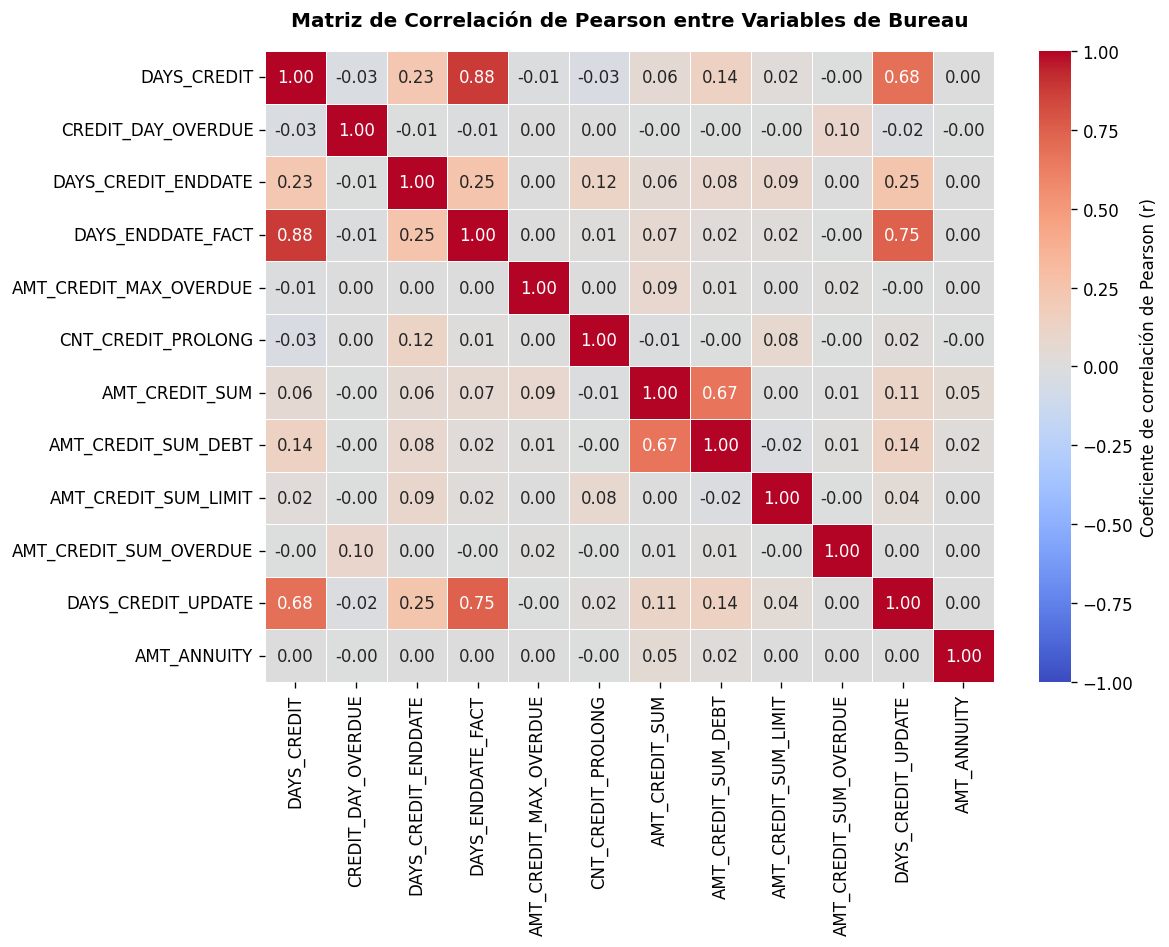

Pares de variables con correlación |r| > 0.7:


,Variable 1,Variable 2,Pearson_r
0,DAYS_CREDIT,DAYS_ENDDATE_FACT,0.88
1,DAYS_ENDDATE_FACT,DAYS_CREDIT_UPDATE,0.75


In [21]:
# matriz de correlación entre variables numéricas (multicolinealidad)
corr_matrix = bureau_t[num_cols].corr()

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson (r)'}
)
plt.title("Matriz de Correlación de Pearson entre Variables de Bureau", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# extracción de parejas con |r| > 0.7
high_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
high_corr_df = high_corr[high_corr.abs() > 0.7].reset_index()
high_corr_df.columns = ["Variable 1", "Variable 2", "Pearson_r"]
high_corr_df = high_corr_df.sort_values(by="Pearson_r", key=abs, ascending=False)

print("Pares de variables con correlación |r| > 0.7:")
display(high_corr_df.round(4))

La matriz identifica dos pares con |r| > 0,7 y un cluster temporal que merece atención:

`DAYS_CREDIT` vs `DAYS_ENDDATE_FACT` (r = 0,88): es la correlación más alta de toda la matriz. Tiene lógica ya que cuándo se solicitó el crédito y cuándo terminó realmente están vinculados por la duración del crédito. Sin embargo no son redundantes para el modelo porque capturan conceptos distintos: Puesto que `DAYS_CREDIT` mide la antigüedad del crédito (cuándo se pidió) y `DAYS_ENDDATE_FACT` mide la recencia del cierre (cuándo se pagó). Además, `DAYS_ENDDATE_FACT` tiene un 37,17% de nulos (solo créditos cerrados) mientras que `DAYS_CREDIT` está completo. Más adelante agregaré `DAYS_CREDIT` por `min` y por `max`, que no son lo mismo: el `min` es el crédito más antiguo, o sea la longitud del historial, y el `max` es el más reciente, la recencia de la última solicitud. De `DAYS_ENDDATE_FACT` tomaré el `min`, que es el cierre más antiguo, no el último.

`DAYS_ENDDATE_FACT` vs `DAYS_CREDIT_UPDATE` (r = 0,75): también alta. La última
actualización del buró tiende a ocurrir alrededor de cuando el crédito se cierra, lo que tiene sentido (el cierre genera la última actualización del registro). Al igual que el par anterior, no son redundantes conceptualmente: `DAYS_ENDDATE_FACT` mide un evento que es negocio (cierre del crédito) y `DAYS_CREDIT_UPDATE` mide un evento administrativo (última vez que el buró actualizó la información). Más adelante ambas podrán aportar señal.

`DAYS_CREDIT` vs `DAYS_CREDIT_UPDATE` (r = 0,68): justo por debajo del umbral de 0,70. no requiere tratamiento por multicolinealidad pero confirma que las tres variables temporales (`DAYS_CREDIT`, `DAYS_ENDDATE_FACT`, `DAYS_CREDIT_UPDATE`) forman un cluster correlacionado. Al mirar el eje temporal evaluaré si las tres aportan señal independiente contra `TARGET` o si alguna es prescindible.

`AMT_CREDIT_SUM` vs `AMT_CREDIT_SUM_DEBT` (r = 0,67): la hipótesis que supuse de que estarían altamente correlacionadas se confirma. 0,67 es alta pero por debajo del umbral. Tiene sentido ya que créditos más grandes tienden a tener más deuda pendiente en términos absolutos, pero no de forma proporcional (hay créditos grandes ya casi liquidados y créditos pequeños con deuda activa completa). Ambas se conservan y más adelante el ratio `BUREAU_DEBT_CREDIT_RATIO` (deuda/crédito) capturará la información, igual que el ratio LTV en application_train.

El resto de pares tiene correlaciones bajas (<0,25). Destaca que las variables de mora (`CREDIT_DAY_OVERDUE`, `AMT_CREDIT_MAX_OVERDUE`, `AMT_CREDIT_SUM_OVERDUE`) no están correlacionadas entre sí (máximo 0,10), lo que confirma que capturan dimensiones distintas del mismo fenómeno.

In [22]:
# correlaciones de validación cruzada
print("Validación de hipótesis:")
pairs = [
    ("AMT_ANNUITY", "AMT_CREDIT_SUM"),
    ("DAYS_CREDIT", "DAYS_CREDIT_UPDATE"),
    ("DAYS_CREDIT", "DAYS_CREDIT_ENDDATE"),
    ("CREDIT_DAY_OVERDUE", "AMT_CREDIT_SUM_OVERDUE")
]
for v1, v2 in pairs:
    print(f"- {v1} vs {v2} (r = {round(corr_matrix.loc[v1, v2], 4)})")

Validación de hipótesis:
- AMT_ANNUITY vs AMT_CREDIT_SUM (r = 0.0516)
- DAYS_CREDIT vs DAYS_CREDIT_UPDATE (r = 0.6832)
- DAYS_CREDIT vs DAYS_CREDIT_ENDDATE (r = 0.2311)
- CREDIT_DAY_OVERDUE vs AMT_CREDIT_SUM_OVERDUE (r = 0.0958)


`AMT_ANNUITY` vs `AMT_CREDIT_SUM` (r = 0,0516): prácticamente independientes. Esto
confirma que el hallazgo sobre `AMT_ANNUITY` al analizar la ausencia de dato (la señal de `AMT_ANNUITY` está en la proporción de
ceros por clase, no en el importe) no es un artefacto de estar midiendo lo mismo que
`AMT_CREDIT_SUM`. Son variables con información distinta y la feature de ratio/conteo
de créditos con cuota activa que planteé a nivel cliente es genuinamente nueva, no
redundante con el tamaño del crédito.

`DAYS_CREDIT` vs `DAYS_CREDIT_UPDATE` (r = 0,6832): correlación alta pero por debajo
de 0,70. No son redundantes pero comparten varianza sustancial. Esto matiza lo que
anticipé: no basta con agregar ambas por separado a nivel cliente, hay que verificar en la
al mirar el eje temporal si una de las dos aporta señal incremental sobre la otra contra TARGET,
o si al condicionar por una la otra pierde poder predictivo.

`DAYS_CREDIT` vs `DAYS_CREDIT_ENDDATE` (r = 0,2311): correlación baja, lo que refuta
la hipótesis de que la fecha de fin estuviera determinada por la antigüedad del crédito.
Un crédito antiguo no necesariamente tiene fecha de fin más temprana: las hipotecas
pueden tener vencimientos a de 20 a 30 años y los créditos revolving (tarjetas) no tienen
fecha de fin. Esto confirma que ambas variables aportan información independiente y
justifica conservar `DAYS_CREDIT_ENDDATE` como variable separada en la agregación.

`CREDIT_DAY_OVERDUE` vs `AMT_CREDIT_SUM_OVERDUE` (r = 0,0958): correlación casi nula.
Mora en días y mora en importe son dimensiones genuinamente distintas del mismo fenómeno:
un crédito puede tener muchos días de retraso con un importe pequeño pendiente, o pocos
días con un importe enorme. Esto justifica que ambas entren como variables independientes
en la agregación a nivel cliente (`BUREAU_MAX_DAYS_OVERDUE` y `BUREAU_CURRENT_OVERDUE_SUM`),
capturando la duración y la gravedad financiera de la mora por separado. (Nota: esta lectura de "dimensiones distintas" se revisa a nivel cliente (nivel cliente): al agregar por cliente ambas resultan casi el mismo cliente, V de Cramér 0,93, y `BUREAU_MAX_DAYS_OVERDUE` se descarta por redundancia.)

Coeficiente V de Cramér entre CREDIT_ACTIVE y CREDIT_TYPE: 0.2387



Tabla de contingencia normalizada por columna (CREDIT_TYPE) en %:


CREDIT_TYPE,Another type of loan,Car loan,Cash loan (non-earmarked),Consumer credit,Credit card,Interbank credit,Loan for business development,Loan for purchase of shares (margin lending),Loan for the purchase of equipment,Loan for working capital replenishment,Microloan,Mobile operator loan,Mortgage,Real estate loan,Unknown type of loan
CREDIT_ACTIVE,,,,,,,,,,,,,,,
Active,19.86,35.85,75.0,25.39,71.11,0.0,17.77,50.0,26.32,47.55,24.37,100.0,69.99,59.26,20.9
Bad debt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Closed,78.76,62.39,10.71,74.35,28.36,100.0,81.97,50.0,73.68,48.83,75.3,0.0,26.63,33.33,79.1
Sold,1.38,1.76,14.29,0.26,0.53,0.0,0.25,0.0,0.0,3.62,0.33,0.0,3.38,7.41,0.0


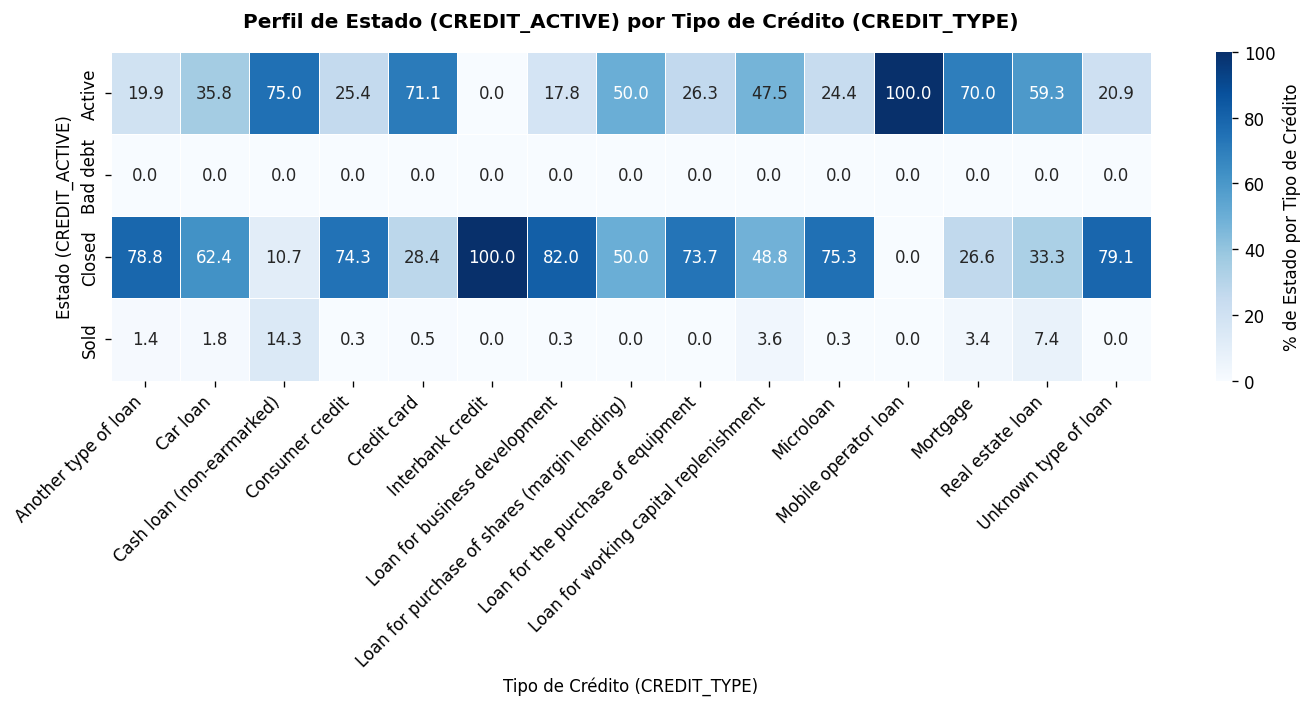

In [23]:
# asociación entre variables categóricas (V de Cramér)

# calculamos V de Cramér entre CREDIT_ACTIVE y CREDIT_TYPE
confusion_matrix = pd.crosstab(bureau['CREDIT_ACTIVE'], bureau['CREDIT_TYPE'])
chi2 = chi2_contingency(confusion_matrix)[0]
n = confusion_matrix.sum().sum()
r, k = confusion_matrix.shape
v_cramer = np.sqrt(chi2 / (n * min(k-1, r-1)))

print(f"Coeficiente V de Cramér entre CREDIT_ACTIVE y CREDIT_TYPE: {round(v_cramer, 4)}")

# tabla de contingencia normalizada por columna (tipo de crédito)
contingency_norm = pd.crosstab(bureau['CREDIT_ACTIVE'], bureau['CREDIT_TYPE'], normalize='columns')
print("\nTabla de contingencia normalizada por columna (CREDIT_TYPE) en %:")
display((contingency_norm * 100).round(2))

# visualizamos la tabla como heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    contingency_norm * 100, 
    annot=True, 
    fmt=".1f", 
    cmap="Blues", 
    linewidths=0.5,
    cbar_kws={'label': '% de Estado por Tipo de Crédito'}
)
plt.title("Perfil de Estado (CREDIT_ACTIVE) por Tipo de Crédito (CREDIT_TYPE)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Tipo de Crédito (CREDIT_TYPE)")
plt.ylabel("Estado (CREDIT_ACTIVE)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

V de Cramér entre `CREDIT_ACTIVE` y `CREDIT_TYPE` es 0,2387 (asociación débil, por debajo del umbral de 0,30). No son redundantes ya que el estado del crédito y el tipo de producto aportan información distinta. Ambas se conservarán como dimensiones independientes.

Sin embargo, el heatmap normalizado por tipo de crédito muestra lo siguiente:

Las tarjetas de crédito tienen 71,11% de créditos 'Active' frente a solo 28,36% 'Closed'. Esto es consistente con la naturaleza revolving del producto debido a que las tarjetas permanecen abiertas indefinidamente, no se "cierran" al pagar una cuota. Es exactamente lo que explica el patrón de nulos de `DAYS_CREDIT_ENDDATE` (80,8% de nulos en Credit card implica que no tienen fecha de fin porque son revolving).

'Consumer credit' muestra el patrón opuesto: 74,35% 'Closed' y solo 25,39% 'Active'. Es decir, son créditos a término que se cierran al liquidar, lo esperable. Tiene 0,26% de 'Sold', muy bajo.

'Cash loan' (non-earmarked) destaca con 14,29% de 'Sold' (la tasa más alta de créditos vendidos a cobradores de deuda de todos los tipos). Con solo 56 obs tengo que interpretarla con cuidado (8 créditos vendidos de 56), pero la señal de riesgo es coherente con la naturaleza del producto, puesto que los préstamos en efectivo sin finalidad específica representan un perfil de mayor necesidad de liquidez.

'Mortgage' tiene 70% 'Active', coherente con la duración típica de 20 a 30 años de una hipoteca. Solo 3,38% 'Sold', lo que sugiere que las hipotecas se venden a cobradores con menos frecuencia que otros productos (probablemente porque tienen colateral inmobiliario que protege al banco).

'Mobile operator loan' aparece con 100% 'Active', pero con solo 1 obs en el dataset lo que implica casualidad, no patron.

'Bad debt' aparece como 0% en todos los tipos porque los 21 casos totales (confirmados antes) son tan pocos que no alcanzan ni el 0,1% en ningún tipo individual.

Posteriormente, estos perfiles confirman que contar créditos por estado (`BUREAU_ACTIVE_COUNT`, `BUREAU_CLOSED_COUNT`) sin controlar por tipo de crédito mezclaría señales distintas: un cliente con 5 tarjetas 'Active' tiene un perfil completamente distinto a uno con 5 hipotecas 'Active'.

In [24]:
# tasa de default por CREDIT_ACTIVE y CREDIT_TYPE
# CREDIT_TYPE
top_types = bureau_t["CREDIT_TYPE"].value_counts()
principales = top_types[top_types / len(bureau_t) > 0.01].index
grouped = bureau_t["CREDIT_TYPE"]
if "Other" not in grouped.cat.categories:
    grouped = grouped.cat.add_categories(["Other"])
bureau_t["CREDIT_TYPE_GROUPED"] = grouped.where(grouped.isin(principales), "Other").cat.remove_unused_categories()

# analizo las tasa de default y contingencia Chi2
for col, label in [("CREDIT_ACTIVE", "CREDIT_ACTIVE"), ("CREDIT_TYPE_GROUPED", "CREDIT_TYPE (agrupado)")]:
    res = bureau_t.groupby(col, observed=False)["TARGET"].agg(["count", "sum"])
    
    # tabla descriptiva
    tabla = pd.DataFrame({"n": res["count"], "Tasa Default (%)": (res["sum"] / res["count"]) * 100})
    print(f"Tasa de default por {label}:")
    display(tabla.sort_values("Tasa Default (%)", ascending=False))
    
    # tabla de contingencia y test Chi2
    ct = pd.DataFrame({0: res["count"] - res["sum"], 1: res["sum"]})
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"Chi2 {label} vs TARGET: Chi2 = {round(chi2, 2)} | p = {p}\n")

Tasa de default por CREDIT_ACTIVE:


,n,Tasa Default (%)
CREDIT_ACTIVE,,
Bad debt,20,20.0
Sold,5653,10.1
Active,541919,9.29
Closed,917733,6.93


Chi2 CREDIT_ACTIVE vs TARGET: Chi2 = 2673.43 | p = 0.0

Tasa de default por CREDIT_TYPE (agrupado):


,n,Tasa Default (%)
CREDIT_TYPE_GROUPED,,
Other,12498,16.87
Credit card,343853,8.8
Consumer credit,1069610,7.48
Car loan,23757,5.57
Mortgage,15607,5.0


Chi2 CREDIT_TYPE (agrupado) vs TARGET: Chi2 = 2385.86 | p = 0.0



El ranking de `CREDIT_ACTIVE` confirma la hipótesis de negocio que planteé en anteriormente: 'Bad debt' (20,00%) y 'Sold' (10,10%) tienen las tasas más altas, seguidas de 'Active' (9,29%) y con 'Closed' (6,93%) claramente en último lugar. La jerarquía es exactamente la esperada debido a que un crédito declarado incobrable o vendido a un cobrador es la señal de riesgo más fuerte, un crédito activo es neutro (aún no resuelto), y un crédito cerrado exitosamente es la señal de menor riesgo. Chi2 confirma la asociación (2.673,43, p ≈ 0).

'Bad debt' con solo 20 obs tiene una tasa de 20,00% (4 de 20 en default), que
mantengo con la misma cautela ya que es consistente con la hipótesis pero no fiable individualmente por el tamaño de muestra. Sin embargo, agrupada con 'Sold' en un concepto de "crédito problemático" (10,10%+ combinado) la señal es robusta por el volumen de 'Sold' (5.653 obs).

El ranking de `CREDIT_TYPE` agrupado también confirma la lógica de que 'Mortgage' (5,00%) y 'Car loan' (5,57%) como los de menor riesgo (créditos a largo plazo con colateral), 'Consumer credit' (7,48%) y 'Credit card' (8,80%) en riesgo intermedio alto (crédito sin colateral fuerte), y "Other" (16,87%, agrupación de las categorías minoritarias) con la tasa más alta. Chi2 confirma la asociación (2.385,86, p ≈ 0).

Que 'Credit card' (8,80%) tenga mayor default que 'Consumer credit' (7,48%) es coherente con el perfil de deuda revolving, en donde las tarjetas permiten mantener deuda continuamente sin plazo de liquidación forzoso, lo que puede facilitar sobreendeudamiento progresivo. Esto conecta alguna conclusión previa en donde 'Credit card' tenía 71,11% de créditos en estado 'Active' (rara vez se cierran), y con el patrón de nulos de `DAYS_CREDIT_ENDDATE` concentrado en tarjetas (80,8%).

Que 'Mortgage' tenga la tasa más baja (5,00%) tiene sentido, puesto que acceder a una hipoteca ya implica un proceso de evaluación crediticia riguroso por parte del banco original, lo que actúa como filtro previo de solvencia.

La categoría "Other" con 16,87% es la más alta de todas, pero al ser una agrupación de 10 tipos minoritarios (incluyendo 'Cash loan non-earmarked' que ya mostró 14,29% de 'Sold') mezcla señales heterogéneas. Aunque más adelante debo verificar si desagregar alguna de estas categorías (especialmente 'Microloan', que por su naturaleza de crédito rápido y pequeño
importe podría tener un perfil de riesgo diferenciado) aporta señal adicional en vez de mantenerlas todas fusionadas en "Other".

Ambos cruces confirman que `CREDIT_ACTIVE` y `CREDIT_TYPE` aportan señal real y
complementaria (V de Cramér 0,24 entre ellas), lo que justifica conservarlas
como dimensiones independientes a posteriori (`BUREAU_ACTIVE_COUNT`, `BUREAU_CLOSED_COUNT`, `BUREAU_BAD_DEBT_COUNT`, y posiblemente conteos específicos por tipo de crédito predominante).

El análisis de correlaciones de bureau tiene un patrón distinto al de application_train: la señal individual de las variables a nivel fila es muy débil. La correlación más alta con `TARGET` es `DAYS_CREDIT` con r = 0,0616, comparable a `REGION_RATING_CLIENT_W_CITY` (0,061) en application_train pero muy por debajo de los `EXT_SOURCE` (-0,155 a -0,179). Ninguna variable financiera de bureau supera |r| = 0,011 con `TARGET`. Esto confirma lo que supuse previamente y es que el valor predictivo de bureau no estaría en variables individuales a nivel fila sino en las agregaciones por cliente que fuese a hacer a posteriori (conteos, máximos de mora, ratios de deuda).

El ranking está dominado completamente por las variables temporales, las 4 primeras posiciones son `DAYS_CREDIT` (0,0616), `DAYS_CREDIT_UPDATE` (0,0411), `DAYS_ENDDATE_FACT` (0,0391) y `DAYS_CREDIT_ENDDATE` (0,0265). Todas con correlación positiva, lo que indica que créditos más recientes (valores más cercanos a 0) se asocian con mayor riesgo del cliente, coherente con el perfil de búsqueda activa de crédito ya identificado en la tabla de application_train.

Las variables de mora (`CREDIT_DAY_OVERDUE`, `AMT_CREDIT_SUM_OVERDUE`, `AMT_CREDIT_MAX_OVERDUE`) tienen correlaciones Pearson prácticamente nulas (<0,007) pero Spearman revela relaciones monótonas subyacentes hasta 7 veces más fuertes. Su señal está en la cola de eventos raros (patrón idéntico a `DEF_60_CNT_SOCIAL_CIRCLE` en application_train).

La matriz de multicolinealidad identifica un cluster temporal con dos pares por encima del umbral: `DAYS_CREDIT` vs `DAYS_ENDDATE_FACT` (r = 0,88) y `DAYS_ENDDATE_FACT` vs
`DAYS_CREDIT_UPDATE` (r = 0,75). Pese a la alta correlación, capturan conceptos de negocio distintos (antigüedad del crédito, recencia del cierre, última actualización administrativa) y se conservan las tres para evaluar al mirar el eje temporal cuál aporta señal incremental sobre las otras y si alguna es prescindible tras condicionar.

La validación cruzada confirma independencia entre `AMT_ANNUITY` y `AMT_CREDIT_SUM` (r = 0,05), validando que la feature de ratio/conteo de créditos con cuota activa es nueva. También confirma que `CREDIT_DAY_OVERDUE` y `AMT_CREDIT_SUM_OVERDUE` son dimensiones distintas del mismo fenómeno (r = 0,10), justificando que ambas entren por separado en la agregación como duración y gravedad financiera de la mora.

Las dos categóricas (`CREDIT_ACTIVE` y `CREDIT_TYPE`) no son redundantes (V Cramér = 0,24) y ambas aportan señal real contra `TARGET`. `CREDIT_ACTIVE` confirma la jerarquía
de riesgo esperada: 'Bad debt' (20,00%) > 'Sold' (10,10%) > 'Active' (9,29%) > 'Closed' (6,93%). `CREDIT_TYPE` revela que 'Mortgage' (5,00%) y 'Car loan' (5,57%) son los de menor riesgo (colateral + evaluación rigurosa previa) y 'Credit card' (8,80%) el de mayor riesgo entre los tipos principales (deuda revolving sin plazo de liquidación forzoso).

**Decisiones**
- Conservaré `DAYS_CREDIT`, `DAYS_ENDDATE_FACT` y `DAYS_CREDIT_UPDATE` como variables independientes para agregar. De `DAYS_CREDIT` saldrán dos features, el `min` (el crédito más antiguo, longitud del historial) y el `max` (el más reciente, recencia de la última solicitud); de `DAYS_ENDDATE_FACT`, el `min` es el cierre más antiguo, no el último.
- Conservaré `AMT_CREDIT_SUM` y `AMT_CREDIT_SUM_DEBT` por separado (r = 0,67 < umbral) y crearé `BUREAU_DEBT_CREDIT_RATIO` como feature derivada.
- Agregaré mora por dimensiones independientes: `BUREAU_MAX_DAYS_OVERDUE` (duración) y `BUREAU_CURRENT_OVERDUE_SUM` (gravedad financiera), no fusionarlas. (Nota: esta separación se revisa a nivel cliente (nivel cliente): al agregar por cliente ambas resultan casi el mismo cliente (V de Cramér 0,93) y `BUREAU_MAX_DAYS_OVERDUE` se descarta por redundancia.)
- Conteos por `CREDIT_ACTIVE` (`BUREAU_ACTIVE_COUNT`, `BUREAU_CLOSED_COUNT`, `BUREAU_BAD_DEBT_COUNT`) y evaluaré los conteos cruzados estado × tipo.

### 7. Análisis Temporal

Tabla Descriptiva de Variables Temporales (en Años)


,DAYS_CREDIT_YEARS,DAYS_CREDIT_ENDDATE_YEARS,DAYS_ENDDATE_FACT_YEARS,DAYS_CREDIT_UPDATE_YEARS
count,1716428.0,1610875.0,1082775.0,1716428.0
mean,3.13,-1.4,2.79,1.63
std,2.18,13.67,1.95,1.97
min,0.0,-85.42,-0.0,-1.02
1%,0.1,-84.95,0.07,0.01
5%,0.34,-7.18,0.26,0.02
25%,1.3,-1.3,1.16,0.09
50%,2.7,0.9,2.46,1.08
75%,4.56,3.12,4.08,2.49
95%,7.3,6.19,6.55,5.69


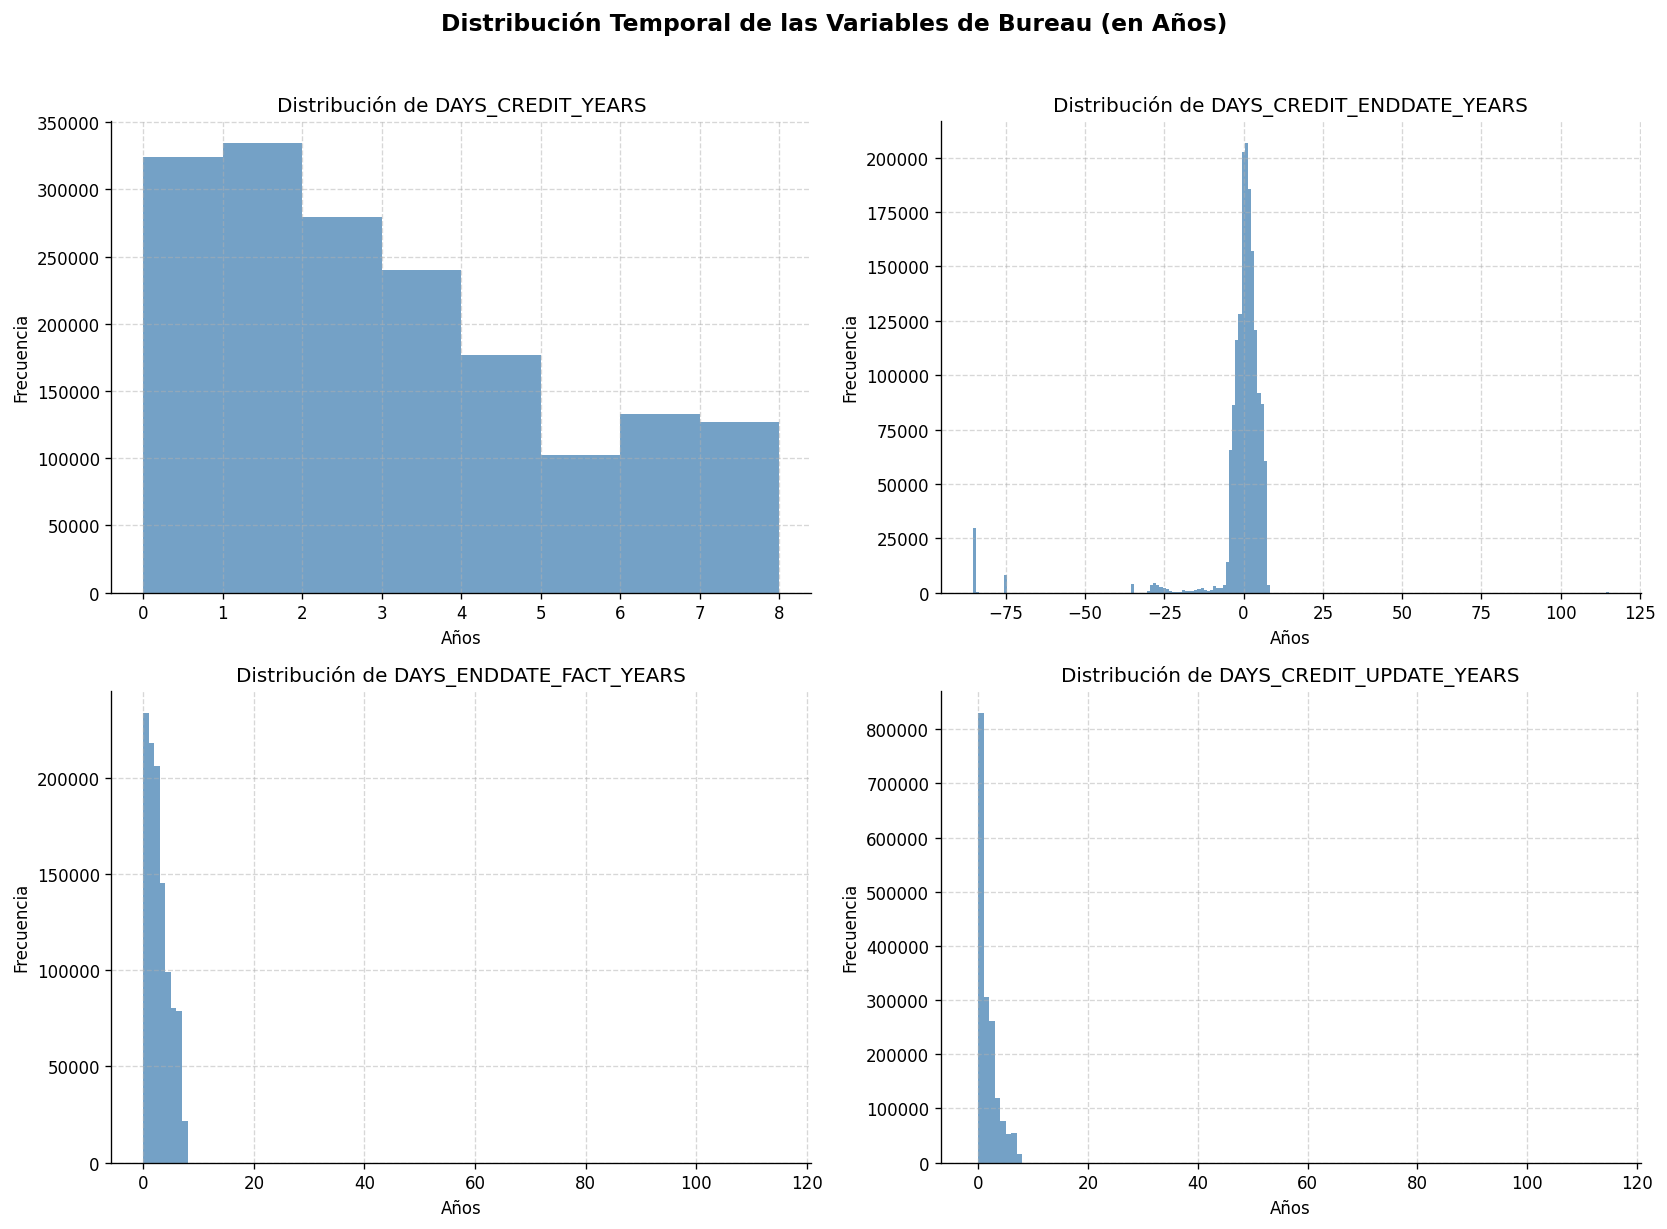

In [25]:
# las 4 temporales a años, negadas para leerlas como años atrás
temporal_cols = ['DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'DAYS_CREDIT_UPDATE']
years_cols = [c + '_YEARS' for c in temporal_cols]

bureau[years_cols] = -bureau[temporal_cols] / 365.25
if 'bureau_t' in locals():
    bureau_t[years_cols] = -bureau_t[temporal_cols] / 365.25

# tabla descriptiva
print("Tabla Descriptiva de Variables Temporales (en Años)")
display(bureau[years_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), years_cols):
    sns.histplot(bureau[col], binwidth=1, color=color_no_default, ax=ax, edgecolor="none")
    ax.set(title=f'Distribución de {col}', xlabel='Años', ylabel='Frecuencia')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Distribución Temporal de las Variables de Bureau (en Años)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


`DAYS_CREDIT_YEARS` (100% cobertura): esta es la variable temporal más completa de las cuatro. Rango de 0 a 8 años, mediana de 2,70 años, distribución ligeramente asimétrica hacia la derecha con pico en 1 a 2 años. no hay valores negativos ni extremos sospechosos debido a que el máximo de 8 años es el límite natural del historial reportado por el buró. La distribución creciente hacia valores recientes (más créditos solicitados en los últimos de 1 a 2 años que hace de 7 a 8) es coherente con el patrón del buró de acumular más registros recientes que antiguos.

`DAYS_CREDIT_ENDDATE_YEARS` (93,9% presencia, 6,1% nulos clasificados como MAR vía `CREDIT_TYPE`): es la distribución más compleja de las cuatro. La media es negativa (-1,40 años), lo que indica que de media los créditos tienen fecha de fin futura respecto a la solicitud (aún no han vencido). Sin embargo, la mediana es positiva (0,90 años), lo que significa que más de la mitad de los créditos ya habían terminado antes de la solicitud. La diferencia entre media y mediana refleja el efecto de la cola negativa extrema, en donde el mínimo de -85,42 años corresponde a los vencimientos de tarjetas revolving (créditos con fecha de fin a 85 años en el futuro, no son reales sino marcadores del sistema bancario). En el extremo opuesto, el máximo de 115,15 años implica un crédito que supuestamente terminó hace 115 años, un error de histórico.

`DAYS_ENDDATE_FACT_YEARS` (63,1% presencia): solo disponible para créditos cerrados, coherente con la clasificación MAR (nulos = créditos Active/Sold/Bad debt). Mediana de 2,46 años (cierre real 2,5 años antes de la solicitud), concentrada fuertemente entre 0 y 5 años con el 95% por debajo de 6,55 años. El máximo de 115,05 años es el mismo error que en `DAYS_CREDIT_ENDDATE`, y coincide en magnitud (115 años) con los extremos de las otras variables, lo que sugiere que provienen de los mismos registros antiguos del buró.

`DAYS_CREDIT_UPDATE_YEARS` (100% presencia): es la más concentrada cerca de 0, con mediana de solo 1,08 años. Esto indica que la mayoría de créditos tienen actualizaciones recientes del buró (último año). El mínimo de -1,02 años confirma un outlier en donde las actualizaciones que ocurren después de la fecha de solicitud (hasta 372 días después). Representan una fracción mínima (p1 = 0,008 años ≈ 3 días) y ya se documentaron previamente. El máximo de 114,84 años sigue el mismo patrón de error histórico que las dos anteriores.

Los tres máximos extremos (115 años) en `DAYS_CREDIT_ENDDATE`, `DAYS_ENDDATE_FACT` y `DAYS_CREDIT_UPDATE` comparten la misma magnitud, lo que refuerza que corresponden a los mismos registros históricos del buró con datos de fechas implausibles. Al analizar los extremos lo evaluaré.

In [26]:
# mann-Whitney U + Rank-Biserial
cols = ['DAYS_CREDIT_YEARS', 'DAYS_CREDIT_ENDDATE_YEARS', 'DAYS_ENDDATE_FACT_YEARS', 'DAYS_CREDIT_UPDATE_YEARS']
stats = []

for col in cols:
    x = bureau_t.loc[bureau_t['TARGET'] == 0, col].dropna()
    y = bureau_t.loc[bureau_t['TARGET'] == 1, col].dropna()
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    r_rb = abs(2 * u / (len(x) * len(y)) - 1)
    stats.append({
        'Variable': col,
        'N': len(x) + len(y),
        'U': u,
        'p-valor': p,
        'r_rb (Effect Size)': r_rb
    })

df_stats = pd.DataFrame(stats).sort_values(by='r_rb (Effect Size)', ascending=False)
print("Señal Discriminante Individual: Mann-Whitney U + Rank-Biserial")
display(df_stats.style.format({
    'N': '{:,}', 'U': '{:,.1f}', 'p-valor': '{:.4e}', 'r_rb (Effect Size)': '{:.4f}'
}))

Señal Discriminante Individual: Mann-Whitney U + Rank-Biserial


,Variable,N,U,p-valor,r_rb (Effect Size)
0,DAYS_CREDIT_YEARS,"1,465,325","88,383,736,551.0",0.0000e+00,0.1427
3,DAYS_CREDIT_UPDATE_YEARS,"1,465,325","86,330,058,725.5",0.0000e+00,0.1161
1,DAYS_CREDIT_ENDDATE_YEARS,"1,376,227","74,178,387,129.5",0.0000e+00,0.1094
2,DAYS_ENDDATE_FACT_YEARS,"920,652","29,946,201,626.0",0.0000e+00,0.0941


Las cuatro variables temporales son altamente significativas (p ≈ 0 en todas), con un ranking de effect sizes que indica a `DAYS_CREDIT_YEARS` como la variable con mayor señal de toda la tabla bureau: r_rb = 0,1427, seguida de `DAYS_CREDIT_UPDATE_YEARS` (0,1161), `DAYS_CREDIT_ENDDATE_YEARS` (0,1094) y `DAYS_ENDDATE_FACT_YEARS` (0,0941).

Lo más relevante es la diferencia grande entre el ranking de Pearson y el de rank-biserial. `DAYS_CREDIT` tenía r = 0,0616 en Pearson pero r_rb = 0,1427 aquí, más del doble. `DAYS_CREDIT_UPDATE` pasa de r = 0,0411 a r_rb = 0,1161, casi el triple. Esto me indica con mucha más fuerza la hipótesis de que son relaciones no lineales, en donde la relación entre recencia del crédito y riesgo es monótona pero no lineal, y Pearson la subestima. Para la agregación futura, estas variables necesitarán transformaciones (binning o logarítmica) en vez de conservarlas como valor continuo directo.

Comparando con application_train, los effect sizes de bureau son menores pero del mismo orden: edad (0,166) ≈ antigüedad laboral (0,165) > `DAYS_CREDIT` de bureau (0,143) > cambio teléfono (0,114) ≈ `DAYS_CREDIT_UPDATE` (0,116). Las variables temporales de bureau están al nivel de `DAYS_LAST_PHONE_CHANGE` de application_train, lo que las sitúa como señales secundarias.


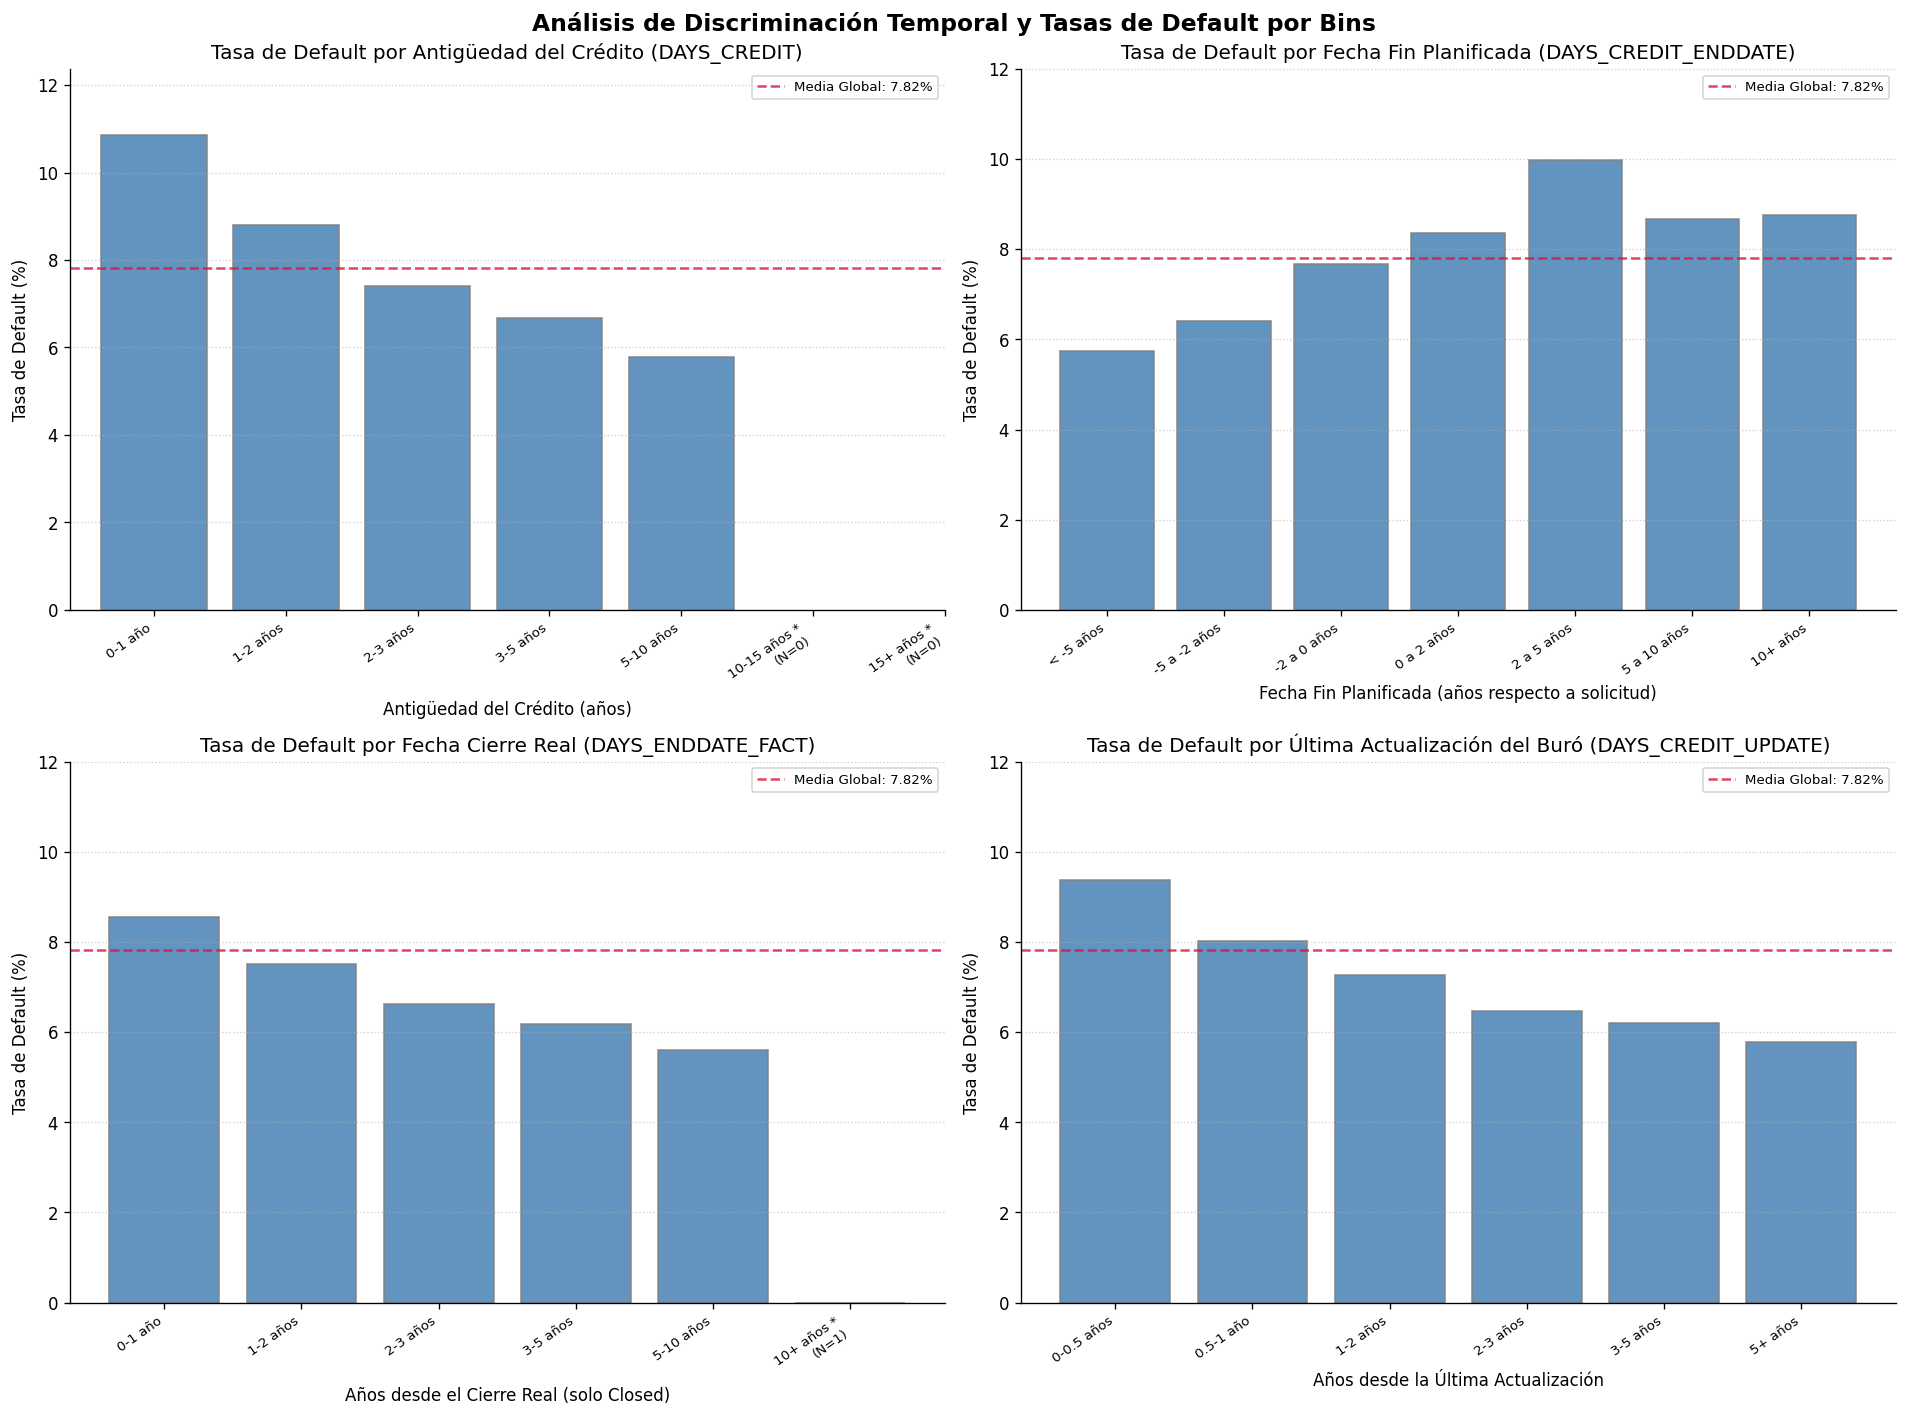


AVISO: Los siguientes bins han sido marcados con '*' por ser estadísticamente NO fiables (N < 500):
  - Tasa de Default por Antigüedad del Crédito (DAYS_CREDIT): bin '10-15 años' (N=0)
  - Tasa de Default por Antigüedad del Crédito (DAYS_CREDIT): bin '15+ años' (N=0)
  - Tasa de Default por Fecha Cierre Real (DAYS_ENDDATE_FACT): bin '10+ años' (N=1)


In [27]:
# tasa de default por bins
bureau_t['DAYS_CREDIT_ENDDATE_SIGNED_YEARS'] = bureau_t['DAYS_CREDIT_ENDDATE'] / 365.25
global_mean = bureau_t['TARGET'].mean() * 100

bins_config = [
    ('DAYS_CREDIT_YEARS', [0, 1, 2, 3, 5, 10, 15, float('inf')], ['0-1 año', '1-2 años', '2-3 años', '3-5 años', '5-10 años', '10-15 años', '15+ años'], 'Tasa de Default por Antigüedad del Crédito (DAYS_CREDIT)', 'Antigüedad del Crédito (años)'),
    ('DAYS_CREDIT_ENDDATE_SIGNED_YEARS', [-float('inf'), -5, -2, 0, 2, 5, 10, float('inf')], ['< -5 años', '-5 a -2 años', '-2 a 0 años', '0 a 2 años', '2 a 5 años', '5 a 10 años', '10+ años'], 'Tasa de Default por Fecha Fin Planificada (DAYS_CREDIT_ENDDATE)', 'Fecha Fin Planificada (años respecto a solicitud)'),
    ('DAYS_ENDDATE_FACT_YEARS', [0, 1, 2, 3, 5, 10, float('inf')], ['0-1 año', '1-2 años', '2-3 años', '3-5 años', '5-10 años', '10+ años'], 'Tasa de Default por Fecha Cierre Real (DAYS_ENDDATE_FACT)', 'Años desde el Cierre Real (solo Closed)'),
    ('DAYS_CREDIT_UPDATE_YEARS', [0, 0.5, 1, 2, 3, 5, float('inf')], ['0-0.5 años', '0.5-1 año', '1-2 años', '2-3 años', '3-5 años', '5+ años'], 'Tasa de Default por Última Actualización del Buró (DAYS_CREDIT_UPDATE)', 'Años desde la Última Actualización')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
unreliable_bins = []

for ax, (col, edges, labels, title, xlabel) in zip(axes.flatten(), bins_config):
    cuts = pd.cut(bureau_t[col], bins=edges, include_lowest=True)
    stats_df = bureau_t.groupby(cuts, observed=False)['TARGET'].agg(['count', 'mean'])
    counts, rates = stats_df['count'].values, stats_df['mean'].values * 100
    
    display_labels = []
    for label, count in zip(labels, counts):
        if count < 500:
            display_labels.append(f"{label} *\n(N={count})")
            unreliable_bins.append(f"{title}: bin '{label}' (N={count})")
        else:
            display_labels.append(label)
            
    bars = ax.bar(range(len(rates)), rates, color=color_no_default, edgecolor='gray', alpha=0.85)
    ax.axhline(global_mean, color=color_default, linestyle='--', alpha=0.8, label=f'Media Global: {round(global_mean, 2)}%')
    
    ax.set_ylim(0, max(np.nanmax(rates) + 1.5, 12))
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(display_labels, rotation=35, ha='right', fontsize=8)
    ax.set(title=title, xlabel=xlabel, ylabel='Tasa de Default (%)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6, axis='y')

plt.suptitle('Análisis de Discriminación Temporal y Tasas de Default por Bins', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

if unreliable_bins:
    print("\nAVISO: Los siguientes bins han sido marcados con '*' por ser estadísticamente NO fiables (N < 500):")
    for bin_info in unreliable_bins:
        print(f"  - {bin_info}")


`DAYS_CREDIT` (antigüedad del crédito): tiene una relación monótona decreciente perfecta. Los créditos solicitados hace menos de 1 año tienen 10,8% de default frente a 5,8% para los de 5 a 10 años. Es el mismo patrón que la antigüedad laboral en application_train: actividad
crediticia reciente se asocia con mayor riesgo. Los bins de 10 a 15 y 15 o más años tienen n=0, por lo que están bien descartados del gráfico.

`DAYS_CREDIT_ENDDATE` (fecha de fin planificada): es la única de las cuatro variables con forma de U, no monótona. Los créditos que ya terminaron hace más de 5 años tienen solo 5,8% de default (bajo riesgo, historial antiguo ya cerrado). El riesgo sube progresivamente
hasta alcanzar el pico máximo de 10,1% en el bin "2 a 5 años" (créditos con vencimiento próximo pero no inmediato). Después desciende ligeramente a 8,9% para de 5 a 10 años y 10 o más años. Este patrón en U no es ruido, ya que el pico coincide con créditos a medio plazo aún vigentes donde la presión de pago es máxima. Esto se alinea directamente con el KDE previo en donde `TARGET`=1 mostraba más densidad en la zona de fechas de fin cercanas. La forma no lineal explica además por qué su Pearson (0,0265) es tan bajo respecto a su
rank-biserial (0,1094) y esto se debe a que Pearson subestima esta variable porque asume linealidad.

`DAYS_ENDDATE_FACT` (fecha de cierre real, solo créditos Closed): es monótona decreciente como `DAYS_CREDIT`. Los créditos cerrados hace menos de 1 año tienen 8,6% de default vs 5,7% para los cerrados hace de 5 a 10 años. Esto tiene sentido, ya que un cierre reciente puede indicar que el cliente acaba de liquidar una deuda y está buscando financiación nueva (mismo perfil de búsqueda activa). El bin de 10 o más años tiene n=1, lo que implica que estadísticamente sea irrelevante.

`DAYS_CREDIT_UPDATE` (última actualización del buró): es monótona decreciente. Las actualizaciones en los últimos 6 meses tienen 9,5% de default vs 5,9% para las de más de 5 años. Una actualización reciente implica actividad crediticia reciente, coherente con todos los patrones anteriores. El escalón más fuerte está entre 0 y 0,5 años (9,5%) y de 0,5 a 1 año (6,5%), una caída de 3pp que indica que la recencia de la actualización es informativa en el corto plazo.

Los tres avisos de bins no fiables (de 10 a 15 años y 15 o más años en `DAYS_CREDIT` con n=0, 10 o más años en `DAYS_ENDDATE_FACT` con n=1) son coherentes con el historial máximo del buró de 8 años que vi anteriormente. No hay créditos con antigüedad superior a 8 años, lo que limita naturalmente el rango de los bins.


In [28]:
# comparo directamente effect sizes del cluster temporal
# reuso df_stats
cluster_vars = ['DAYS_CREDIT_YEARS', 'DAYS_CREDIT_UPDATE_YEARS', 'DAYS_ENDDATE_FACT_YEARS']
df_compare = df_stats[df_stats['Variable'].isin(cluster_vars)].rename(columns={'r_rb (Effect Size)': 'Overall r_rb'})

print("Comparación directa de effect sizes del cluster temporal")
display(df_compare[['Variable', 'N', 'Overall r_rb', 'p-valor']].style.format({
    'N': '{:,}', 'Overall r_rb': '{:.4f}', 'p-valor': '{:.4e}'
}))

Comparación directa de effect sizes del cluster temporal


,Variable,N,Overall r_rb,p-valor
0,DAYS_CREDIT_YEARS,"1,465,325",0.1427,0.0000e+00
3,DAYS_CREDIT_UPDATE_YEARS,"1,465,325",0.1161,0.0000e+00
2,DAYS_ENDDATE_FACT_YEARS,"920,652",0.0941,0.0000e+00


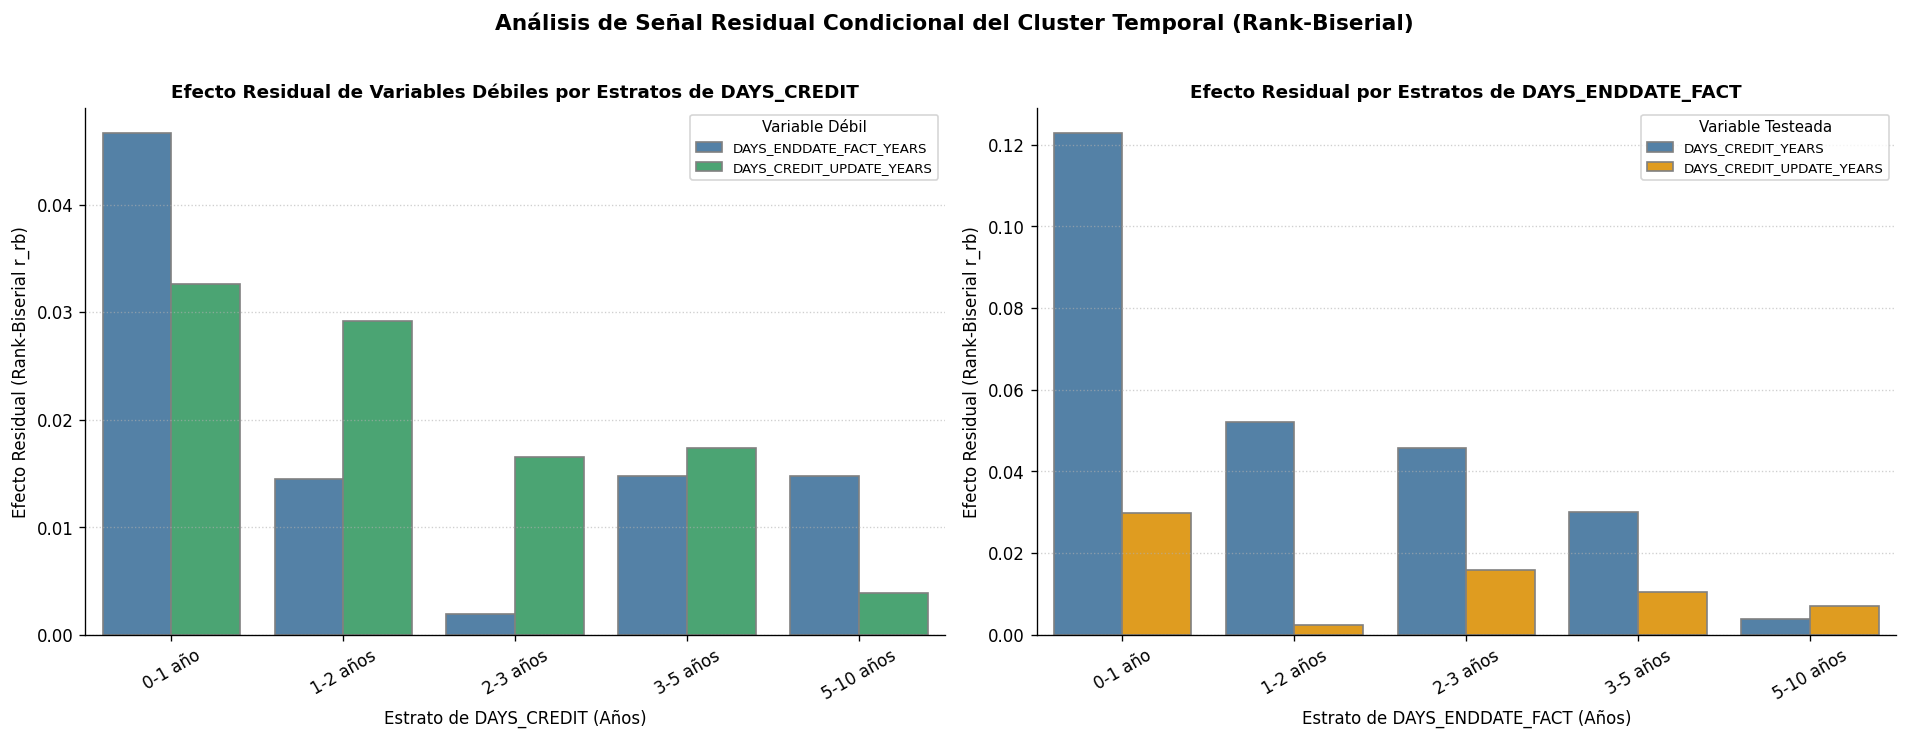

Señal residual de variables débiles estratificadas por DAYS_CREDIT


,Estrato,Variable,N,r_rb residual,p-valor
0,0-1 año,DAYS_ENDDATE_FACT_YEARS,59040,0.05,0.0
1,0-1 año,DAYS_CREDIT_UPDATE_YEARS,279132,0.03,0.0
2,1-2 años,DAYS_ENDDATE_FACT_YEARS,142480,0.01,0.01
3,1-2 años,DAYS_CREDIT_UPDATE_YEARS,284172,0.03,0.0
4,2-3 años,DAYS_ENDDATE_FACT_YEARS,158557,0.0,0.73
5,2-3 años,DAYS_CREDIT_UPDATE_YEARS,237589,0.02,0.0
6,3-5 años,DAYS_ENDDATE_FACT_YEARS,279878,0.01,0.0
7,3-5 años,DAYS_CREDIT_UPDATE_YEARS,350924,0.02,0.0
8,5-10 años,DAYS_ENDDATE_FACT_YEARS,280697,0.01,0.0
9,5-10 años,DAYS_CREDIT_UPDATE_YEARS,313508,0.0,0.38


Señal residual estratificada por DAYS_ENDDATE_FACT


,Estrato,Variable,N,r_rb residual,p-valor
0,0-1 año,DAYS_CREDIT_YEARS,197562,0.12,0.0
1,0-1 año,DAYS_CREDIT_UPDATE_YEARS,197562,0.03,0.0
2,1-2 años,DAYS_CREDIT_YEARS,184217,0.05,0.0
3,1-2 años,DAYS_CREDIT_UPDATE_YEARS,184217,0.0,0.65
4,2-3 años,DAYS_CREDIT_YEARS,177403,0.05,0.0
5,2-3 años,DAYS_CREDIT_UPDATE_YEARS,177403,0.02,0.0
6,3-5 años,DAYS_CREDIT_YEARS,203192,0.03,0.0
7,3-5 años,DAYS_CREDIT_UPDATE_YEARS,203192,0.01,0.05
8,5-10 años,DAYS_CREDIT_YEARS,158277,0.0,0.55
9,5-10 años,DAYS_CREDIT_UPDATE_YEARS,158277,0.01,0.27


In [29]:
# calculo la señal condicional
credit_bins = [0, 1, 2, 3, 5, 10, 15, float('inf')]
credit_labels = ['0-1 año', '1-2 años', '2-3 años', '3-5 años', '5-10 años', '10-15 años', '15+ años']
enddate_bins = [0, 1, 2, 3, 5, 10, float('inf')]
enddate_labels = ['0-1 año', '1-2 años', '2-3 años', '3-5 años', '5-10 años', '10+ años']

bureau_t['DAYS_CREDIT_BIN'] = pd.cut(bureau_t['DAYS_CREDIT_YEARS'], bins=credit_bins, labels=credit_labels, include_lowest=True)
bureau_t['DAYS_ENDDATE_FACT_BIN'] = pd.cut(bureau_t['DAYS_ENDDATE_FACT_YEARS'], bins=enddate_bins, labels=enddate_labels, include_lowest=True)

def calc_r_rb_sub(df, val_col):
    x, y = df.loc[df['TARGET'] == 0, val_col].dropna(), df.loc[df['TARGET'] == 1, val_col].dropna()
    if len(x) < 5 or len(y) < 5:
        return np.nan, np.nan, len(x) + len(y)
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    return abs(2 * u / (len(x) * len(y)) - 1), p, len(x) + len(y)

def analyze_strat(bin_col, test_cols, title, xlabel, ax, hue_title, palette):
    strat = []
    for label in bureau_t[bin_col].cat.categories:
        sub_df = bureau_t[bureau_t[bin_col] == label]
        if len(sub_df) < 5:
            continue
        for col in test_cols:
            r_rb, p, n = calc_r_rb_sub(sub_df, col)
            strat.append({
                'Estrato': label,
                'Variable': col,
                'N': n,
                'r_rb residual': r_rb,
                'p-valor': p
            })
    df_strat = pd.DataFrame(strat).dropna(subset=['r_rb residual'])
    sns.barplot(data=df_strat, x='Estrato', y='r_rb residual', hue='Variable', palette=palette, ax=ax, edgecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set(xlabel=xlabel, ylabel='Efecto Residual (Rank-Biserial r_rb)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle=':', alpha=0.6, axis='y')
    ax.legend(title=hue_title, fontsize=8, title_fontsize=9)
    return df_strat

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_strat_credit = analyze_strat('DAYS_CREDIT_BIN', ['DAYS_ENDDATE_FACT_YEARS', 'DAYS_CREDIT_UPDATE_YEARS'], 
                                'Efecto Residual de Variables Débiles por Estratos de DAYS_CREDIT', 
                                'Estrato de DAYS_CREDIT (Años)', ax1, 'Variable Débil', [color_no_default, color_presente])

df_strat_enddate = analyze_strat('DAYS_ENDDATE_FACT_BIN', ['DAYS_CREDIT_YEARS', 'DAYS_CREDIT_UPDATE_YEARS'], 
                                 'Efecto Residual por Estratos de DAYS_ENDDATE_FACT', 
                                 'Estrato de DAYS_ENDDATE_FACT (Años)', ax2, 'Variable Testeada', [color_no_default, color_nulo])

plt.suptitle('Análisis de Señal Residual Condicional del Cluster Temporal (Rank-Biserial)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Señal residual de variables débiles estratificadas por DAYS_CREDIT")
display(df_strat_credit)

print("Señal residual estratificada por DAYS_ENDDATE_FACT")
display(df_strat_enddate)


El análisis estratificado realizado resuelve la incertidumbre de que cuál de las tres variables del cluster temporal (r = de 0,68 a 0,88 entre ellas) aporta señal incremental y cuál es prescindible.

`DAYS_CREDIT_YEARS` es la variable dominante del cluster. Al estratificar por `DAYS_ENDDATE_FACT` (panel derecho), `DAYS_CREDIT` mantiene señal residual fuerte en 4 de 5 estratos, r_rb = 0,1228 en el estrato de 0 a 1 año (p = 4,4e-154), 0,0520 en 1 a 2 años, 0,0457 en 2 a 3 años, 0,0300 en 3 a 5 años. solo pierde señal en el estrato de 5 a 10 años
(r_rb = 0,0038, no significativo). Que mantenga un r_rb de 0,12 incluso después de controlar por la fecha de cierre real confirma que la antigüedad del crédito captura información que va más allá de cuándo se cerró, es decir, captura la historia crediticia completa
del cliente, no solo el último evento de pago.

`DAYS_ENDDATE_FACT_YEARS` aporta señal residual parcial, ya que está  concentrada en créditos recientes. Al estratificar por `DAYS_CREDIT` (panel izquierdo), su señal residual es fuerte solo en el estrato de 0 a 1 año (r_rb = 0,0466, p = 1,4e-09) y se va diluyendo en los estratos intermedios, 0,0144 en 1 a 2 años (significativo pero débil), 0,0019 en 2 a 3 años (no significativo, p = 0,73), y vuelve a ser significativa pero débil en 3 a 5 y de 5 a 10 años (0,015). El patrón, aparenta ser `DAYS_ENDDATE_FACT` aporta información adicional sobre el riesgo principalmente cuando el crédito fue solicitado y cerrado recientemente (último año), donde la diferencia entre "solicitado hace 6 meses y cerrado hace 2 meses" vs "solicitado hace 6 meses y cerrado hace 10 meses" tiene implicaciones directas de presión financiera. Para créditos antiguos (de 2 a 3 años), saber cuándo se cerró no añade nada sobre cuándo se solicitó.

`DAYS_CREDIT_UPDATE_YEARS` es la variable más prescindible del cluster. En ambos paneles pierde señal antes que las otras dos. Al estratificar por `DAYS_CREDIT` (panel izquierdo), mantiene señal moderada en los primeros 4 estratos (0,0326, 0,0292, 0,0165, 0,0173) pero la pierde completamente en 5 a 10 años (r_rb = 0,0039, p = 0,38). Al estratificar por `DAYS_ENDDATE_FACT` (panel derecho), la situación es peor, ya que solo el estrato de 0 a 1 año es significativo (r_rb = 0,0297, p = 1,6e-10) y el resto son todos no significativos o marginales. La última actualización del buró es mayoritariamente redundante con la antigüedad del crédito y la fecha de cierre real, ya que cuando controlas por cualquiera de las dos, `DAYS_CREDIT_UPDATE` aporta muy poco.

`DAYS_CREDIT` (r_rb = 0,1427, señal residual fuerte en 4/5 estratos) > `DAYS_ENDDATE_FACT` (r_rb = 0,0941, señal residual concentrada en créditos recientes) > `DAYS_CREDIT_UPDATE` (r_rb = 0,1161 overall pero pierde señal al condicionar por cualquiera de las otras dos).

El hecho de que `DAYS_CREDIT_UPDATE` tenga un r_rb general/promedio (0,1161) mayor que `DAYS_ENDDATE_FACT` (0,0941) pero sea la más prescindible al condicionar es un ejemplo de que el effect size
global puede ser engañoso cuando las variables están correlacionadas (r = de 0,68 a 0,75 en este cluster). La señal general de `DAYS_CREDIT_UPDATE` es en gran parte señal prestada de `DAYS_CREDIT`, no propia.

**Decisiones**
- `DAYS_CREDIT` va a ser variable temporal primaria. Agregaré como recencia del crédito más reciente (`BUREAU_DAYS_CREDIT_MIN`), con binning o transformación log por la no linealidad confirmada.
- `DAYS_ENDDATE_FACT` la conservaré como variable secundaria, especialmente informativa para créditos recientes. Agregaré como recencia del último cierre exitoso (`BUREAU_DAYS_ENDDATE_FACT_MIN`, solo sobre créditos 'Closed').
- `DAYS_CREDIT_UPDATE` es prescindible como variable temporal independiente. Si la conservará, la usaría como flag simple de recencia (`BUREAU_DAYS_CREDIT_UPDATE_FLAG`: 1 si última actualización < 6 meses) en vez de valor continuo, para capturar el salto de 9,5% a 6,5% que observé en los bins de 7,3.

In [30]:
# DAYS_CREDIT_UPDATE positivo (actualizaciones posteriores a la solicitud)
df_pos_update = bureau_t[bureau_t['DAYS_CREDIT_UPDATE'] > 0]
n_pos_update = len(df_pos_update)
pct_pos_update = n_pos_update / len(bureau_t) * 100
active_counts = df_pos_update['CREDIT_ACTIVE'].value_counts()
rate_pos = df_pos_update['TARGET'].mean() * 100
rate_rest = bureau_t[bureau_t['DAYS_CREDIT_UPDATE'] <= 0]['TARGET'].mean() * 100

print(f"Control DAYS_CREDIT_UPDATE > 0: {n_pos_update} casos ({round(pct_pos_update, 5)}%)")
print(f"- CREDIT_ACTIVE counts:\n{active_counts}")
print(f"- Tasas de Default: {round(rate_pos, 2)}% (UPDATE > 0) vs {round(rate_rest, 2)}% (resto)\n")


Control DAYS_CREDIT_UPDATE > 0: 17 casos (0.00116%)
- CREDIT_ACTIVE counts:
CREDIT_ACTIVE
Active      17
Bad debt     0
Closed       0
Sold         0
Name: count, dtype: int64
- Tasas de Default: 11.76% (UPDATE > 0) vs 7.82% (resto)



In [31]:
# DAYS_CREDIT_ENDDATE con valores extremos positivos (vencimiento a >20 años futuro)
# analizo periodo para distinguir hipotecas estándar vs limites absurdos de gastos
df_long_enddate = bureau_t[bureau_t['DAYS_CREDIT_ENDDATE'] > 20 * 365.25]
n_long_enddate = len(df_long_enddate)
pct_long_enddate = n_long_enddate / len(bureau_t) * 100
type_counts = df_long_enddate['CREDIT_TYPE'].value_counts()
rate_long = df_long_enddate['TARGET'].mean() * 100

df_extreme_50 = bureau_t[bureau_t['DAYS_CREDIT_ENDDATE'] > 50 * 365.25]
n_extreme_50 = len(df_extreme_50)
type_extreme_50 = df_extreme_50['CREDIT_TYPE'].value_counts()

print(f"Control DAYS_CREDIT_ENDDATE > 20 años: {n_long_enddate} casos ({round(pct_long_enddate, 4)}%)")
print(f"- CREDIT_TYPE counts (>20 años):\n{type_counts[type_counts > 0]}")
print(f"- Tasas de Default: {round(rate_long, 2)}%")
print(f"- Extremos > 50 años: {n_extreme_50} casos")
print(f"- CREDIT_TYPE counts (>50 años):\n{type_extreme_50[type_extreme_50 > 0]}\n")


Control DAYS_CREDIT_ENDDATE > 20 años: 52497 casos (3.5826%)
- CREDIT_TYPE counts (>20 años):
CREDIT_TYPE
Credit card                               51051
Mortgage                                   1225
Consumer credit                             219
Car loan                                      1
Loan for working capital replenishment        1
Name: count, dtype: int64
- Tasas de Default: 9.34%
- Extremos > 50 años: 32376 casos
- CREDIT_TYPE counts (>50 años):
CREDIT_TYPE
Credit card        32205
Consumer credit      171
Name: count, dtype: int64



In [32]:
# consistencia temporal entre variables
# DAYS_ENDDATE_FACT <= DAYS_CREDIT_ENDDATE para cerrados
closed_df = bureau_t[bureau_t['CREDIT_ACTIVE'] == 'Closed'].dropna(subset=['DAYS_ENDDATE_FACT', 'DAYS_CREDIT_ENDDATE'])
n_closed = len(closed_df)
violations_1 = (closed_df['DAYS_ENDDATE_FACT'] > closed_df['DAYS_CREDIT_ENDDATE']).sum()

# DAYS_CREDIT <= DAYS_ENDDATE_FACT para cerrados
closed_all_df = bureau_t[bureau_t['CREDIT_ACTIVE'] == 'Closed'].dropna(subset=['DAYS_ENDDATE_FACT'])
n_closed_all = len(closed_all_df)
violations_2 = (closed_all_df['DAYS_CREDIT'] > closed_all_df['DAYS_ENDDATE_FACT']).sum()

# DAYS_CREDIT <= DAYS_CREDIT_UPDATE
violations_3 = (bureau_t['DAYS_CREDIT'] > bureau_t['DAYS_CREDIT_UPDATE']).sum()

print("Controles de Consistencia Temporal")
consistency_df = pd.DataFrame([
    {
        'Relación Lógica': 'DAYS_ENDDATE_FACT <= DAYS_CREDIT_ENDDATE',
        'Universo': f"Cerrados con ambas fechas (N={n_closed})",
        'Casos Violados': violations_1,
        '% Inconsistencia': violations_1 / n_closed * 100
    },
    {
        'Relación Lógica': 'DAYS_CREDIT <= DAYS_ENDDATE_FACT',
        'Universo': f"Cerrados (N={n_closed_all})",
        'Casos Violados': violations_2,
        '% Inconsistencia': violations_2 / n_closed_all * 100
    },
    {
        'Relación Lógica': 'DAYS_CREDIT <= DAYS_CREDIT_UPDATE',
        'Universo': f"Total (N={len(bureau_t)})",
        'Casos Violados': violations_3,
        '% Inconsistencia': violations_3 / len(bureau_t) * 100
    }
])

display(consistency_df)


Controles de Consistencia Temporal


,Relación Lógica,Universo,Casos Violados,% Inconsistencia
0,DAYS_ENDDATE_FACT <= DAYS_CREDIT_ENDDATE,Cerrados con ambas fechas (N=891167),205299,23.04
1,DAYS_CREDIT <= DAYS_ENDDATE_FACT,Cerrados (N=917640),13,0.0
2,DAYS_CREDIT <= DAYS_CREDIT_UPDATE,Total (N=1465325),109,0.01


`DAYS_CREDIT_UPDATE` > 0 (actualización posterior a la solicitud): hay solo 17 casos (0,00116%), todos con `CREDIT_ACTIVE = 'Active'`. Que sean exclusivamente créditos activos tiene sentido ya que el buró puede actualizar la información de un crédito activo después de que el cliente solicite un nuevo producto en Home Credit, porque el crédito sigue vivo y generando eventos. Su tasa de default (11,76% vs 7,82% del resto) es llamativa pero con n=17 es estadísticamente insignificante, el mismo problema que hubo con 'Bad debt' (n=21) y 'Maternity leave' (n=5). Por lo que no requerirá tratamiento ya que son casos válidos, no errores de datos.

`DAYS_CREDIT_ENDDATE` > 20 años (vencimientos extremos): 52.497 casos (3,58%) con fecha de fin a más de 20 años. La distribución confirma la hipótesis que planteé anteriormente y es que el 97,25% (51.051 de 52.497) son 'Credit card'. Las tarjetas de crédito revolving no tienen vencimiento real, por lo que los bancos asignan fechas de fin
placeholder muy lejanas (50, 80, 100 años) como convención del sistema. Por lo tanto no son errores de captura de datos sino decisiones del sistema. Los extremos > 50 años (32.376 casos)
son prácticamente todos 'Credit card' (32.205, 99,47%) con solo 171 'Consumer credit'. La tasa de default de este grupo es 9,34%, por encima de la media global (7,82%), coherente con que las tarjetas revolving activas se asocian con mayor riesgo como ya confirmé antes('Credit card': 8,80% default).

Más adelante, estos vencimientos placeholder no deberían entrar en la agregación de `DAYS_CREDIT_ENDDATE` como valores numéricos reales (ya que inflarían el promedio o máximo distorsionando así la señal). La estrategia que tomaré será filtrarlos o reemplazarlos con NaN antes de agregar, conservando así solo los vencimientos reales (créditos a término con fechas plausibles < 20 años).

`DAYS_ENDDATE_FACT > DAYS_CREDIT_ENDDATE` (23,04% de créditos cerrados): esto es lo más relevante puesto que hay 205.299 créditos cerrados (de 891.167 con ambas fechas disponibles) se cerraron después de su fecha de fin planificada. Esto no es un error de recogida de datos sino algo operativo, ya que el 23% de los créditos cerrados se liquidaron con retraso respecto al plazo original. Es una señal de riesgo fuerte que no está capturada por ninguna de las variables individuales. Por lo que más adelante deberé evaluar si crear una feature binaria `BUREAU_CLOSED_AFTER_ENDDATE` (1 si el crédito se cerró después de su vencimiento) o una feature numérica de días de retraso en el cierre aporta señal adicional al modelo.

`DAYS_CREDIT > DAYS_ENDDATE_FACT` (13 casos, 0,0014%) y `DAYS_CREDIT > DAYS_CREDIT_UPDATE` (109 casos, 0,0074%) son ambas despreciables y
probablemente errores puntuales de registro. no requieren tratamiento.

Las variables temporales de bureau son las de mayor señal individual de toda la tabla, por encima de cualquier variable financiera o de mora. El ranking definitivo de effect sizes (Mann-Whitney rank-biserial) es: `DAYS_CREDIT` (0,1427) > `DAYS_CREDIT_UPDATE` (0,1161) > `DAYS_CREDIT_ENDDATE` (0,1094) > `DAYS_ENDDATE_FACT` (0,0941). Todas altamente significativas (p = 0).

Lo más relevante de este análisis es la distancia entre Pearson y rank-biserial: las 4 variables tienen effect sizes de 2 a 3 veces superiores a lo que indicaba Pearson (`DAYS_CREDIT` pasa de r = 0,0616 a r_rb = 0,1427). Esto me confirma que las relaciones temporales en bureau son monótonas pero no lineales, y que cualquier agregación a posteriori debe aplicar transformación (binning o logarítmica) en vez de conservar el valor continuo directo.

Comparando con application_train, las variables temporales de bureau se sitúan al nivel de las señales secundarias: edad (0,166) = antigüedad laboral (0,165) > `DAYS_CREDIT` de bureau (0,143) > cambio teléfono (0,114) ≈ `DAYS_CREDIT_UPDATE` (0,116). no superan a las 2 señales temporales principales de application_train pero están por encima de `DAYS_REGISTRATION` (0,085).

Tres de las 4 variables muestran relación monótona decreciente con `TARGET` (más creciente = más riesgo), coherente con el perfil de búsqueda activa de crédito ya identificado en application_train. La excepción es `DAYS_CREDIT_ENDDATE`, que presenta forma de U con pico máximo de 10,1% de default en el bin "2 a 5 años" (créditos con vencimiento próximo pero no inmediato), confirmando cuantitativamente lo que el KDE desarrollado previamente mostraba visualmente.

El análisis de señal residual condicional muestra definitivamente la cuestión del cluster temporal (r = de 0,68 a 0,88 entre las 3 variables):
- `DAYS_CREDIT` es la variable que domina manteniendo señal residual fuerte (r_rb = 0,12) incluso después de controlar por `DAYS_ENDDATE_FACT`.

- `DAYS_ENDDATE_FACT` aporta señal residual parcial, concentrada en créditos recientes (primer año) ya que cuando se controla por `DAYS_CREDIT`, su señal se desvanece para créditos antiguos (de 2 a 3 años: r_rb = 0,002, no significativo).

- `DAYS_CREDIT_UPDATE` es la más prescindible, debido a que pierde señal al condicionar por cualquiera de las otras dos, pese a tener un r_rb overall (0,116) mayor que `DAYS_ENDDATE_FACT` (0,094). Su señal global es mayoritariamente señal prestada de `DAYS_CREDIT`, no propia.

Los controles de consistencia que aplique, me indicó que el 23% de los créditos cerrados se liquidaron después de su fecha de fin planificada, algo que se puede deber a una gestión operativa real (retraso en el pago) que es por tanto, señal de riesgo fuerte, no capturada por ninguna variable individual. Los vencimientos placeholder >20 años (3,58%, casi todos son de 'Credit card') son así algo propio del sistema bancario que deben filtrarse antes de agregar.

**Features temporales candidatas en la fase adelante:**
- `BUREAU_DAYS_CREDIT_MIN`: es la longitud del historial crediticio (el crédito más antiguo, `min` de `DAYS_CREDIT`), con binning o transformación log (variable temporal primaria, r_rb = 0,1427). (Nota: aquí lo etiqueté "más reciente", pero es el más antiguo; corregido a nivel cliente.)

- `BUREAU_DAYS_ENDDATE_FACT_MIN`: es el cierre más antiguo (`min`), solo sobre créditos 'Closed' (variable secundaria). (Nota: a nivel cliente (nivel cliente) se descarta por redundancia con `BUREAU_DAYS_CREDIT_MIN`, r = 0,87 a nivel cliente.)

- `BUREAU_DAYS_CREDIT_UPDATE_FLAG`: es una flag simple de recencia (1 si última actualización < 6 meses) en vez de valor continuo, para capturar el salto de 9,5% a 6,5% sin añadir redundancia con `DAYS_CREDIT`.

- `BUREAU_CLOSED_AFTER_ENDDATE`: es una flag o conteo de créditos cerrados después de su fecha de fin planificada (23% de créditos cerrados).

- `DAYS_CREDIT_ENDDATE` se calculará solo para créditos a término, excluyendo 'Credit card' y filtrando vencimientos placeholder > 20 años.

- `DAYS_CREDIT_UPDATE` como variable temporal independiente se descartará por prescindibilidad confirmada en el análisis condicional. (Nota: la flag `BUREAU_DAYS_CREDIT_UPDATE_FLAG` se rescata a nivel cliente al condicionar por historial, +2,55pp con señal propia.)

% de nulos por antigüedad del crédito (DAYS_CREDIT):


,AMT_CREDIT_MAX_OVERDUE,AMT_ANNUITY,DAYS_CREDIT_ENDDATE,AMT_CREDIT_SUM_DEBT,n
DAYS_CREDIT_YEARS,,,,,
0-1a,62.26,74.95,9.76,12.24,279128
1-2a,59.51,76.81,8.13,13.09,284172
2-3a,63.8,77.8,7.29,14.16,237589
3-5a,73.6,76.39,4.21,15.08,350924
5-10a,62.45,79.61,2.11,20.79,313508


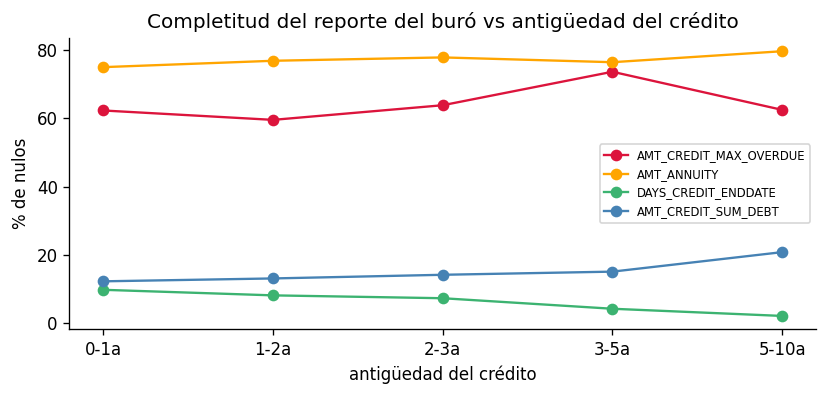

In [33]:
# ¿el % de nulos cambia con la antigüedad del crédito? sería un missing temporal del propio
# buró, y matiza cómo pesar créditos antiguos frente a recientes al agregar
edad_bins = [0, 1, 2, 3, 5, 10, 15, np.inf]
edad_labels = ['0-1a', '1-2a', '2-3a', '3-5a', '5-10a', '10-15a', '15a+']
edad = pd.cut(bureau_t['DAYS_CREDIT_YEARS'], bins=edad_bins, labels=edad_labels)

cols_null = ['AMT_CREDIT_MAX_OVERDUE', 'AMT_ANNUITY', 'DAYS_CREDIT_ENDDATE', 'AMT_CREDIT_SUM_DEBT']
drift = bureau_t.groupby(edad, observed=True).apply(
    lambda g: pd.Series({c: g[c].isnull().mean() * 100 for c in cols_null})
)
drift['n'] = bureau_t.groupby(edad, observed=True).size()
print("% de nulos por antigüedad del crédito (DAYS_CREDIT):")
display(drift.round(2))

# gráfico de líneas, una por variable
fig, ax = plt.subplots(figsize=(7, 3.4))
x = range(len(drift.index))
paleta = [color_default, color_nulo, color_presente, color_no_default]
for col, cl in zip(cols_null, paleta):
    ax.plot(list(x), drift[col].values, marker='o', label=col, color=cl, linewidth=1.4)
ax.set_xticks(list(x))
ax.set_xticklabels(drift.index)
ax.set(title='Completitud del reporte del buró vs antigüedad del crédito',
       xlabel='antigüedad del crédito', ylabel='% de nulos')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

La completitud del reporte del buró **sí deriva con la antigüedad del crédito, y en direcciones opuestas según la variable**, refutando mi hipótesis de partida (esperaba un patrón único de "más antiguo = peor reportado").

`AMT_CREDIT_SUM_DEBT`: la tasa de nulos sube de forma monótona con la edad del crédito, de 12,24% en los créditos de menos de 1 año a 20,79% en los de 5 a 10 años. Tiene lógica de negocio: cuando un crédito antiguo ya se ha liquidado, el buró deja de reportar la deuda pendiente (que ya no existe), así que la ausencia aumenta con el tiempo. Esto es un MNAR temporal real y matiza las agregaciones de exposición: para clientes con historial largo, más de sus créditos viejos tienen deuda nula, que en la suma entra como 0 y por tanto `BUREAU_TOTAL_DEBT` y `BUREAU_DEBT_CREDIT_RATIO` **subestiman** la carga en esos clientes.

`DAYS_CREDIT_ENDDATE`: el patrón es el inverso, la tasa de nulos baja de 9,76% (de 0 a 1 año) a 2,11% (de 5 a 10 años). Encaja con lo visto al analizar la ausencia de dato, donde el 80,8% de sus nulos eran 'Credit card' (revolving reciente sin fecha de fin planificada); a más antigüedad, menos revolving vivo y más créditos a término ya cerrados con fecha conocida.

`AMT_CREDIT_MAX_OVERDUE` (entre 59% y 74%, no monótona) y `AMT_ANNUITY` (del 75% al 80%, subida leve) son prácticamente planas respecto a la antigüedad: su nulo no depende del tiempo, lo que refuerza la clasificación MCAR que les di al analizar la ausencia de dato y significa que `BUREAU_MAX_OVERDUE_EVER` no queda sesgada por la longitud del historial como sí lo está la deuda.

Es un control diagnóstico (decisión, no transformación): no cambia la imputación aquí, pero deja anotado para la fase de features que la agregación de deuda conviene normalizarla por número de créditos con deuda reportada, no por el total, para no penalizar artificialmente a los historiales largos.

### 8. Análisis de Outliers

In [34]:
# numéricas continuas seleccionadas
cols_outliers = [
    'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 
    'AMT_CREDIT_SUM_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE', 'AMT_ANNUITY', 
    'CREDIT_DAY_OVERDUE', 'CNT_CREDIT_PROLONG'
]

# descriptivos y percentiles
desc_outliers = bureau_t[cols_outliers].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
desc_outliers['Diferencia Absoluta |Máx - p99|'] = (desc_outliers['max'] - desc_outliers['99%']).abs()

rename_map = {'mean': 'Media', '1%': 'p1', '5%': 'p5', '25%': 'p25', '50%': 'p50', '75%': 'p75', '95%': 'p95', '99%': 'p99', 'max': 'Máximo'}
df_stats = (desc_outliers.rename(columns=rename_map)
            .sort_values(by='Diferencia Absoluta |Máx - p99|', ascending=False)
            [['Media', 'p1', 'p5', 'p25', 'p50', 'p75', 'p95', 'p99', 'Máximo', 'Diferencia Absoluta |Máx - p99|']])

format_es = lambda x: "" if pd.isna(x) else f"{x}".replace(",", "TEMP").replace(".", ",").replace("TEMP", ".")

print("Tabla de percentiles (ordenada por Diferencia Absoluta |Máx - p99|):")
display(df_stats.style.format(format_es))

Tabla de percentiles (ordenada por Diferencia Absoluta |Máx - p99|):


,Media,p1,p5,p25,p50,p75,p95,p99,Máximo,Diferencia Absoluta |Máx - p99|
AMT_CREDIT_SUM,"351688,875","0,0","12474,224609375","51165,0","124698,125","308250,0","1350000,0","3600000,0","396000000,0","392400000,0"
AMT_CREDIT_SUM_DEBT,"135889,03125","0,0","0,0","0,0","0,0","39654,0","623038,5","2250000,0","170100000,0","167850000,0"
AMT_CREDIT_MAX_OVERDUE,"3942,851806640625","0,0","0,0","0,0","0,0","0,0","14175,0","41755,5","115987184,0","115945428,5"
AMT_ANNUITY,"15763,0087890625","0,0","0,0","0,0","67,5","13990,5","45931,5","114889,5","59586684,0","59471794,5"
AMT_CREDIT_SUM_LIMIT,"6363,68798828125","0,0","0,0","0,0","0,0","0,0","5862,93310546875","203109,625","4705600,5","4502490,875"
AMT_CREDIT_SUM_OVERDUE,"40,10546875","0,0","0,0","0,0","0,0","0,0","0,0","0,0","3756681,0","3756681,0"
CREDIT_DAY_OVERDUE,"0,8887611963216351","0,0","0,0","0,0","0,0","0,0","0,0","0,0","2792,0","2792,0"
CNT_CREDIT_PROLONG,"0,007278248852643611","0,0","0,0","0,0","0,0","0,0","0,0","0,0","9,0","9,0"


In [35]:
# identificación de severos: ratio Máx/p99 > 3x
ratio = desc_outliers['max'] / desc_outliers['99%'].replace(0, np.nan)
print("Variables con outliers severos (ratio Máx/p99 > 3x):")
print(ratio[ratio > 3].sort_values(ascending=False))
print(f"\nVariables con p99 = 0 (ratio indefinido): {list(desc_outliers[desc_outliers['99%'] == 0].index)}")

Variables con outliers severos (ratio Máx/p99 > 3x):
AMT_CREDIT_MAX_OVERDUE   2777.77
AMT_ANNUITY               518.64
AMT_CREDIT_SUM             110.0
AMT_CREDIT_SUM_DEBT         75.6
AMT_CREDIT_SUM_LIMIT       23.17
dtype: float64

Variables con p99 = 0 (ratio indefinido): ['AMT_CREDIT_SUM_OVERDUE', 'CREDIT_DAY_OVERDUE', 'CNT_CREDIT_PROLONG']


De las 8 variables numéricas candidatas, las 5 con p99 > 0 superan todas el umbral de severidad (ratio Máx/p99 > 3x): `AMT_CREDIT_MAX_OVERDUE` (2.777,77x), `AMT_ANNUITY` (518,64x), `AMT_CREDIT_SUM` (110,00x), `AMT_CREDIT_SUM_DEBT` (75,60x) y `AMT_CREDIT_SUM_LIMIT` (23,17x). Esto por sí solo no implicaría que haya que cappear, pero siguiendo el criterio ya aplicado anteriormente en application_train, la dirección y el tamaño del delta de default es lo que decidirá el tratamiento, no el ratio.

Las 3 variables restantes (`AMT_CREDIT_SUM_OVERDUE`, `CREDIT_DAY_OVERDUE`, `CNT_CREDIT_PROLONG`) tienen p99 = 0, coherente con lo ya visto en distribuciones: 99,75%, 99,75% y 99,40% de ceros respectivamente. El ratio Máx/p99 es indefinido, así que para estas tres el criterio de "severo" pasa a ser simplemente "valor > 0", el mismo ajuste que hice con `AMT_REQ_CREDIT_BUREAU_DAY` en application_train cuando su p99 también era 0.

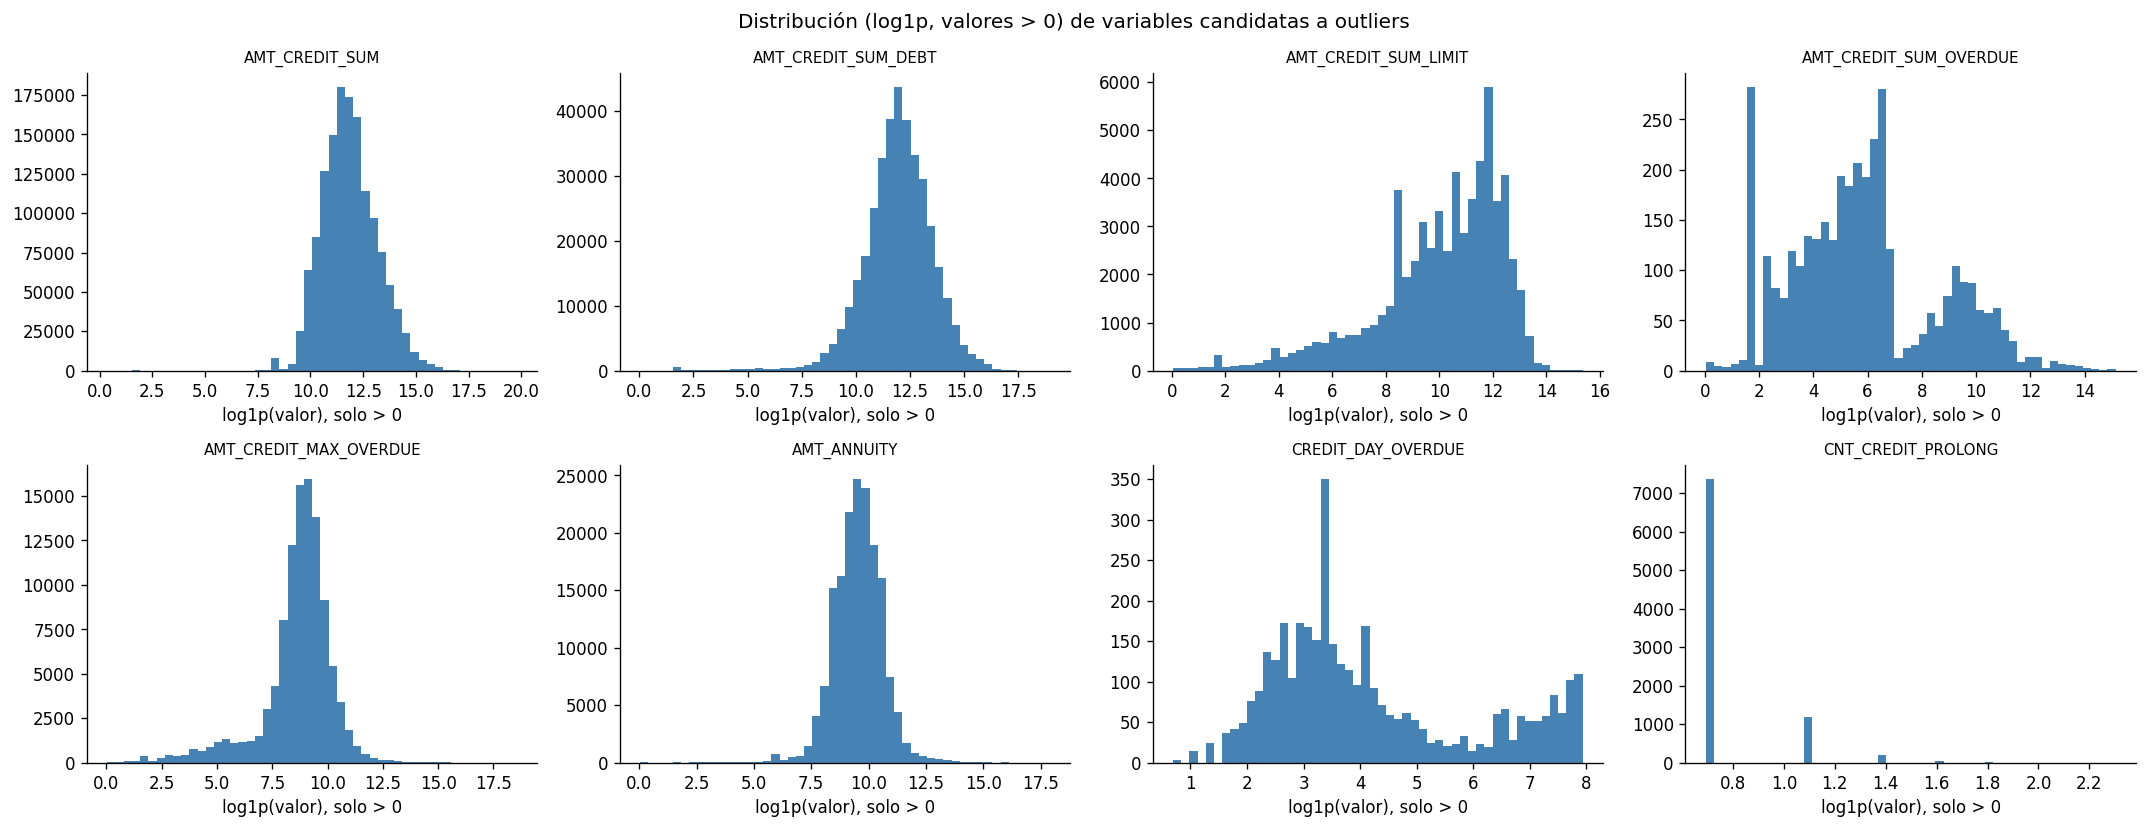

In [36]:
# boxplots e histogramas en log, solo valores > 0 en las variables de mora
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flat, cols_outliers):
    data_pos = bureau_t[col].dropna()
    data_pos = data_pos[data_pos > 0]
    ax.hist(np.log1p(data_pos), bins=50, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('log1p(valor), solo > 0')
plt.suptitle('Distribución (log1p, valores > 0) de variables candidatas a outliers')
plt.tight_layout()
plt.show()

In [37]:
# tabla de delta de default (outliers vs normales) + Chi2/Fisher + Bonferroni
alpha_bonf_out = 0.05 / len(cols_outliers)
p99_vals = desc_outliers['99%']
total_rows = len(bureau_t)

rows_out = []
for col in cols_outliers:
    thresh = p99_vals[col]
    is_out = bureau_t[col] > (thresh if thresh > 0 else 0)
    # la linea base son los creditos con dato, no todo lo demas: incluir los nulos
    # mezclaria la senal de la cola con la de la ausencia, que se analiza aparte
    is_norm = bureau_t[col].notna() & ~is_out

    n_out = is_out.sum()
    n_out_1 = bureau_t.loc[is_out, 'TARGET'].sum()
    n_out_0 = n_out - n_out_1

    n_norm = is_norm.sum()
    n_norm_1 = bureau_t.loc[is_norm, 'TARGET'].sum()
    n_norm_0 = n_norm - n_norm_1

    rate_out = (n_out_1 / n_out) * 100 if n_out > 0 else 0
    rate_norm = (n_norm_1 / n_norm) * 100

    ct = [[n_norm_0, n_norm_1], [n_out_0, n_out_1]]
    min_cell = min(n_norm_0, n_norm_1, n_out_0, n_out_1)

    p_val = fisher_exact(ct)[1] if min_cell < 5 else chi2_contingency(ct)[1]
    test_usado = 'Fisher' if min_cell < 5 else 'Chi2'

    rows_out.append({
        'Variable': col,
        'Criterio': f"> p99 ({format_es(thresh)})" if thresh > 0 else "> 0",
        'N outliers': n_out,
        'N normales': n_norm,
        '% outliers': (n_out / total_rows) * 100,
        'Tasa default outliers': rate_out,
        'Tasa default normales': rate_norm,
        'Delta (pp)': rate_out - rate_norm,
        'Test': test_usado,
        'p-valor': p_val,
        'Sig. Bonferroni': 'Sí' if p_val < alpha_bonf_out else 'No'
    })

df_evidencia_outliers = pd.DataFrame(rows_out).sort_values('Delta (pp)', ascending=False).reset_index(drop=True)

display(df_evidencia_outliers.style.format({
    'N outliers': '{:,}',
    'N normales': '{:,}',
    '% outliers': '{:.4f}%',
    'Tasa default outliers': '{:.4f}',
    'Tasa default normales': '{:.4f}',
    'Delta (pp)': '{:+.4f}',
    'p-valor': '{:.2e}'
}).map(
    lambda v: f"background-color: {'#a8d5a2' if v == 'Sí' else '#f4a4a4'}",
    subset=['Sig. Bonferroni']
))

,Variable,Criterio,N outliers,N normales,% outliers,Tasa default outliers,Tasa default normales,Delta (pp),Test,p-valor,Sig. Bonferroni
0,AMT_CREDIT_SUM_OVERDUE,> 0,"3,644","1,461,681",0.2487%,18.6883,7.7882,+10.9000,Chi2,4.72e-132,Sí
1,CREDIT_DAY_OVERDUE,> 0,"3,706","1,461,619",0.2529%,18.2137,7.7890,+10.4247,Chi2,5.74e-123,Sí
2,AMT_CREDIT_MAX_OVERDUE,"> p99 (41755,5)","5,167","511,613",0.3526%,10.7993,7.9603,+2.8390,Chi2,8.42e-14,Sí
3,CNT_CREDIT_PROLONG,> 0,"8,820","1,456,505",0.6019%,8.7302,7.8098,+0.9204,Chi2,1.42e-03,Sí
4,AMT_ANNUITY,"> p99 (114889,5)","3,352","331,960",0.2288%,9.0990,8.5989,+0.5001,Chi2,3.19e-01,No
5,AMT_CREDIT_SUM_DEBT,"> p99 (2250000,0)","12,412","1,229,819",0.8470%,6.5582,7.8899,-1.3317,Chi2,4.67e-08,Sí
6,AMT_CREDIT_SUM_LIMIT,"> p99 (203109,625)","9,757","965,898",0.6659%,6.1392,7.8256,-1.6864,Chi2,7.35e-10,Sí
7,AMT_CREDIT_SUM,"> p99 (3600000,0)","14,651","1,450,671",0.9998%,4.9621,7.8442,-2.8820,Chi2,3.66e-38,Sí


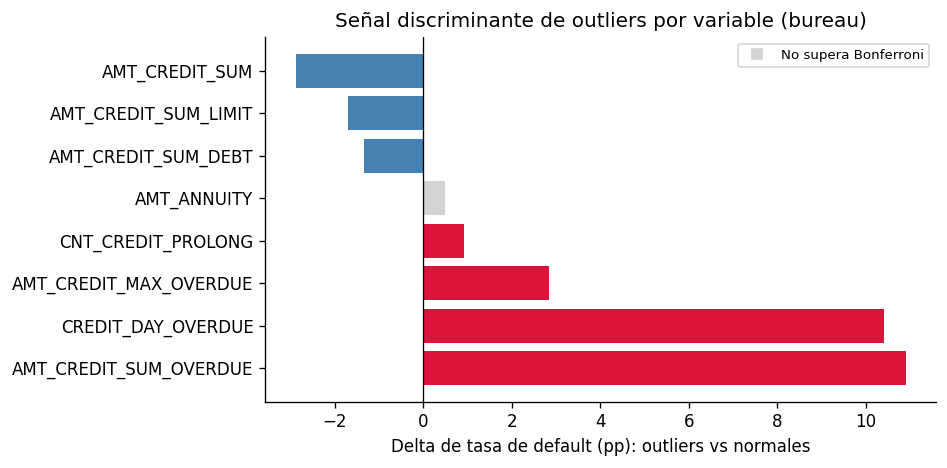

In [38]:
# gráfico de barras del delta de default por variable
# la no significativa va en gris: colorearla por signo afirmaría una dirección que el test no sostiene
colors_out = ['lightgrey' if sig == 'No' else (color_default if d > 0 else color_no_default)
              for d, sig in zip(df_evidencia_outliers['Delta (pp)'], df_evidencia_outliers['Sig. Bonferroni'])]
plt.figure(figsize=(8, 4))
plt.barh(df_evidencia_outliers['Variable'], df_evidencia_outliers['Delta (pp)'], color=colors_out)
plt.axvline(0, color='black', linewidth=0.8)
plt.plot([], [], 's', color='lightgrey', label='No supera Bonferroni')
plt.legend(loc='upper right', fontsize=8)
plt.xlabel('Delta de tasa de default (pp): outliers vs normales')
plt.title('Señal discriminante de outliers por variable (bureau)')
plt.tight_layout()
plt.show()

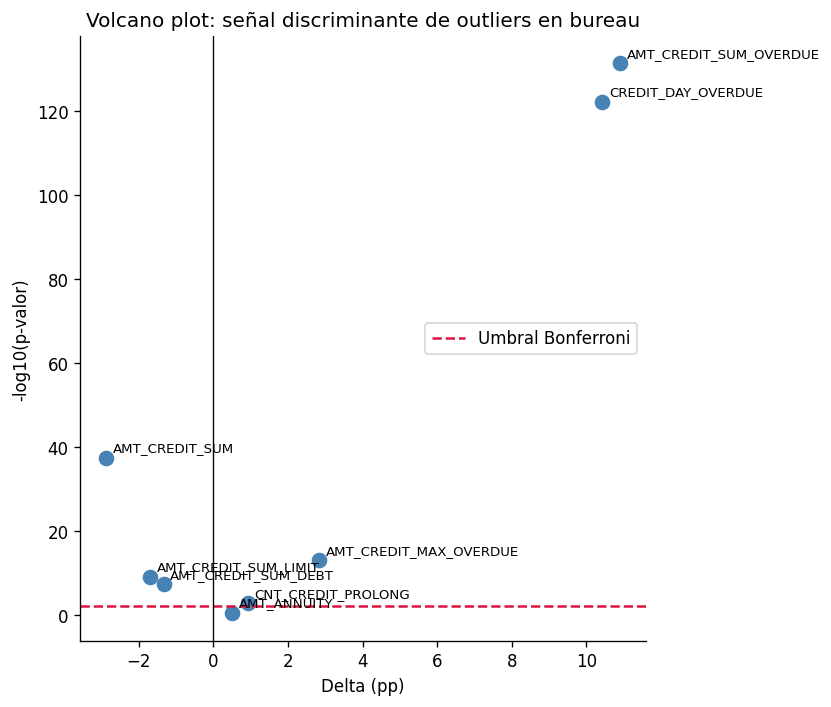

In [39]:
# volcano plot: delta vs -log10(p-valor), umbral Bonferroni marcado
y_vals = -np.log10(df_evidencia_outliers['p-valor'])
x_vals = df_evidencia_outliers['Delta (pp)']

plt.figure(figsize=(7, 6))
plt.scatter(x_vals, y_vals, color='steelblue', s=70)

for var, x, y in zip(df_evidencia_outliers['Variable'], x_vals, y_vals):
    plt.annotate(var, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.axhline(-np.log10(alpha_bonf_out), color='crimson', linestyle='--', label='Umbral Bonferroni')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Volcano plot: señal discriminante de outliers en bureau')
plt.xlabel('Delta (pp)')
plt.ylabel('-log10(p-valor)')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# consistencia lógica de valores negativos (AMT_CREDIT_SUM_DEBT, AMT_CREDIT_SUM_LIMIT)
target_sum = bureau_t['TARGET'].sum()
total_rows = len(bureau_t)
target_zeros = total_rows - target_sum

for col in ['AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT']:
    is_neg = bureau_t[col] < 0
    n_neg = is_neg.sum()
    
    if n_neg > 0:
        n_neg_1 = bureau_t.loc[is_neg, 'TARGET'].sum()
        n_neg_0 = n_neg - n_neg_1
        
        n_pos_1 = target_sum - n_neg_1
        n_pos_0 = target_zeros - n_neg_0
        
        rate_neg = (n_neg_1 / n_neg) * 100
        rate_no_neg = (n_pos_1 / (total_rows - n_neg)) * 100
        
        ct = [[n_pos_0, n_pos_1], [n_neg_0, n_neg_1]]
        min_cell = min(n_pos_0, n_pos_1, n_neg_0, n_neg_1)
        p_val = fisher_exact(ct)[1] if min_cell < 5 else chi2_contingency(ct)[1]
    else:
        rate_neg = 0.0
        rate_no_neg = (target_sum / total_rows) * 100
        p_val = 1.0

    print(f"{col}: {n_neg} negativos ({round(is_neg.mean()*100, 4)}%), mínimo {format_es(bureau_t[col].min())}")
    print(f"- CREDIT_ACTIVE de negativos:\n{bureau_t.loc[is_neg, 'CREDIT_ACTIVE'].value_counts()}")
    print(f"- Tasa default: {round(rate_neg, 4)}% (negativos) vs {round(rate_no_neg, 4)}% (resto), p-valor = {p_val}\n")

AMT_CREDIT_SUM_DEBT: 8418 negativos (0.5745%), mínimo -4705600,5
- CREDIT_ACTIVE de negativos:
CREDIT_ACTIVE
Active      6222
Closed      2196
Bad debt       0
Sold           0
Name: count, dtype: int64
- Tasa default: 7.7809% (negativos) vs 7.8155% (resto), p-valor = 0.9223174978600976

AMT_CREDIT_SUM_LIMIT: 351 negativos (0.024%), mínimo -586406,125
- CREDIT_ACTIVE de negativos:
CREDIT_ACTIVE
Active      298
Closed       46
Sold          5
Bad debt      2
Name: count, dtype: int64
- Tasa default: 20.2279% (negativos) vs 7.8124% (resto), p-valor = 1.0762070871413957e-17



In [41]:
# validez de dominio: separar error de captura (revertir por validez) de extremo con señal.
# umbrales de plausibilidad de negocio, no estadísticos: por encima el valor es implausible
# para un microcrédito y es error de captura, tenga o no señal en la cola
lim_importe = {
    "AMT_CREDIT_SUM": 50_000_000,        # crédito único > 50M implausible
    "AMT_CREDIT_SUM_DEBT": 50_000_000,
    "AMT_CREDIT_MAX_OVERDUE": 50_000_000,
    "AMT_ANNUITY": 10_000_000,           # cuota > 10M implausible
}
print("Importes fuera de rango de dominio (error de captura, revertir o NaN por validez en FE):")
for col, lim in lim_importe.items():
    m = bureau_t[col] > lim
    print(f"  {col}: {int(m.sum())} filas > {lim:,} | máx = {format_es(round(bureau_t[col].max(), 0))}")

# fechas fuera del rango plausible (el buró reporta unos 8 años de historial)
fut = bureau_t["DAYS_CREDIT_ENDDATE"] > 20 * 365.25                                   # vencimiento > 20 años = placeholder revolving
old = bureau_t[["DAYS_ENDDATE_FACT", "DAYS_CREDIT_UPDATE"]].min(axis=1) < -30 * 365.25  # cierre/actualización < -30 años
past_end = bureau_t["DAYS_CREDIT_ENDDATE"] < -30 * 365.25                             # vencimiento "pasado" > 30 años = error historico
print("\nFechas fuera de rango plausible:")
print(f"  DAYS_CREDIT_ENDDATE > 20 años (placeholder de revolving): {int(fut.sum())}")
print(f"  cierre/actualización < -30 años (histórico implausible): {int(old.sum())}")
print(f"  DAYS_CREDIT_ENDDATE < -30 años (vencimiento 'pasado' implausible): {int(past_end.sum())}")

# los importes se suman asumiendo una sola moneda, pero CREDIT_CURRENCY tiene 4:
# sumar a través de monedas mezcla unidades, y eso no es error de captura
no_c1 = bureau_t["CREDIT_CURRENCY"] != "currency 1"
med_c1 = bureau_t.loc[~no_c1, "AMT_CREDIT_SUM"].median()
med_no_c1 = bureau_t.loc[no_c1, "AMT_CREDIT_SUM"].median()
print("\nHomogeneidad de moneda (importes no-currency-1 entran crudos en las sumas):")
print(f"  filas no-currency-1: {int(no_c1.sum())} | clientes afectados: {bureau_t.loc[no_c1, 'SK_ID_CURR'].nunique()}")
print(f"  mediana AMT_CREDIT_SUM: currency 1 = {format_es(round(med_c1, 0))} | no-currency-1 = {format_es(round(med_no_c1, 0))} "
      f"(x{med_no_c1 / med_c1:.1f})")


Importes fuera de rango de dominio (error de captura, revertir o NaN por validez en FE):
  AMT_CREDIT_SUM: 40 filas > 50,000,000 | máx = 396000000,0
  AMT_CREDIT_SUM_DEBT: 6 filas > 50,000,000 | máx = 170100000,0
  AMT_CREDIT_MAX_OVERDUE: 2 filas > 50,000,000 | máx = 115987184,0
  AMT_ANNUITY: 17 filas > 10,000,000 | máx = 59586684,0

Fechas fuera de rango plausible:
  DAYS_CREDIT_ENDDATE > 20 años (placeholder de revolving): 52497
  cierre/actualización < -30 años (histórico implausible): 96
  DAYS_CREDIT_ENDDATE < -30 años (vencimiento 'pasado' implausible): 146

Homogeneidad de moneda (importes no-currency-1 entran crudos en las sumas):
  filas no-currency-1: 1231 | clientes afectados: 968
  mediana AMT_CREDIT_SUM: currency 1 = 124425,0 | no-currency-1 = 2064600,0 (x16.6)


Este control es un eje distinto al análisis de outliers del análisis de los extremos: allí decidí no cappear los extremos porque tenían señal real, pero un **error de dominio** (un valor físicamente implausible) se revierte por validez con independencia de que tenga señal, porque no representa a un cliente real sino un dato roto que distorsionaría las sumas y ratios a nivel cliente y de la fase de features. Separo por tanto dos ejes que hasta aquí estaban mezclados:

- **Error de dominio (revertir a NaN o cap por validez en la fase de features):** los máximos implausibles de `AMT_CREDIT_SUM` (396M en los créditos enlazados a train; 585M en la tabla completa), `AMT_CREDIT_SUM_DEBT` (170M), `AMT_CREDIT_MAX_OVERDUE` (116M) y `AMT_ANNUITY` (59,6M en los créditos enlazados) son casi imposibles para un microcrédito y replican el caso de `AMT_INCOME_TOTAL` (117M) de application_train (al mirar las distribuciones,.6 del proyecto), donde se decidió cap 3×p99 por error de captura. Son poquísimas filas, pero entran crudas en `BUREAU_TOTAL_DEBT` y `BUREAU_DEBT_CREDIT_RATIO`, así que su disposición es revertir por validez, aparte de la decisión de señal del análisis de los extremos.
- **Placeholder de fecha (filtrar antes de agregar):** los vencimientos `DAYS_CREDIT_ENDDATE > 20 años` (casi todos "Credit card") son marcadores del sistema, no fechas reales; ya decidí filtrarlos antes de agregar al mirar el eje temporal. Los cierres o actualizaciones a más de 30 años, y el extremo pasado de `DAYS_CREDIT_ENDDATE` (vencimientos "terminados" hace más de 30 años, unas 146 filas con mínimo de −42.060 días ≈ 115 años), son histórico implausible y reciben el mismo trato.
- **Extremo plausible con señal (conservar):** el resto de la cola de importes y de mora, que el análisis de los extremos mantiene por su señal discriminante y que no es un error de dominio.
- **Mezcla de unidad monetaria (normalizar/excluir antes de agregar en la fase de features):** decidí eliminar `CREDIT_CURRENCY` por su varianza casi nula (99,92% en currency 1), pero eso es una decisión de *encoding*, no de *unidad*: al agregar los importes por suma (`BUREAU_TOTAL_DEBT` y `_total_credit`, y con ellos `BUREAU_DEBT_CREDIT_RATIO`) estoy asumiendo que todos están en la misma moneda, y no lo están. Las 1.231 filas en currency 2/3/4 (968 clientes de train) no son error de captura, son importes válidos en otra moneda, pero su mediana de `AMT_CREDIT_SUM` es ≈16,6 veces la de currency 1 (2.064.600 frente a 124.425), señal de que están en otra unidad. Sumadas crudas inflan la deuda y el ratio de esos 968 clientes. Es un eje distinto del error de captura (plausibilidad) y de la señal: es homogeneidad de unidades. La disposición para la fase de features es convertir esos importes a currency 1 con un tipo de cambio o, más simple y seguro dado el volumen (0,08%), excluirlos de las sumas y marcar el cliente con un flag `BUREAU_HAS_FOREIGN_CURRENCY`, para que la moneda extranjera no contamine los agregados.

La disposición es una decisión para la fase de features (el EDA no modifica datos): aquí solo cuantifico y clasifico. La regla general que fijo es que **la validez de dominio se decide por plausibilidad, no por señal**, y es previa e independiente del tratamiento de outliers.

Sobre los umbrales de dominio (50M en importes, 10M en cuota): se fijan muy por encima del p99 (`AMT_CREDIT_SUM` p99 = 3,6M) para capturar solo el error de captura de la cola extrema (585M/396M/170M/116M) sin tocar el tramo plausible p99–50M; son cortes de **plausibilidad de negocio** para un microcrédito, no estadísticos, y su calibración fina es decisión de la fase de features.

Aplicando el criterio combinado (anterior) delta + Bonferroni (alpha = 0,05/8 = 0,00625) sobre las 8 variables candidatas, encuentro exactamente el mismo patrón de 2 direcciones que en application_train: mora con delta positivo (mayor riesgo) y tamaño de
crédito con delta negativo (perfil premium, menor riesgo). 7 de las 8 resultan significativas tras Bonferroni, y la relevancia de negocio varía mucho por variable.

Comparo la cola contra los créditos **con dato**, no contra todo lo demás. Meter los nulos en el grupo de referencia mezclaría la señal del extremo con la de la ausencia de dato, que ya analicé por su cuenta, y en las variables con mucha ausencia eso desplaza la línea base lo bastante como para cambiar una decisión: el grupo de referencia de `AMT_CREDIT_MAX_OVERDUE` (64,73% de ausencia) baja de 1.460.158 a 511.613 créditos, y el de `AMT_ANNUITY` (77,12%) a 331.960. Por eso la tabla declara el n de cada línea base y no solo el de la cola.

`AMT_CREDIT_SUM_OVERDUE` (> 0, n=3.644, 0,2487%): tiene delta de +10,90pp (18,69% frente a 7,79%), el mayor de toda la tabla. Confirma que la mora activa reportada por el buró es la señal individual más fuerte de bureau a nivel de crédito.

`CREDIT_DAY_OVERDUE` (> 0, n=3.706, 0,2529%) es prácticamente idéntico: +10,42pp (18,21% frente a 7,79%), coherente con que ambas capturan
el mismo fenómeno de mora activa desde ángulos distintos (importe y duración). Su correlación cruzada por crédito es baja (r = 0,10), y de ahí deduje que aportaban señal independiente. Al agregar por cliente resulta que no: la V de Cramér entre las dos flags es 0,9311 con un Jaccard del 87,3%, o sea que marcan al mismo cliente. El r bajo medía el co-movimiento de las magnitudes, que efectivamente no escalan juntas, y no la co-ocurrencia del evento, que es lo que decide si sobra una de las dos.

`AMT_CREDIT_MAX_OVERDUE` (> p99 = 41.755,50, n=5.167, 0,3526%): delta de +2,84pp (10,80% frente a 7,96%). Confirma la hipótesis que planteé al analizar la ausencia de dato: esta variable es probablemente la más valiosa del bloque de mora histórica, y su señal real está en la cola extrema, no en la mediana ni en el hueco.

`CNT_CREDIT_PROLONG` (> 0, n=8.820, 0,6019%): delta de +0,92pp (8,73% frente a 7,81%), significativo pero el más débil de los que pasan el umbral. Con 99,40% de ceros y tras decidir que la trataré como flag `HAS_BEEN_PROLONGED`, esto me confirma que el conteo no aportaría más que el flag binario.

`AMT_ANNUITY` (> p99 = 114.889,50, n=3.352, 0,2288%): delta de +0,50pp (9,10% frente a 8,60%) con p = 0,319, la única de las 8 que no pasa Bonferroni. Es el caso que justifica la línea base restringida. Comparada contra todo el resto daba +1,29pp y pasaba raspando (p = 6,15e-03 contra un alpha de 6,25e-03), pero ese delta no era de la cola: era la diferencia entre los créditos que reportan cuota (8,60% de default) y los que no la reportan, que están pegados a la base y arrastraban la referencia hacia abajo. Medida solo entre los 335.312 créditos con cuota reportada, la cola no discrimina. La reclasifico como mezcla de poblaciones y dejo de tratarla como candidata con señal: lo que discrimina de esta variable es la presencia de cuota, no su magnitud extrema.

`AMT_CREDIT_SUM_DEBT` (> p99 = 2.250.000,00, n=12.412, 0,8470%): delta de -1,33pp (6,56% frente a 7,89%), señal débil.

`AMT_CREDIT_SUM_LIMIT` (> p99 = 203.109,62, n=9.757, 0,6659%): delta de -1,69pp (6,14% frente a 7,83%), también débil.

`AMT_CREDIT_SUM` (> p99 = 3.600.000,00, n=14.651, 0,9998%): delta de -2,88pp (4,96% frente a 7,84%), el mayor de las variables de tamaño de crédito. Este es idéntico y replicaría directamente el perfil premium
que identifiqué con `AMT_CREDIT` y `AMT_GOODS_PRICE` en application_train: en donde clientes con crédito reportado muy grande en su historial de buró tienen menor riesgo.

Por otro lado, respecto a los valores negativos, planteé la hipótesis de que los negativos en `AMT_CREDIT_SUM_DEBT` y `AMT_CREDIT_SUM_LIMIT` estaban relacionados con la captura (saldo a favor tras sobrepago). Sin embargo, tras comprobarlo `AMT_CREDIT_SUM_DEBT` (8.418 negativos, 0,5745%, mínimo -4.705.600,50) no muestra diferencia real (7,78% frente a 7,82% de default, delta prácticamente nulo), lo que es consistente con no tener señal que lo respalde. Pero `AMT_CREDIT_SUM_LIMIT` (351 negativos, 0,0240%, mínimo
-586.406,10) muestra un delta de +12,42pp (20,23% frente a 7,81%), significativo pese al tamaño de la muestra reducido (Chi2, p = 1,08e-17). Un límite de crédito negativo en una tarjeta revolving
probablemente indica algún estilo de sobregiro activo, y es la señal de riesgo más fuerte de todo el análisis de extremos de bureau.

En resumen: de las 8 variables, 5 muestran señal fuerte y con sentido de negocio (3 de mora con delta positivo, 1 de tamaño con delta negativo fuerte, y el lo del límite negativo), 2 caen con señal débil (banda de 1 a 2 pp) donde aplazo la decisión de como tratarlas, y 1 se cae del análisis al medirla contra su población correcta.

**Tabla de decisiones final por variable**

| Variable | Delta (pp) | Estrategia | Justificación |
|---|---|---|---|
| `AMT_CREDIT_SUM` | -2,88 | No cappear | Señal real de perfil premium (crédito grande = menor riesgo), replica AMT_CREDIT de application_train |
| `AMT_CREDIT_SUM_DEBT` | -1,33 | No cappear | Señal débil (banda de 1 a 2 pp), evaluar IV en la fase de features. Negativos (0,57%) sin señal: conservar tal cual |
| `AMT_CREDIT_SUM_LIMIT` | -1,69 | No cappear ni clipear negativos | Señal débil en p99, pero negativos (0,02%) tienen delta +12,42pp: crear BUREAU_NEGATIVE_LIMIT_FLAG a nivel cliente |
| `AMT_CREDIT_SUM_OVERDUE` | +10,90 | No cappear | Mayor señal de mora activa de la tabla, p99=0 hace el cap inaplicable, valor real es la señal |
| `AMT_CREDIT_MAX_OVERDUE` | +2,84 | No cappear | Confirma hipótesis del análisis de la ausencia de dato (missings): señal real en la cola, variable más valiosa del bloque de mora |
| `AMT_ANNUITY` | +0,50 | Descartar la cola como candidata | No significativa (p = 0,319) medida entre los créditos con cuota reportada: el +1,29pp que daba contra todo el resto era el contraste entre reportar y no reportar, no el de la cola |
| `CREDIT_DAY_OVERDUE` | +10,42 | No cappear | p99=0, señal extrema de mora, especular con binarización queda para la fase de features |
| `CNT_CREDIT_PROLONG` | +0,92 | No cappear (ya es flag) | Confirma decisión previa de las distribuciones (distribuciones): tratar como HAS_BEEN_PROLONGED, el conteo no aporta más |


A diferencia de application_train, en bureau ninguna variable se cappeará: las 7 candidatas que conservan señal (real o débil pero significativa) tienen más información en su
valor continuo que en una versión capeada, y la que se cae, `AMT_ANNUITY`, no sale por capping sino por reclasificación. El patrón de dos direcciones (mora = más riesgo, tamaño de crédito = menos riesgo) replica exactamente lo encontrado en application_train,
reforzando así mi hipótesis e idea de perfil "cliente premium".

Lo más importante está en los valores negativos de `AMT_CREDIT_SUM_LIMIT` (delta +12,42pp, el mayor del bloque con solo 0,02% de casos), que convertiré en una feature nueva para más adelante (`BUREAU_NEGATIVE_LIMIT_FLAG`).

Con esto cierro esta primera fase de bureau. El siguiente paso que aplicaré será el diseño de la estrategia de agregar a nivel `SK_ID_CURR` y cruzar con el `TARGET` real.

**Nota metodológica sobre el análisis por crédito (independencia).** Todos los contrastes de esta fase (Chi2, Mann-Whitney, z-test) se calculan sobre los 1.465.325 créditos como si fueran observaciones independientes, pero están anidados en 263.491 clientes (~5,6 créditos/cliente): los créditos de un mismo cliente comparten `TARGET` y perfil, así que el N efectivo es el de clientes, no el de filas. Esto hace que **los p-valores de nivel fila sean anticonservadores** (significancia inflada por pseudoreplicación), y es parte de por qué tantos salen "significativos solo por volumen". Por eso las decisiones no se apoyan en el p-valor de fila sino en el effect size y, sobre todo, en la revalidación a nivel cliente, donde cada cliente cuenta una vez. Las cifras de fila sirven para priorizar y formular hipótesis, no como veredicto.

In [42]:
# ¿deuda > crédito es dato real (intereses y mora acumulados) o error de captura?
# el bin de sobreendeudado del ratio agregado descansa sobre esta coherencia
d = bureau_t['AMT_CREDIT_SUM_DEBT']
c = bureau_t['AMT_CREDIT_SUM']
both = d.notna() & c.notna() & (c > 0) & (d > 0)
sub = bureau_t.loc[both, ['AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM', 'TARGET']].copy()
sub['ratio'] = sub['AMT_CREDIT_SUM_DEBT'] / sub['AMT_CREDIT_SUM']
exc = sub['ratio'] > 1
n_both, n_exc = int(both.sum()), int(exc.sum())

print(f"Filas con deuda y crédito > 0: {n_both:,}")
print(f"Deuda > crédito (ratio > 1): {n_exc:,} = {n_exc / n_both * 100:.2f}% de esas filas, "
      f"{n_exc / len(bureau_t) * 100:.2f}% del total de bureau_t")

bandas = [
    ('leve 1-1,5 (intereses/mora acumulados)', (sub['ratio'] > 1) & (sub['ratio'] <= 1.5)),
    ('moderado 1,5-3', (sub['ratio'] > 1.5) & (sub['ratio'] <= 3)),
    ('grosero > 3 (error de captura)', sub['ratio'] > 3),
]
print("Distribución del exceso por plausibilidad de negocio:")
for nombre, m in bandas:
    k = int(m.sum())
    print(f"  {nombre}: {k:,} ({k / n_exc * 100:.2f}% de los excesos)")
print(f"  ratio máximo observado: {sub['ratio'].max():,.0f}x")

# de dónde sale la señal del bin > 1: exceso plausible frente a grosero
base = bureau_t['TARGET'].mean() * 100
print(f"Default (nivel fila): base bureau_t {base:.2f}% | "
      f"exceso > 1 {sub.loc[exc, 'TARGET'].mean() * 100:.2f}% | "
      f"grosero > 3 {sub.loc[sub['ratio'] > 3, 'TARGET'].mean() * 100:.2f}%")

Filas con deuda y crédito > 0: 367,414
Deuda > crédito (ratio > 1): 23,282 = 6.34% de esas filas, 1.59% del total de bureau_t
Distribución del exceso por plausibilidad de negocio:
  leve 1-1,5 (intereses/mora acumulados): 20,983 (90.13% de los excesos)
  moderado 1,5-3: 1,364 (5.86% de los excesos)
  grosero > 3 (error de captura): 935 (4.02% de los excesos)
  ratio máximo observado: 139,396x
Default (nivel fila): base bureau_t 7.82% | exceso > 1 16.99% | grosero > 3 13.16%


Antes de leer el bin ">1 (sobreendeudado)" del `BUREAU_DEBT_CREDIT_RATIO` agregado como señal de riesgo, verifico si deuda > crédito es dato real o error de captura. Esperaba que el grueso fuese intereses o mora acumulados sobre el principal (plausible), con una cola pequeña de valores rotos.

Se confirma. De las 367.414 filas con deuda y crédito positivos, 23.282 (6,34%) tienen deuda mayor que el crédito original, pero el **90,13% de ese exceso es leve** (ratio entre 1 y 1,5), compatible con intereses y penalizaciones acumulados sobre el principal, es decir, deuda real. Solo el 4,02% (935 filas) es un exceso grosero (ratio > 3), con un máximo absurdo de 139.396x que no representa a ningún cliente real, en la misma línea que los importes > 50M ya marcados en la validez de dominio.

La señal del bin, además, viene del exceso plausible y no del dato roto: a nivel fila el grupo con deuda > crédito tiene 16,99% de default frente al 7,82% base, y el subgrupo grosero (> 3x) baja a 13,16%, por debajo del exceso leve. Es decir, cappear o anular el exceso grosero no destruye la señal de sobreendeudamiento, que reside en los excesos moderados.

Decisión para la fase de features (decisión, no transformación): el exceso leve y moderado se conserva como carga de deuda real, pero el exceso grosero (ratio > 3, o los importes absolutos > 50M ya identificados) se revierte por validez de dominio (NaN o cap), porque entra crudo en `BUREAU_TOTAL_DEBT` y `BUREAU_DEBT_CREDIT_RATIO` y distorsionaría las sumas y el ratio de la agregación. Conecta con la validez de dominio y con el bin ">1" a nivel cliente.

### 9. Estrategia de agregación (nivel cliente)

Cierro el análisis por crédito, con el `TARGET` heredado, y arranco el de nivel cliente, donde agrego bureau al
nivel de `SK_ID_CURR` y cruzo con el `TARGET` real de cada cliente. Esta fase es exploratoria, en donde manejo las variables candidatas únicamente para medir su señal a
nivel cliente y fijar la agregación o no. No modificaré ninguna tabla de modelado ni parámetros dependientes del `TARGET`. Todas las agregaciones que realizo en esta fase son row-wise independientes del `TARGET` (counts, sums, max, min, ratios, flags), ya que su valor es idéntico se calcule sobre train, test.

Todas las transformaciones reales (agregación + imputación + encoding) y todo paso dependiente del `TARGET` o de parámetros las aplicaré en el pipeline de FE sobre el split de train (un punto crítico del diseño). Los cruces con default rate de aquí en adelante son descriptivos sobre train completo.

Agrego sobre `bureau` original (1.716.428 filas), no sobre el subconjunto enlazado a train, y hago un **left join** contra `application_train` para preservar los 44.020 clientes sin historial (quedan NaN tras el join, luego marcados con `HAS_BUREAU_HISTORY`). La función de agregación de cada
variable la elijo por lo aprendido a nivel fila:

| Feature | Cómo se calcula | Justificación |
|---|---|---|
| `BUREAU_LOAN_COUNT` | `size` de las filas del cliente | conteo de créditos previos (al contar los créditos por cliente, U invertida) |
| `BUREAU_ACTIVE/CLOSED/BAD_DEBT_COUNT` | conteo por estado de `CREDIT_ACTIVE` | jerarquía de riesgo Bad debt>Sold>Active>Closed |
| `BUREAU_CREDIT_TYPE_NUNIQUE` | `nunique` de `CREDIT_TYPE` | diversidad de producto |
| `BUREAU_MAX_OVERDUE_EVER` | `max` de `AMT_CREDIT_MAX_OVERDUE` | un solo evento grave es la señal |
| `BUREAU_HAS_ANY_OVERDUE` | `max` de `AMT_CREDIT_MAX_OVERDUE` > 0 | estructura tripartita nulos/ceros/mora |
| `BUREAU_CURRENT_OVERDUE_SUM` | `sum` de `AMT_CREDIT_SUM_OVERDUE` | mora activa, +10,90pp fila |
| `BUREAU_MAX_DAYS_OVERDUE` | `max` de `CREDIT_DAY_OVERDUE` | duración de la mora, a contrastar contra la gravedad |
| `BUREAU_OVERDUE_UNION` | `max` de la unión de las tres señales de mora | el nulo evaluado como `False` deja fuera a morosos activos |
| `BUREAU_TOTAL_DEBT` | `sum` de `AMT_CREDIT_SUM_DEBT` | exposición agregada |
| `BUREAU_DEBT_CREDIT_RATIO` | `sum(debt)/sum(credit)` | ratio de multicolinealidad r=0,67 |
| `BUREAU_NEGATIVE_LIMIT_FLAG` | `max` de `AMT_CREDIT_SUM_LIMIT` < 0 | sobregiro revolving, +12,42pp fila |
| `BUREAU_CREDITS_WITH_ANNUITY_COUNT` / `_RATIO` | `sum` y `mean` de la cuota reportada | señal en presencia, no importe |
| `BUREAU_DAYS_CREDIT_MIN` | `min` de `DAYS_CREDIT` | el crédito más antiguo = longitud del historial |
| `BUREAU_DAYS_CREDIT_MAX` | `max` de `DAYS_CREDIT` | recencia de la última solicitud, distinta de la longitud de historial |
| `BUREAU_CREDITS_PER_YEAR` | conteo entre los años observados, con suelo de medio año | la ventana de 8 años censura el conteo por la izquierda |
| `BUREAU_DAYS_ENDDATE_FACT_MIN` | `min` de `DAYS_ENDDATE_FACT`, solo en Closed | el cierre más antiguo, no el último |
| `BUREAU_DAYS_CREDIT_UPDATE_FLAG` | flag de menos de 6 meses sobre `DAYS_CREDIT_UPDATE` | prescindibilidad como continua |
| `BUREAU_ENDDATE_2_5Y_COUNT` | conteo de créditos a término con vencimiento de 2 a 5 años | da forma a la U de `DAYS_CREDIT_ENDDATE` |
| `BUREAU_DAYS_CREDIT_ENDDATE_MAX` | `max` de `DAYS_CREDIT_ENDDATE` a término | vencimiento más lejano, sin revolving ni placeholders |
| `BUREAU_ACTIVE_CARD_COUNT` / `_CONSUMER_COUNT` | conteo de activos por tipo de producto | probar si 5 tarjetas no son 5 hipotecas |
| `BUREAU_CLOSED_AFTER_ENDDATE` | `sum` de los Closed con cierre posterior a la fecha fin | 23% de cerrados con retraso |
| `HAS_BEEN_PROLONGED` | `max` de `CNT_CREDIT_PROLONG` > 0 | 99,47% ceros, mejor flag |
| `HAS_BUREAU_FINANCIAL_DETAIL / _OVERDUE_HISTORY / _ANNUITY` | `max` de `notna` | flags de estructura de missing |
| `BUREAU_NULL_COUNT_PER_CREDIT` | (pospuesta a la fase de features) | completitud inversa al edificio; no se valida a nivel cliente en este EDA |

Dos agregaciones son condicionales: `BUREAU_DAYS_ENDDATE_FACT_MIN` se calcula solo sobre créditos `Closed` (los 'Active' no tienen cierre real), y la cuota solo sobre créditos con `AMT_ANNUITY` no nula. El tratamiento de los 44.020 sin historial (imputación 0 en conteos/sumas, NaN en recencias) es una **decisión** que ejecutaré en el pipeline final; aquí solo relleno lo mínimo para poder cruzar con `TARGET`.

Una salvedad que arrastro de la validez de dominio: las agregaciones por suma de importes (`BUREAU_TOTAL_DEBT`, `_total_credit` y por tanto `BUREAU_DEBT_CREDIT_RATIO`) asumen moneda homogénea, pero hay 968 clientes con créditos en currency 2/3/4 cuyos importes entran crudos y en otra unidad. En esta fase exploratoria los dejo entrar (afectan al 0,37% de los clientes con historial), pero en la fase de features hay que convertirlos o excluirlos antes de sumar, igual que los errores de dominio.

### 10. Validación por bloques (TARGET real)

Construyo la tabla agregada a nivel cliente (una fila por cliente de train) y valido la señal de cada bloque de features contra el `TARGET` real, no el heredado. El orden es encadenado (flags, conteos, mora, exposición, cuota y recencia), cerrando cada bloque con su conclusión. La pregunta central de la fase es: cuánta de la señal fuerte que vi a nivel fila a nivel fila **sobrevive al agregar a nivel cliente**.

In [43]:
# construcción de la tabla agregada a nivel cliente
# agregación target-independiente sobre bureau original (no bureau_t).
b = bureau.copy()

# columnas auxiliares a nivel fila
b["_neg_limit"] = (b["AMT_CREDIT_SUM_LIMIT"] < 0).astype("int8")                         # sobregiro en revolving
b["_enddate_fact_closed"] = b["DAYS_ENDDATE_FACT"].where(b["CREDIT_ACTIVE"] == "Closed") # cierre solo en Closed
b["_closed_late"] = ((b["CREDIT_ACTIVE"] == "Closed") &
                     (b["DAYS_ENDDATE_FACT"] > b["DAYS_CREDIT_ENDDATE"])).astype("int8") # cerrado tras fecha fin
b["_has_annuity"] = (b["AMT_ANNUITY"].notna() & (b["AMT_ANNUITY"] > 0)).astype("int8")   # crédito con cuota reportada

# precalculo estados booleanos a nivel fila
b["_is_active"] = b["CREDIT_ACTIVE"].eq("Active").astype("int8")
b["_is_closed"] = b["CREDIT_ACTIVE"].eq("Closed").astype("int8")
b["_is_bad_debt"] = b["CREDIT_ACTIVE"].isin(["Sold", "Bad debt"]).astype("int8")
b["_has_overdue"] = (b["AMT_CREDIT_MAX_OVERDUE"] > 0).astype("int8")
b["_has_fin_detail"] = (b["AMT_CREDIT_SUM_LIMIT"].notna() | b["AMT_CREDIT_SUM_DEBT"].notna()).astype("int8")
b["_has_overdue_hist"] = b["AMT_CREDIT_MAX_OVERDUE"].notna().astype("int8")
b["_has_annuity_missing"] = b["AMT_ANNUITY"].notna().astype("int8")

# nuevas auxiliares
_is_card = b["CREDIT_TYPE"].eq("Credit card")
b["_active_card"] = (b["_is_active"] & _is_card).astype("int8")                       # #3 estado x tipo
b["_active_consumer"] = (b["_is_active"] & b["CREDIT_TYPE"].eq("Consumer credit")).astype("int8")
# DAYS_CREDIT_ENDDATE solo en créditos a término, sin revolving ni placeholders de más de 20 años
_ed = b["DAYS_CREDIT_ENDDATE"]
_term = (~_is_card) & _ed.notna() & (_ed <= 20 * 365.25)
b["_term_enddate"] = _ed.where(_term)                                                # dias con signo, term
b["_enddate_2_5y"] = ((b["_term_enddate"] > 2 * 365.25) & (b["_term_enddate"] <= 5 * 365.25)).astype("int8")
# unión de mora (importe máximo, importe activo o días): evita el nulo evaluado como False
b["_overdue_union"] = ((b["AMT_CREDIT_MAX_OVERDUE"] > 0) | (b["AMT_CREDIT_SUM_OVERDUE"] > 0) |
                       (b["CREDIT_DAY_OVERDUE"] > 0)).astype("int8")

# agrupamiento y agregación nombrada en un único paso
bureau_agg = b.groupby("SK_ID_CURR").agg(
    BUREAU_LOAN_COUNT=("SK_ID_CURR", "size"),
    BUREAU_ACTIVE_COUNT=("_is_active", "sum"),
    BUREAU_CLOSED_COUNT=("_is_closed", "sum"),
    BUREAU_BAD_DEBT_COUNT=("_is_bad_debt", "sum"),
    BUREAU_CREDIT_TYPE_NUNIQUE=("CREDIT_TYPE", "nunique"),
    BUREAU_MAX_OVERDUE_EVER=("AMT_CREDIT_MAX_OVERDUE", "max"),
    BUREAU_HAS_ANY_OVERDUE=("_has_overdue", "max"),
    BUREAU_CURRENT_OVERDUE_SUM=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    BUREAU_MAX_DAYS_OVERDUE=("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"),
    _total_credit=("AMT_CREDIT_SUM", "sum"),
    BUREAU_NEGATIVE_LIMIT_FLAG=("_neg_limit", "max"),
    BUREAU_CREDITS_WITH_ANNUITY_COUNT=("_has_annuity", "sum"),
    BUREAU_ANNUITY_ACTIVE_RATIO=("_has_annuity", "mean"),
    BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
    BUREAU_DAYS_CREDIT_MAX=("DAYS_CREDIT", "max"),
    BUREAU_DAYS_ENDDATE_FACT_MIN=("_enddate_fact_closed", "min"),
    _days_update_max=("DAYS_CREDIT_UPDATE", "max"),
    BUREAU_CLOSED_AFTER_ENDDATE=("_closed_late", "sum"),
    _prolong_max=("CNT_CREDIT_PROLONG", "max"),
    HAS_BUREAU_FINANCIAL_DETAIL=("_has_fin_detail", "max"),
    HAS_BUREAU_OVERDUE_HISTORY=("_has_overdue_hist", "max"),
    HAS_BUREAU_ANNUITY=("_has_annuity_missing", "max"),
    BUREAU_ACTIVE_CARD_COUNT=("_active_card", "sum"),
    BUREAU_ACTIVE_CONSUMER_COUNT=("_active_consumer", "sum"),
    BUREAU_ENDDATE_2_5Y_COUNT=("_enddate_2_5y", "sum"),
    BUREAU_DAYS_CREDIT_ENDDATE_MAX=("_term_enddate", "max"),
    BUREAU_OVERDUE_UNION=("_overdue_union", "max")
)

# derivación de columnas posteriores
bureau_agg["BUREAU_DEBT_CREDIT_RATIO"] = bureau_agg["BUREAU_TOTAL_DEBT"] / bureau_agg["_total_credit"].replace(0, np.nan)
# el conteo esta censurado por la ventana de 8 años del buro: lo normalizo por los años
# observados de cada cliente, con suelo de medio año para no dividir por casi cero
bureau_agg["BUREAU_CREDITS_PER_YEAR"] = (bureau_agg["BUREAU_LOAN_COUNT"] /
    (-bureau_agg["BUREAU_DAYS_CREDIT_MIN"] / 365.25).clip(lower=0.5))
bureau_agg["BUREAU_DAYS_CREDIT_UPDATE_FLAG"] = (bureau_agg["_days_update_max"] > -180).astype("int8")
bureau_agg["HAS_BEEN_PROLONGED"] = (bureau_agg["_prolong_max"] > 0).astype("int8")

# casting de tipos de columna según sea necesario
for col in ["BUREAU_HAS_ANY_OVERDUE", "BUREAU_NEGATIVE_LIMIT_FLAG", "HAS_BEEN_PROLONGED", "HAS_BUREAU_FINANCIAL_DETAIL", "HAS_BUREAU_OVERDUE_HISTORY", "HAS_BUREAU_ANNUITY", "BUREAU_OVERDUE_UNION"]:
    bureau_agg[col] = bureau_agg[col].astype("int8")

# elimino las columnas intermedias temporales
bureau_agg = bureau_agg.drop(columns=["_total_credit", "_days_update_max", "_prolong_max"])

# left join a TODOS los clientes de train (preservo los 44.020 sin historial como NaN)
bureau_client = app_train.merge(bureau_agg, on="SK_ID_CURR", how="left")
bureau_client["HAS_BUREAU_HISTORY"] = bureau_client["BUREAU_LOAN_COUNT"].notna().astype("int8")

TARGET_B = bureau_client["TARGET"].values
hist_mask = (bureau_client["HAS_BUREAU_HISTORY"] == 1).values

# sanity checks
assert bureau_client.shape[0] == 307511
assert int(bureau_client["HAS_BUREAU_HISTORY"].sum()) == 263491
assert int(bureau_client["BUREAU_DAYS_CREDIT_MIN"].isna().sum()) == 44020
# integridad de la particion de conteos: activos + cerrados + (sold u bad debt) = total
assert int((bureau_agg["BUREAU_ACTIVE_COUNT"] + bureau_agg["BUREAU_CLOSED_COUNT"]
            + bureau_agg["BUREAU_BAD_DEBT_COUNT"] - bureau_agg["BUREAU_LOAN_COUNT"]).abs().sum()) == 0, \
    "la particion de conteos por estado no cuadra con el total"
print(f"Tabla cliente: {bureau_client.shape[0]} filas x {bureau_client.shape[1]} columnas")
print(f"Con historial: {int(hist_mask.sum())} | Sin historial: {int((~hist_mask).sum())}")
print(f"Default global: {round(TARGET_B.mean()*100, 2)}%")

Tabla cliente: 307511 filas x 32 columnas
Con historial: 263491 | Sin historial: 44020
Default global: 8.07%


In [44]:
# helpers movidos a src/features/eval.py para reutilizarlos en las demás tablas
# el control de composición va integrado: como string se auto-condiciona por notna(),
# como tupla con fill0 se mide en global; los acumuladores viven en la instancia
from src.features.eval import EvaluadorSenal

_ev = EvaluadorSenal(bureau_client, TARGET_B)
evaluar_flags = _ev.evaluar_flags
evaluar_continuas = _ev.evaluar_continuas
fb_flags, fb_cont, fb_comparisons = _ev.fb_flags, _ev.fb_cont, _ev.fb_comparisons


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
HAS_BUREAU_HISTORY,global (nulo=0),7.73% (n=263491),10.12% (n=44020),-2.39 pp,-17.1,2.331127951548578e-65
HAS_BUREAU_FINANCIAL_DETAIL | historial,con historial,7.76% (n=256134),6.71% (n=7357),+1.04 pp,3.3,0.0009413477268427364
HAS_BUREAU_OVERDUE_HISTORY | historial,con historial,7.84% (n=183886),7.47% (n=79605),+0.38 pp,3.3,0.0009249377045137849
HAS_BUREAU_ANNUITY | historial,con historial,8.25% (n=80009),7.5% (n=183482),+0.75 pp,6.6,4.021450677996563e-11


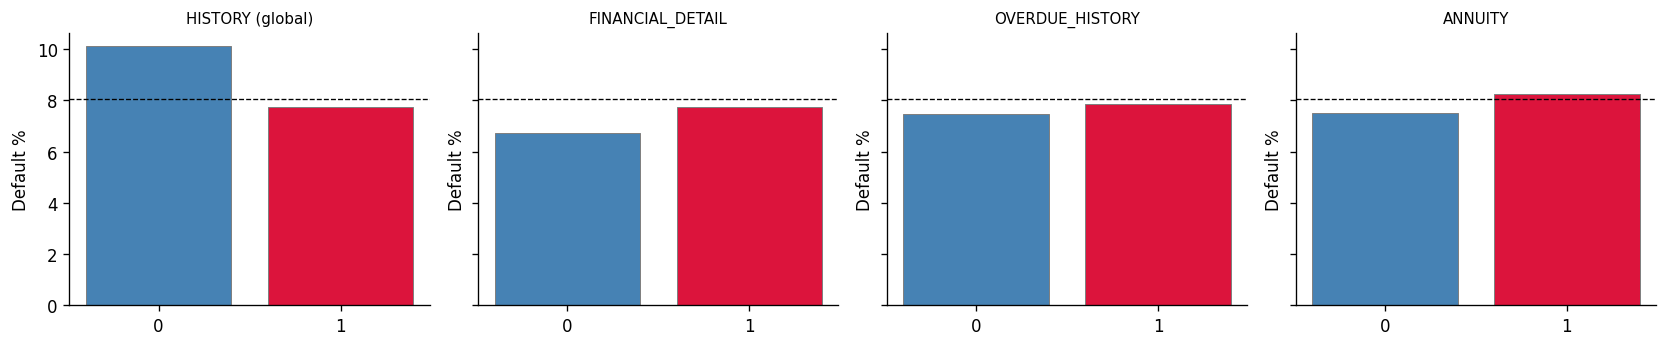

In [45]:
# flags de estructura de missing a nivel cliente
# HAS_BUREAU_HISTORY sobre toda la población; el resto SOLO entre clientes con historial
evaluar_flags([
    ("HAS_BUREAU_HISTORY", bureau_client["HAS_BUREAU_HISTORY"].values),
    ("HAS_BUREAU_FINANCIAL_DETAIL | historial", bureau_client["HAS_BUREAU_FINANCIAL_DETAIL"].fillna(0).values, hist_mask),
    ("HAS_BUREAU_OVERDUE_HISTORY | historial", bureau_client["HAS_BUREAU_OVERDUE_HISTORY"].fillna(0).values, hist_mask),
    ("HAS_BUREAU_ANNUITY | historial", bureau_client["HAS_BUREAU_ANNUITY"].fillna(0).values, hist_mask)
])

# grafico barras: HISTORY (global) + 3 flags condicionadas a historial
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
panels = [("HAS_BUREAU_HISTORY", None), ("HAS_BUREAU_FINANCIAL_DETAIL", hist_mask),
          ("HAS_BUREAU_OVERDUE_HISTORY", hist_mask), ("HAS_BUREAU_ANNUITY", hist_mask)]
for ax, (c, pop) in zip(axes, panels):
    v = bureau_client[c].fillna(0).values
    if pop is None:
        rates = [TARGET_B[v == 0].mean() * 100, TARGET_B[v == 1].mean() * 100]
    else:
        rates = [TARGET_B[pop & (v == 0)].mean() * 100, TARGET_B[pop & (v == 1)].mean() * 100]
        
    ax.bar(["0", "1"], rates, color=[color_no_default, color_default], edgecolor="gray", linewidth=0.6)
    ax.axhline(TARGET_B.mean() * 100, color="black", ls="--", lw=0.8)
    ax.set_title(c.replace("HAS_BUREAU_", ""), fontsize=9)
    ax.set_ylabel("Default %")
axes[0].set_title("HISTORY (global)", fontsize=9)
plt.tight_layout(); plt.show()

**Flags de estructura** La única flag fuerte del bloque es `HAS_BUREAU_HISTORY`, que formaliza a nivel cliente una de las conclusiones previas: los 44.020 sin historial tienen 10,12% de default
frente al 7,73% de los 263.491 con historial, un delta de -2,39pp (z = -17,1, p = 2,33e-65). Es
el flag de missing más informativo de todo bureau y se conserva sin discusión.

Las otras tres flags exigían un control de composición. Mi primera medición de `HAS_BUREAU_FINANCIAL_DETAIL` sobre toda la población daba -1,88pp, pero esa señal es prestada: ya que el grupo con valor 0 incluye a los 44.020 sin historial. Al condicionar solo a clientes con historial la flag **invierte** su signo a +1,04pp (7,76% vs 6,71%, p = 9,41e-04), por lo que tener detalle financiero se asocia a algo más de riesgo, no menos, porque refleja mayor actividad crediticia. Es lo mismo que ya me obligó a excluir nulos en los outliers de bureau, y confirma que estas flags no se pueden evaluar sin controlar por la presencia de historial. Por otro lado, `HAS_BUREAU_ANNUITY` condicionada da +0,75pp (p = 4,02e-11) y `HAS_BUREAU_OVERDUE_HISTORY` solo +0,38pp, en esta última la señal está en el valor de la mora, no en su presencia, lo que se alinea con la clasificación MCAR al inicio en el análisis de missings.

En resumen, solo `HAS_BUREAU_HISTORY` es una feature relevante. Las tres flags de estructura quedan como candidatas débiles a evaluar con IV más adelante, siempre condicionadas
a `HAS_BUREAU_HISTORY` para no duplicar su señal.

Un apunte respecto al criterio de decisión que he llevado a cabo y es que con la corrección de Bonferroni sobre la familia de comparaciones a nivel cliente las **cuatro flags pasan el filtro estadístico** (`HAS_BUREAU_HISTORY` p = 2,33e-65, `HAS_BUREAU_ANNUITY` p = 4,02e-11, `HAS_BUREAU_FINANCIAL_DETAIL` p = 9,41e-04, `HAS_BUREAU_OVERDUE_HISTORY` p = 9,25e-04). Pero el filtro práctico de |delta| > 2pp lo supera **solo `HAS_BUREAU_HISTORY`** (2,39pp), las otras tres (1,04, 0,75 y 0,38pp) son significativas únicamente por el volumen muestral de los 263.491 clientes con historial, no por relevancia.

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_LOAN_COUNT,global (fill 0),307511,0.0465,2.4128400065195354e-34,4.0,3.0
BUREAU_ACTIVE_COUNT,global (fill 0),307511,0.0587,8.551934409528974e-56,1.0,2.0
BUREAU_CLOSED_COUNT,global (fill 0),307511,0.1085,7.330428335045682e-182,2.0,1.0
BUREAU_CREDIT_TYPE_NUNIQUE,global (fill 0),307511,0.0312,1.7614096028813912e-18,2.0,2.0


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_BAD_DEBT_COUNT > 0,global (nulo=0),10.26% (n=5243),8.03% (n=302268),+2.23 pp,5.9,4.436638344456973e-09


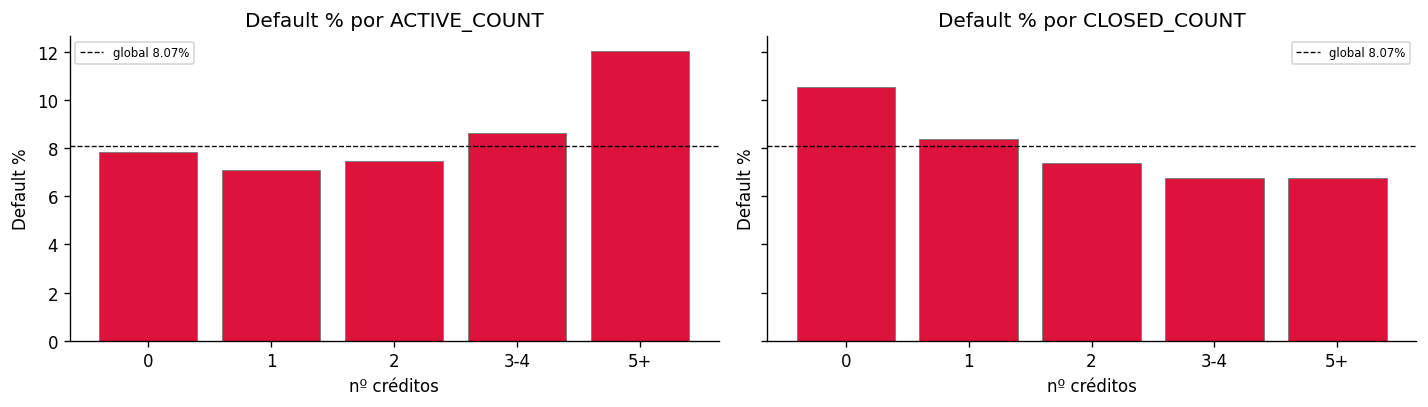

In [46]:
# conteos por estado y diversidad de producto (Mann-Whitney sobre conteo, fillna 0)
evaluar_continuas([
    ("BUREAU_LOAN_COUNT", True),
    ("BUREAU_ACTIVE_COUNT", True),
    ("BUREAU_CLOSED_COUNT", True),
    ("BUREAU_CREDIT_TYPE_NUNIQUE", True)
])
evaluar_flags([
    ("BUREAU_BAD_DEBT_COUNT > 0", (bureau_client["BUREAU_BAD_DEBT_COUNT"].fillna(0) > 0).astype(int).values)
])

# default por bins de ACTIVE vs CLOSED
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, c in zip(axes, ["BUREAU_ACTIVE_COUNT", "BUREAU_CLOSED_COUNT"]):
    binned = pd.cut(bureau_client[c].fillna(0), [-1, 0, 1, 2, 4, np.inf], labels=["0", "1", "2", "3-4", "5+"])
    tab = bureau_client["TARGET"].groupby(binned, observed=False).mean() * 100
    ax.bar(tab.index, tab.values, color=color_default, edgecolor="gray", linewidth=0.6)
    ax.axhline(TARGET_B.mean() * 100, color="black", ls="--", lw=0.8, label=f"global {round(TARGET_B.mean()*100, 2)}%")
    ax.set(title=f"Default % por {c.replace('BUREAU_', '')}", xlabel="nº créditos", ylabel="Default %")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_LOAN_COUNT,global (fill 0),307511,0.0465,2.4128400065195354e-34,4.0,3.0
BUREAU_LOAN_COUNT,con historial,263491,0.0098,0.019558753914343207,4.0,4.0
BUREAU_ACTIVE_COUNT,global (fill 0),307511,0.0587,8.551934409528974e-56,1.0,2.0
BUREAU_ACTIVE_COUNT,con historial,263491,0.1208,6.783826780499243e-189,2.0,2.0
BUREAU_CLOSED_COUNT,global (fill 0),307511,0.1085,7.330428335045682e-182,2.0,1.0
BUREAU_CLOSED_COUNT,con historial,263491,0.0948,3.513629301653776e-114,3.0,2.0
BUREAU_CREDIT_TYPE_NUNIQUE,global (fill 0),307511,0.0312,1.7614096028813912e-18,2.0,2.0
BUREAU_CREDIT_TYPE_NUNIQUE,con historial,263491,0.0119,0.0014837051635271036,2.0,2.0


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_BAD_DEBT_COUNT > 0,global (nulo=0),10.26% (n=5243),8.03% (n=302268),+2.23 pp,5.9,4.436638344456973e-09
BUREAU_BAD_DEBT_COUNT > 0,con historial,10.26% (n=5243),7.68% (n=258248),+2.58 pp,6.9,4.145284841505171e-12


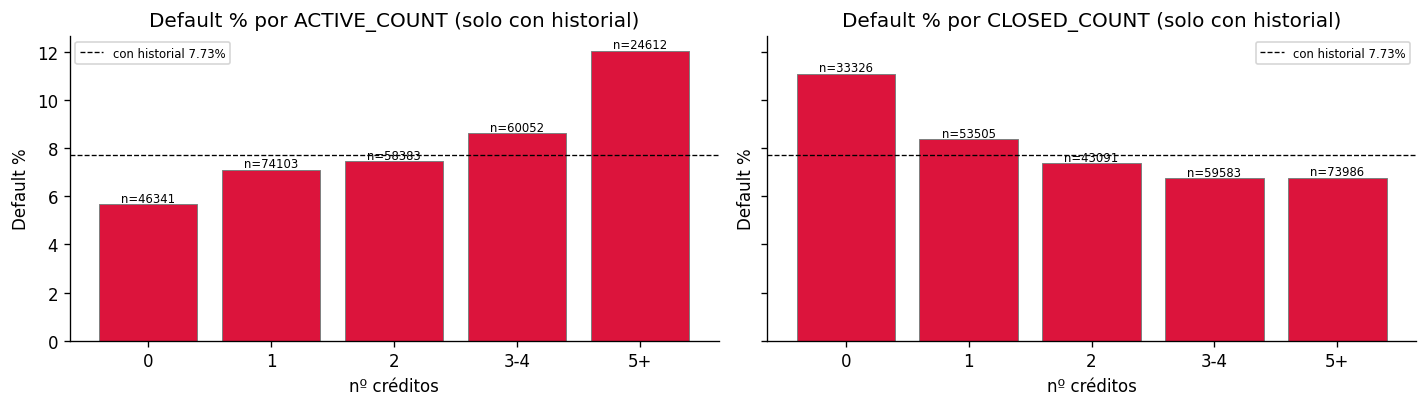

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_ACTIVE_CARD_COUNT,con historial,263491,0.0957,1.522489402852021e-130,1.0,1.0
BUREAU_ACTIVE_CONSUMER_COUNT,con historial,263491,0.0977,1.0837721574411149e-132,1.0,1.0


In [47]:
# control de composición para conteos
hm = np.asarray(hist_mask)

evaluar_continuas([
    ("BUREAU_LOAN_COUNT", True, None, "global (fill 0)"),
    ("BUREAU_LOAN_COUNT", True, hm),
    ("BUREAU_ACTIVE_COUNT", True, None, "global (fill 0)"),
    ("BUREAU_ACTIVE_COUNT", True, hm),
    ("BUREAU_CLOSED_COUNT", True, None, "global (fill 0)"),
    ("BUREAU_CLOSED_COUNT", True, hm),
    ("BUREAU_CREDIT_TYPE_NUNIQUE", True, None, "global (fill 0)"),
    ("BUREAU_CREDIT_TYPE_NUNIQUE", True, hm),
])

bad = (bureau_client["BUREAU_BAD_DEBT_COUNT"].fillna(0) > 0).to_numpy(dtype=int)
evaluar_flags([
    ("BUREAU_BAD_DEBT_COUNT > 0", bad),
    ("BUREAU_BAD_DEBT_COUNT > 0", bad, hm),
])

# distribución de créditos activos y cerrados
sub = bureau_client[hm]
base = np.asarray(TARGET_B)[hm].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for ax, c in zip(axes, ["BUREAU_ACTIVE_COUNT", "BUREAU_CLOSED_COUNT"]):
    binned = pd.cut(sub[c].fillna(0), [-1, 0, 1, 2, 4, np.inf], labels=["0", "1", "2", "3-4", "5+"])
    g = sub["TARGET"].groupby(binned, observed=False).agg(["mean", "size"])
    g["mean"] *= 100
    
    ax.bar(g.index, g["mean"], color=color_default, edgecolor="gray", linewidth=0.6)
    ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
    for i, (v, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, v + 0.1, f"n={n}", ha="center", fontsize=7)
    ax.set(title=f"Default % por {c.replace('BUREAU_', '')} (solo con historial)",
           xlabel="nº créditos", ylabel="Default %")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# conteos estado por tipo: la hipótesis de que 5 tarjetas activas no son 5 hipotecas activas
# se testea contra el conteo agregado BUREAU_ACTIVE_COUNT (r_rb 0,1208 condicionado)
evaluar_continuas([
    ("BUREAU_ACTIVE_CARD_COUNT", True, hm, "con historial"),
    ("BUREAU_ACTIVE_CONSUMER_COUNT", True, hm, "con historial"),
])


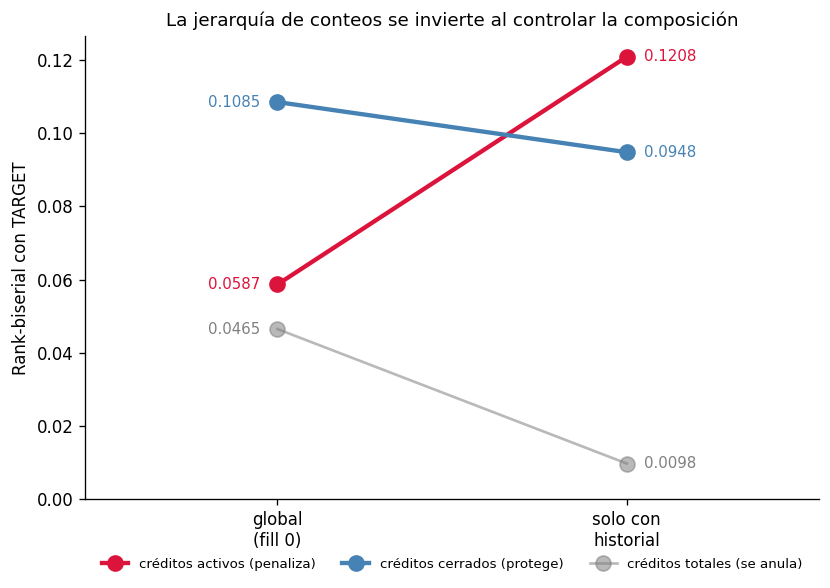

In [48]:
# gráfico de pendiente (slope chart)
tb = np.asarray(TARGET_B)

def _rrb(name, mask):
    """rank-biserial sobre la máscara dada."""
    # reuso tb externo para evitar castings repetidos
    s = bureau_client[name].fillna(0).to_numpy()
    vals, t = s[mask], tb[mask]
    x, y = vals[t == 0], vals[t == 1]
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return abs((2 * u) / (len(x) * len(y)) - 1)

glob = np.ones(len(bureau_client), bool)
hm = np.asarray(hist_mask)

feats = [
    ("BUREAU_ACTIVE_COUNT", "crimson",         "créditos activos (penaliza)"),
    ("BUREAU_CLOSED_COUNT", "steelblue",       "créditos cerrados (protege)"),
    ("BUREAU_LOAN_COUNT",   "gray",            "créditos totales (se anula)"),
]

fig, ax = plt.subplots(figsize=(7.2, 5))
x = [0, 1]
for name, col, lab in feats:
    y0, y1 = _rrb(name, glob), _rrb(name, hm)
    muted = col == "gray"
    ax.plot(x, [y0, y1], "-o", color=col, lw=1.6 if muted else 2.6, ms=9,
            alpha=0.55 if muted else 1.0, label=lab, zorder=2)
    ax.text(-0.05, y0, f"{round(y0, 4)}", ha="right", va="center", fontsize=9, color=col)
    ax.text(1.05, y1, f"{round(y1, 4)}", ha="left", va="center", fontsize=9, color=col)

ax.set_xlim(-0.55, 1.55)
ax.set_ylim(0, None)
ax.set_xticks(x)
ax.set_xticklabels(["global\n(fill 0)", "solo con\nhistorial"], fontsize=10)
ax.set_ylabel("Rank-biserial con TARGET")
ax.set_title("La jerarquía de conteos se invierte al controlar la composición", fontsize=11)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

ventana de la tabla: 8.0000 años | clientes bajo el suelo de medio año: 7242 (2.75%)


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_CREDITS_PER_YEAR,no nulos (auto-cond.),263491,0.1569,1.095715802090995e-303,1.1,1.3


conteo crudo condicionado a historial: r_rb = 0.0098

Gradiente por creditos reportados al año (solo con historial):


,tasa,n,creditos_min,creditos_med,anios_med
BUREAU_CREDITS_PER_YEAR,,,,,
"hasta 0,5",6.12,"40,630",1,2,6.26
"0,5 a 1",6.20,"78,083",1,4,5.95
1 a 2,7.72,"102,631",1,7,4.71
2 a 3,10.18,"28,384",2,9,3.84
mas de 3,16.15,"13,763",2,7,1.84


control 1 (denominador): minimo de creditos en el tramo alto = 2, mediana 7 creditos en 1.84 años
control 2 (recencia): Pearson con BUREAU_DAYS_CREDIT_MIN = 0.3332


estrato (años de historial),n,r_rb tasa,r_rb conteo
menos de 1,"17,438",0.1310,0.0961
1 a 2,"25,068",0.1767,0.1625
2 a 3,"28,316",0.1728,0.1672
3 a 5,"60,901",0.1123,0.1037
5 o mas,"131,768",0.0607,0.0544


control 3 (conteo): Pearson con BUREAU_LOAN_COUNT = 0.5003


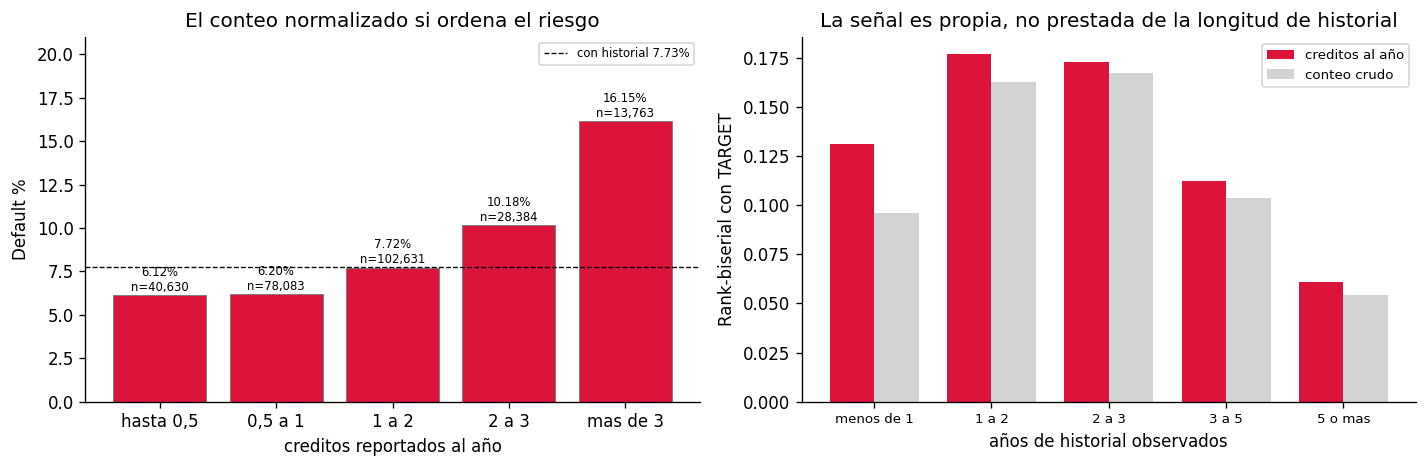

In [49]:
# el conteo absoluto esta censurado por la izquierda: la ventana del buro es de 8 años
# exactos y a quien lleva mas tiempo reportado le faltan sus creditos mas antiguos.
# normalizado por los años observados (suelo de medio año, la misma convencion que uso
# en previous_application) el conteo deja de ser ruido
hm = np.asarray(hist_mask)
anios_obs = -bureau_client["BUREAU_DAYS_CREDIT_MIN"] / 365.25
sub_r = bureau_client.loc[hm, ["TARGET", "BUREAU_LOAN_COUNT", "BUREAU_CREDITS_PER_YEAR",
                               "BUREAU_DAYS_CREDIT_MIN"]].assign(_anios=anios_obs[hm])

print(f"ventana de la tabla: {-bureau['DAYS_CREDIT'].min() / 365.25:.4f} años | "
      f"clientes bajo el suelo de medio año: {int((sub_r['_anios'] < 0.5).sum())} "
      f"({(sub_r['_anios'] < 0.5).mean() * 100:.2f}%)")

evaluar_continuas(["BUREAU_CREDITS_PER_YEAR"])
print(f"conteo crudo condicionado a historial: r_rb = {_rrb('BUREAU_LOAN_COUNT', hm):.4f}")

# gradiente por tramos de negocio
tramos = pd.cut(sub_r["BUREAU_CREDITS_PER_YEAR"], [0, 0.5, 1, 2, 3, np.inf], include_lowest=True,
                labels=["hasta 0,5", "0,5 a 1", "1 a 2", "2 a 3", "mas de 3"])
g = (sub_r.groupby(tramos, observed=True)
     .agg(tasa=("TARGET", "mean"), n=("TARGET", "size"),
          creditos_min=("BUREAU_LOAN_COUNT", "min"), creditos_med=("BUREAU_LOAN_COUNT", "median"),
          anios_med=("_anios", "median")))
g["tasa"] = (g["tasa"] * 100).round(2)
print("\nGradiente por creditos reportados al año (solo con historial):")
display(g.style.format({"tasa": "{:.2f}", "n": "{:,}", "creditos_min": "{:.0f}",
                        "creditos_med": "{:.0f}", "anios_med": "{:.2f}"}))

# control 1, ruido de denominador: con el suelo de medio año un solo credito no pasa de 2,0
# al año, asi que los tramos altos no se alcanzan con una sola fila
print(f"control 1 (denominador): minimo de creditos en el tramo alto = "
      f"{int(g.loc['mas de 3', 'creditos_min'])}, mediana {int(g.loc['mas de 3', 'creditos_med'])} "
      f"creditos en {g.loc['mas de 3', 'anios_med']:.2f} años")

# control 2, que no sea la recencia con otro nombre: correlacion moderada con la longitud de
# historial, y señal residual propia dentro de cada estrato de longitud
print(f"control 2 (recencia): Pearson con BUREAU_DAYS_CREDIT_MIN = "
      f"{sub_r['BUREAU_CREDITS_PER_YEAR'].corr(sub_r['BUREAU_DAYS_CREDIT_MIN']):.4f}")
estratos = pd.cut(anios_obs, [0, 1, 2, 3, 5, np.inf], include_lowest=True,
                  labels=["menos de 1", "1 a 2", "2 a 3", "3 a 5", "5 o mas"])
df_res = pd.DataFrame([
    {"estrato (años de historial)": lab,
     "n": int(((estratos == lab).values & hm).sum()),
     "r_rb tasa": round(_rrb("BUREAU_CREDITS_PER_YEAR", (estratos == lab).values & hm), 4),
     "r_rb conteo": round(_rrb("BUREAU_LOAN_COUNT", (estratos == lab).values & hm), 4)}
    for lab in estratos.cat.categories])
display(df_res.style.format({"n": "{:,}", "r_rb tasa": "{:.4f}", "r_rb conteo": "{:.4f}"})
        .hide(axis="index"))

# control 3, que no sea el conteo con otro nombre
print(f"control 3 (conteo): Pearson con BUREAU_LOAN_COUNT = "
      f"{sub_r['BUREAU_CREDITS_PER_YEAR'].corr(sub_r['BUREAU_LOAN_COUNT']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
base = sub_r["TARGET"].mean() * 100
axes[0].bar(g.index.astype(str), g["tasa"], color=color_default, edgecolor="gray", linewidth=0.6)
axes[0].axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {base:.2f}%")
for i, (v, n) in enumerate(zip(g["tasa"], g["n"])):
    axes[0].text(i, v + 0.25, f"{v:.2f}%\nn={n:,}", ha="center", fontsize=7)
axes[0].set(title="El conteo normalizado si ordena el riesgo", xlabel="creditos reportados al año",
            ylabel="Default %", ylim=(0, g["tasa"].max() * 1.3))
axes[0].legend(fontsize=7)

w, x = 0.38, np.arange(len(df_res))
axes[1].bar(x - w / 2, df_res["r_rb tasa"], w, color=color_default, label="creditos al año")
axes[1].bar(x + w / 2, df_res["r_rb conteo"], w, color="lightgrey", label="conteo crudo")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_res["estrato (años de historial)"], fontsize=8)
axes[1].set(title="La señal es propia, no prestada de la longitud de historial",
            xlabel="años de historial observados", ylabel="Rank-biserial con TARGET")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Conteos** `BUREAU_LOAN_COUNT` replica a nivel cliente su debilidad de nivel fila (r_rb = 0,0465 en la medición global, casi idéntico al 0,047 a nivel fila): el conteo total apenas discrimina por la forma de U ya vista. La señal aparece al separar por estado.

La medición inicial, con `fillna(0)` sobre los 307.511, daba a `BUREAU_CLOSED_COUNT` como el conteo más fuerte (r_rb = 0,1085) y a `BUREAU_ACTIVE_COUNT` como secundario (0,0587). Pero ese `fillna(0)` mete a los 44.020 sin historial (el grupo de riesgo, 10,12%) en el bin 0 de todos los conteos, y ese bin contaminado empuja en direcciones opuestas según el signo de cada variable, así que repetí la medición solo entre los 263.491 clientes con historial (celda de control de composición).

El control invierte la jerarquía. `BUREAU_CLOSED_COUNT` baja de 0,1085 a 0,0948: pierde poco, su gradiente protector es propio (mediana 3 vs 2 créditos cerrados entre no defaulters y defaulters) y solo estaba levemente inflado porque el bin 0 de los sin historial reforzaba de forma artificial el "0 cerrados = más riesgo". `BUREAU_ACTIVE_COUNT` hace lo contrario: sube de 0,0587 a 0,1208, más del doble, y pasa a ser el conteo **más fuerte del bloque**. Su señal estaba escondida, ya que los sin historial (`ACTIVE` = 0 y alto riesgo) contradecían el gradiente "más activos = más riesgo" y lo aplanaban; al sacarlos, el efecto de la presión de deuda activa se ve limpio.

Y el mismo control remata a `BUREAU_LOAN_COUNT`: condicionado a historial cae de 0,0465 a **0,0098** (mediana 4 vs 4), prácticamente ruido. Se anula porque suma las dos fuerzas de signo contrario que acabo de separar, y al condicionar desaparece hasta la pequeña señal residual que el bin 0 contaminado le prestaba.

Pero antes de dejarlo en denominador hay una pregunta que el conteo crudo no responde: el buró reporta una ventana de 8 años exactos, así que a quien lleva más tiempo dentro le faltan sus créditos más antiguos y su conteo está censurado por la izquierda. Normalizado por los años que llevo observando a cada cliente (con suelo de medio año en el denominador para no dividir por casi cero, la misma convención que uso con las solicitudes previas), el mismo dato pasa de 0,0098 a **0,1569**, dieciséis veces más, con gradiente monótono: 6,12% de default hasta medio crédito al año, 6,20% de 0,5 a 1, 7,72% de 1 a 2, 10,18% de 2 a 3 y **16,15% por encima de 3**. No era el conteo lo que no discriminaba, era el conteo sin su ventana.

Antes de darlo por bueno pasa los tres controles que le exijo a un ratio de este tipo. Ruido de denominador: con el suelo de medio año un solo crédito no puede pasar de 2,0 al año, así que el tramo alto no se alcanza con una sola fila (mínimo de 2 créditos, mediana de 7 en 1,84 años). Que no sea la longitud del historial con otro nombre: Pearson 0,3332 con `BUREAU_DAYS_CREDIT_MIN`, y midiendo dentro de cada estrato de longitud la señal aguanta en los cinco (de 0,0607 a 0,1767) y supera al conteo crudo en todos. Y que no sea el conteo con otro nombre: Pearson 0,5003. Restringida a historiales de un año o más rinde 0,1299, así que tampoco vive del suelo.

Así que `BUREAU_LOAN_COUNT` cambia de papel. Como explicativa directa sigue siendo ruido, pero deja de ser solo el denominador de los ratios de composición y pasa a ser el **numerador** del ritmo de contratación, una de las señales continuas más fuertes de la tabla. Es un descarte que se revierte, y como se mide sobre train completo arrastra la misma provisionalidad que el resto.

Esto reclasifica la conclusión del bloque: entre clientes con historial, tener créditos abiertos simultáneamente (r_rb = 0,1208) discrimina más que tener créditos saldados (0,0948). Refuerza así el perfil "Deudor con mora activa / sobregiro" y confirma con más fuerza aún la decisión de separar ambos conteos, ya que no solo apuntan en direcciones opuestas, sino que su fuerza relativa solo se ve tras controlar por `HAS_BUREAU_HISTORY`.

`BUREAU_BAD_DEBT_COUNT` es demasiado escaso para tratarlo como continua (r_rb ínfimo), pero como flag `> 0` rinde +2,58pp condicionado a historial (10,26% vs 7,68%, n = 5.243, z = 6,9, p = 4,15e-12), consistente con la jerarquía 'Bad debt' > 'Sold' vista a nivel fila. Es el único flag de este bloque que supera a la vez el filtro de Bonferroni y el umbral práctico de |delta| > 2pp, a diferencia de las flags de estructura, significativas solo por volumen muestral.

`BUREAU_CREDIT_TYPE_NUNIQUE` condicionado da r_rb = 0,0119 (mediana 2 vs 2), un patrón débil y no monótono, así que se queda como candidata secundaria.

Por tanto, la decisión respecto a este bloque es que conservaré `BUREAU_ACTIVE_COUNT` (ahora el conteo primario) y `BUREAU_CLOSED_COUNT` por separado, y `BUREAU_BAD_DEBT_COUNT` como flag. `BUREAU_LOAN_COUNT` no pasa como explicativa, pero sí como numerador de `BUREAU_CREDITS_PER_YEAR`, que conservo, y como denominador de los ratios de composición. Todos los conteos se miden condicionados a la presencia de historial para no confundir su señal con la de `HAS_BUREAU_HISTORY`.

**Conteos estado × tipo.** Las correlaciones planteaba que "5 tarjetas activas ≠ 5 hipotecas activas" y sugería probar conteos por tipo además del agregado. Lo testé condicionado a historial: `BUREAU_ACTIVE_CARD_COUNT` (r_rb 0,0957, flag `>0` +1,93pp) y `BUREAU_ACTIVE_CONSUMER_COUNT` (r_rb 0,0977, +2,16pp) son **ambos más débiles** que el conteo agregado `BUREAU_ACTIVE_COUNT` (r_rb 0,1208). Separar los activos por producto no afina el riesgo por encima del agregado: la presión de deuda vive en "cuántos créditos abiertos", no en "de qué tipo". Cierro la hipótesis con evidencia (no la aplazo): conservo `BUREAU_ACTIVE_COUNT` y descarto los conteos estado×tipo.

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_HAS_ANY_OVERDUE,global (nulo=0),9.5% (n=70440),7.65% (n=237071),+1.85 pp,15.8,3.581055027077765e-56
BUREAU_CURRENT_OVERDUE_SUM > 0,global (nulo=0),16.2% (n=3334),7.98% (n=304177),+8.21 pp,17.3,3.740628819575228e-67


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_MAX_OVERDUE_EVER,no nulos (auto-cond.),183886,0.0934,6.37222123991958e-101,0.0,0.0


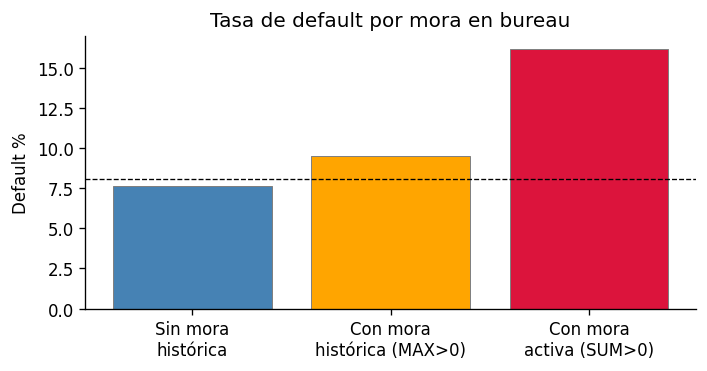

In [50]:
# mora a nivel cliente
cur_flag = (bureau_client["BUREAU_CURRENT_OVERDUE_SUM"] > 0).values
evaluar_flags([
    ("BUREAU_HAS_ANY_OVERDUE", bureau_client["BUREAU_HAS_ANY_OVERDUE"].fillna(0).values),
    ("BUREAU_CURRENT_OVERDUE_SUM > 0", cur_flag)
])
evaluar_continuas([
    "BUREAU_MAX_OVERDUE_EVER"
])

# barras comparativas
fig, ax = plt.subplots(figsize=(6, 3.2))
labels = ["Sin mora\nhistórica", "Con mora\nhistórica (MAX>0)", "Con mora\nactiva (SUM>0)"]
hany = bureau_client["BUREAU_HAS_ANY_OVERDUE"].fillna(0).values
rates = [TARGET_B[hany == 0].mean() * 100, TARGET_B[hany == 1].mean() * 100, TARGET_B[cur_flag].mean() * 100]
ax.bar(labels, rates, color=[color_no_default, "orange", color_default], edgecolor="gray", linewidth=0.6)
ax.axhline(TARGET_B.mean() * 100, color="black", ls="--", lw=0.8)
ax.set(title="Tasa de default por mora en bureau", ylabel="Default %")
plt.tight_layout(); plt.show()

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_HAS_ANY_OVERDUE,global (nulo=0),9.5% (n=70440),7.65% (n=237071),+1.85 pp,15.8,3.581055027077765e-56
BUREAU_HAS_ANY_OVERDUE,con historial,9.5% (n=70440),7.09% (n=193051),+2.41 pp,20.5,2.022365620873936e-93
BUREAU_CURRENT_OVERDUE_SUM > 0,global (nulo=0),16.2% (n=3334),7.98% (n=304177),+8.21 pp,17.3,3.740628819575228e-67
BUREAU_CURRENT_OVERDUE_SUM > 0,con historial,16.2% (n=3334),7.62% (n=260157),+8.58 pp,18.4,8.722399576527675e-76


Crosstab de anidamiento (solo clientes con historial):


Mora activa (SUM>0),0,1
Mora historica (HAS_ANY),,
0,191217,1834
1,68940,1500


Mora activa sin mora historica registrada: 1834 de 3334 (55.0% fuera del anidamiento)

Grupos disjuntos de mora (solo clientes con historial):


,Default %,n
1. Sin mora,7.02,191217
2. Mora historica sin activa,9.3,68940
3. Mora activa,16.2,3334


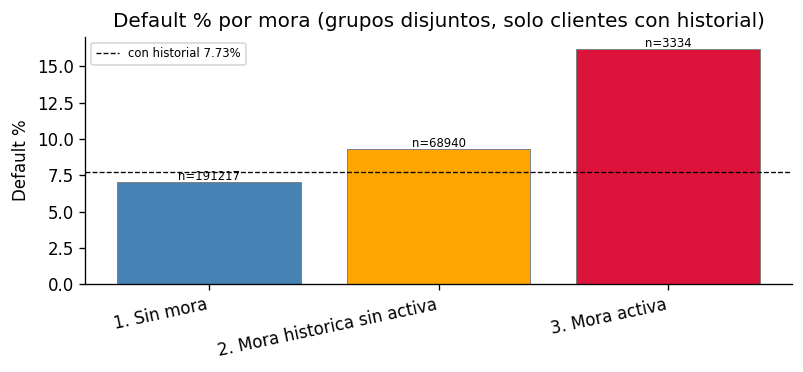

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_MAX_DAYS_OVERDUE > 0,global (nulo=0),15.9% (n=3397),7.99% (n=304114),+7.91 pp,16.8,1.4324555552670982e-63
BUREAU_MAX_DAYS_OVERDUE > 0,con historial,15.9% (n=3397),7.62% (n=260094),+8.27 pp,17.9,5.97090635286707e-72


Crosstab duracion vs gravedad de la mora activa (solo clientes con historial):


Gravedad (SUM>0),0,1
Duracion (MAX_DAYS>0),,
0,259897,197
1,260,3137


Solapamiento: 3137 con ambas | 260 solo duracion | 197 solo gravedad | Jaccard 87.3%
V de Cramer duracion vs gravedad: 0.9311 (umbral de redundancia > 0,50)
Pearson cliente MAX_DAYS_OVERDUE vs CURRENT_OVERDUE_SUM: 0.0915 (a nivel fila era 0,10)
BUREAU_MAX_DAYS_OVERDUE continua (con historial): r_rb = 0.0147, p = 1.566291817938271e-71


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_OVERDUE_UNION,con historial,9.62% (n=72419),7.02% (n=191072),+2.60 pp,22.3,2.4066249705343855e-110


Cobertura mora: UNION 72419 vs HAS_ANY 70440 (activa SUM>0 = 3334) | morosos activos rescatados del nulo->False: 1834


In [51]:
# composición y anidamiento de flags de mora
tb, hm = np.asarray(TARGET_B), np.asarray(hist_mask)
hany = bureau_client["BUREAU_HAS_ANY_OVERDUE"].fillna(0).to_numpy(dtype=int)
cur = (bureau_client["BUREAU_CURRENT_OVERDUE_SUM"] > 0).to_numpy(dtype=int)

evaluar_flags([
    ("BUREAU_HAS_ANY_OVERDUE", hany),
    ("BUREAU_HAS_ANY_OVERDUE", hany, hm),
    ("BUREAU_CURRENT_OVERDUE_SUM > 0", cur),
    ("BUREAU_CURRENT_OVERDUE_SUM > 0", cur, hm),
])

# anido mora activa e histórica
hany_hm, cur_hm = hany[hm], cur[hm]
ct = pd.crosstab(hany_hm, cur_hm, rownames=["Mora historica (HAS_ANY)"], colnames=["Mora activa (SUM>0)"])
print("Crosstab de anidamiento (solo clientes con historial):")
display(ct)

# calculo directamente
fuera = ((hany_hm == 0) & (cur_hm == 1)).sum()
total_act = cur_hm.sum()
print(f"Mora activa sin mora historica registrada: {fuera} de {total_act} "
      f"({round(fuera / total_act * 100, 1)}% fuera del anidamiento)")

# grupos disjuntos de mora
tb_hm = tb[hm]
grupo = np.where(cur_hm == 1, "3. Mora activa",
                 np.where(hany_hm == 1, "2. Mora historica sin activa", "1. Sin mora"))

# agrupo y renombro
tab = pd.Series(tb_hm).groupby(grupo).agg(["mean", "size"]).rename(
    columns={"mean": "Default %", "size": "n"}
)
tab["Default %"] *= 100

print("\nGrupos disjuntos de mora (solo clientes con historial):")
display(tab)

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.bar(tab.index, tab["Default %"], color=[color_no_default, "orange", color_default],
       edgecolor="gray", linewidth=0.6)
base = tb_hm.mean() * 100
ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
for i, (val, n) in enumerate(zip(tab["Default %"], tab["n"])):
    ax.text(i, val + 0.15, f"n={n}", ha="center", fontsize=7)
ax.set(title="Default % por mora (grupos disjuntos, solo clientes con historial)",
       ylabel="Default %", xlabel="")
ax.legend(fontsize=7)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

# duración vs gravedad de la mora
dias = bureau_client["BUREAU_MAX_DAYS_OVERDUE"]
dias_flag = (dias > 0).to_numpy(dtype=int)
# por el evaluador, no con un z-test local, para que entre en el acumulador y en la receta
evaluar_flags([
    ("BUREAU_MAX_DAYS_OVERDUE > 0", dias_flag),
    ("BUREAU_MAX_DAYS_OVERDUE > 0", dias_flag, hm),
])

dias_flag_hm = dias_flag[hm]
ct2 = pd.crosstab(dias_flag_hm, cur_hm, 
                  rownames=["Duracion (MAX_DAYS>0)"], 
                  colnames=["Gravedad (SUM>0)"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
print("Crosstab duracion vs gravedad de la mora activa (solo clientes con historial):")
display(ct2)

# cálculo directamente solapamientos
inter = ct2.loc[1, 1]
solo_d = ct2.loc[1, 0]
solo_g = ct2.loc[0, 1]
union = inter + solo_d + solo_g
if union > 0:
    print(f"Solapamiento: {inter} con ambas | {solo_d} solo duracion | {solo_g} solo gravedad "
          f"| Jaccard {round(inter / union * 100, 1)}%")
if (ct2.sum(axis=1) > 0).all() and (ct2.sum(axis=0) > 0).all():
    v_cramer = np.sqrt(chi2_contingency(ct2)[0] / ct2.values.sum())
    print(f"V de Cramer duracion vs gravedad: {round(v_cramer, 4)} (umbral de redundancia > 0,50)")

# correlación de magnitud
r_cli = bureau_client.loc[hm, "BUREAU_MAX_DAYS_OVERDUE"].corr(bureau_client.loc[hm, "BUREAU_CURRENT_OVERDUE_SUM"])
print(f"Pearson cliente MAX_DAYS_OVERDUE vs CURRENT_OVERDUE_SUM: {round(r_cli, 4)} (a nivel fila era 0,10)")

# rank-biserial de duración
v, t = dias.to_numpy()[hm], tb[hm]
u, pv = mannwhitneyu(v[t == 0], v[t == 1], alternative="two-sided")
# ponytail: cálculo de r_rb sin int() innecesarios
r_rb = abs((2 * u) / ((t == 0).sum() * (t == 1).sum()) - 1)
print(f"BUREAU_MAX_DAYS_OVERDUE continua (con historial): r_rb = {round(r_rb, 4)}, p = {pv}")

# flag unión de mora: cubre a los morosos activos que el nulo de AMT_CREDIT_MAX_OVERDUE deja fuera
union = bureau_client["BUREAU_OVERDUE_UNION"].fillna(0).to_numpy(dtype=int)
evaluar_flags([
    ("BUREAU_OVERDUE_UNION", union, hm),
])
n_union, n_hany = int(union[hm].sum()), int(hany[hm].sum())
rescatados = int(((union == 1) & (hany == 0) & (cur == 1) & hm).sum())
print(f"Cobertura mora: UNION {n_union} vs HAS_ANY {n_hany} (activa SUM>0 = {int(cur[hm].sum())}) | "
      f"morosos activos rescatados del nulo->False: {rescatados}")


**Mora** A nivel fila la mora daba deltas de +10pp, pero es un evento raro y podía diluirse al agrupar por cliente. Sin embargo, sobrevive con claridad, y al medirla con el control de composición de este bloque incluso gana relevancia.

`BUREAU_HAS_ANY_OVERDUE` (haber tenido mora en algún crédito) rinde +2,41pp condicionado a historial (9,50% vs 7,09%, n = 193.051, z = 20,5, p = 2,02e-93). En global salía a +1,85pp porque, como en los conteos, los 44.020 sin historial caen en el grupo 0 y contaminan la baseline hacia arriba, pero tras sacarlos la variable **sobrepasa** el umbral práctico de |delta| > 2pp que en global no lo superaba, y deja de ser candidata débil. Es el tercer bloque seguido en que meter a los sin historial en el grupo 0 distorsiona la medición, lo que implica que es un patrón sistemático de esta fase (agregar por cliente), no una anécdota. La mora **activa** es mucho más severa: `BUREAU_CURRENT_OVERDUE_SUM > 0` da +8,58pp condicionado (16,20% vs 7,62%), casi el doble de la tasa global y de las señales más fuertes de toda la tabla a nivel cliente. El +10,90pp de `AMT_CREDIT_SUM_OVERDUE > 0` a nivel fila queda en +8,58pp al agregar, una pérdida de en torno al 21% que no cambia el orden de magnitud.

Algo relevante en este bloque es que el anidamiento que daba por hecho es falso. Esperaba que los 3.334 clientes con mora activa estuvieran contenidos en los 70.440 con mora histórica, pero el crosstab lo rechazaba: **1.834 de los 3.334 (el 55,0%) no tienen mora histórica registrada**. La causa está en cómo se construye la flag, `AMT_CREDIT_MAX_OVERDUE > 0`, donde el nulo evalúa a `False`: con el 64,73% de nulos que documenté anteriormente, `BUREAU_HAS_ANY_OVERDUE` no significa "tuvo mora" sino **"tuvo mora reportada"**, y confunde la ausencia de mora con la ausencia de dato. Es también una inconsistencia lógica (como las del análisis temporal): un cliente con importe en mora vivo debería tener máximo histórico > 0 por definición, así que esos 1.834 son un fallo de reporte del buró, no clientes limpios. Cierra el círculo, donde `HAS_BUREAU_OVERDUE_HISTORY` (tener máximo reportado, n = 183.886) daba solo +0,38pp: reportar no discrimina, pero el nulo del reporte sí ensucia la flag que sí discrimina.

Separando los tres grupos disjuntos entre clientes con historial aparece un gradiente monótono limpio, que el gráfico de barras solapadas no podía mostrar por no ser excluyentes: sin mora 7,02% (n = 191.217), mora histórica sin activa 9,30% (n = 68.940) y mora activa 16,20% (n = 3.334). La mora histórica **pura** aporta +2,28pp sobre los limpios, es decir que sobrevive al quitarle el arrastre de la activa, y la activa suma +9,18pp. La corrección de composición resulta ser recursiva: el grupo 0 de `BUREAU_HAS_ANY_OVERDUE` todavía contenía a esos 1.834 con mora activa, así que el delta real contra los clientes genuinamente limpios (7,02%) sería +2,48pp en vez de +2,41pp.

`BUREAU_MAX_OVERDUE_EVER` confirma que la señal del importe histórico vive en la cola, no en la mediana (0 en ambas clases). Se mide sobre su propia población: como lo paso en string el helper no aplica `fillna` y la calcula solo sobre los 183.886 clientes con algún máximo reportado, ni los 307.511 ni los 263.491. Su r_rb = 0,0934 está por tanto implícitamente condicionado y es comparable con el 0,0948 de `BUREAU_CLOSED_COUNT`, pero no con los deltas globales de las flags de este mismo bloque.

El bloque también resuelve algo pendiente de las correlaciones (correlaciones). En donde, con una correlación de solo 0,10 a nivel fila entre `CREDIT_DAY_OVERDUE` (duración) y `AMT_CREDIT_SUM_OVERDUE` (gravedad), había concluido que eran dimensiones distintas y que ambas entrarían por separado en esta fase. A nivel cliente la V de Cramér entre las dos flags es **0,9311**, muy por encima del umbral de redundancia de 0,50, con un Jaccard del 87,3% (3.137 clientes comunes): no son dimensiones distintas, son casi el mismo cliente. La reconciliación está en qué mide cada estadístico que he aplicado: el Pearson a nivel cliente sigue dando 0,0915, prácticamente el 0,10 de las correlaciones, porque mide el movimiento (a la vez) de magnitudes (y eso sí es cierto, importes y días no escalan juntos), mientras que la V mide co-ocurrencia del evento, y el evento es el mismo. Leí un r bajo como independencia pero no me fijé en los deltas de ambas que eran casi idénticos a nivel fila (+10,90pp y +10,42pp) y ahora se replican a nivel cliente (+8,58pp y +8,27pp).

La duración como continua, `BUREAU_MAX_DAYS_OVERDUE`, da r_rb = 0,0147, pero es el resultado de empates, no prueba de que la magnitud no sirva: ya que el 98,7% de los clientes con historial tiene 0 días de mora, así que el Mann-Whitney queda dominado por empates y el rank-biserial se aplasta (el p = 1,57e-71 es otra vez significancia por volumen muestral). Medirlo bien exigiría el refinamiento de outliers, restringir la comparación a los 3.397 en mora, pero no hace falta porque la variable la descarto igualmente por redundancia.

Decisiones de este bloque: conservaré `BUREAU_CURRENT_OVERDUE_SUM` como feature de mora prioritaria (+8,58pp), `BUREAU_HAS_ANY_OVERDUE` ahora con relevancia propia (+2,41pp) y `BUREAU_MAX_OVERDUE_EVER` (r_rb = 0,0934). Sin embargo, descartaré **`BUREAU_MAX_DAYS_OVERDUE`**: con V = 0,93 frente a `BUREAU_CURRENT_OVERDUE_SUM` no aporta nada y esta última gana en delta (+8,58 vs +8,27) y en tasa (16,20% vs 15,90%), la dejaré como evidencia pero fuera del FE. Sobre la prioridad matizo la cobertura y es que la mora activa es la más severa pero solo toca a 3.334 clientes (el 1,27% de los que tienen historial), mientras que `BUREAU_HAS_ANY_OVERDUE` tiene un delta menor con 21 veces más cobertura (70.440), así que por el doble criterio (significancia + relevancia práctica) la jerarquía entre ambas se decide con un IV en el FE, no aquí. Queda una idea menor, los 260 clientes con días pero sin importe y los 197 con importe pero sin días (el 12,7% de la unión) son inconsistencias de reporte, y una flag unión de mora activa cubriría 3.594 en vez de 3.334.

**Flag-unión de mora.** El propio bloque demostró que `BUREAU_HAS_ANY_OVERDUE` (`AMT_CREDIT_MAX_OVERDUE > 0`) confunde ausencia de mora con ausencia de dato y deja fuera a los 1.834 morosos activos porque el nulo evalúa a `False`. Construí `BUREAU_OVERDUE_UNION` (máximo histórico, importe activo o días de mora, cualquiera > 0): condicionada a historial rinde **+2,60pp** (9,62% vs 7,02%, n = 72.419, z = 22,3, p = 2,41e-110), por encima del +2,41pp de `BUREAU_HAS_ANY_OVERDUE` y con más cobertura (72.419 vs 70.440), rescatando exactamente a esos 1.834 clientes. Es una codificación estrictamente mejor de la misma señal, así que en FE la recomendación de mora "reportada" pasa a ser `BUREAU_OVERDUE_UNION` en lugar de la flag histórica sola.

**Conexión con `bureau_balance`.** La mora medida aquí es un snapshot de importes y días del buró; la tabla hija `bureau_balance` guarda el historial **mensual de STATUS/DPD por crédito**, la fuente de morosidad más granular de todo el bloque buró. Las features de mora de esta tabla se complementarán (y podrían quedar dominadas) por las agregaciones de STATUS de `bureau_balance` (siguiente EDA), así que conviene no sobre-invertir en variantes de mora a este nivel.

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_NEGATIVE_LIMIT_FLAG,global (nulo=0),20.43% (n=323),8.06% (n=307188),+12.37 pp,8.2,3.381057510989946e-16
BUREAU_NEGATIVE_LIMIT_FLAG,con historial,20.43% (n=323),7.71% (n=263168),+12.72 pp,8.6,1.1897065678005525e-17


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_DEBT_CREDIT_RATIO,no nulos (auto-cond.),262408,0.1828,0.0,0.20000000298023224,0.30000001192092896


Cobertura del sobregiro: 323 clientes = 0.123% de los que tienen historial

Default por BUREAU_DEBT_CREDIT_RATIO (solo clientes con ratio no nulo):


,Default %,n
BUREAU_DEBT_CREDIT_RATIO,,
<=0 (sin deuda o negativa),5.64,77295
0-0.5,7.07,122913
0.5-1,11.43,60615
>1 (sobreendeudado),18.61,1585


Negativos dentro del bin <=0: 1265 clientes (deuda agregada negativa; ver split abajo)


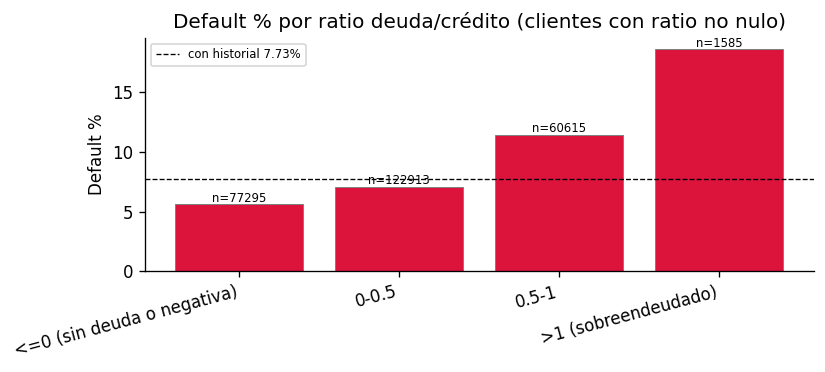

Split del bin <=0 (solo clientes con historial):
  ratio = 0 (sin deuda):    5.67%  (n=76030)
  ratio < 0 (deuda negativa): 3.87%  (n=1265)
  suma = 77295 (debe cuadrar con el bin <=0)
  delta negativa vs cero: -1.80 pp, z=-2.7, p=0.006046074520773134

Solapamiento ratio<0 vs NEGATIVE_LIMIT_FLAG (clientes con historial):


NEGATIVE_LIMIT_FLAG,0,1
ratio<0 (deuda neg),,
0,261903,323
1,1265,0


  clientes con ambas: 0 de 1265 con ratio<0 y de 323 con limite<0
  Fisher exact p = 0.415; solapamiento esperado bajo independencia = 1.55 clientes

Bin protector <=0 completo vs NEGATIVE_LIMIT_FLAG (clientes con historial):


NEGATIVE_LIMIT_FLAG,0,1
bin <=0 (protector),,
0,185873,323
1,77295,0


  de los 323 clientes con limite<0, 0 caen en el bin protector <=0 (Fisher exact p = 0.0)


In [52]:
# exposición y sobregiro
hm = np.asarray(hist_mask)
neg = bureau_client["BUREAU_NEGATIVE_LIMIT_FLAG"].fillna(0).to_numpy(dtype=int)

evaluar_flags([
    ("BUREAU_NEGATIVE_LIMIT_FLAG", neg),
    ("BUREAU_NEGATIVE_LIMIT_FLAG", neg, hm),
])
evaluar_continuas(["BUREAU_DEBT_CREDIT_RATIO"])

# cobertura de sobregiro
n_neg = neg[hm].sum()
print(f"Cobertura del sobregiro: {n_neg} clientes = {round(n_neg / hm.sum() * 100, 3)}% de los que tienen historial")

# distribución por ratio deuda/crédito
ratio = bureau_client["BUREAU_DEBT_CREDIT_RATIO"]
rbins = pd.cut(ratio, [-np.inf, 0, 0.5, 1, np.inf],
               labels=["<=0 (sin deuda o negativa)", "0-0.5", "0.5-1", ">1 (sobreendeudado)"])

tab = bureau_client["TARGET"].groupby(rbins, observed=False).agg(["mean", "size"]).rename(
    columns={"mean": "Default %", "size": "n"}
)
tab["Default %"] *= 100

print("\nDefault por BUREAU_DEBT_CREDIT_RATIO (solo clientes con ratio no nulo):")
display(tab)
print(f"Negativos dentro del bin <=0: {ratio.lt(0).sum()} clientes (deuda agregada negativa; ver split abajo)")

base = np.asarray(TARGET_B)[hm].mean() * 100
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(tab.index, tab["Default %"], color=color_default, edgecolor="gray", linewidth=0.6)
ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
for i, (v, n) in enumerate(zip(tab["Default %"], tab["n"])):
    ax.text(i, v + 0.2, f"n={n}", ha="center", fontsize=7)
ax.set(title="Default % por ratio deuda/crédito (clientes con ratio no nulo)", xlabel="", ylabel="Default %")
ax.legend(fontsize=7)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# split de deuda cero y negativa
ratio_h = ratio[hm]
tb_h = np.asarray(TARGET_B)[hm]
g_zero = (ratio_h == 0).to_numpy()
g_neg = (ratio_h < 0).to_numpy()
# aplico un conteo directo sobre array booleano
n_zero, n_neg_r = g_zero.sum(), g_neg.sum()
d_zero, d_neg = tb_h[g_zero].mean(), tb_h[g_neg].mean()
pp = tb_h[g_zero | g_neg].mean()
z = (d_neg - d_zero) / np.sqrt(pp * (1 - pp) * (1 / n_zero + 1 / n_neg_r))
print("Split del bin <=0 (solo clientes con historial):")
print(f"  ratio = 0 (sin deuda):    {round(d_zero*100, 2)}%  (n={n_zero})")
print(f"  ratio < 0 (deuda negativa): {round(d_neg*100, 2)}%  (n={n_neg_r})")
print(f"  suma = {n_zero + n_neg_r} (debe cuadrar con el bin <=0)")
print(f"  delta negativa vs cero: {(d_neg-d_zero)*100:+.2f} pp, z={round(z, 1)}, p={2*norm.sf(abs(z))}")

# solapamiento ratio<0 vs NEGATIVE_LIMIT_FLAG
neg_hm = neg[hm]
# crosstab directo con arrays y reindex
ct = pd.crosstab(g_neg.astype(int), neg_hm, 
                 rownames=["ratio<0 (deuda neg)"], 
                 colnames=["NEGATIVE_LIMIT_FLAG"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
print("\nSolapamiento ratio<0 vs NEGATIVE_LIMIT_FLAG (clientes con historial):")
display(ct)
inter = ct.loc[1, 1]
# reuso n_lim previamente calculado
n_lim = neg_hm.sum()
print(f"  clientes con ambas: {inter} de {n_neg_r} con ratio<0 y de {n_lim} con limite<0")

# test de Fisher (ratio<0 vs NEGATIVE_LIMIT_FLAG)
_, p_fisher = fisher_exact(ct)
esperado = n_neg_r * n_lim / hm.sum()
print(f"  Fisher exact p = {round(p_fisher, 3)}; solapamiento esperado bajo independencia = {round(esperado, 2)} clientes")

# test de Fisher (bin <=0 vs NEGATIVE_LIMIT_FLAG)
prot = (ratio_h <= 0).to_numpy()
# crosstab directo con arrays y reindex
ct_full = pd.crosstab(prot.astype(int), neg_hm, 
                      rownames=["bin <=0 (protector)"], 
                      colnames=["NEGATIVE_LIMIT_FLAG"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
print("\nBin protector <=0 completo vs NEGATIVE_LIMIT_FLAG (clientes con historial):")
display(ct_full)
_, p_full = fisher_exact(ct_full)
en_bin = ct_full.loc[1, 1]
print(f"  de los {n_lim} clientes con limite<0, {en_bin} caen en el bin protector <=0 "
      f"(Fisher exact p = {round(p_full, 3)})")

**Exposición** La señal más fuerte de todo el análisis a nivel fila `BUREAU_NEGATIVE_LIMIT_FLAG` (el sobregiro en revolving) sobrevive a la agregación y además se refuerza al aplicar el control de composición, en donde pasa de +12,37pp a **+12,72pp** (20,43% vs 7,71%, n = 323, z = 8,6, p = 1,19e-17). Sigue siendo el delta más alto de todo bureau. Un cliente con límite negativo no "triplica" la tasa global, la multiplica por **2,53** (20,43% frente al 8,07%), o por 2,65 contra la base condicionada.

Los 323 clientes son el **0,123%** de los que tienen historial, unos 66 defaults en total. Por el doble criterio (significancia estadística y
relevancia práctica) el sobregiro es una señal de severidad extrema pero de impacto casi nulo a nivel de cartera. Es la misma tensión que ya vi en la mora activa (bloque de mora) y se resuelve igual. Se conserva por la magnitud del efecto, pero la prioridad la marca el IV en FE, no el tamaño del delta.

`BUREAU_DEBT_CREDIT_RATIO` es la feature realmente útil de este bloque: se pasa al helper como string, así que el `notna()` ya la condiciona sola (n = 262.408,
los clientes con historial y crédito reportado no nulo). Nunca necesitó el control de composición y su r_rb = 0,1828 siempre fue válido, directamente comparable con el 0,1208 de `BUREAU_ACTIVE_COUNT` condicionado. Es la señal continua más alta de las medidas hasta aquí. El gradiente por bins es monótono y limpio: sin deuda o negativa 5,64% (n = 77.295), ratio de 0 a 0,5 7,07% (n = 122.913), de 0,5 a 1 11,43% (n = 60.615) y sobreendeudado (ratio > 1, la deuda supera al crédito reportado) 18,61% (n = 1.585). Del extremo protector al de riesgo hay un factor de 3,3.

Al mirar las correlaciones (correlaciones) vi que `AMT_CREDIT_SUM` y `AMT_CREDIT_SUM_DEBT` tenían correlación 0,67 entre sí y ambas |r| < 0,011 con el `TARGET`: individualmente son despreciables. Combinadas como proporción y agregadas a nivel cliente producen la señal continua más fuerte de la tabla. Creé el ratio para resolver la multicolinealidad, de forma que el resultado es que la proporción discrimina donde los importes absolutos no discriminaban nada.

Un matiz sobre el bin extremo inferior, que testé para no extrapolar sin más el resultado de nivel fila (donde la deuda negativa no discriminaba: 7,78% vs 7,82%, p = 0,922). El bin "<=0" mezcla 1.265 clientes con ratio negativo (deuda agregada < 0, revolving) con los de deuda cero, y el split a nivel cliente confirma la fusión y la refina: los de deuda cero rinden 5,67% (n = 76.030) y los de ratio negativo 3,87% (n = 1.265), un delta de -1,80pp (z = -2,7, p = 6,05e-03). 

A nivel cliente la deuda negativa no es que no discrimine, es levemente más protectora, coherente si se leyese como saldo a favor o sobrepago, señal de holgura financiera. Al quedar por debajo del umbral de 2pp no justifica separar el bin, pero valida que la fusión no esconde riesgo. Y despeja la sospecha de fondo, con dos contrastes que no dicen lo mismo. El ratio negativo (`AMT_CREDIT_SUM_DEBT < 0`) y el sobregiro de límite (`BUREAU_NEGATIVE_LIMIT_FLAG`, `AMT_CREDIT_SUM_LIMIT < 0`) no comparten ningún cliente, pero eso por sí solo no prueba nada, ya que con solo 1,55 esperados bajo independencia, el cero observado es azar (Fisher p = 0,415). Lo concluyente es el cruce del bin protector completo: **ninguno de los 323 clientes con límite negativo cae en el bin `<=0`**, cuando bajo independencia caerían unos 95 (77.295 × 323 / 263.491). El déficit es significativo (Fisher p < 0,001) y tiene un mecanismo claro, porque un sobregiro activo implicaría deuda positiva y su ratio es > 0 por construcción, así que nunca entra en el bin sin deuda. El bin protector no esconde nada del subgrupo de +12,72pp, ahora corroborado y no solo afirmado. Confirma a nivel cliente lo que veía a nivel fila: deuda negativa y límite negativo son fenómenos distintos y con signo de riesgo opuesto.

Decisión del bloque: `BUREAU_DEBT_CREDIT_RATIO` es feature de primer orden y
`BUREAU_NEGATIVE_LIMIT_FLAG` la conservaré pese a su baja frecuencia por la magnitud del efecto, con la cobertura anotada. `BUREAU_TOTAL_DEBT` la mantendré solo como componente del ratio.

Nota de robustez: la señal del ratio se mide sobre las sumas crudas, que aún contienen los errores de dominio de importes (585M/396M) que anoté al analizar los extremos. Revertir esos errores mueve el r_rb de `BUREAU_DEBT_CREDIT_RATIO` de 0,1828 a **0,1829** (un solo cliente), así que el gradiente reportado es robusto; la reversión sigue siendo necesaria en la fase de features por las sumas absolutas de `BUREAU_TOTAL_DEBT`, no por esta señal.

Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0,global (nulo=0),8.88% (n=60272),7.88% (n=247239),+1.01 pp,8.1,4.4309176271787864e-16
BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0,con historial,8.88% (n=60272),7.39% (n=203219),+1.49 pp,12.1,1.902603097325858e-33


BUREAU_ANNUITY_ACTIVE_RATIO: 80.4% de ceros (rank-biserial se aplasta)


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_ANNUITY_ACTIVE_RATIO,global (fill 0),307511,0.0242,6.691760609114906e-20,0.0,0.0
BUREAU_ANNUITY_ACTIVE_RATIO,solo con cuota,60272,0.0676,1.8235221726149167e-16,0.5,0.5



Crosstab de redundancia (solo clientes con historial):


CREDITS_WITH_ANNUITY > 0,0,1
HAS_BUREAU_ANNUITY (notna),,
0,183482,0
1,19737,60272


V de Cramer: 0.8247 | Jaccard 75.3%


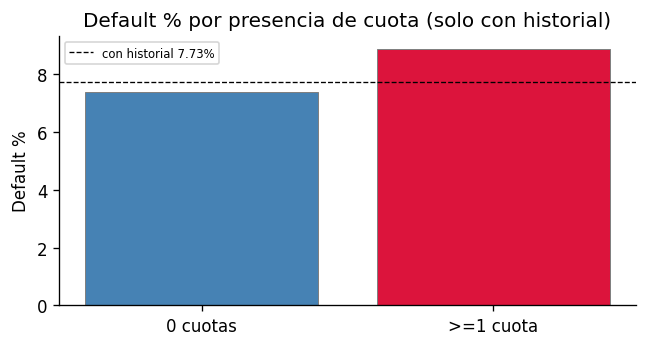


Grupos disjuntos de cuota (solo clientes con historial):


,Default %,n
1. Sin cuota reportada,7.5,183482
2. Reportada pero toda a cero,6.32,19737
3. Cuota real (>0),8.88,60272


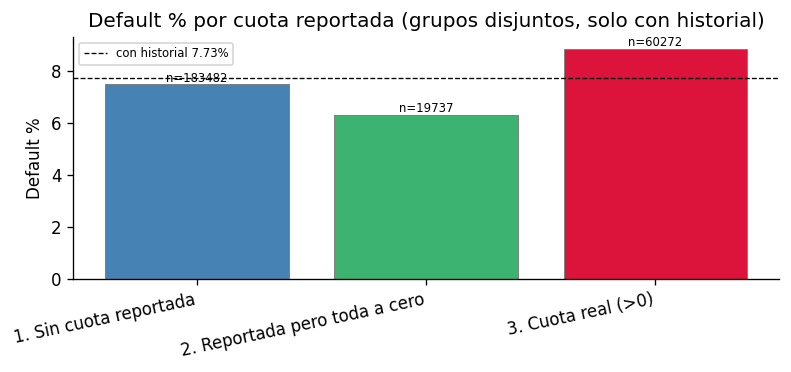

Chi2 de la particion 3x2 (grupos de cuota vs TARGET): chi2 = 180.03110800735587, dof = 2, p = 8.067548979069924e-40, V de Cramer = 0.0261
z-test 'reportada a cero' (6.32%, n=19737) vs 'cuota real' (8.88%, n=60272): delta = +2.56 pp, z = 11.3, p = 8.510210469405076e-30


In [53]:
# cuota reportada
hm = np.asarray(hist_mask)
ann_flag = (bureau_client["BUREAU_CREDITS_WITH_ANNUITY_COUNT"] > 0).to_numpy(dtype=int)
evaluar_flags([
    ("BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0", ann_flag),
    ("BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0", ann_flag, hm),
])

# ratio de cuota activa
ratio_ann = bureau_client["BUREAU_ANNUITY_ACTIVE_RATIO"]
pct_cero = (ratio_ann.fillna(0) == 0).mean() * 100
print(f"BUREAU_ANNUITY_ACTIVE_RATIO: {round(pct_cero, 1)}% de ceros (rank-biserial se aplasta)")
evaluar_continuas([
    ("BUREAU_ANNUITY_ACTIVE_RATIO", True, None, "global (fill 0)"),
    ("BUREAU_ANNUITY_ACTIVE_RATIO", True, hm & (ann_flag == 1), "solo con cuota"),
])

# redundancia con HAS_BUREAU_ANNUITY
has_ann = bureau_client["HAS_BUREAU_ANNUITY"].fillna(0).to_numpy(dtype=int)
has_ann_hm, ann_flag_hm = has_ann[hm], ann_flag[hm]
ct = pd.crosstab(has_ann_hm, ann_flag_hm, 
                 rownames=["HAS_BUREAU_ANNUITY (notna)"], 
                 colnames=["CREDITS_WITH_ANNUITY > 0"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
print("\nCrosstab de redundancia (solo clientes con historial):")
display(ct)
if (ct.sum(axis=1) > 0).all() and (ct.sum(axis=0) > 0).all():
    v_cramer = np.sqrt(chi2_contingency(ct)[0] / ct.values.sum())
    inter, union = ct.loc[1, 1], ct.values.sum() - ct.loc[0, 0]
    print(f"V de Cramer: {round(v_cramer, 4)} | Jaccard {round(inter / union * 100, 1)}%")

tb_hm = np.asarray(TARGET_B)[hm]
base = tb_hm.mean() * 100
fig, ax = plt.subplots(figsize=(5.5, 3))
rates = [tb_hm[ann_flag_hm == 0].mean() * 100, tb_hm[ann_flag_hm == 1].mean() * 100]
ax.bar(["0 cuotas", ">=1 cuota"], rates, color=[color_no_default, color_default], edgecolor="gray", linewidth=0.6)
ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
ax.set(title="Default % por presencia de cuota (solo con historial)", ylabel="Default %")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# partición tripartita de cuotas
# calculo g directamente sobre subconjunto hm
g = np.where(ann_flag_hm == 1, "3. Cuota real (>0)",
             np.where(has_ann_hm == 1, "2. Reportada pero toda a cero", "1. Sin cuota reportada"))

# agrupo
tab_ann = pd.Series(tb_hm).groupby(g).agg(["mean", "size"]).rename(
    columns={"mean": "Default %", "size": "n"}
)
tab_ann["Default %"] *= 100
print("\nGrupos disjuntos de cuota (solo clientes con historial):")
display(tab_ann)

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.bar(tab_ann.index, tab_ann["Default %"], color=[color_no_default, "mediumseagreen", color_default],
       edgecolor="gray", linewidth=0.6)
ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
for i, (v, n) in enumerate(zip(tab_ann["Default %"], tab_ann["n"])):
    ax.text(i, v + 0.1, f"n={n}", ha="center", fontsize=7)
ax.set(title="Default % por cuota reportada (grupos disjuntos, solo con historial)",
       ylabel="Default %", xlabel="")
ax.legend(fontsize=7)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

# test de la partición (Chi2 y z-test)
tab_chi = pd.crosstab(g, tb_hm)
chi2, p_chi, dof, _ = chi2_contingency(tab_chi)
v_cramer3 = np.sqrt(chi2 / (tab_chi.values.sum() * (min(tab_chi.shape) - 1)))
print(f"Chi2 de la particion 3x2 (grupos de cuota vs TARGET): chi2 = {chi2}, "
      f"dof = {dof}, p = {p_chi}, V de Cramer = {round(v_cramer3, 4)}")

m2 = (g == "2. Reportada pero toda a cero")
m3 = (g == "3. Cuota real (>0)")
# conteo directamente en arrays booleanos
n2, n3 = m2.sum(), m3.sum()
p2, p3 = tb_hm[m2].mean(), tb_hm[m3].mean()
pp = tb_hm[m2 | m3].mean()
z23 = (p3 - p2) / np.sqrt(pp * (1 - pp) * (1 / n2 + 1 / n3))
print(f"z-test 'reportada a cero' ({round(p2*100, 2)}%, n={n2}) vs 'cuota real' ({round(p3*100, 2)}%, n={n3}): "
      f"delta = {(p3-p2)*100:+.2f} pp, z = {round(z23, 1)}, p = {2*norm.sf(abs(z23))}")

**Cuota** Este bloque me confirmó lo anticipado y es que la señal de la cuota está en la presencia y no en el importe, pero me ha dado bastante más de lo que esperaba, ya que la feature que traía del primer chunk de esta fase está mal codificada.

Tener al menos un crédito con cuota reportada da +1,01pp sin condicionar y **+1,49pp** al controlar por historial (8,88% vs 7,39%, n = 60.272, z = 12,1, p = 1,90e-33). Pasa Bonferroni con holgura pero se queda por debajo del umbral de 2pp, así que en principio caería en la banda débil de 1-2pp.

`BUREAU_ANNUITY_ACTIVE_RATIO` como continua ilustra el resultado de empates y permite cuantificarlo por primera vez. Medida en global con `fill 0`, el 80,4% de los clientes vale cero y el rank-biserial se aplasta a 0,0242. Restringida a los 60.272 que sí tienen cuota reportada sube a **0,0676**, casi el triple. La conclusión es doble: el 0,0242 medía la pregunta equivocada, pero incluso el 0,0676 corregido se queda por debajo de 0,10, así que la magnitud del ratio sigue siendo señal pequeña. Las medianas son 0,5 en ambas clases: por lo que discrimina no es el centro de la distribución.

Lo importante del bloque es la redundancia. `HAS_BUREAU_ANNUITY` (del inicio) y `BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0` son casi lo mismo medido en bloques
distintos. El resultado de V = **0,8247** con Jaccard del 75,3%, está muy por
encima del umbral de 0,50. El anidamiento es perfecto, ya que ningún cliente tiene cuota > 0 sin tener cuota reportada, necesario por construcción.

Pero el crosstab me indica algo que no anticipaba y que cambia mi decisión. La cuota tiene la **misma estructura tripartita** que `AMT_CREDIT_MAX_OVERDUE`: 183.482 clientes sin cuota reportada, **19.737 con cuota reportada pero toda a cero**, y 60.272 con cuota real. Al medir los tres grupos disjuntos el patrón **no es monótono**: sin cuota reportada 7,50%, reportada pero a cero **6,32%**,
cuota real 8,88%. El grupo del medio es el de **menor riesgo de los tres**, 1,41pp por debajo de la base de 7,73%.

Tiene sentido y explica algo previo. Un cero reportado no es un dato ausente: es
el buró afirmando que ese crédito no tiene cuota pendiente, o sea información positiva sobre un crédito ya saldado. El nulo, en cambio, es ausencia de información y se queda pegado a la media (7,50%). Y la cuota real es carga de pago activa, el grupo de más riesgo. La señal "está en la proporción de ceros por clase, no en el importe" que vi (al analizar la ausencia de dato, deep-dive de `AMT_ANNUITY`) es exactamente esto.

De ahí que `HAS_BUREAU_ANNUITY` no sea solo redundante: es una **codificación estrictamente peor**. Al construirse con `notna()` fusiona el grupo más protector (6,32%) con el más arriesgado (8,88%) y por eso su delta sale diluido en +0,75pp, la mitad del +1,49pp de la flag que sí los separa. La reclasificaré de candidata débil a **descarte por redundancia y por codificación**.

Y hay una consecuencia que cambia el veredicto del bloque. El contraste entre "reportada a cero" y "cuota real" vale **+2,56pp** (8,88% vs 6,32%), y el z-test lo confirma con holgura (z = 11,3, p = 8,51e-30): cruza el umbral práctico de 2pp, donde la flag binaria se quedaba en +1,49pp. El Chi2 de la partición completa también sale significativo (χ² = 180, dof = 2, p = 8,07e-40), pero con V de Cramér = 0,0261, un efecto global pequeño, y esa aparente contradicción es clave, ya que la mayoría de clientes (los 183.482 sin cuota reportada) están pegados a la base, así que la cuota es una feature de magnitud modesta a nivel global. Lo que la codificación binaria ocultaba es que, dentro del subgrupo que sí reporta, hay un gradiente real entre el crédito saldado (6,32%) y la carga de pago activa (8,88%). no es que la señal sea débil por ruido, es que la flag fusionaba esos dos grupos.

Decisión del bloque: descartaré `HAS_BUREAU_ANNUITY`, conservaré `BUREAU_CREDITS_WITH_ANNUITY_COUNT` y para FE, evaluaré si es mejor la codificación de tres niveles (sin reportar / reportada a cero / cuota real) en vez de cualquiera de las dos flags binarias. `BUREAU_ANNUITY_ACTIVE_RATIO` quedará como secundaria.

La idea a retener de este bloque es que en bureau el cero y el nulo son cosas distintas y con riesgos opuestos, y
toda flag construida con `notna()` o `> 0` corre el riesgo de colapsarlos.

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_DAYS_CREDIT_MIN,no nulos (auto-cond.),263491,0.1567,5.478175518627115e-303,-1861.0,-1469.0
BUREAU_DAYS_CREDIT_MAX,no nulos (auto-cond.),263491,0.1606,0.0,-308.0,-221.0
BUREAU_DAYS_ENDDATE_FACT_MIN,no nulos (auto-cond.),230148,0.1235,7.459956536807405e-156,-1471.0,-1203.0


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_DAYS_CREDIT_UPDATE_FLAG,global (nulo=0),8.15% (n=219617),7.87% (n=87894),+0.29 pp,2.6,0.008510980587721541
BUREAU_DAYS_CREDIT_UPDATE_FLAG,con historial,8.15% (n=219617),5.6% (n=43874),+2.55 pp,18.3,1.7690206402698443e-74
HAS_BEEN_PROLONGED,global (nulo=0),8.71% (n=8508),8.05% (n=299003),+0.65 pp,2.2,0.028828567424463304
HAS_BEEN_PROLONGED,con historial,8.71% (n=8508),7.7% (n=254983),+1.01 pp,3.4,0.0005848049018560078


Grupo 0 de UPDATE_FLAG: 87894 clientes, de los cuales 44020 (50.1%) no tienen historial


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_CLOSED_AFTER_ENDDATE > 0,global (nulo=0),6.92% (n=117474),8.79% (n=190037),-1.87 pp,-18.5,1.7570275921867902e-76
BUREAU_CLOSED_AFTER_ENDDATE > 0,con historial,6.92% (n=117474),8.38% (n=146017),-1.47 pp,-14.0,1.0688344996184622e-44
BUREAU_CLOSED_AFTER_ENDDATE > 0,con créditos cerrados,6.92% (n=117474),7.59% (n=112691),-0.67 pp,-6.2,5.758161976986043e-10


Poblacion del test valido: 230165 clientes con al menos un credito cerrado


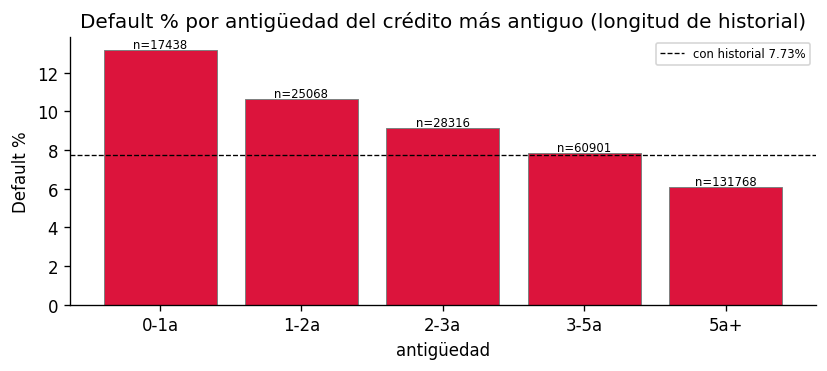


Señal residual de UPDATE_FLAG dentro de estratos de longitud de historial:


Estrato historial,Tasa UPD=1,Tasa UPD=0,Delta,z-stat,p-valor
0-1a,13.29% (n=17069),8.13% (n=369),+5.16 pp,2.9,0.003727371223008593
1-2a,11.1% (n=21393),7.81% (n=3675),+3.29 pp,6.0,2.27264444369885e-09
2-3a,9.74% (n=23247),6.25% (n=5069),+3.49 pp,7.8,5.6537581653641675e-15
3-5a,8.21% (n=49889),6.28% (n=11012),+1.93 pp,6.8,1.0662416815304771e-11
5a+,6.39% (n=108019),4.77% (n=23749),+1.62 pp,9.5,3.1056620417336377e-21



Pearson cliente DAYS_CREDIT_MIN vs DAYS_ENDDATE_FACT_MIN: r = 0.8675 (n = 230148; umbral de redundancia > 0,70; a nivel fila era 0,88)
  medianas DAYS_ENDDATE_FACT_MIN: -1451.0 dias es el cierre más antiguo (MIN), no la recencia del último cierre


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
BUREAU_ENDDATE_2_5Y_COUNT > 0,con historial,9.36% (n=89395),6.89% (n=174096),+2.47 pp,22.5,3.718799385329588e-112


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
BUREAU_ENDDATE_2_5Y_COUNT,con historial,263491,0.086,5.1851285265789455e-132,0.0,0.0
BUREAU_DAYS_CREDIT_ENDDATE_MAX,no nulos (auto-cond.),250154,0.0906,1.8403463805933452e-96,394.0,622.0


Default % por nro de creditos a termino con vencimiento a 2-5 anios (solo con historial):


,Default %,n
BUREAU_ENDDATE_2_5Y_COUNT,,
0,6.89,174096
1,8.7,61973
2,10.13,19168
3+,12.59,8254


Default % por recencia del credito mas reciente (DAYS_CREDIT max, solo con historial):


,Default %,n
BUREAU_DAYS_CREDIT_MAX,,
0-0.5a,10.17,84854
0.5-1a,7.78,66908
1-2a,6.12,57852
2-3a,5.09,24086
3a+,5.92,29791


Pearson cliente DAYS_CREDIT_MIN vs DAYS_CREDIT_MAX: 0.1988 (< 0,70: no redundantes; longitud de historial vs recencia de la ultima solicitud)


In [54]:
# recencia y consistencia temporal
hm = np.asarray(hist_mask)
evaluar_continuas([
    "BUREAU_DAYS_CREDIT_MIN",
    "BUREAU_DAYS_CREDIT_MAX",
    "BUREAU_DAYS_ENDDATE_FACT_MIN",
])

upd = bureau_client["BUREAU_DAYS_CREDIT_UPDATE_FLAG"].fillna(0).to_numpy(dtype=int)
prol = bureau_client["HAS_BEEN_PROLONGED"].fillna(0).to_numpy(dtype=int)
late = (bureau_client["BUREAU_CLOSED_AFTER_ENDDATE"] > 0).to_numpy(dtype=int)

evaluar_flags([
    ("BUREAU_DAYS_CREDIT_UPDATE_FLAG", upd),
    ("BUREAU_DAYS_CREDIT_UPDATE_FLAG", upd, hm),
    ("HAS_BEEN_PROLONGED", prol),
    ("HAS_BEEN_PROLONGED", prol, hm),
])

# análisis de UPDATE_FLAG
n0_glob = (upd == 0).sum()
n_no_hm = (~hm).sum()
print(f"Grupo 0 de UPDATE_FLAG: {n0_glob} clientes, de los cuales {n_no_hm} "
      f"({round(n_no_hm / n0_glob * 100, 1)}%) no tienen historial")

# análisis de BUREAU_CLOSED_AFTER_ENDDATE
closed_mask = hm & (bureau_client["BUREAU_CLOSED_COUNT"].fillna(0).to_numpy() > 0)
evaluar_flags([
    ("BUREAU_CLOSED_AFTER_ENDDATE > 0", late),
    ("BUREAU_CLOSED_AFTER_ENDDATE > 0", late, hm),
    ("BUREAU_CLOSED_AFTER_ENDDATE > 0", late, closed_mask, "con créditos cerrados"),
])
print(f"Poblacion del test valido: {closed_mask.sum()} clientes con al menos un credito cerrado")

base = np.asarray(TARGET_B)[hm].mean() * 100
# bins de antigüedad
sub = bureau_client[hm]
years = sub["BUREAU_DAYS_CREDIT_MIN"] / -365.25
ybins = pd.cut(years, [-0.01, 1, 2, 3, 5, np.inf], labels=["0-1a", "1-2a", "2-3a", "3-5a", "5a+"])

tab = sub["TARGET"].groupby(ybins, observed=False).agg(["mean", "size"])
tab["mean"] *= 100

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(tab.index, tab["mean"], color=color_default, edgecolor="gray", linewidth=0.6)
ax.axhline(base, color="black", ls="--", lw=0.8, label=f"con historial {round(base, 2)}%")
for i, (v, n) in enumerate(zip(tab["mean"], tab["size"])):
    ax.text(i, v + 0.1, f"n={n}", ha="center", fontsize=7)
ax.set(title="Default % por antigüedad del crédito más antiguo (longitud de historial)",
       xlabel="antigüedad", ylabel="Default %")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# al mirar el eje temporal la di por prescindible, con la señal prestada de DAYS_CREDIT:
# lo repito a nivel cliente antes de dar el rescate por bueno
# mido el delta dentro de estratos de longitud de historial (BUREAU_DAYS_CREDIT_MIN)
# si aguanta en todos, la señal es propia
anios_hist = (bureau_client["BUREAU_DAYS_CREDIT_MIN"] / -365.25)
estratos = pd.cut(anios_hist, [-0.01, 1, 2, 3, 5, np.inf], labels=["0-1a", "1-2a", "2-3a", "3-5a", "5a+"])

rows_res = []
tb_arr = np.asarray(TARGET_B)
for niv in estratos.cat.categories:
    m = hm & (estratos == niv).to_numpy()
    v = upd[m]
    t = tb_arr[m]
    if len(np.unique(v)) < 2:
        continue
    n1, n0 = int((v == 1).sum()), int((v == 0).sum())
    p1, p0 = t[v == 1].mean(), t[v == 0].mean()
    pp = t.mean()
    z = (p1 - p0) / np.sqrt(pp * (1 - pp) * (1 / n1 + 1 / n0))
    rows_res.append({"Estrato historial": niv,
                     "Tasa UPD=1": f"{round(p1*100, 2)}% (n={n1})",
                     "Tasa UPD=0": f"{round(p0*100, 2)}% (n={n0})",
                     "Delta": f"{(p1-p0)*100:+.2f} pp",
                     "z-stat": f"{round(z, 1)}",
                     "p-valor": f"{2*norm.sf(abs(z))}"})

print("\nSeñal residual de UPDATE_FLAG dentro de estratos de longitud de historial:")
display(pd.DataFrame(rows_res).style.hide(axis="index"))

# DAYS_CREDIT_MIN y DAYS_ENDDATE_FACT_MIN se conservan por separado, pero a
# a nivel fila daban r=0,88 y el precedente de la mora enseña que esa correlación engaña,
# así que la mido a nivel cliente (umbral 0,70); las dos son min de columnas negativas,
# o sea el crédito o cierre más antiguo, no el más reciente
sub_t = bureau_client[hm]
both = sub_t[["BUREAU_DAYS_CREDIT_MIN", "BUREAU_DAYS_ENDDATE_FACT_MIN"]].dropna()
r_pear, p_pear = pearsonr(both["BUREAU_DAYS_CREDIT_MIN"], both["BUREAU_DAYS_ENDDATE_FACT_MIN"])
print(f"\nPearson cliente DAYS_CREDIT_MIN vs DAYS_ENDDATE_FACT_MIN: r = {round(r_pear, 4)} "
      f"(n = {len(both)}; umbral de redundancia > 0,70; a nivel fila era 0,88)")
print(f"  medianas DAYS_ENDDATE_FACT_MIN: {round(both['BUREAU_DAYS_ENDDATE_FACT_MIN'].median(), 0)} dias "
      f"es el cierre más antiguo (MIN), no la recencia del último cierre")

# DAYS_CREDIT_ENDDATE agregada (solo créditos a término): recupera la señal en U del eje
# temporal, que no tenía feature a nivel cliente; el pico de riesgo está de 2 a 5 años vista
end25 = (bureau_client["BUREAU_ENDDATE_2_5Y_COUNT"].fillna(0) > 0).to_numpy(dtype=int)
evaluar_flags([
    ("BUREAU_ENDDATE_2_5Y_COUNT > 0", end25, hm),
])
evaluar_continuas([
    ("BUREAU_ENDDATE_2_5Y_COUNT", True, hm, "con historial"),
    "BUREAU_DAYS_CREDIT_ENDDATE_MAX",
])
sub25 = bureau_client[hm]
b25 = pd.cut(sub25["BUREAU_ENDDATE_2_5Y_COUNT"].fillna(0), [-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3+"])
tab25 = sub25["TARGET"].groupby(b25, observed=False).agg(["mean", "size"])
tab25["mean"] *= 100
print("Default % por nro de creditos a termino con vencimiento a 2-5 anios (solo con historial):")
display(tab25.rename(columns={"mean": "Default %", "size": "n"}).round(2))


# recencia de la última solicitud (max de DAYS_CREDIT) frente a la longitud de historial (min):
# son dimensiones distintas, así que se conservan las dos
rec_years = bureau_client.loc[hm, "BUREAU_DAYS_CREDIT_MAX"] / -365.25
recbins = pd.cut(rec_years, [-0.01, 0.5, 1, 2, 3, np.inf], labels=["0-0.5a", "0.5-1a", "1-2a", "2-3a", "3a+"])
rectab = bureau_client.loc[hm, "TARGET"].groupby(recbins, observed=False).agg(["mean", "size"])
rectab["mean"] *= 100
print("Default % por recencia del credito mas reciente (DAYS_CREDIT max, solo con historial):")
display(rectab.rename(columns={"mean": "Default %", "size": "n"}).round(2))
_mm = bureau_client.loc[hm, ["BUREAU_DAYS_CREDIT_MIN", "BUREAU_DAYS_CREDIT_MAX"]].dropna()
_r_mm, _ = pearsonr(_mm["BUREAU_DAYS_CREDIT_MIN"], _mm["BUREAU_DAYS_CREDIT_MAX"])
print(f"Pearson cliente DAYS_CREDIT_MIN vs DAYS_CREDIT_MAX: {round(_r_mm, 4)} "
      f"(< 0,70: no redundantes; longitud de historial vs recencia de la ultima solicitud)")


In [55]:
# valor incremental frente a EXT_SOURCE, que son a su vez scores de buró y los predictores
# más fuertes de application_train; no es evaluación contra TARGET, no entra en el ranking
ext = load_table("application_train", usecols=["SK_ID_CURR", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"])
bc_ext = bureau_client.merge(ext, on="SK_ID_CURR", how="left")

feats_ext = ["BUREAU_DEBT_CREDIT_RATIO", "BUREAU_DAYS_CREDIT_MIN", "BUREAU_DAYS_CREDIT_MAX",
             "BUREAU_CURRENT_OVERDUE_SUM", "BUREAU_ACTIVE_COUNT", "BUREAU_NEGATIVE_LIMIT_FLAG"]
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
sub_ext = bc_ext[hist_mask]

cor_ext = pd.DataFrame(index=feats_ext, columns=ext_cols, dtype=float)
for f in feats_ext:
    for e in ext_cols:
        d = sub_ext[[f, e]].dropna()
        cor_ext.loc[f, e] = pearsonr(d[f], d[e])[0] if len(d) > 2 else np.nan
cor_ext["max |r|"] = cor_ext[ext_cols].abs().max(axis=1)

print("Pearson de las features top de bureau vs EXT_SOURCE (clientes con historial):")
display(cor_ext.style.format("{:+.3f}").background_gradient(cmap="coolwarm", vmin=-0.5, vmax=0.5, subset=ext_cols))
print(f"Umbral de redundancia |r| > 0,70: ninguna feature lo alcanza (max |r| = {cor_ext['max |r|'].max():.3f}). "
      f"El bloque de mora/exposicion es casi ortogonal a EXT_SOURCE.")


Pearson de las features top de bureau vs EXT_SOURCE (clientes con historial):


,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,max |r|
BUREAU_DEBT_CREDIT_RATIO,-0.108,-0.029,-0.223,+0.223
BUREAU_DAYS_CREDIT_MIN,-0.220,-0.101,-0.226,+0.226
BUREAU_DAYS_CREDIT_MAX,-0.071,-0.045,-0.390,+0.390
BUREAU_CURRENT_OVERDUE_SUM,-0.003,-0.002,-0.025,+0.025
BUREAU_ACTIVE_COUNT,+0.027,-0.003,-0.391,+0.391
BUREAU_NEGATIVE_LIMIT_FLAG,-0.001,-0.000,-0.018,+0.018


Umbral de redundancia |r| > 0,70: ninguna feature lo alcanza (max |r| = 0.391). El bloque de mora/exposicion es casi ortogonal a EXT_SOURCE.


**Valor incremental frente a `EXT_SOURCE`.** Todo el análisis a nivel cliente validó la señal de bureau en aislamiento, y la única redundancia inter-tabla que comprobé fue la de los flags de missing contra `AMT_REQ_CREDIT_BUREAU_*`. Pero los predictores más fuertes de application_train son los `EXT_SOURCE` (r −0,155 a −0,179 con `TARGET`), que son a su vez scores de buró: esperaba que, precisamente por eso, ya capturasen buena parte de la señal que estoy agregando aquí, así que antes de dar las features por buenas cruzo por Pearson las continuas y flags top de bureau contra los tres `EXT_SOURCE`, condicionado a historial.

El cruce parte el bloque en dos. Las features temporales y de conteo solapan de forma apreciable con `EXT_SOURCE_3`: `BUREAU_ACTIVE_COUNT` (r = −0,391), `BUREAU_DAYS_CREDIT_MAX` (−0,390), `BUREAU_DAYS_CREDIT_MIN` (−0,226) y `BUREAU_DEBT_CREDIT_RATIO` (−0,223). Ninguna cruza el umbral de redundancia de 0,70, así que no descarto ninguna, pero confirma la sospecha: buena parte de su señal ya podría estar dentro de `EXT_SOURCE_3` (que es, precisamente, un score de buró), y su valor incremental hay que medirlo, no presuponerlo. La mora y el sobregiro, en cambio, son casi ortogonales a los tres scores: `BUREAU_CURRENT_OVERDUE_SUM` (|r| ≤ 0,025) y `BUREAU_NEGATIVE_LIMIT_FLAG` (|r| ≤ 0,018) no están cubiertas por `EXT_SOURCE`. El valor genuinamente nuevo de bureau se concentra por tanto en el bloque de mora/exposición, no en el temporal.

Esto es una correlación lineal marginal, no la prueba definitiva: la decisión rigurosa es medir el IV incremental de cada feature en presencia de `EXT_SOURCE` sobre el split de entrenamiento en FE. Lo dejo anotado como test obligatorio antes de fijar la lista final: conservar las temporales solo si aportan IV por encima de `EXT_SOURCE_3`, y priorizar sin reservas el bloque de mora/exposición.

**Recencia** `BUREAU_DAYS_CREDIT_MIN` es la feature temporal más fuerte a nivel cliente, con un r_rb = 0,1567 sobre los 263.491 clientes con historial, por encima del 0,1427 que `DAYS_CREDIT` tenía a nivel fila y solo por detrás del ratio de endeudamiento (0,1828) entre todas las continuas. Se pasa al helper como string, así que el `notna()` la condiciona sola y nunca necesitó el control. Por otro lado, el `min` de `DAYS_CREDIT` (valores negativos) no es el crédito más reciente sino el **más antiguo**, es decir la longitud del
historial crediticio. La interpretación cuadra, ya que la mediana es -1.861 días en no-defaulters (unos 5,1 años) frente a -1.469 en defaulters (unos 4,0 años), y el gráfico por bins lo confirma de manera monótona. Es el mismo perfil de "joven sin historial", ahora medido como longitud de historial. 

`BUREAU_DAYS_CREDIT_MAX` (el `max` de `DAYS_CREDIT`) mide la recencia del crédito más reciente, y la sumo en esta revisión porque en el primer cierre de la fase agregaba `DAYS_CREDIT` solo como `min` y dejaba el perfil de "buscador activo de crédito" , que subrayé a nivel fila, sin operacionalizar a nivel cliente. Esperaba que aportara señal propia sobre la longitud de historial, y lo confirma con holgura: es la temporal más fuerte del bloque, r_rb = 0,1606 sobre los 263.491 con historial, por encima incluso de `BUREAU_DAYS_CREDIT_MIN` (0,1567). No son redundantes, el Pearson cliente entre `MIN` y `MAX` es solo 0,1988, coherente con que miden cosas distintas (hace cuánto empezó el historial frente a hace cuánto fue la última solicitud). Los defaulters tienen su último crédito más reciente (mediana −221 días frente a −308 en no-defaulters) y el gradiente por bins es monótono: 10,17% cuando la última solicitud cae en los últimos 6 meses y baja hasta 5,09% en el tramo de 2 a 3 años. La conservo como recencia, complementaria a `BUREAU_DAYS_CREDIT_MIN`.

`BUREAU_DAYS_ENDDATE_FACT_MIN` (r_rb = 0,1235, n = 230.148, solo 'Closed') aparentaba tener la misma lógica, y resulta que demasiado: es también un `min` de una columna negativa, o sea el cierre más **antiguo** (no "la recencia del último cierre", que sería el `max`), así que mide casi lo mismo que `BUREAU_DAYS_CREDIT_MIN`: la profundidad del historial. El Pearson a nivel cliente entre ambas es **0,8675** (n = 230.148), por encima del umbral de redundancia de 0,70 y en línea con el 0,88 de nivel fila. Al principio, las conservé ambas "por concepto", pero a nivel cliente son redundantes, por lo que me quedaré solo con `BUREAU_DAYS_CREDIT_MIN`, que además es más fuerte (0,1567 vs 0,1235) y cubre a los 263.491 en vez de solo los 230.148 con cierre. Es imprescindible que una correlación de nivel fila (aquí ya alta, 0,88) haya que reconfirmarla a nivel cliente antes de conservar dos features casi idénticas.

Lo más interesante del bloque es un descarte que hice antes y que estaba mal. `BUREAU_DAYS_CREDIT_UPDATE_FLAG` daba +0,29pp sin condicionar, no superaba Bonferroni y pensaba que era prescindible. El motivo resulta ser el resultado de una operación manual: **el 50,1% de su grupo 0 (44.020 de 87.894) son los clientes sin historial**, que por el left join entran con la flag a 0 y son el grupo de mayor riesgo. Al condicionar a historial la variable pasa a **+2,55pp** (8,15% vs 5,60%, n = 43.874 en el grupo 0, z = 18,3, p = 1,77e-74): cruza el umbral de 2pp y pasa Bonferroni. Cuando pensé que era prescindible, finalmente su señal estaba oculta bajo la composición.

Antes de 'rescatarla' tuve que reflexionar, ya que concluí que la señal de `DAYS_CREDIT_UPDATE` era "mayoritariamente prestada de `DAYS_CREDIT`". Repito ese análisis a nivel cliente midiendo el delta dentro de estratos de longitud de historial, y **la señal sobrevive en los 5**: +5,16pp en 0 a 1 año, +3,29pp en 1-2, +3,49pp en 2-3, +1,93pp en 3 a 5 y +1,62pp en 5 o más, todos significativos. La señal es propia, no prestada. El único estrato con reservas es el de 0 a 1 año, donde el grupo `UPD=0` tiene solo n = 369 y el p = 3,73e-03 se sostiene
por los pelos.

La tabla estratificada da además muestra 2 cosas. La primera es que el delta **decrece con la longitud del historial** (de +5,16pp a +1,62pp), ya que la recencia de la actualización importa mucho más en clientes de historial corto. La segunda es que ambas variables discriminan a la vez y de forma casi aditiva: la celda de menor riesgo es historial largo con registro dormante (4,77%, n = 23.749) y la de mayor riesgo es historial corto con actualización reciente (13,29%, n = 17.069), un recorrido de 8,52pp y un factor de 2,8. Por lo que es candidata clara a pasar a la fase de FE (interacción).

Esta lectura de negocio encaja con 2 perfiles. Un registro actualizado en los
últimos 6 meses significa actividad crediticia reciente y apunta al "buscador activo de crédito"; los 43.874 con registro dormante al 5,60% (por debajo incluso del 7,02% de los clientes sin mora) son de los segmentos más seguros de todo bureau y encajan con el "pensionista conservador".

`HAS_BEEN_PROLONGED` también cambia de estado, aunque menos. Pasa de +0,65pp con p = 0,029 (fallaba Bonferroni) a **+1,01pp con p = 5,85e-04**, que sí lo supera. +1,01pp cae en la banda de señal débil, así que deja de ser descarte y pasa a ser evaluada mediante IV en FE.

`BUREAU_CLOSED_AFTER_ENDDATE` es el caso contrario: la conclusión era correcta pero la evidencia con la que la sostuve no lo era. Había escrito que su -1,87pp protector "hereda el efecto de tener créditos cerrados", y era una hipótesis razonable sobre una comparación doblemente confundida (los sin historial en el grupo 0, más el efecto de `BUREAU_CLOSED_COUNT`). El test que aísla el fenómeno es medirlo solo entre los 230.165 clientes con al menos un crédito cerrado, y el
resultado **confirma la hipótesis y la cuantifica**: -1,87pp en global, -1,47pp al condicionar por historial y **-0,67pp** en el test válido (6,92% vs 7,59%, z = -6,2). El 64% del efecto original era señal prestada. El residuo sigue siendo significativo (p = 5,76e-10) pero -0,67pp queda por debajo incluso de la banda débil de 1-2pp, así que descartarla se mantiene, pero ahora con la evidencia correcta. Matizo que ni este test es del todo limpio: entre los que tienen créditos cerrados, haber cerrado tarde sigue correlacionando con tener **más** cerrados, y lo riguroso sería estratificar por `BUREAU_CLOSED_COUNT`. No lo hago porque el residuo ya es demasiado pequeño para cambiar la decisión.

Decisiones del bloque: `BUREAU_DAYS_CREDIT_MIN` (longitud de historial) y `BUREAU_DAYS_CREDIT_MAX` (recencia de la última solicitud) de primer orden; `BUREAU_DAYS_ENDDATE_FACT_MIN` **la descartaré por redundancia** (r = 0,8675 con la anterior); `BUREAU_DAYS_CREDIT_UPDATE_FLAG` **la salvo** con señal propia verificada; `HAS_BEEN_PROLONGED` pasa a banda débil para IV; `BUREAU_CLOSED_AFTER_ENDDATE` la descartó con el test válido. Queda para FE la interacción entre longitud de historial y recencia de actualización.

**Vencimiento a término a de 2 a 5 años.** Al mirar el eje temporal, `DAYS_CREDIT_ENDDATE` era la única temporal con forma de U (pico de riesgo en el bin "2 a 5 años", r_rb fila 0,1094) y planifiqué agregarla solo para créditos a término, pero en el primer cierre de esta fase quedó **sin feature a nivel cliente**. Lo corrijo: `BUREAU_ENDDATE_2_5Y_COUNT` (nº de créditos a término, excluyendo revolving y placeholders de más de 20 años, con vencimiento planificado a de 2 a 5 años en el futuro) captura ese pico. La flag `>0` da **+2,47pp** condicionada (9,36% vs 6,89%, n = 89.395, z = 22,5), cruzando el umbral práctico de 2pp, y el gradiente por conteo es monótono y limpio: 0 da 6,89%, 1 da 8,70%, 2 da 10,13% y 3 o más da 12,59% (n = 8.254), un factor de 1,8. `BUREAU_DAYS_CREDIT_ENDDATE_MAX` (vencimiento a término más lejano) queda como secundaria (r_rb 0,0906, mediana −622 vs −394 días entre clases). La señal en U que veía a nivel fila **sí sobrevive** a la agregación: es carga de pago próxima (créditos aún vivos que vencen a medio plazo), el mismo perfil de presión de deuda activa. Conservo `BUREAU_ENDDATE_2_5Y_COUNT`.

### 11. Conclusiones y features candidatas

In [56]:
# ranking consolidado a nivel cliente, con el TARGET real
# los acumuladores guardan la última medición de cada feature: la condicionada donde aplica
# el control de composición, y la global solo donde es la correcta
n_features = len(fb_flags) + len(fb_cont)
# la familia vinculante es una comparación por feature, la condicionada; las globales
# contaminadas solo cuentan como alfa conservador de referencia, y la decisión la marcan
# el tamaño del efecto y el umbral de 2pp, no el p-valor
n_comparisons = len(fb_comparisons)   # todas las emitidas (global + condicionada)
n_tests = n_features                  # familia valida: una decision por feature
alpha_bonf = 0.05 / n_tests
alpha_bonf_consv = 0.05 / n_comparisons

# decisión por feature, para que el ranking no se lea como si todo lo significativo entrase

estado_features = {
    "HAS_BUREAU_HISTORY": "conservar (1er orden)",
    "BUREAU_ACTIVE_COUNT": "conservar (primario)",
    "BUREAU_CLOSED_COUNT": "conservar",
    "BUREAU_BAD_DEBT_COUNT": "conservar (flag)",
    "BUREAU_CURRENT_OVERDUE_SUM": "conservar (mora prioritaria)",
    "BUREAU_HAS_ANY_OVERDUE": "conservar",
    "BUREAU_MAX_OVERDUE_EVER": "conservar",
    "BUREAU_DEBT_CREDIT_RATIO": "conservar (1er orden)",
    "BUREAU_NEGATIVE_LIMIT_FLAG": "conservar (severidad)",
    "BUREAU_DAYS_CREDIT_MIN": "conservar (1er orden)",
    "BUREAU_DAYS_CREDIT_MAX": "conservar (recencia)",
    "BUREAU_CREDITS_WITH_ANNUITY_COUNT": "conservar (3 niveles en FE)",
    "BUREAU_DAYS_CREDIT_UPDATE_FLAG": "conservar (rescatada)",
    "HAS_BUREAU_FINANCIAL_DETAIL": "IV (banda debil)",
    "HAS_BEEN_PROLONGED": "IV (banda debil)",
    "BUREAU_ANNUITY_ACTIVE_RATIO": "IV (secundaria)",
    "BUREAU_CREDIT_TYPE_NUNIQUE": "IV (secundaria)",
    "HAS_BUREAU_ANNUITY": "descartar (codif. peor)",
    "HAS_BUREAU_OVERDUE_HISTORY": "descartar (señal en valor)",
    "BUREAU_CLOSED_AFTER_ENDDATE": "descartar (test valido)",
    "BUREAU_DAYS_ENDDATE_FACT_MIN": "descartar (redundancia)",
    "BUREAU_MAX_DAYS_OVERDUE": "descartar (redundancia)",
    "BUREAU_LOAN_COUNT": "denominador de ratios",
    "BUREAU_CREDITS_PER_YEAR": "conservar (1er orden)",
    "BUREAU_ENDDATE_2_5Y_COUNT": "conservar (recuperada #2)",
    "BUREAU_DAYS_CREDIT_ENDDATE_MAX": "IV (secundaria)",
    "BUREAU_OVERDUE_UNION": "conservar (mejora HAS_ANY)",
    "BUREAU_ACTIVE_CARD_COUNT": "descartar (no supera ACTIVE_COUNT)",
    "BUREAU_ACTIVE_CONSUMER_COUNT": "descartar (no supera ACTIVE_COUNT)",
}
_estado = lambda f: estado_features.get(f.split(" ")[0], "?")   # quita sufijos '> 0' / '| historial'

cols = ["feature", "poblacion", "efecto", "p", "n_pos", "sig", "estado"]
rank_flags = (pd.DataFrame(fb_flags)
              .assign(sig=lambda d: d["p"] < alpha_bonf,
                      practico=lambda d: d["efecto"].abs() > 2,
                      estado=lambda d: d["feature"].map(_estado))
              .sort_values(by="efecto", key=abs, ascending=False))
rank_cont = (pd.DataFrame(fb_cont)
             .assign(sig=lambda d: d["p"] < alpha_bonf,
                     estado=lambda d: d["feature"].map(_estado))
             .sort_values(by="efecto", ascending=False))

assert rank_flags["feature"].is_unique and rank_cont["feature"].is_unique, "feature duplicada en el acumulador"
assert "?" not in set(rank_flags["estado"]) | set(rank_cont["estado"]), "feature sin estado en estado_features"
# y la comprobacion inversa: un estado declarado para una feature que nunca paso por los
# evaluadores no llega al ranking ni a la receta, que es como se perdio MAX_DAYS_OVERDUE
_en_acumulador = {f.split(" ")[0] for f in [*rank_flags["feature"], *rank_cont["feature"]]}
assert set(estado_features) <= _en_acumulador, \
    f"estado declarado sin medicion: {sorted(set(estado_features) - _en_acumulador)}"

print(f"features unicas = {n_features} (familia Bonferroni valida) | comparaciones emitidas = "
      f"{n_comparisons} | alpha = {alpha_bonf:.2e} | alpha conservador = {alpha_bonf_consv:.2e}")
print("Los efectos NO son comparables entre poblaciones distintas: la columna 'poblacion' dice")
print("sobre quien se midio cada uno (control de composición). 'estado' = decisión de FE.\n")

print("Flags / binarias (por |delta default| en pp). 'practico' = supera el umbral practico de 2pp:")
display(rank_flags[cols[:-1] + ["practico", "estado"]].style.format(
    {"efecto": "{:+.2f}", "p": "{:.1e}", "n_pos": "{:,.0f}"}).hide(axis="index"))

print("Continuas (por rank-biserial). <0,10 pequeño, 0,10-0,30 moderado:")
display(rank_cont[cols].style.format(
    {"efecto": "{:.4f}", "p": "{:.1e}", "n_pos": "{:,.0f}"}).hide(axis="index"))

features unicas = 30 (familia Bonferroni valida) | comparaciones emitidas = 52 | alpha = 1.67e-03 | alpha conservador = 9.62e-04
Los efectos NO son comparables entre poblaciones distintas: la columna 'poblacion' dice
sobre quien se midio cada uno (control de composición). 'estado' = decisión de FE.

Flags / binarias (por |delta default| en pp). 'practico' = supera el umbral practico de 2pp:


feature,poblacion,efecto,p,n_pos,sig,practico,estado
BUREAU_NEGATIVE_LIMIT_FLAG,con historial,+12.72,1.2e-17,323,True,True,conservar (severidad)
BUREAU_CURRENT_OVERDUE_SUM > 0,con historial,+8.58,8.7e-76,"3,334",True,True,conservar (mora prioritaria)
BUREAU_MAX_DAYS_OVERDUE > 0,con historial,+8.27,6.0e-72,"3,397",True,True,descartar (redundancia)
BUREAU_OVERDUE_UNION,con historial,+2.60,2.4e-110,"72,419",True,True,conservar (mejora HAS_ANY)
BUREAU_BAD_DEBT_COUNT > 0,con historial,+2.58,4.1e-12,"5,243",True,True,conservar (flag)
BUREAU_DAYS_CREDIT_UPDATE_FLAG,con historial,+2.55,1.8e-74,"219,617",True,True,conservar (rescatada)
BUREAU_ENDDATE_2_5Y_COUNT > 0,con historial,+2.47,3.7e-112,"89,395",True,True,conservar (recuperada #2)
BUREAU_HAS_ANY_OVERDUE,con historial,+2.41,2.0e-93,"70,440",True,True,conservar
HAS_BUREAU_HISTORY,global (nulo=0),-2.39,2.3e-65,"263,491",True,True,conservar (1er orden)
BUREAU_CREDITS_WITH_ANNUITY_COUNT > 0,con historial,+1.49,1.9e-33,"60,272",True,False,conservar (3 niveles en FE)


Continuas (por rank-biserial). <0,10 pequeño, 0,10-0,30 moderado:


feature,poblacion,efecto,p,n_pos,sig,estado
BUREAU_DEBT_CREDIT_RATIO,no nulos (auto-cond.),0.1828,0.0e+00,"262,408",True,conservar (1er orden)
BUREAU_DAYS_CREDIT_MAX,no nulos (auto-cond.),0.1606,0.0e+00,"263,491",True,conservar (recencia)
BUREAU_CREDITS_PER_YEAR,no nulos (auto-cond.),0.1569,1.1e-303,"263,491",True,conservar (1er orden)
BUREAU_DAYS_CREDIT_MIN,no nulos (auto-cond.),0.1567,5.5e-303,"263,491",True,conservar (1er orden)
BUREAU_DAYS_ENDDATE_FACT_MIN,no nulos (auto-cond.),0.1235,7.5e-156,"230,148",True,descartar (redundancia)
BUREAU_ACTIVE_COUNT,con historial,0.1208,6.8e-189,"263,491",True,conservar (primario)
BUREAU_ACTIVE_CONSUMER_COUNT,con historial,0.0977,1.1e-132,"263,491",True,descartar (no supera ACTIVE_COUNT)
BUREAU_ACTIVE_CARD_COUNT,con historial,0.0957,1.5e-130,"263,491",True,descartar (no supera ACTIVE_COUNT)
BUREAU_CLOSED_COUNT,con historial,0.0948,3.5e-114,"263,491",True,conservar
BUREAU_MAX_OVERDUE_EVER,no nulos (auto-cond.),0.0934,6.4e-101,"183,886",True,conservar


In [57]:
# la receta se exporta desde el ranking, así que no puede desincronizarse de las decisiones
# de arriba; lleva la decisión y su justificación, no cómo se construye cada feature, que es
# código y vive en el pipeline de FE. El esquema es común a las tres tablas (src/features/recipes.py)
from src.features.recipes import exportar_receta

# los dos únicos descartes target-independientes, medidos entre features y no contra el objetivo:
# el resto se decidió sobre train completo y hay que reconfirmarlo en el split
FIRMES = {"BUREAU_DAYS_ENDDATE_FACT_MIN", "BUREAU_MAX_DAYS_OVERDUE > 0"}

nota = (
    "cobertura del 85,69% de train (263.491 clientes con historial). El grupo sin historial es de "
    "MAYOR riesgo (10,12% frente a 7,73%), así que el relleno con cero enmascara lo que penaliza e "
    "infla lo que protege: toda feature se mide condicionada a HAS_BUREAU_HISTORY. Cruces con "
    "TARGET sobre train completo, así que los descartes por señal son provisionales y se "
    "reconfirman sobre el split; los dos de redundancia estructural son firmes y los marca el "
    "campo firmeza. El solape con EXT_SOURCE_3 llega a 0,391 en las temporales y el conteo, que "
    "tienen que demostrar IV por encima del score antes de entrar, y eso es obligatorio, no "
    "presupuesto. Pendiente de refijar sobre el split: el suelo de medio año del denominador de "
    "BUREAU_CREDITS_PER_YEAR, que es convención heredada de previous_application y no un corte "
    "medido."
)

out = exportar_receta(
    "bureau", "SK_ID_CURR", nota, (rank_flags, rank_cont),
    alfa_bonferroni=alpha_bonf, firmes=FIRMES, controles={"HAS_BUREAU_HISTORY"},
)
print(f"receta escrita en {out} con {len(rank_flags) + len(rank_cont)} features")

receta escrita en config/bureau_features.yaml con 30 features


Cierro el EDA de bureau. La a nivel cliente respondió la pregunta que la motivaba 'la señal fuerte que vi a nivel fila **sobreviviría a la agregación a nivel cliente**', pero lo que la hizo fiable no fue la agregación en sí, sino el **control de composición**: al agregar con left join, los 44.020 sin historial caen en el grupo 0 de cada feature con `fillna(0)`, y como son el grupo de mayor riesgo (10,12% vs 7,73%) contaminan la baseline de toda comparación. Medir cada feature condicionada a `HAS_BUREAU_HISTORY` no cambió solo cifras, cambió decisiones. Las señales dominantes, ya condicionadas, son el sobregiro (`BUREAU_NEGATIVE_LIMIT_FLAG`, +12,72pp), la mora activa (`BUREAU_CURRENT_OVERDUE_SUM > 0`, +8,58pp) y, entre las continuas, el ratio de endeudamiento (`BUREAU_DEBT_CREDIT_RATIO`, r_rb = 0,1828, gradiente monótono de 5,64% a 18,61%) y la longitud de historial (`BUREAU_DAYS_CREDIT_MIN`, r_rb = 0,1567, el crédito más **antiguo**, no el más reciente).

El control de composición, fue el eje de toda la reevaluación y cambió tres decisiones de raíz. Invirtió la jerarquía de conteos: en global `BUREAU_CLOSED_COUNT` parecía el más fuerte (0,1085) y `BUREAU_ACTIVE_COUNT` el secundario (0,0587), pero condicionando se da la vuelta (`ACTIVE_COUNT` sube a **0,1208** (conteo primario) y `CLOSED_COUNT` baja a 0,0948), porque el bin 0 contaminado inflaba la protectora y enmascaraba la penalizadora. Rescató `BUREAU_DAYS_CREDIT_UPDATE_FLAG`, que daba +0,29pp y había dado por prescindible: el 50,1% de su grupo 0 eran los sin-historial, y condicionada rinde **+2,55pp**. Y cruzó a `BUREAU_HAS_ANY_OVERDUE` el umbral práctico de 2pp (de +1,85 a **+2,41pp**). El mismo `LOAN_COUNT` se anula al condicionar (de 0,0465 a 0,0098) porque suma dos fuerzas de signo contrario. La causa raíz (es el helper condicionaba o no según se le pasara la feature como string o como tupla).

**Los tests que cerraron los gaps autoidentificados.** Cada bloque dejaba un markdown que reconocía que estaba sin verificar, y en vez de aplazarlo a FE lo cerré a nivel cliente con contrastes:
- Fisher (bloque de exposición): los 323 clientes con límite negativo son **disjuntos** del bin de deuda protector (0 de 323, esperado ~95, p < 0,001), y la deuda agregada negativa resultó ser **protectora** (3,87%, saldo a favor), lo contrario del sobregiro de límite. Mismo artefacto revolving, signo de riesgo opuesto.
- Chi2 + z (bloque de cuota): la cuota tiene estructura tripartita (sin reportar 7,50% / reportada a cero 6,32% / cuota real 8,88%), y la codificación de tres niveles capta un contraste real de **+2,56pp** (z = 11,3) donde la flag binaria se queda en +1,49.
- Señal residual en 5 estratos (bloque de recencia): la señal de `UPDATE_FLAG` es **propia**, no prestada de `DAYS_CREDIT`, y sobrevive en los cinco tramos de longitud de historial.
- Pearson (bloque de recencia): `BUREAU_DAYS_ENDDATE_FACT_MIN` es **redundante** con `DAYS_CREDIT_MIN` (r = 0,8675 a nivel cliente), así que miden casi lo mismo.

**Reclasificaciones**
- `BUREAU_DAYS_CREDIT_UPDATE_FLAG` pasa de descartarse a ser rescatada
- `BUREAU_DAYS_ENDDATE_FACT_MIN` paso de conservarse a ser descartada por redundancia, y de paso corregí su etiqueta (era el cierre más antiguo, no "la recencia del último cierre").
- `HAS_BUREAU_ANNUITY` paso de candidata a ser descartada, pero no solo por redundante (V de Cramér 0,8247) sino por **codificación estrictamente peor**: su `notna()` fusiona el grupo protector (6,32%) con el arriesgado (8,88%). La cuota deja de ser "el bloque más flojo" para ser "señal modesta pero mal codificada". 
- `BUREAU_CLOSED_AFTER_ENDDATE`: la conclusión (descarte) era correcta pero la evidencia no; el test válido, condicionando a tener créditos cerrados, la deja en **-0,67pp** (el 64% del efecto original era señal prestada de `CLOSED_COUNT`).

**Features que pasan a FE** (coherente con el `estado` del ranking consolidado):

| Decisión | Features | Señal cliente |
|---|---|---|
| **Conservaré** | `HAS_BUREAU_HISTORY` (-2,39pp), `BUREAU_ACTIVE_COUNT` (0,1208, primario), `BUREAU_CLOSED_COUNT` (0,0948), `BUREAU_BAD_DEBT_COUNT` >0 (+2,58pp), `BUREAU_CURRENT_OVERDUE_SUM` (+8,58pp, prioritaria), `BUREAU_HAS_ANY_OVERDUE` (+2,41pp), `BUREAU_MAX_OVERDUE_EVER` (0,0934), `BUREAU_DEBT_CREDIT_RATIO` (0,1828), `BUREAU_NEGATIVE_LIMIT_FLAG` (+12,72pp), `BUREAU_DAYS_CREDIT_MIN` (0,1567), `BUREAU_CREDITS_PER_YEAR` (0,1569), `BUREAU_DAYS_CREDIT_UPDATE_FLAG` (+2,55pp, rescatada) | 1er orden a moderada |
| **Conservaré (recodificar)** | `BUREAU_CREDITS_WITH_ANNUITY_COUNT` pasa a cuota en **3 niveles** (sin reportar / reportada a cero / cuota real) en vez de flag binaria | +1,49pp binaria / +2,56pp los 3 niveles |
| **IV / banda débil** | `HAS_BUREAU_FINANCIAL_DETAIL` (+1,04pp), `HAS_BEEN_PROLONGED` (+1,01pp), `BUREAU_ANNUITY_ACTIVE_RATIO` (0,0676), `BUREAU_CREDIT_TYPE_NUNIQUE` (0,0119) | débil, a decidir con IV |
| **Descartaré** | `HAS_BUREAU_ANNUITY` (codificación peor), `HAS_BUREAU_OVERDUE_HISTORY` (señal en el valor, no en la presencia), `BUREAU_CLOSED_AFTER_ENDDATE` (-0,67pp, test válido), `BUREAU_DAYS_ENDDATE_FACT_MIN` (redundancia r=0,8675), `BUREAU_MAX_DAYS_OVERDUE` (redundancia V=0,9311 con la mora activa) | descartadas |
| **Denominador y numerador** | `BUREAU_LOAN_COUNT` (0,0098 condicionado): no como explicativa directa, pero entra como numerador de `BUREAU_CREDITS_PER_YEAR` y como denominador de ratios | se anula en crudo, 0,1569 normalizado |

**Conexión** El flag de nulo de `AMT_REQ_CREDIT_BUREAU_*` de application_train es redundante al 94,32% con la ausencia de historial en bureau, así que en FE se debe conservar solo `HAS_BUREAU_HISTORY` y se eliminará el flag de nulo.

**Cierre** Los cruces de default de esta fase son sobre train completo y deben recalcularse sobre el split de entrenamiento en FE. La materialización de la tabla agregada (agregación, imputación y encoding, incluida la codificación de 3 niveles de la cuota) la ejecutará el pipeline de FE, no este análisis, y el IV se calcula ahí sobre las features ya construidas. `BUREAU_NULL_COUNT_PER_CREDIT` (completitud) queda como candidata anotada pero **no validada a nivel cliente** en este EDA: su medición condicionada a historial y su decisión se posponen a FE. Queda pendiente `bureau_balance` como EDA independiente (doble agregación de `SK_ID_BUREAU` a `SK_ID_CURR`, esquema de agregación de doble nivel). Con esto el EDA de bureau queda cerrado en sus dos fases.

**Addendum de revisión (auditoría metodológica).** Esta pasada cerró cabos que el cierre anterior dejaba abiertos:
- **`BUREAU_ENDDATE_2_5Y_COUNT` (recuperada):** la señal en U de `DAYS_CREDIT_ENDDATE` no tenía feature a nivel cliente; el conteo de créditos a término con vencimiento a de 2 a 5 años rinde **+2,47pp** con gradiente monótono de 6,89% a 12,59% y pasa a conservarse.
- **`BUREAU_OVERDUE_UNION`:** codificación estrictamente mejor de `BUREAU_HAS_ANY_OVERDUE` (**+2,60 vs +2,41pp**, rescata los 1.834 morosos activos que el nulo evaluado como `False` dejaba fuera); sustituye a la flag histórica en la recomendación de mora.
- **Conteos estado×tipo (descartados con evidencia):** `ACTIVE_CARD_COUNT` (0,0957) y `ACTIVE_CONSUMER_COUNT` (0,0977) no superan al agregado `BUREAU_ACTIVE_COUNT` (0,1208); hipótesis de las correlaciones cerrada, no aplazada.
- **Robustez del ratio:** revertir los errores de dominio mueve el r_rb de `BUREAU_DEBT_CREDIT_RATIO` de 0,1828 a 0,1829 (un cliente); el gradiente es robusto, la reversión sigue siendo necesaria en la fase de features por las sumas absolutas.
- **`BUREAU_CREDITS_PER_YEAR` (conteo rescatado):** el conteo crudo era ruido al condicionar a historial (0,0098) porque la ventana de 8 años del buró lo censura por la izquierda. Normalizado por los años observados rinde **0,1569**, con gradiente monótono del 6,12% al 16,15%, y pasa los tres controles de denominador, longitud de historial y conteo. Revierte un descarte, así que arrastra la provisionalidad de todo lo medido sobre train completo.
- **`BUREAU_MAX_DAYS_OVERDUE` entra al ranking:** su descarte por redundancia (V = 0,9311) estaba razonado y escrito, pero no llegaba a la receta que consume la fase de features, porque se medía con un z-test local que no dejaba rastro en el acumulador. Ahora pasa por el evaluador (+8,27pp condicionado) y el `assert` de cobertura comprueba las dos direcciones, no solo que toda feature medida tenga estado.
- **Familia de Bonferroni:** el alfa vinculante se mide sobre las comparaciones **válidas**, una por feature (30, alfa = 1,67e-03); las 52 comparaciones emitidas por los evaluadores, que incluyen las globales contaminadas por composición, quedan solo como alfa conservador de referencia (9,62e-04). El criterio de decisión sigue siendo el tamaño del efecto más el umbral práctico de 2pp, no el p-valor.

**Provisionalidad de los descartes.** Los cruces con `TARGET` de esta fase son sobre train completo, así que todo **descarte por señal** (`HAS_BUREAU_ANNUITY`, `HAS_BUREAU_OVERDUE_HISTORY`, `BUREAU_CLOSED_AFTER_ENDDATE`, los conteos estado×tipo) es **provisional y debe reconfirmarse sobre el split de entrenamiento** en FE antes de eliminarse en firme: conservar es seguro (FE reevalúa con IV), eliminar mirando todo el `TARGET` no lo es. Los descartes por **redundancia estructural** (`BUREAU_DAYS_ENDDATE_FACT_MIN` r = 0,87, `BUREAU_MAX_DAYS_OVERDUE` V = 0,93) son target-independientes y quedan firmes.